# TOKEN
El token de Kaggle no se guarda en el notebook: la celda de descarga lo pide con getpass al ejecutarse.


# DATASETS VERSION 1

In [ ]:
# ============================================================
# BLOQUE 1 — INSTALACIÓN E IMPORTACIÓN DE LIBRERÍAS
# ============================================================

# 1.1 Instalar librerías necesarias
!pip install -q isic-cli beautifulsoup4 tqdm kaggle

# 1.2 Importar librerías generales
import os
import re
import shutil
import zipfile
import subprocess
from pathlib import Path
from urllib.parse import urljoin
from getpass import getpass

# 1.3 Librerías para datos
import pandas as pd
import numpy as np

# 1.4 Librerías para descarga web
import requests
from bs4 import BeautifulSoup
from tqdm.auto import tqdm

# 1.5 Librerías para visualización
import matplotlib.pyplot as plt
from PIL import Image

print("Bloque 1 ejecutado correctamente.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.5/49.5 kB 1.8 MB/s eta 0:00:00
Bloque 1 ejecutado correctamente.


In [ ]:
# ============================================================
# BLOQUE 2 — CONFIGURACIÓN GENERAL DEL DRIVE
# ============================================================

# 2.1 Montar Google Drive
from google.colab import drive
drive.mount("/content/drive")

# 2.2 Ruta base según tu organización actual
RUTA_BASE = Path("/content/drive/MyDrive/DATASETS")

# 2.3 Carpetas principales del proyecto
RUTA_COLAB = RUTA_BASE / "Colab"
RUTA_RAW = RUTA_BASE / "01_BasesDeDatos"
RUTA_METADATA = RUTA_BASE / "02_Metadatas"
RUTA_MANIFIESTOS = RUTA_BASE / "03_manifiestos"
RUTA_CURADO = RUTA_BASE / "04_BaseDeDatosFiltradas"

# 2.4 Crear carpetas si no existen
for ruta in [RUTA_COLAB, RUTA_RAW, RUTA_METADATA, RUTA_MANIFIESTOS, RUTA_CURADO]:
    ruta.mkdir(parents=True, exist_ok=True)

print("Carpetas creadas/verificadas:")
print("Ruta base:", RUTA_BASE)
print("Colab:", RUTA_COLAB)
print("Bases de datos original:", RUTA_RAW)
print("Metadatas:", RUTA_METADATA)
print("Manifiestos:", RUTA_MANIFIESTOS)
print("Bases de datos filtradas:", RUTA_CURADO)

Mounted at /content/drive
Carpetas creadas/verificadas:
Ruta base: /content/drive/MyDrive/DATASETS
Colab: /content/drive/MyDrive/DATASETS/Colab
Bases de datos original: /content/drive/MyDrive/DATASETS/01_BasesDeDatos
Metadatas: /content/drive/MyDrive/DATASETS/02_Metadatas
Manifiestos: /content/drive/MyDrive/DATASETS/03_manifiestos
Bases de datos filtradas: /content/drive/MyDrive/DATASETS/04_BaseDeDatosFiltradas


In [ ]:
# ============================================================
# BLOQUE 3 — CONFIGURACIÓN SEGURA DE KAGGLE
# ============================================================

# No escribas el token directamente en el notebook.
# Cuando ejecutes esta celda, Colab te pedirá pegar el token de forma oculta.

KAGGLE_API_TOKEN = getpass("Pega tu KAGGLE_API_TOKEN aquí: ")

os.environ["KAGGLE_API_TOKEN"] = KAGGLE_API_TOKEN

# Verificar que Kaggle responde
!kaggle competitions list | head

print("Kaggle configurado correctamente.")

Pega tu KAGGLE_API_TOKEN aquí: ··········
ref                                                                              deadline             category         reward  teamCount  userHasEntered  
-------------------------------------------------------------------------------  -------------------  --------  -------------  ---------  --------------  
https://www.kaggle.com/competitions/passenger-screening-algorithm-challenge      2017-12-15 23:59:00  Featured  1,500,000 Usd        518           False  
https://www.kaggle.com/competitions/zillow-prize-1                               2018-01-10 15:59:00  Featured  1,200,000 Usd       3770           False  
https://www.kaggle.com/competitions/data-science-bowl-2017                       2017-04-12 23:59:00  Featured  1,000,000 Usd       1972           False  
https://www.kaggle.com/competitions/vesuvius-challenge-ink-detection             2023-06-14 23:59:00  Featured  1,000,000 Usd       1249           False  
https://www.kaggle.com/compe

In [ ]:
# ============================================================
# BLOQUE 4 — CONFIGURACIÓN DEL PROYECTO DE POLARIZACIÓN
# ============================================================

# 4.1 Descargar todo desde ISIC Archive filtrado por tipo de luz
# 0 significa descargar todas las imágenes disponibles con ese filtro
LIMITE_PRUEBA_ISIC = 0

# 4.2 Datasets filtrables por tipo de luz desde ISIC Archive
DESCARGAR_ISIC_FILTRABLES = True

# 4.3 Colección MSK-2
# Puede tener variantes polarizadas y de contacto
DESCARGAR_MSK2 = True

# 4.4 Datasets documentados como polarizados
DESCARGAR_HIBA = True
DESCARGAR_DERM12345 = True

# 4.5 Datasets con polarización desconocida
USAR_HAM10000_DESCONOCIDO = True
USAR_ISIC2019_DESCONOCIDO = True

print("Configuración lista para descarga completa.")
print("Límite ISIC Archive:", LIMITE_PRUEBA_ISIC)
print("Descargar ISIC filtrable por luz:", DESCARGAR_ISIC_FILTRABLES)
print("Descargar MSK-2:", DESCARGAR_MSK2)
print("Descargar HIBA:", DESCARGAR_HIBA)
print("Descargar DERM12345:", DESCARGAR_DERM12345)
print("Descargar HAM10000 como desconocido:", USAR_HAM10000_DESCONOCIDO)
print("Descargar ISIC2019 Kaggle como desconocido:", USAR_ISIC2019_DESCONOCIDO)

Configuración lista para descarga completa.
Límite ISIC Archive: 0
Descargar ISIC filtrable por luz: True
Descargar MSK-2: True
Descargar HIBA: True
Descargar DERM12345: True
Descargar HAM10000 como desconocido: True
Descargar ISIC2019 Kaggle como desconocido: True


In [ ]:
# ============================================================
# BLOQUE 5 — FUNCIONES AUXILIARES PARA DESCARGAS Y ORGANIZACIÓN
# ============================================================

# 5.1 Verificar ISIC CLI
print("Verificando ISIC CLI...")
!isic --help | head -n 20

# 5.2 Función para ejecutar comandos
def ejecutar_comando(comando):
    """
    Ejecuta un comando de terminal desde Python.
    """
    print("\nEjecutando:")
    print(" ".join(map(str, comando)))

    resultado = subprocess.run(
        comando,
        stdout=subprocess.PIPE,
        stderr=subprocess.PIPE,
        text=True
    )

    if resultado.stdout:
        print("\nSALIDA:")
        print(resultado.stdout[:4000])

    if resultado.stderr:
        print("\nMENSAJES / ERRORES:")
        print(resultado.stderr[:4000])

    if resultado.returncode != 0:
        raise RuntimeError("El comando falló. Revisa el mensaje anterior.")

    return resultado


# 5.3 Contar imágenes
def contar_imagenes(carpeta):
    carpeta = Path(carpeta)
    extensiones = ["*.jpg", "*.jpeg", "*.png", "*.JPG", "*.JPEG", "*.PNG"]

    if not carpeta.exists():
        return 0

    total = 0
    for ext in extensiones:
        total += len(list(carpeta.rglob(ext)))

    return total


# 5.4 Listar imágenes
def listar_imagenes(carpeta):
    carpeta = Path(carpeta)
    extensiones = ["*.jpg", "*.jpeg", "*.png", "*.JPG", "*.JPEG", "*.PNG"]

    imagenes = []
    if not carpeta.exists():
        return imagenes

    for ext in extensiones:
        imagenes.extend(list(carpeta.rglob(ext)))

    return sorted(imagenes)


# 5.5 Descargar archivo por URL
def descargar_archivo(url, salida):
    salida = Path(salida)
    salida.parent.mkdir(parents=True, exist_ok=True)

    if salida.exists():
        print(f"Ya existe: {salida}")
        return salida

    print(f"\nDescargando: {salida.name}")
    print(url)

    r = requests.get(url, stream=True)
    r.raise_for_status()

    total = int(r.headers.get("content-length", 0))

    with open(salida, "wb") as f, tqdm(
        total=total,
        unit="B",
        unit_scale=True,
        desc=salida.name
    ) as pbar:
        for chunk in r.iter_content(chunk_size=1024 * 1024):
            if chunk:
                f.write(chunk)
                pbar.update(len(chunk))

    return salida


# 5.6 Extraer ZIP
def extraer_zip(ruta_zip, carpeta_salida):
    ruta_zip = Path(ruta_zip)
    carpeta_salida = Path(carpeta_salida)
    carpeta_salida.mkdir(parents=True, exist_ok=True)

    marcador = carpeta_salida / "_EXTRAIDO_OK.txt"

    if marcador.exists():
        print(f"Ya estaba extraído: {carpeta_salida}")
        return

    print(f"\nExtrayendo: {ruta_zip.name}")
    with zipfile.ZipFile(ruta_zip, "r") as zip_ref:
        zip_ref.extractall(carpeta_salida)

    marcador.write_text("Extracción completada.")
    print("Extracción completada.")


# 5.7 Buscar enlaces ZIP y CSV en páginas DOI de ISIC
def obtener_enlaces_doi_isic(slug):
    """
    Busca enlaces descargables en una página DOI de ISIC.
    Ejemplos de slug:
    - hiba-skin-lesions
    - derm12345
    """
    url = f"https://api.isic-archive.com/doi/{slug}/"
    print("\nLeyendo:", url)

    html = requests.get(url)
    html.raise_for_status()

    soup = BeautifulSoup(html.text, "html.parser")

    enlaces = []
    for a in soup.find_all("a"):
        href = a.get("href")
        if href:
            link = urljoin(url, href)
            if "isic-archive.s3.amazonaws.com" in link:
                enlaces.append(link)

    enlaces_zip = [e for e in enlaces if ".zip" in e.lower()]
    enlaces_csv = [e for e in enlaces if ".csv" in e.lower()]

    print("ZIP encontrados:", len(enlaces_zip))
    print("CSV encontrados:", len(enlaces_csv))

    return enlaces_zip, enlaces_csv


print("\nBloque 5 ejecutado correctamente.")

Verificando ISIC CLI...
Usage: isic [OPTIONS] COMMAND [ARGS]...

Options:
  -v, --verbose  Enable verbose mode.
  --version      Show the version and exit.
  -h, --help     Show this message and exit.

Commands:
  accession   Manage accessions.
  collection  Manage collections.
  image       Manage images.
  metadata    Manage metadata.
  user        Manage authentication with the ISIC Archive.

Bloque 5 ejecutado correctamente.


In [ ]:
# ============================================================
# BLOQUE 6 — DESCARGAR ISIC ARCHIVE FILTRADO POR TIPO DE LUZ
# ============================================================

def descargar_isic_por_tipo_luz(nombre_grupo, consulta, tipo_luz, limite=0):
    """
    Descarga imágenes desde ISIC Archive usando dermoscopic_type.
    """

    carpeta_salida = RUTA_RAW / "01_ISIC_filtrable_por_luz" / nombre_grupo
    carpeta_salida.mkdir(parents=True, exist_ok=True)

    print("\n====================================================")
    print("Grupo:", nombre_grupo)
    print("Consulta:", consulta)
    print("Etiqueta:", tipo_luz)
    print("Carpeta:", carpeta_salida)
    print("====================================================")

    comando = [
        "isic",
        "image",
        "download",
        "--search", consulta,
        "--limit", str(limite),
        str(carpeta_salida)
    ]

    ejecutar_comando(comando)

    total = contar_imagenes(carpeta_salida)
    print(f"Total de imágenes en {nombre_grupo}: {total}")

    return carpeta_salida


if DESCARGAR_ISIC_FILTRABLES:

    # 6.1 Polarizada con contacto
    carpeta_contact_polarized = descargar_isic_por_tipo_luz(
        nombre_grupo="01_contact_polarized",
        consulta='dermoscopic_type:"contact polarized"',
        tipo_luz="polarizada_contacto",
        limite=LIMITE_PRUEBA_ISIC
    )

    # 6.2 Polarizada sin contacto
    carpeta_non_contact_polarized = descargar_isic_por_tipo_luz(
        nombre_grupo="02_non_contact_polarized",
        consulta='dermoscopic_type:"non-contact polarized"',
        tipo_luz="polarizada_sin_contacto",
        limite=LIMITE_PRUEBA_ISIC
    )

    # 6.3 No polarizada con contacto
    carpeta_contact_non_polarized = descargar_isic_por_tipo_luz(
        nombre_grupo="03_contact_non_polarized",
        consulta='dermoscopic_type:"contact non-polarized"',
        tipo_luz="no_polarizada_contacto",
        limite=LIMITE_PRUEBA_ISIC
    )

else:
    print("Descarga de ISIC filtrable desactivada.")


Grupo: 01_contact_polarized
Consulta: dermoscopic_type:"contact polarized"
Etiqueta: polarizada_contacto
Carpeta: /content/drive/MyDrive/DATASETS/01_BasesDeDatos/01_ISIC_filtrable_por_luz/01_contact_polarized

Ejecutando:
isic image download --search dermoscopic_type:"contact polarized" --limit 0 /content/drive/MyDrive/DATASETS/01_BasesDeDatos/01_ISIC_filtrable_por_luz/01_contact_polarized

SALIDA:

Successfully downloaded 11,516 images to /content/drive/MyDrive/DATASETS/01_BasesDeDatos/01_ISIC_filtrable_por_luz/01_contact_polarized/.
Successfully wrote 11,516 metadata records to /content/drive/MyDrive/DATASETS/01_BasesDeDatos/01_ISIC_filtrable_por_luz/01_contact_polarized/metadata.csv.
Successfully wrote attributions to /content/drive/MyDrive/DATASETS/01_BasesDeDatos/01_ISIC_filtrable_por_luz/01_contact_polarized/attribution.txt.
Successfully wrote 3 license(s) to /content/drive/MyDrive/DATASETS/01_BasesDeDatos/01_ISIC_filtrable_por_luz/01_contact_polarized/licenses.


MENSAJES / ERR

RuntimeError: El comando falló. Revisa el mensaje anterior.

In [ ]:
# ============================================================
# BLOQUE 6.3 AJUSTADO — DESCARGAR NO POLARIZADAS CON LÍMITE
# ============================================================

carpeta_contact_non_polarized = descargar_isic_por_tipo_luz(
    nombre_grupo="03_contact_non_polarized",
    consulta='dermoscopic_type:"contact non-polarized"',
    tipo_luz="no_polarizada_contacto",
    limite=5000   # puedes bajar a 3000 si vuelve a fallar
)


Grupo: 03_contact_non_polarized
Consulta: dermoscopic_type:"contact non-polarized"
Etiqueta: no_polarizada_contacto
Carpeta: /content/drive/MyDrive/DATASETS/01_BasesDeDatos/01_ISIC_filtrable_por_luz/03_contact_non_polarized

Ejecutando:
isic image download --search dermoscopic_type:"contact non-polarized" --limit 5000 /content/drive/MyDrive/DATASETS/01_BasesDeDatos/01_ISIC_filtrable_por_luz/03_contact_non_polarized

SALIDA:

Successfully downloaded 5,000 images to /content/drive/MyDrive/DATASETS/01_BasesDeDatos/01_ISIC_filtrable_por_luz/03_contact_non_polarized/.
Successfully wrote 5,000 metadata records to /content/drive/MyDrive/DATASETS/01_BasesDeDatos/01_ISIC_filtrable_por_luz/03_contact_non_polarized/metadata.csv.
Successfully wrote attributions to /content/drive/MyDrive/DATASETS/01_BasesDeDatos/01_ISIC_filtrable_por_luz/03_contact_non_polarized/attribution.txt.
Successfully wrote 2 license(s) to /content/drive/MyDrive/DATASETS/01_BasesDeDatos/01_ISIC_filtrable_por_luz/03_contact_

In [ ]:
"""
# ============================================================
# BLOQUE 7 — DESCARGAR COLECCIÓN MSK-2
# ============================================================

def descargar_coleccion_isic(nombre_dataset, collection_id, limite=0):
    """
    Descarga una colección específica de ISIC por ID.
    """

    carpeta_salida = RUTA_RAW / "02_Colecciones_ISIC" / nombre_dataset
    carpeta_salida.mkdir(parents=True, exist_ok=True)

    print("\n====================================================")
    print("Colección:", nombre_dataset)
    print("Collection ID:", collection_id)
    print("Carpeta:", carpeta_salida)
    print("====================================================")

    comando = [
        "isic",
        "image",
        "download",
        "-l", str(limite),
        "-c", str(collection_id),
        str(carpeta_salida)
    ]

    ejecutar_comando(comando)

    total = contar_imagenes(carpeta_salida)
    print(f"Total de imágenes en {nombre_dataset}: {total}")

    return carpeta_salida


if DESCARGAR_MSK2:
    carpeta_msk2 = descargar_coleccion_isic(
        nombre_dataset="MSK2",
        collection_id=290,
        limite=0
    )
else:
    print("Descarga MSK-2 desactivada.")


Colección: MSK2
Collection ID: 290
Carpeta: /content/drive/MyDrive/DATASETS/01_BasesDeDatos/02_Colecciones_ISIC/MSK2

Ejecutando:
isic image download -l 0 -c 290 /content/drive/MyDrive/DATASETS/01_BasesDeDatos/02_Colecciones_ISIC/MSK2

SALIDA:

Successfully downloaded 4,880 images to /content/drive/MyDrive/DATASETS/01_BasesDeDatos/02_Colecciones_ISIC/MSK2/.
Successfully wrote 4,880 metadata records to /content/drive/MyDrive/DATASETS/01_BasesDeDatos/02_Colecciones_ISIC/MSK2/metadata.csv.
Successfully wrote attributions to /content/drive/MyDrive/DATASETS/01_BasesDeDatos/02_Colecciones_ISIC/MSK2/attribution.txt.
Successfully wrote 1 license(s) to /content/drive/MyDrive/DATASETS/01_BasesDeDatos/02_Colecciones_ISIC/MSK2/licenses.


MENSAJES / ERRORES:
If you have been granted special permissions, logging in with `isic user login` might return more data.


Total de imágenes en MSK2: 4880


In [ ]:
# ============================================================
# BLOQUE 8 — DESCARGAR HIBA Y DERM12345
# ============================================================

def descargar_dataset_doi_isic(slug, nombre_dataset):
    """
    Descarga ZIP y CSV principal desde una página DOI de ISIC.
    """

    carpeta_dataset = RUTA_RAW / "03_Datasets_documentados_polarizados" / nombre_dataset
    carpeta_dataset.mkdir(parents=True, exist_ok=True)

    enlaces_zip, enlaces_csv = obtener_enlaces_doi_isic(slug)

    if len(enlaces_zip) == 0:
        raise ValueError(f"No se encontró ZIP para {nombre_dataset}.")

    if len(enlaces_csv) == 0:
        raise ValueError(f"No se encontró CSV para {nombre_dataset}.")

    url_zip = enlaces_zip[0]
    url_csv = enlaces_csv[0]

    ruta_zip = carpeta_dataset / f"{nombre_dataset}.zip"
    ruta_csv = carpeta_dataset / f"{nombre_dataset}_metadata.csv"

    descargar_archivo(url_zip, ruta_zip)
    descargar_archivo(url_csv, ruta_csv)

    # Copiar metadata también a 02_Metadatas
    ruta_csv_copia = RUTA_METADATA / f"{nombre_dataset}_metadata.csv"
    shutil.copy2(ruta_csv, ruta_csv_copia)

    carpeta_extraida = carpeta_dataset / "extraido"
    extraer_zip(ruta_zip, carpeta_extraida)

    print("\nDataset listo:", nombre_dataset)
    print("CSV:", ruta_csv)
    print("Extraído en:", carpeta_extraida)
    print("Imágenes:", contar_imagenes(carpeta_extraida))

    return carpeta_dataset, carpeta_extraida, ruta_csv


# 8.1 HIBA
if DESCARGAR_HIBA:
    carpeta_hiba, carpeta_hiba_extraida, csv_hiba = descargar_dataset_doi_isic(
        slug="hiba-skin-lesions",
        nombre_dataset="HIBA"
    )
else:
    print("Descarga HIBA desactivada.")


# 8.2 DERM12345
if DESCARGAR_DERM12345:
    carpeta_derm12345, carpeta_derm12345_extraida, csv_derm12345 = descargar_dataset_doi_isic(
        slug="derm12345",
        nombre_dataset="DERM12345"
    )
else:
    print("Descarga DERM12345 desactivada.")


Leyendo: https://api.isic-archive.com/doi/hiba-skin-lesions/
ZIP encontrados: 1
CSV encontrados: 1

Descargando: HIBA.zip
https://isic-archive.s3.amazonaws.com/dois/10.34970-559884/hiba-skin-lesions.zip


HIBA.zip:   0%|          | 0.00/546M [00:00<?, ?B/s]


Descargando: HIBA_metadata.csv
https://isic-archive.s3.amazonaws.com/dois/10.34970-559884/hiba-skin-lesions.csv


HIBA_metadata.csv:   0%|          | 0.00/393k [00:00<?, ?B/s]


Extrayendo: HIBA.zip
Extracción completada.

Dataset listo: HIBA
CSV: /content/drive/MyDrive/DATASETS/01_BasesDeDatos/03_Datasets_documentados_polarizados/HIBA/HIBA_metadata.csv
Extraído en: /content/drive/MyDrive/DATASETS/01_BasesDeDatos/03_Datasets_documentados_polarizados/HIBA/extraido
Imágenes: 1635

Leyendo: https://api.isic-archive.com/doi/derm12345/
ZIP encontrados: 1
CSV encontrados: 2

Descargando: DERM12345.zip
https://isic-archive.s3.amazonaws.com/dois/10.34970-705541/derm12345.zip


DERM12345.zip:   0%|          | 0.00/1.86G [00:00<?, ?B/s]


Descargando: DERM12345_metadata.csv
https://isic-archive.s3.amazonaws.com/dois/10.34970-705541/derm12345.csv


DERM12345_metadata.csv:   0%|          | 0.00/2.08M [00:00<?, ?B/s]


Extrayendo: DERM12345.zip
Extracción completada.

Dataset listo: DERM12345
CSV: /content/drive/MyDrive/DATASETS/01_BasesDeDatos/03_Datasets_documentados_polarizados/DERM12345/DERM12345_metadata.csv
Extraído en: /content/drive/MyDrive/DATASETS/01_BasesDeDatos/03_Datasets_documentados_polarizados/DERM12345/extraido
Imágenes: 12345


In [ ]:
# ============================================================
# BLOQUE 10 — VERIFICAR Y COPIAR METADATOS
# ============================================================

from pathlib import Path
import pandas as pd
import shutil

RUTA_BASE = Path("/content/drive/MyDrive/DATASETS")
RUTA_RAW = RUTA_BASE / "01_BasesDeDatos"
RUTA_METADATA = RUTA_BASE / "02_Metadatas"
RUTA_MANIFIESTOS = RUTA_BASE / "03_manifiestos"

RUTA_METADATA.mkdir(parents=True, exist_ok=True)
RUTA_MANIFIESTOS.mkdir(parents=True, exist_ok=True)

def contar_imagenes(carpeta):
    carpeta = Path(carpeta)
    extensiones = ["*.jpg", "*.jpeg", "*.png", "*.JPG", "*.JPEG", "*.PNG"]
    total = 0

    if not carpeta.exists():
        return 0

    for ext in extensiones:
        total += len(list(carpeta.rglob(ext)))

    return total

grupos_isic_luz = {
    "contact_polarized": {
        "carpeta": RUTA_RAW / "01_ISIC_filtrable_por_luz" / "01_contact_polarized",
        "tipo_luz": "polarizada_contacto"
    },
    "non_contact_polarized": {
        "carpeta": RUTA_RAW / "01_ISIC_filtrable_por_luz" / "02_non_contact_polarized",
        "tipo_luz": "polarizada_sin_contacto"
    },
    "contact_non_polarized": {
        "carpeta": RUTA_RAW / "01_ISIC_filtrable_por_luz" / "03_contact_non_polarized",
        "tipo_luz": "no_polarizada_contacto"
    }
}

for nombre, info in grupos_isic_luz.items():
    carpeta = info["carpeta"]
    metadata_origen = carpeta / "metadata.csv"

    print("\n==============================")
    print(nombre)
    print("==============================")
    print("Carpeta:", carpeta)
    print("Imágenes:", contar_imagenes(carpeta))
    print("Metadata existe:", metadata_origen.exists())

    if metadata_origen.exists():
        metadata_destino = RUTA_METADATA / f"{nombre}_metadata.csv"
        shutil.copy2(metadata_origen, metadata_destino)
        print("Metadata copiada a:", metadata_destino)


contact_polarized
Carpeta: /content/drive/MyDrive/DATASETS/01_BasesDeDatos/01_ISIC_filtrable_por_luz/01_contact_polarized
Imágenes: 11516
Metadata existe: True
Metadata copiada a: /content/drive/MyDrive/DATASETS/02_Metadatas/contact_polarized_metadata.csv

non_contact_polarized
Carpeta: /content/drive/MyDrive/DATASETS/01_BasesDeDatos/01_ISIC_filtrable_por_luz/02_non_contact_polarized
Imágenes: 2317
Metadata existe: True
Metadata copiada a: /content/drive/MyDrive/DATASETS/02_Metadatas/non_contact_polarized_metadata.csv

contact_non_polarized
Carpeta: /content/drive/MyDrive/DATASETS/01_BasesDeDatos/01_ISIC_filtrable_por_luz/03_contact_non_polarized
Imágenes: 5000
Metadata existe: True
Metadata copiada a: /content/drive/MyDrive/DATASETS/02_Metadatas/contact_non_polarized_metadata.csv


In [ ]:
# ============================================================
# VERIFICAR SI QUEDARON OTROS DATASETS DESCARGADOS
# ============================================================

rutas_extra = {
    "MSK2": RUTA_RAW / "02_Colecciones_ISIC" / "MSK2",
    "HIBA": RUTA_RAW / "03_Datasets_documentados_polarizados" / "HIBA",
    "DERM12345": RUTA_RAW / "03_Datasets_documentados_polarizados" / "DERM12345",
    "HAM10000": RUTA_RAW / "04_Datasets_luz_desconocida" / "HAM10000",
    "ISIC2019": RUTA_RAW / "04_Datasets_luz_desconocida" / "ISIC2019_Kaggle",
}

for nombre, ruta in rutas_extra.items():
    print("\n", nombre)
    print("Existe:", ruta.exists())
    print("Imágenes:", contar_imagenes(ruta))
    print("Ruta:", ruta)


 MSK2
Existe: True
Imágenes: 4880
Ruta: /content/drive/MyDrive/DATASETS/01_BasesDeDatos/02_Colecciones_ISIC/MSK2

 HIBA
Existe: True
Imágenes: 1635
Ruta: /content/drive/MyDrive/DATASETS/01_BasesDeDatos/03_Datasets_documentados_polarizados/HIBA

 DERM12345
Existe: True
Imágenes: 12345
Ruta: /content/drive/MyDrive/DATASETS/01_BasesDeDatos/03_Datasets_documentados_polarizados/DERM12345

 HAM10000
Existe: False
Imágenes: 0
Ruta: /content/drive/MyDrive/DATASETS/01_BasesDeDatos/04_Datasets_luz_desconocida/HAM10000

 ISIC2019
Existe: False
Imágenes: 0
Ruta: /content/drive/MyDrive/DATASETS/01_BasesDeDatos/04_Datasets_luz_desconocida/ISIC2019_Kaggle


In [ ]:
# ============================================================
# BLOQUE 11 — FUNCIONES PARA CREAR MANIFIESTOS
# ============================================================

from pathlib import Path
import pandas as pd
import numpy as np
import shutil

RUTA_BASE = Path("/content/drive/MyDrive/DATASETS")
RUTA_RAW = RUTA_BASE / "01_BasesDeDatos"
RUTA_METADATA = RUTA_BASE / "02_Metadatas"
RUTA_MANIFIESTOS = RUTA_BASE / "03_manifiestos"

RUTA_METADATA.mkdir(parents=True, exist_ok=True)
RUTA_MANIFIESTOS.mkdir(parents=True, exist_ok=True)

def listar_imagenes(carpeta):
    carpeta = Path(carpeta)
    extensiones = ["*.jpg", "*.jpeg", "*.png", "*.JPG", "*.JPEG", "*.PNG"]
    imagenes = []

    if not carpeta.exists():
        return imagenes

    for ext in extensiones:
        imagenes.extend(list(carpeta.rglob(ext)))

    return sorted(imagenes)


def crear_mapa_imagenes(carpeta):
    imagenes = listar_imagenes(carpeta)
    mapa = {}

    for img in imagenes:
        # Usamos el nombre sin extensión como ID
        mapa[img.stem] = str(img)

    return mapa


def normalizar_columnas(df):
    df = df.copy()
    df.columns = [
        str(c).strip().lower().replace(" ", "_").replace("-", "_").replace(".", "_")
        for c in df.columns
    ]
    return df


def buscar_columna(df, posibles):
    for col in posibles:
        if col in df.columns:
            return col
    return None


def encontrar_metadata(carpeta):
    carpeta = Path(carpeta)
    csvs = list(carpeta.rglob("*.csv"))

    if len(csvs) == 0:
        return None

    # Preferir metadata.csv
    for csv in csvs:
        if csv.name.lower() == "metadata.csv":
            return csv

    # Luego preferir archivos que contengan metadata
    for csv in csvs:
        if "metadata" in csv.name.lower():
            return csv

    # Si no, tomar el primero
    return csvs[0]


def clasificar_tipo_luz_desde_dermoscopia(valor):
    """
    Convierte valores tipo 'contact polarized' a etiquetas del proyecto.
    """
    valor = str(valor).strip().lower()

    if "contact polarized" == valor:
        return "polarizada_contacto"

    if "non-contact polarized" == valor:
        return "polarizada_sin_contacto"

    if "contact non-polarized" == valor:
        return "no_polarizada_contacto"

    if "polarized" in valor and "non-contact" in valor:
        return "polarizada_sin_contacto"

    if "polarized" in valor and "non" not in valor:
        return "polarizada_contacto"

    if "non-polarized" in valor:
        return "no_polarizada_contacto"

    return "desconocida"


def asignar_grupo_luz(tipo_luz):
    tipo_luz = str(tipo_luz)

    if tipo_luz in ["polarizada_contacto", "polarizada_sin_contacto", "polarizada_documentada_dataset"]:
        return "polarizada"

    if tipo_luz in ["no_polarizada_contacto"]:
        return "no_polarizada"

    return "desconocida"


def crear_manifest_general(
    carpeta,
    nombre_dataset,
    tipo_luz_fijo=None,
    clasificar_por_dermoscopic_type=False,
    usar_para_comparacion_default=True
):
    """
    Crea un manifiesto general para un dataset.
    """
    carpeta = Path(carpeta)
    mapa_imgs = crear_mapa_imagenes(carpeta)

    if len(mapa_imgs) == 0:
        print(f"No hay imágenes en {nombre_dataset}. Se omite.")
        return pd.DataFrame()

    metadata_path = encontrar_metadata(carpeta)

    if metadata_path is not None:
        print(f"\nMetadata encontrada para {nombre_dataset}: {metadata_path}")
        df = pd.read_csv(metadata_path)
        df = normalizar_columnas(df)

        col_id = buscar_columna(df, [
            "isic_id", "image_id", "image", "id", "name", "filename"
        ])

        if col_id is None:
            print(f"No se encontró columna ID en {nombre_dataset}. Se usará lista de imágenes.")
            df = pd.DataFrame({"image_id": list(mapa_imgs.keys())})
        else:
            df["image_id"] = df[col_id].astype(str)
            df["image_id"] = df["image_id"].str.replace(".jpg", "", regex=False)
            df["image_id"] = df["image_id"].str.replace(".jpeg", "", regex=False)
            df["image_id"] = df["image_id"].str.replace(".png", "", regex=False)

        # Copiar metadata a carpeta 02_Metadatas
        destino_meta = RUTA_METADATA / f"{nombre_dataset}_metadata.csv"
        try:
            shutil.copy2(metadata_path, destino_meta)
        except Exception as e:
            print("No se pudo copiar metadata:", e)

    else:
        print(f"\nNo se encontró metadata para {nombre_dataset}. Se usará lista de imágenes.")
        df = pd.DataFrame({"image_id": list(mapa_imgs.keys())})

    # Asociar ruta de imagen
    df["ruta_imagen"] = df["image_id"].map(mapa_imgs)
    df = df[df["ruta_imagen"].notna()].copy()

    # Tipo de luz
    if clasificar_por_dermoscopic_type:
        col_dermo = buscar_columna(df, [
            "dermoscopic_type",
            "dermoscopy_type",
            "acquisition_type"
        ])

        if col_dermo is not None:
            df["tipo_luz"] = df[col_dermo].apply(clasificar_tipo_luz_desde_dermoscopia)
        else:
            print(f"No se encontró dermoscopic_type en {nombre_dataset}. Se marcará como desconocida.")
            df["tipo_luz"] = "desconocida"

    elif tipo_luz_fijo is not None:
        df["tipo_luz"] = tipo_luz_fijo

    else:
        df["tipo_luz"] = "desconocida"

    # Grupo simple
    df["grupo_luz"] = df["tipo_luz"].apply(asignar_grupo_luz)

    # Tipo de imagen
    col_img_type = buscar_columna(df, ["image_type", "tipo_imagen"])
    if col_img_type is not None:
        df["tipo_imagen"] = df[col_img_type].astype(str)
    else:
        df["tipo_imagen"] = "dermoscopica"

    # Dataset origen
    df["dataset_origen"] = nombre_dataset

    # Usar para comparación de luz solo si la luz es explícita polarizada/no polarizada
    df["usar_para_comparacion_luz"] = df["tipo_luz"].isin([
        "polarizada_contacto",
        "polarizada_sin_contacto",
        "no_polarizada_contacto"
    ])

    # Diagnóstico
    col_diag = buscar_columna(df, [
        "diagnosis_3",
        "diagnosis_2",
        "diagnosis_1",
        "diagnosis",
        "diagnostico",
        "benign_malignant",
        "label",
        "main_class",
        "sub_class",
        "super_class"
    ])

    if col_diag is not None:
        df["diagnostico_general"] = df[col_diag].astype(str)
    else:
        df["diagnostico_general"] = "no_disponible"

    # Verificar imagen
    df["imagen_existe"] = df["ruta_imagen"].apply(lambda x: Path(str(x)).exists())

    columnas_base = [
        "image_id",
        "ruta_imagen",
        "diagnostico_general",
        "tipo_luz",
        "grupo_luz",
        "tipo_imagen",
        "dataset_origen",
        "usar_para_comparacion_luz",
        "imagen_existe"
    ]

    columnas_extra = [c for c in df.columns if c not in columnas_base]
    df = df[columnas_base + columnas_extra]

    salida = RUTA_MANIFIESTOS / f"manifest_{nombre_dataset}.csv"
    df.to_csv(salida, index=False)

    print(f"Manifiesto guardado: {salida}")
    print("Cantidad:", len(df))
    print("Distribución tipo_luz:")
    print(df["tipo_luz"].value_counts())

    return df

print("Bloque 11 listo.")

Bloque 11 listo.


In [ ]:
# ============================================================
# BLOQUE 12 — CREAR MANIFIESTOS DE DATASETS DESCARGADOS
# ============================================================

manifiestos = []

# 12.1 ISIC filtrado: contact polarized
manifest_contact_polarized = crear_manifest_general(
    carpeta=RUTA_RAW / "01_ISIC_filtrable_por_luz" / "01_contact_polarized",
    nombre_dataset="ISIC_contact_polarized",
    tipo_luz_fijo="polarizada_contacto",
    clasificar_por_dermoscopic_type=False
)
manifiestos.append(manifest_contact_polarized)


# 12.2 ISIC filtrado: non-contact polarized
manifest_non_contact_polarized = crear_manifest_general(
    carpeta=RUTA_RAW / "01_ISIC_filtrable_por_luz" / "02_non_contact_polarized",
    nombre_dataset="ISIC_non_contact_polarized",
    tipo_luz_fijo="polarizada_sin_contacto",
    clasificar_por_dermoscopic_type=False
)
manifiestos.append(manifest_non_contact_polarized)


# 12.3 ISIC filtrado: contact non-polarized
manifest_contact_non_polarized = crear_manifest_general(
    carpeta=RUTA_RAW / "01_ISIC_filtrable_por_luz" / "03_contact_non_polarized",
    nombre_dataset="ISIC_contact_non_polarized",
    tipo_luz_fijo="no_polarizada_contacto",
    clasificar_por_dermoscopic_type=False
)
manifiestos.append(manifest_contact_non_polarized)


# 12.4 MSK2: se clasifica por dermoscopic_type si está en metadata
manifest_msk2 = crear_manifest_general(
    carpeta=RUTA_RAW / "02_Colecciones_ISIC" / "MSK2",
    nombre_dataset="MSK2",
    tipo_luz_fijo=None,
    clasificar_por_dermoscopic_type=True
)
manifiestos.append(manifest_msk2)


# 12.5 HIBA: se clasifica por dermoscopic_type si existe
manifest_hiba = crear_manifest_general(
    carpeta=RUTA_RAW / "03_Datasets_documentados_polarizados" / "HIBA",
    nombre_dataset="HIBA",
    tipo_luz_fijo=None,
    clasificar_por_dermoscopic_type=True
)
manifiestos.append(manifest_hiba)


# 12.6 DERM12345: dataset documentado como polarizado
manifest_derm12345 = crear_manifest_general(
    carpeta=RUTA_RAW / "03_Datasets_documentados_polarizados" / "DERM12345",
    nombre_dataset="DERM12345",
    tipo_luz_fijo="polarizada_documentada_dataset",
    clasificar_por_dermoscopic_type=False
)
manifiestos.append(manifest_derm12345)

print("\nTodos los manifiestos individuales fueron procesados.")


Metadata encontrada para ISIC_contact_polarized: /content/drive/MyDrive/DATASETS/01_BasesDeDatos/01_ISIC_filtrable_por_luz/01_contact_polarized/metadata.csv
Manifiesto guardado: /content/drive/MyDrive/DATASETS/03_manifiestos/manifest_ISIC_contact_polarized.csv
Cantidad: 11516
Distribución tipo_luz:
tipo_luz
polarizada_contacto    11516
Name: count, dtype: int64

Metadata encontrada para ISIC_non_contact_polarized: /content/drive/MyDrive/DATASETS/01_BasesDeDatos/01_ISIC_filtrable_por_luz/02_non_contact_polarized/metadata.csv
Manifiesto guardado: /content/drive/MyDrive/DATASETS/03_manifiestos/manifest_ISIC_non_contact_polarized.csv
Cantidad: 2317
Distribución tipo_luz:
tipo_luz
polarizada_sin_contacto    2317
Name: count, dtype: int64

Metadata encontrada para ISIC_contact_non_polarized: /content/drive/MyDrive/DATASETS/01_BasesDeDatos/01_ISIC_filtrable_por_luz/03_contact_non_polarized/metadata.csv
Manifiesto guardado: /content/drive/MyDrive/DATASETS/03_manifiestos/manifest_ISIC_contact_

In [ ]:
# ============================================================
# BLOQUE 13 — CREAR MANIFIESTO MAESTRO SIN DUPLICADOS
# ============================================================

manifiestos_validos = [df for df in manifiestos if isinstance(df, pd.DataFrame) and len(df) > 0]

if len(manifiestos_validos) == 0:
    raise ValueError("No hay manifiestos válidos.")

manifest_master_completo = pd.concat(manifiestos_validos, ignore_index=True, sort=False)

print("Total antes de quitar duplicados:", len(manifest_master_completo))

# Guardar versión con duplicados para auditoría
salida_completo = RUTA_MANIFIESTOS / "manifest_master_con_posibles_duplicados.csv"
manifest_master_completo.to_csv(salida_completo, index=False)

# Revisar duplicados por image_id
duplicados = manifest_master_completo[
    manifest_master_completo.duplicated(subset=["image_id"], keep=False)
].copy()

salida_duplicados = RUTA_MANIFIESTOS / "duplicados_por_image_id.csv"
duplicados.to_csv(salida_duplicados, index=False)

print("Duplicados por image_id:", len(duplicados))
print("Archivo duplicados:", salida_duplicados)

# Prioridad: primero datasets filtrados explícitamente por luz, luego MSK2, HIBA, DERM12345
prioridad_dataset = {
    "ISIC_contact_polarized": 1,
    "ISIC_non_contact_polarized": 1,
    "ISIC_contact_non_polarized": 1,
    "MSK2": 2,
    "HIBA": 3,
    "DERM12345": 4
}

manifest_master_completo["prioridad"] = manifest_master_completo["dataset_origen"].map(
    prioridad_dataset
).fillna(99)

manifest_master = (
    manifest_master_completo
    .sort_values(by=["image_id", "prioridad"])
    .drop_duplicates(subset=["image_id"], keep="first")
    .copy()
)

manifest_master = manifest_master.drop(columns=["prioridad"], errors="ignore")

salida_master = RUTA_MANIFIESTOS / "manifest_master_dermatologia_tipo_luz.csv"
manifest_master.to_csv(salida_master, index=False)

print("\nManifiesto maestro guardado en:")
print(salida_master)

print("\nTotal después de quitar duplicados:", len(manifest_master))

print("\nResumen por tipo_luz:")
print(manifest_master["tipo_luz"].value_counts())

print("\nResumen por grupo_luz:")
print(manifest_master["grupo_luz"].value_counts())

print("\nResumen por dataset:")
print(manifest_master["dataset_origen"].value_counts())

print("\nImágenes existentes:")
print(manifest_master["imagen_existe"].value_counts())

Total antes de quitar duplicados: 37693
Duplicados por image_id: 9048
Archivo duplicados: /content/drive/MyDrive/DATASETS/03_manifiestos/duplicados_por_image_id.csv

Manifiesto maestro guardado en:
/content/drive/MyDrive/DATASETS/03_manifiestos/manifest_master_dermatologia_tipo_luz.csv

Total después de quitar duplicados: 33169

Resumen por tipo_luz:
tipo_luz
polarizada_documentada_dataset    12345
polarizada_contacto               11516
no_polarizada_contacto             5000
polarizada_sin_contacto            2317
desconocida                        1991
Name: count, dtype: int64

Resumen por grupo_luz:
grupo_luz
polarizada       26178
no_polarizada     5000
desconocida       1991
Name: count, dtype: int64

Resumen por dataset:
dataset_origen
DERM12345                     12345
ISIC_contact_polarized        11516
ISIC_contact_non_polarized     5000
ISIC_non_contact_polarized     2317
MSK2                           1636
HIBA                            355
Name: count, dtype: int64

Imá

In [ ]:
# ============================================================
# BLOQUE 14 — CREAR CSVs SEPARADOS POR USO
# ============================================================

manifest_master = pd.read_csv(RUTA_MANIFIESTOS / "manifest_master_dermatologia_tipo_luz.csv")

# 14.1 Solo comparación de luz explícita
manifest_comparacion_luz = manifest_master[
    manifest_master["usar_para_comparacion_luz"] == True
].copy()

# 14.2 Polarizadas
manifest_polarizadas = manifest_master[
    manifest_master["grupo_luz"] == "polarizada"
].copy()

# 14.3 No polarizadas
manifest_no_polarizadas = manifest_master[
    manifest_master["grupo_luz"] == "no_polarizada"
].copy()

# 14.4 Desconocidas
manifest_desconocidas = manifest_master[
    manifest_master["grupo_luz"] == "desconocida"
].copy()

# Guardar
manifest_comparacion_luz.to_csv(RUTA_MANIFIESTOS / "manifest_comparacion_luz.csv", index=False)
manifest_polarizadas.to_csv(RUTA_MANIFIESTOS / "manifest_polarizadas.csv", index=False)
manifest_no_polarizadas.to_csv(RUTA_MANIFIESTOS / "manifest_no_polarizadas.csv", index=False)
manifest_desconocidas.to_csv(RUTA_MANIFIESTOS / "manifest_desconocidas.csv", index=False)

print("Archivos creados:")
print("Comparación luz:", len(manifest_comparacion_luz))
print("Polarizadas:", len(manifest_polarizadas))
print("No polarizadas:", len(manifest_no_polarizadas))
print("Desconocidas:", len(manifest_desconocidas))

/tmp/ipykernel_12523/2414884164.py:5: DtypeWarning: Columns (16,17,18) have mixed types. Specify dtype option on import or set low_memory=False.
  manifest_master = pd.read_csv(RUTA_MANIFIESTOS / "manifest_master_dermatologia_tipo_luz.csv")


Archivos creados:
Comparación luz: 18833
Polarizadas: 26178
No polarizadas: 5000
Desconocidas: 1991


In [ ]:
# ============================================================
# BLOQUE 15 — MUESTRA PEQUEÑA DE 3 POR TIPO DE LUZ
# ============================================================

manifest_comparacion_luz = pd.read_csv(RUTA_MANIFIESTOS / "manifest_comparacion_luz.csv")

manifest_prueba_3 = (
    manifest_comparacion_luz
    .groupby("tipo_luz", group_keys=False)
    .apply(lambda x: x.sample(min(3, len(x)), random_state=42))
    .reset_index(drop=True)
)

salida_prueba = RUTA_MANIFIESTOS / "manifest_prueba_3_por_tipo_luz.csv"
manifest_prueba_3.to_csv(salida_prueba, index=False)

print("Muestra guardada en:")
print(salida_prueba)

display(manifest_prueba_3[[
    "image_id",
    "diagnostico_general",
    "tipo_luz",
    "grupo_luz",
    "dataset_origen",
    "ruta_imagen"
]])

Muestra guardada en:
/content/drive/MyDrive/DATASETS/03_manifiestos/manifest_prueba_3_por_tipo_luz.csv


/tmp/ipykernel_12523/1392971727.py:5: DtypeWarning: Columns (16,17,18) have mixed types. Specify dtype option on import or set low_memory=False.
  manifest_comparacion_luz = pd.read_csv(RUTA_MANIFIESTOS / "manifest_comparacion_luz.csv")
/tmp/ipykernel_12523/1392971727.py:10: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(min(3, len(x)), random_state=42))


,image_id,diagnostico_general,tipo_luz,grupo_luz,dataset_origen,ruta_imagen
0,ISIC_0013056,Seborrheic keratosis,no_polarizada_contacto,no_polarizada,ISIC_contact_non_polarized,/content/drive/MyDrive/DATASETS/01_BasesDeDato...
1,ISIC_0014141,Solar or actinic keratosis,no_polarizada_contacto,no_polarizada,ISIC_contact_non_polarized,/content/drive/MyDrive/DATASETS/01_BasesDeDato...
2,ISIC_0014208,Lichen planus like keratosis,no_polarizada_contacto,no_polarizada,ISIC_contact_non_polarized,/content/drive/MyDrive/DATASETS/01_BasesDeDato...
3,ISIC_3262904,Nevus,polarizada_contacto,polarizada,ISIC_contact_polarized,/content/drive/MyDrive/DATASETS/01_BasesDeDato...
4,ISIC_1193108,Nevus,polarizada_contacto,polarizada,ISIC_contact_polarized,/content/drive/MyDrive/DATASETS/01_BasesDeDato...
5,ISIC_1592715,Nevus,polarizada_contacto,polarizada,ISIC_contact_polarized,/content/drive/MyDrive/DATASETS/01_BasesDeDato...
6,ISIC_0023987,Basal cell carcinoma,polarizada_sin_contacto,polarizada,ISIC_non_contact_polarized,/content/drive/MyDrive/DATASETS/01_BasesDeDato...
7,ISIC_0022666,Fibroepithelial polyp,polarizada_sin_contacto,polarizada,ISIC_non_contact_polarized,/content/drive/MyDrive/DATASETS/01_BasesDeDato...
8,ISIC_0021251,Nevus,polarizada_sin_contacto,polarizada,ISIC_non_contact_polarized,/content/drive/MyDrive/DATASETS/01_BasesDeDato...


In [ ]:
# ============================================================
# BLOQUE 16 — DESCARGAR HAM10000 E ISIC2019 COMO LUZ DESCONOCIDA
# ============================================================

import os
import zipfile
import shutil
from pathlib import Path

RUTA_BASE = Path("/content/drive/MyDrive/DATASETS")
RUTA_RAW = RUTA_BASE / "01_BasesDeDatos"
RUTA_METADATA = RUTA_BASE / "02_Metadatas"
RUTA_MANIFIESTOS = RUTA_BASE / "03_manifiestos"

RUTA_DESCONOCIDOS = RUTA_RAW / "04_Datasets_luz_desconocida"
RUTA_DESCONOCIDOS.mkdir(parents=True, exist_ok=True)

def descargar_kaggle_dataset(nombre_dataset, kaggle_slug):
    """
    Descarga un dataset desde Kaggle, lo extrae y elimina el ZIP para ahorrar espacio.
    """

    carpeta_dataset = RUTA_DESCONOCIDOS / nombre_dataset
    carpeta_extraida = carpeta_dataset / "extraido"
    carpeta_dataset.mkdir(parents=True, exist_ok=True)
    carpeta_extraida.mkdir(parents=True, exist_ok=True)

    print("\n====================================================")
    print("Dataset:", nombre_dataset)
    print("Kaggle slug:", kaggle_slug)
    print("Carpeta:", carpeta_dataset)
    print("====================================================")

    # Si ya hay imágenes, no descargar de nuevo
    total_actual = contar_imagenes(carpeta_extraida)
    if total_actual > 0:
        print(f"Ya existen {total_actual} imágenes en {carpeta_extraida}. No se descarga de nuevo.")
        return carpeta_dataset, carpeta_extraida

    # Descargar ZIP en la carpeta del dataset
    comando = [
        "kaggle",
        "datasets",
        "download",
        "-d", kaggle_slug,
        "-p", str(carpeta_dataset),
        "--force"
    ]

    ejecutar_comando(comando)

    # Buscar ZIP descargado
    zips = list(carpeta_dataset.glob("*.zip"))
    if len(zips) == 0:
        raise FileNotFoundError("No se encontró archivo ZIP descargado.")

    ruta_zip = zips[0]
    print("ZIP encontrado:", ruta_zip)

    # Extraer
    print("Extrayendo ZIP...")
    with zipfile.ZipFile(ruta_zip, "r") as zip_ref:
        zip_ref.extractall(carpeta_extraida)

    # Copiar CSVs a 02_Metadatas
    csvs = list(carpeta_extraida.rglob("*.csv"))
    for csv in csvs:
        destino = RUTA_METADATA / f"{nombre_dataset}_{csv.name}"
        shutil.copy2(csv, destino)
        print("Metadata copiada:", destino)

    # Eliminar ZIP para ahorrar espacio
    try:
        ruta_zip.unlink()
        print("ZIP eliminado para ahorrar espacio.")
    except Exception as e:
        print("No se pudo eliminar ZIP:", e)

    print("Imágenes encontradas:", contar_imagenes(carpeta_extraida))
    print("CSVs encontrados:", len(csvs))

    return carpeta_dataset, carpeta_extraida


# 16.1 Descargar HAM10000
carpeta_ham, carpeta_ham_extraida = descargar_kaggle_dataset(
    nombre_dataset="HAM10000",
    kaggle_slug="kmader/skin-cancer-mnist-ham10000"
)

# 16.2 Descargar ISIC2019
carpeta_isic2019, carpeta_isic2019_extraida = descargar_kaggle_dataset(
    nombre_dataset="ISIC2019_Kaggle",
    kaggle_slug="andrewmvd/isic-2019"
)


Dataset: HAM10000
Kaggle slug: kmader/skin-cancer-mnist-ham10000
Carpeta: /content/drive/MyDrive/DATASETS/01_BasesDeDatos/04_Datasets_luz_desconocida/HAM10000

Ejecutando:
kaggle datasets download -d kmader/skin-cancer-mnist-ham10000 -p /content/drive/MyDrive/DATASETS/01_BasesDeDatos/04_Datasets_luz_desconocida/HAM10000 --force

SALIDA:
Dataset URL: https://www.kaggle.com/datasets/kmader/skin-cancer-mnist-ham10000
License(s): CC-BY-NC-SA-4.0



MENSAJES / ERRORES:

  0%|          | 0.00/5.20G [00:00<?, ?B/s]
  0%|          | 8.00M/5.20G [00:00<01:07, 82.5MB/s]
  0%|          | 16.0M/5.20G [00:00<01:44, 53.1MB/s]
  0%|          | 25.0M/5.20G [00:00<01:25, 64.8MB/s]
  1%|          | 38.0M/5.20G [00:00<01:04, 86.4MB/s]
  1%|          | 49.0M/5.20G [00:00<00:58, 93.9MB/s]
  1%|          | 59.0M/5.20G [00:00<00:58, 94.8MB/s]
  1%|▏         | 69.0M/5.20G [00:00<01:00, 91.3MB/s]
  1%|▏         | 78.0M/5.20G [00:00<01:00, 91.6MB/s]
  2%|▏         | 87.0M/5.20G [00:01<01:36, 57.0MB/s]
  2%|▏  

KeyboardInterrupt: 

In [ ]:
# ============================================================
# VERIFICAR CUÁNTO QUEDÓ EXTRAÍDO DE HAM10000 E ISIC2019
# ============================================================

from pathlib import Path
import pandas as pd

RUTA_BASE = Path("/content/drive/MyDrive/DATASETS")
RUTA_RAW = RUTA_BASE / "01_BasesDeDatos"
RUTA_MANIFIESTOS = RUTA_BASE / "03_manifiestos"

def contar_imagenes(carpeta):
    carpeta = Path(carpeta)
    extensiones = ["*.jpg", "*.jpeg", "*.png", "*.JPG", "*.JPEG", "*.PNG"]
    total = 0

    if not carpeta.exists():
        return 0

    for ext in extensiones:
        total += len(list(carpeta.rglob(ext)))

    return total

rutas_desconocidos = {
    "HAM10000": RUTA_RAW / "04_Datasets_luz_desconocida" / "HAM10000" / "extraido",
    "ISIC2019_Kaggle": RUTA_RAW / "04_Datasets_luz_desconocida" / "ISIC2019_Kaggle" / "extraido",
}

for nombre, ruta in rutas_desconocidos.items():
    print("\n==============================")
    print(nombre)
    print("==============================")
    print("Existe:", ruta.exists())
    print("Imágenes físicas:", contar_imagenes(ruta))

    csvs = list(ruta.rglob("*.csv")) if ruta.exists() else []
    print("CSVs encontrados:", len(csvs))
    for csv in csvs[:10]:
        print(" -", csv)


HAM10000
Existe: True
Imágenes físicas: 20030
CSVs encontrados: 5
 - /content/drive/MyDrive/DATASETS/01_BasesDeDatos/04_Datasets_luz_desconocida/HAM10000/extraido/HAM10000_metadata.csv
 - /content/drive/MyDrive/DATASETS/01_BasesDeDatos/04_Datasets_luz_desconocida/HAM10000/extraido/hmnist_28_28_L.csv
 - /content/drive/MyDrive/DATASETS/01_BasesDeDatos/04_Datasets_luz_desconocida/HAM10000/extraido/hmnist_28_28_RGB.csv
 - /content/drive/MyDrive/DATASETS/01_BasesDeDatos/04_Datasets_luz_desconocida/HAM10000/extraido/hmnist_8_8_L.csv
 - /content/drive/MyDrive/DATASETS/01_BasesDeDatos/04_Datasets_luz_desconocida/HAM10000/extraido/hmnist_8_8_RGB.csv

ISIC2019_Kaggle
Existe: True
Imágenes físicas: 25039
CSVs encontrados: 1
 - /content/drive/MyDrive/DATASETS/01_BasesDeDatos/04_Datasets_luz_desconocida/ISIC2019_Kaggle/extraido/ISIC_2019_Training_GroundTruth.csv


In [ ]:
# ============================================================
# VERIFICACIÓN FINAL DEL DATASET Y MANIFIESTOS
# ============================================================

from pathlib import Path
import pandas as pd

RUTA_BASE = Path("/content/drive/MyDrive/DATASETS")
RUTA_RAW = RUTA_BASE / "01_BasesDeDatos"
RUTA_MANIFIESTOS = RUTA_BASE / "03_manifiestos"

archivos_clave = [
    "manifest_master_dermatologia_tipo_luz.csv",
    "manifest_comparacion_luz.csv",
    "manifest_polarizadas.csv",
    "manifest_no_polarizadas.csv",
    "manifest_desconocidas.csv",
    "manifest_HAM10000.csv",
    "manifest_ISIC2019_Kaggle.csv",
    "duplicados_por_image_id.csv"
]

print("ARCHIVOS EN 03_manifiestos:\n")

for archivo in archivos_clave:
    ruta = RUTA_MANIFIESTOS / archivo
    print(f"{archivo}: existe = {ruta.exists()}")
    if ruta.exists():
        df = pd.read_csv(ruta)
        print(f"  Filas: {len(df)}")
        if "tipo_luz" in df.columns:
            print("  tipo_luz:")
            print(df["tipo_luz"].value_counts())
        if "dataset_origen" in df.columns:
            print("  dataset_origen:")
            print(df["dataset_origen"].value_counts().head(20))
        print()

# Revisar rutas de imágenes en el master
ruta_master = RUTA_MANIFIESTOS / "manifest_master_dermatologia_tipo_luz.csv"

if ruta_master.exists():
    master = pd.read_csv(ruta_master)

    print("\n==============================")
    print("VALIDACIÓN DEL MASTER")
    print("==============================")

    print("Total filas:", len(master))
    print("Columnas:", master.columns.tolist())

    if "ruta_imagen" in master.columns:
        master["ruta_existe_check"] = master["ruta_imagen"].apply(lambda x: Path(str(x)).exists())
        print("Imágenes existentes:")
        print(master["ruta_existe_check"].value_counts())

        faltantes = master[master["ruta_existe_check"] == False]
        print("Imágenes faltantes:", len(faltantes))

        if len(faltantes) > 0:
            display(faltantes[["image_id", "ruta_imagen", "dataset_origen", "tipo_luz"]].head())

    if "image_id" in master.columns:
        print("Duplicados por image_id:", master["image_id"].duplicated().sum())

ARCHIVOS EN 03_manifiestos:

manifest_master_dermatologia_tipo_luz.csv: existe = True


/tmp/ipykernel_10924/128233656.py:29: DtypeWarning: Columns (16,17,18) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(ruta)


  Filas: 33169
  tipo_luz:
tipo_luz
polarizada_documentada_dataset    12345
polarizada_contacto               11516
no_polarizada_contacto             5000
polarizada_sin_contacto            2317
desconocida                        1991
Name: count, dtype: int64
  dataset_origen:
dataset_origen
DERM12345                     12345
ISIC_contact_polarized        11516
ISIC_contact_non_polarized     5000
ISIC_non_contact_polarized     2317
MSK2                           1636
HIBA                            355
Name: count, dtype: int64

manifest_comparacion_luz.csv: existe = True


/tmp/ipykernel_10924/128233656.py:29: DtypeWarning: Columns (16,17,18) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(ruta)


  Filas: 18833
  tipo_luz:
tipo_luz
polarizada_contacto        11516
no_polarizada_contacto      5000
polarizada_sin_contacto     2317
Name: count, dtype: int64
  dataset_origen:
dataset_origen
ISIC_contact_polarized        11516
ISIC_contact_non_polarized     5000
ISIC_non_contact_polarized     2317
Name: count, dtype: int64

manifest_polarizadas.csv: existe = True


...

  Filas: 26178
  tipo_luz:
tipo_luz
polarizada_documentada_dataset    12345
polarizada_contacto               11516
polarizada_sin_contacto            2317
Name: count, dtype: int64
  dataset_origen:
dataset_origen
DERM12345                     12345
ISIC_contact_polarized        11516
ISIC_non_contact_polarized     2317
Name: count, dtype: int64

manifest_no_polarizadas.csv: existe = True
  Filas: 5000
  tipo_luz:
tipo_luz
no_polarizada_contacto    5000
Name: count, dtype: int64
  dataset_origen:
dataset_origen
ISIC_contact_non_polarized    5000
Name: count, dtype: int64

manifest_desconocidas.csv: existe = True
  Filas: 1991
  tipo_luz:
tipo_luz
desconocida    1991
Name: count, dtype: int64
  dataset_origen:
dataset_origen
MSK2    1636
HIBA     355
Name: count, dtype: int64

manifest_HAM10000.csv: existe = False
manifest_ISIC2019_Kaggle.csv: existe = False
duplicados_por_image_id.csv: existe = True
  Filas: 9048
  tipo_luz:
tipo_luz
polarizada_contacto        4870
no_polarizada_conta

/tmp/ipykernel_10924/128233656.py:43: DtypeWarning: Columns (16,17,18) have mixed types. Specify dtype option on import or set low_memory=False.
  master = pd.read_csv(ruta_master)



VALIDACIÓN DEL MASTER
Total filas: 33169
Columnas: ['image_id', 'ruta_imagen', 'diagnostico_general', 'tipo_luz', 'grupo_luz', 'tipo_imagen', 'dataset_origen', 'usar_para_comparacion_luz', 'imagen_existe', 'isic_id', 'attribution', 'copyright_license', 'acquisition_day', 'age_approx', 'anatom_site_1', 'anatom_site_2', 'anatom_site_3', 'anatom_site_4', 'anatom_site_5', 'anatom_site_special', 'clin_size_long_diam_mm', 'concomitant_biopsy', 'dermoscopic_type', 'diagnosis_1', 'diagnosis_2', 'diagnosis_3', 'diagnosis_4', 'diagnosis_5', 'diagnosis_confirm_type', 'family_hx_mm', 'fitzpatrick_skin_type', 'image_manipulation', 'image_type', 'lesion_id', 'mel_mitotic_index', 'mel_thick_mm', 'mel_ulcer', 'melanocytic', 'patient_id', 'personal_hx_mm', 'pixels_x', 'pixels_y', 'sex', 'anatom_site_general', 'benign_malignant', 'diagnosis']
Imágenes existentes:
ruta_existe_check
True     31533
False     1636
Name: count, dtype: int64
Imágenes faltantes: 1636


,image_id,ruta_imagen,dataset_origen,tipo_luz
0,ISIC_0009868,/content/drive/MyDrive/DATASETS/01_BasesDeDato...,MSK2,desconocida
1,ISIC_0009869,/content/drive/MyDrive/DATASETS/01_BasesDeDato...,MSK2,desconocida
2,ISIC_0009870,/content/drive/MyDrive/DATASETS/01_BasesDeDato...,MSK2,desconocida
3,ISIC_0009871,/content/drive/MyDrive/DATASETS/01_BasesDeDato...,MSK2,desconocida
4,ISIC_0009872,/content/drive/MyDrive/DATASETS/01_BasesDeDato...,MSK2,desconocida


Duplicados por image_id: 0


In [ ]:
# ============================================================
# BLOQUE 18 — CREAR MANIFIESTOS DE HAM10000 E ISIC2019 PARCIAL
# ============================================================

from pathlib import Path
import pandas as pd

# ------------------------------------------------------------
# 18.1 Rutas principales
# ------------------------------------------------------------

RUTA_BASE = Path("/content/drive/MyDrive/DATASETS")
RUTA_RAW = RUTA_BASE / "01_BasesDeDatos"
RUTA_MANIFIESTOS = RUTA_BASE / "03_manifiestos"

RUTA_MANIFIESTOS.mkdir(parents=True, exist_ok=True)


# ------------------------------------------------------------
# 18.2 Funciones auxiliares
# ------------------------------------------------------------

def listar_imagenes(carpeta):
    """
    Lista todas las imágenes dentro de una carpeta y subcarpetas.
    """
    carpeta = Path(carpeta)
    extensiones = ["*.jpg", "*.jpeg", "*.png", "*.JPG", "*.JPEG", "*.PNG"]
    imagenes = []

    if not carpeta.exists():
        return imagenes

    for ext in extensiones:
        imagenes.extend(list(carpeta.rglob(ext)))

    return sorted(imagenes)


def crear_mapa_imagenes(carpeta):
    """
    Crea un diccionario:
    image_id -> ruta_imagen

    Si existen imágenes duplicadas con el mismo nombre,
    conserva una sola ruta.
    """
    imagenes = listar_imagenes(carpeta)
    mapa = {}

    for img in imagenes:
        mapa[img.stem] = str(img)

    return mapa


def normalizar_columnas(df):
    """
    Normaliza nombres de columnas.
    """
    df = df.copy()
    df.columns = [
        str(c).strip().lower().replace(" ", "_").replace("-", "_").replace(".", "_")
        for c in df.columns
    ]
    return df


def buscar_columna(df, posibles):
    """
    Busca una columna dentro de varias opciones posibles.
    """
    for col in posibles:
        if col in df.columns:
            return col
    return None


def encontrar_csv_por_nombre(carpeta, patrones):
    """
    Busca un CSV dentro de una carpeta usando palabras clave.
    """
    carpeta = Path(carpeta)
    csvs = list(carpeta.rglob("*.csv"))

    for patron in patrones:
        for csv in csvs:
            if patron.lower() in csv.name.lower():
                return csv

    if len(csvs) > 0:
        return csvs[0]

    return None


# ------------------------------------------------------------
# 18.3 Función para crear manifiesto desconocido
# ------------------------------------------------------------

def crear_manifest_desconocido_parcial(carpeta, nombre_dataset):
    """
    Crea manifiesto para datasets sin información confiable
    de polarización.

    Se usa para:
    - HAM10000
    - ISIC2019_Kaggle

    Estos datasets NO se usan para comparación de luz.
    """
    carpeta = Path(carpeta)

    imagenes_fisicas = listar_imagenes(carpeta)
    mapa_imgs = crear_mapa_imagenes(carpeta)

    print("\n====================================================")
    print("Creando manifiesto:", nombre_dataset)
    print("Carpeta:", carpeta)
    print("Imágenes físicas encontradas:", len(imagenes_fisicas))
    print("Imágenes únicas por nombre:", len(mapa_imgs))
    print("====================================================")

    if len(mapa_imgs) == 0:
        print(f"No hay imágenes en {nombre_dataset}. Se omite.")
        return pd.DataFrame()

    # --------------------------------------------------------
    # Buscar metadata según dataset
    # --------------------------------------------------------

    if nombre_dataset == "HAM10000":
        metadata_path = encontrar_csv_por_nombre(
            carpeta,
            ["HAM10000_metadata", "metadata"]
        )

    elif nombre_dataset == "ISIC2019_Kaggle":
        metadata_path = encontrar_csv_por_nombre(
            carpeta,
            ["GroundTruth", "Training_GroundTruth", "metadata"]
        )

    else:
        metadata_path = encontrar_csv_por_nombre(
            carpeta,
            ["metadata"]
        )

    # --------------------------------------------------------
    # Cargar metadata o crear desde imágenes
    # --------------------------------------------------------

    if metadata_path is not None:
        print("Metadata encontrada:", metadata_path)

        df = pd.read_csv(metadata_path, low_memory=False)
        df = normalizar_columnas(df)

        col_id = buscar_columna(
            df,
            ["isic_id", "image_id", "image", "id", "name", "filename"]
        )

        if col_id is None:
            print("No se encontró columna ID. Se usará lista de imágenes.")
            df = pd.DataFrame({"image_id": list(mapa_imgs.keys())})
        else:
            df["image_id"] = df[col_id].astype(str)
            df["image_id"] = df["image_id"].str.replace(".jpg", "", regex=False)
            df["image_id"] = df["image_id"].str.replace(".jpeg", "", regex=False)
            df["image_id"] = df["image_id"].str.replace(".png", "", regex=False)

    else:
        print("No se encontró metadata. Se usará lista de imágenes.")
        df = pd.DataFrame({"image_id": list(mapa_imgs.keys())})

    filas_metadata = len(df)

    # --------------------------------------------------------
    # Asociar rutas existentes
    # --------------------------------------------------------

    df["ruta_imagen"] = df["image_id"].map(mapa_imgs)
    df = df[df["ruta_imagen"].notna()].copy()

    print("Filas en metadata:", filas_metadata)
    print("Filas con imagen existente:", len(df))
    print("Filas descartadas por imagen faltante:", filas_metadata - len(df))

    # --------------------------------------------------------
    # Diagnóstico general
    # --------------------------------------------------------

    if nombre_dataset == "HAM10000":
        col_diag = buscar_columna(df, ["dx", "diagnosis", "label"])

        if col_diag is not None:
            df["diagnostico_general"] = df[col_diag].astype(str)
        else:
            df["diagnostico_general"] = "no_disponible"

    elif nombre_dataset == "ISIC2019_Kaggle":
        clases_isic2019 = ["mel", "nv", "bcc", "ak", "bkl", "df", "vasc", "scc", "unk"]

        if all(c in df.columns for c in clases_isic2019):
            df["diagnostico_general"] = df[clases_isic2019].idxmax(axis=1)
        else:
            col_diag = buscar_columna(df, ["diagnosis", "label"])

            if col_diag is not None:
                df["diagnostico_general"] = df[col_diag].astype(str)
            else:
                df["diagnostico_general"] = "no_disponible"

    else:
        df["diagnostico_general"] = "no_disponible"

    # --------------------------------------------------------
    # Etiquetas de polarización
    # --------------------------------------------------------

    df["tipo_luz"] = "desconocida"
    df["grupo_luz"] = "desconocida"
    df["tipo_imagen"] = "dermoscopica_o_mixta"
    df["dataset_origen"] = nombre_dataset
    df["usar_para_comparacion_luz"] = False

    df["imagen_existe"] = df["ruta_imagen"].apply(
        lambda x: Path(str(x)).exists()
    )

    # --------------------------------------------------------
    # Ordenar columnas principales
    # --------------------------------------------------------

    columnas_base = [
        "image_id",
        "ruta_imagen",
        "diagnostico_general",
        "tipo_luz",
        "grupo_luz",
        "tipo_imagen",
        "dataset_origen",
        "usar_para_comparacion_luz",
        "imagen_existe"
    ]

    columnas_extra = [c for c in df.columns if c not in columnas_base]
    df = df[columnas_base + columnas_extra]

    # --------------------------------------------------------
    # Guardar manifiesto
    # --------------------------------------------------------

    salida = RUTA_MANIFIESTOS / f"manifest_{nombre_dataset}.csv"
    df.to_csv(salida, index=False)

    print("\nManifiesto guardado:", salida)
    print("Cantidad final:", len(df))

    print("\nDistribución de diagnósticos:")
    print(df["diagnostico_general"].value_counts().head(20))

    print("\nTipo de luz:")
    print(df["tipo_luz"].value_counts())

    print("\nUsar para comparación de luz:")
    print(df["usar_para_comparacion_luz"].value_counts())

    return df


# ------------------------------------------------------------
# 18.4 Crear manifiesto HAM10000
# ------------------------------------------------------------

manifest_ham = crear_manifest_desconocido_parcial(
    carpeta=RUTA_RAW / "04_Datasets_luz_desconocida" / "HAM10000" / "extraido",
    nombre_dataset="HAM10000"
)


# ------------------------------------------------------------
# 18.5 Crear manifiesto ISIC2019 parcial
# ------------------------------------------------------------

manifest_isic2019 = crear_manifest_desconocido_parcial(
    carpeta=RUTA_RAW / "04_Datasets_luz_desconocida" / "ISIC2019_Kaggle" / "extraido",
    nombre_dataset="ISIC2019_Kaggle"
)


Creando manifiesto: HAM10000
Carpeta: /content/drive/MyDrive/DATASETS/01_BasesDeDatos/04_Datasets_luz_desconocida/HAM10000/extraido
Imágenes físicas encontradas: 20030
Imágenes únicas por nombre: 10015
Metadata encontrada: /content/drive/MyDrive/DATASETS/01_BasesDeDatos/04_Datasets_luz_desconocida/HAM10000/extraido/HAM10000_metadata.csv
Filas en metadata: 10015
Filas con imagen existente: 10015
Filas descartadas por imagen faltante: 0

Manifiesto guardado: /content/drive/MyDrive/DATASETS/03_manifiestos/manifest_HAM10000.csv
Cantidad final: 10015

Distribución de diagnósticos:
diagnostico_general
nv       6705
mel      1113
bkl      1099
bcc       514
akiec     327
vasc      142
df        115
Name: count, dtype: int64

Tipo de luz:
tipo_luz
desconocida    10015
Name: count, dtype: int64

Usar para comparación de luz:
usar_para_comparacion_luz
False    10015
Name: count, dtype: int64

Creando manifiesto: ISIC2019_Kaggle
Carpeta: /content/drive/MyDrive/DATASETS/01_BasesDeDatos/04_Dataset

In [ ]:
# ============================================================
# BLOQUE 19 — CREAR MANIFIESTO MAESTRO ACTUALIZADO SIN MSK2
# ============================================================

from pathlib import Path
import pandas as pd

RUTA_BASE = Path("/content/drive/MyDrive/DATASETS")
RUTA_MANIFIESTOS = RUTA_BASE / "03_manifiestos"

# OJO:
# No incluimos manifest_MSK2.csv porque eliminaste MSK2 desconocidas
archivos_manifest = [
    "manifest_ISIC_contact_polarized.csv",
    "manifest_ISIC_non_contact_polarized.csv",
    "manifest_ISIC_contact_non_polarized.csv",
    "manifest_HIBA.csv",
    "manifest_DERM12345.csv",
    "manifest_HAM10000.csv",
    "manifest_ISIC2019_Kaggle.csv",
]

lista_df = []

for archivo in archivos_manifest:
    ruta = RUTA_MANIFIESTOS / archivo

    if ruta.exists():
        df_temp = pd.read_csv(ruta, low_memory=False)
        df_temp["archivo_manifest_origen"] = archivo
        lista_df.append(df_temp)
        print("Cargado:", archivo, "->", len(df_temp))
    else:
        print("No existe:", archivo)

if len(lista_df) == 0:
    raise ValueError("No hay manifiestos para unir.")

manifest_master_completo = pd.concat(lista_df, ignore_index=True, sort=False)

print("\nTotal antes de quitar duplicados:", len(manifest_master_completo))

# Guardar versión completa antes de quitar duplicados
salida_con_dup = RUTA_MANIFIESTOS / "manifest_master_con_posibles_duplicados.csv"
manifest_master_completo.to_csv(salida_con_dup, index=False)

# Prioridad en caso de duplicados
# Primero dejamos las imágenes filtradas por tipo de luz explícito.
prioridad_dataset = {
    "ISIC_contact_polarized": 1,
    "ISIC_non_contact_polarized": 1,
    "ISIC_contact_non_polarized": 1,
    "HIBA": 3,
    "DERM12345": 4,
    "HAM10000": 5,
    "ISIC2019_Kaggle": 6
}

manifest_master_completo["prioridad"] = (
    manifest_master_completo["dataset_origen"]
    .map(prioridad_dataset)
    .fillna(99)
)

# Guardar duplicados para auditoría
duplicados = manifest_master_completo[
    manifest_master_completo.duplicated(subset=["image_id"], keep=False)
].copy()

salida_dup = RUTA_MANIFIESTOS / "duplicados_por_image_id.csv"
duplicados.to_csv(salida_dup, index=False)

# Quitar duplicados por image_id
manifest_master = (
    manifest_master_completo
    .sort_values(by=["image_id", "prioridad"])
    .drop_duplicates(subset=["image_id"], keep="first")
    .drop(columns=["prioridad"], errors="ignore")
    .copy()
)

# Verificar si la imagen existe
manifest_master["imagen_existe"] = manifest_master["ruta_imagen"].apply(
    lambda x: Path(str(x)).exists()
)

# Guardar maestro definitivo
salida_master = RUTA_MANIFIESTOS / "manifest_master_dermatologia_tipo_luz.csv"
manifest_master.to_csv(salida_master, index=False)

print("\nManifiesto maestro actualizado guardado en:")
print(salida_master)

print("\nTotal después de quitar duplicados:", len(manifest_master))

print("\nResumen por tipo_luz:")
print(manifest_master["tipo_luz"].value_counts())

print("\nResumen por grupo_luz:")
print(manifest_master["grupo_luz"].value_counts())

print("\nResumen por dataset:")
print(manifest_master["dataset_origen"].value_counts())

print("\nImágenes existentes:")
print(manifest_master["imagen_existe"].value_counts())

print("\nDuplicados detectados:", len(duplicados))
print("Archivo de duplicados:", salida_dup)

Cargado: manifest_ISIC_contact_polarized.csv -> 11516
Cargado: manifest_ISIC_non_contact_polarized.csv -> 2317
Cargado: manifest_ISIC_contact_non_polarized.csv -> 5000
Cargado: manifest_HIBA.csv -> 1635
Cargado: manifest_DERM12345.csv -> 12345
Cargado: manifest_HAM10000.csv -> 10015
Cargado: manifest_ISIC2019_Kaggle.csv -> 14352

Total antes de quitar duplicados: 57180

Manifiesto maestro actualizado guardado en:
/content/drive/MyDrive/DATASETS/03_manifiestos/manifest_master_dermatologia_tipo_luz.csv

Total después de quitar duplicados: 45882

Resumen por tipo_luz:
tipo_luz
desconocida                       14704
polarizada_documentada_dataset    12345
polarizada_contacto               11516
no_polarizada_contacto             5000
polarizada_sin_contacto            2317
Name: count, dtype: int64

Resumen por grupo_luz:
grupo_luz
polarizada       26178
desconocida      14704
no_polarizada     5000
Name: count, dtype: int64

Resumen por dataset:
dataset_origen
DERM12345                  

In [ ]:
# ============================================================
# BLOQUE 20 — CREAR CSVs FINALES ACTUALIZADOS
# ============================================================

from pathlib import Path
import pandas as pd

RUTA_BASE = Path("/content/drive/MyDrive/DATASETS")
RUTA_MANIFIESTOS = RUTA_BASE / "03_manifiestos"

manifest_master = pd.read_csv(
    RUTA_MANIFIESTOS / "manifest_master_dermatologia_tipo_luz.csv",
    low_memory=False
)

# Asegurar formato booleano
manifest_master["usar_para_comparacion_luz"] = (
    manifest_master["usar_para_comparacion_luz"]
    .astype(str)
    .str.lower()
    .isin(["true", "1", "yes"])
)

# 20.1 Dataset principal para comparar luces
# Solo incluye modalidades explícitas y confiables
manifest_comparacion_luz = manifest_master[
    manifest_master["tipo_luz"].isin([
        "polarizada_contacto",
        "polarizada_sin_contacto",
        "no_polarizada_contacto"
    ])
].copy()

# 20.2 Todas las polarizadas
manifest_polarizadas = manifest_master[
    manifest_master["grupo_luz"] == "polarizada"
].copy()

# 20.3 Todas las no polarizadas
manifest_no_polarizadas = manifest_master[
    manifest_master["grupo_luz"] == "no_polarizada"
].copy()

# 20.4 Desconocidas
manifest_desconocidas = manifest_master[
    manifest_master["grupo_luz"] == "desconocida"
].copy()

# Guardar CSVs finales
manifest_comparacion_luz.to_csv(
    RUTA_MANIFIESTOS / "manifest_comparacion_luz.csv",
    index=False
)

manifest_polarizadas.to_csv(
    RUTA_MANIFIESTOS / "manifest_polarizadas.csv",
    index=False
)

manifest_no_polarizadas.to_csv(
    RUTA_MANIFIESTOS / "manifest_no_polarizadas.csv",
    index=False
)

manifest_desconocidas.to_csv(
    RUTA_MANIFIESTOS / "manifest_desconocidas.csv",
    index=False
)

print("CSVs finales actualizados:")
print("Comparación de luz:", len(manifest_comparacion_luz))
print("Polarizadas:", len(manifest_polarizadas))
print("No polarizadas:", len(manifest_no_polarizadas))
print("Desconocidas:", len(manifest_desconocidas))

print("\nDistribución tipo_luz en master:")
print(manifest_master["tipo_luz"].value_counts())

print("\nDistribución dataset en master:")
print(manifest_master["dataset_origen"].value_counts())

print("\nDistribución tipo_luz en comparación de luz:")
print(manifest_comparacion_luz["tipo_luz"].value_counts())

CSVs finales actualizados:
Comparación de luz: 18833
Polarizadas: 26178
No polarizadas: 5000
Desconocidas: 14704

Distribución tipo_luz en master:
tipo_luz
desconocida                       14704
polarizada_documentada_dataset    12345
polarizada_contacto               11516
no_polarizada_contacto             5000
polarizada_sin_contacto            2317
Name: count, dtype: int64

Distribución dataset en master:
dataset_origen
DERM12345                     12345
ISIC_contact_polarized        11516
HAM10000                      10015
ISIC_contact_non_polarized     5000
ISIC2019_Kaggle                4334
ISIC_non_contact_polarized     2317
HIBA                            355
Name: count, dtype: int64

Distribución tipo_luz en comparación de luz:
tipo_luz
polarizada_contacto        11516
no_polarizada_contacto      5000
polarizada_sin_contacto     2317
Name: count, dtype: int64


Filas en manifest_comparacion_luz: 18833

Distribución tipo_luz:
tipo_luz
polarizada_contacto        11516
no_polarizada_contacto      5000
polarizada_sin_contacto     2317
Name: count, dtype: int64

Rutas existentes:
ruta_existe
True    18833
Name: count, dtype: int64

Imágenes faltantes: 0


/tmp/ipykernel_10924/328593124.py:34: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(min(3, len(x)), random_state=42))


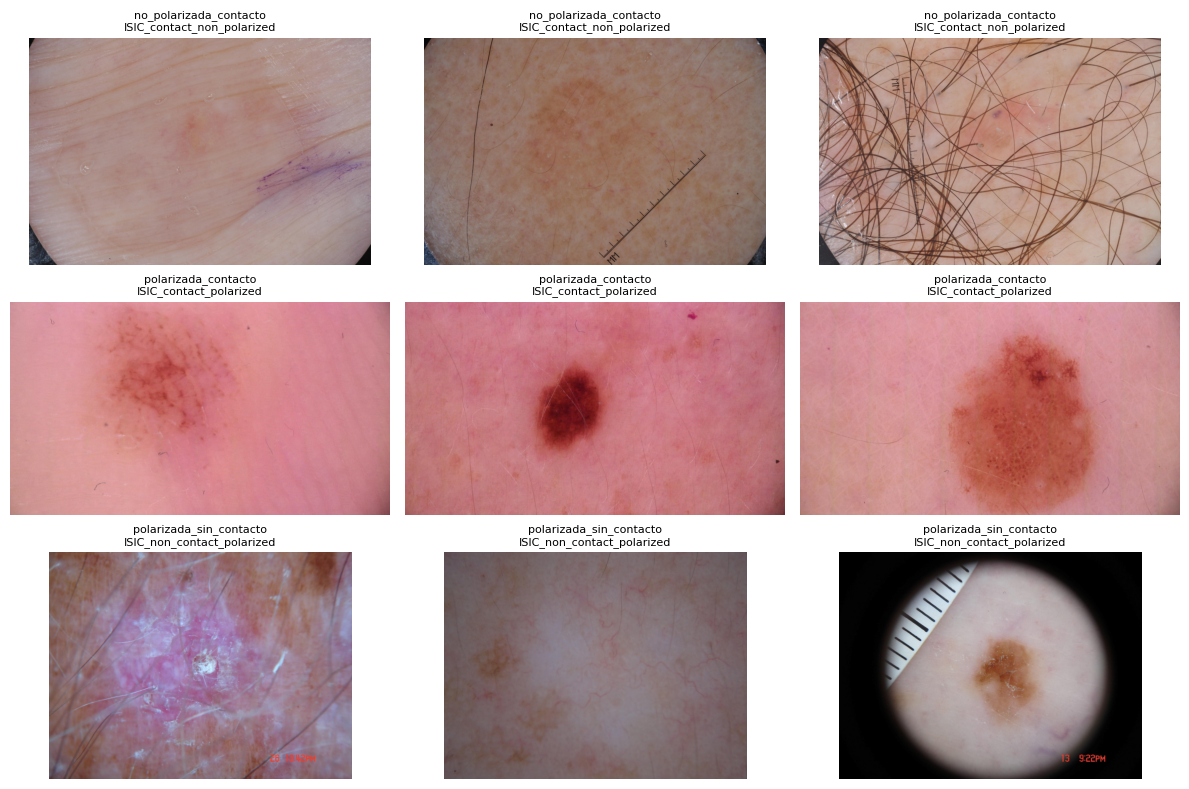

In [ ]:
# ============================================================
# PRUEBA FINAL — CARGAR IMÁGENES DESDE LOS MANIFIESTOS
# ============================================================

from pathlib import Path
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt

RUTA_BASE = Path("/content/drive/MyDrive/DATASETS")
RUTA_MANIFIESTOS = RUTA_BASE / "03_manifiestos"

ruta_manifest = RUTA_MANIFIESTOS / "manifest_comparacion_luz.csv"

df = pd.read_csv(ruta_manifest, low_memory=False)

print("Filas en manifest_comparacion_luz:", len(df))
print("\nDistribución tipo_luz:")
print(df["tipo_luz"].value_counts())

# Verificar rutas
df["ruta_existe"] = df["ruta_imagen"].apply(lambda x: Path(str(x)).exists())

print("\nRutas existentes:")
print(df["ruta_existe"].value_counts())

faltantes = df[df["ruta_existe"] == False]
print("\nImágenes faltantes:", len(faltantes))

# Mostrar 3 imágenes por tipo de luz
muestra = (
    df[df["ruta_existe"] == True]
    .groupby("tipo_luz", group_keys=False)
    .apply(lambda x: x.sample(min(3, len(x)), random_state=42))
    .reset_index(drop=True)
)

plt.figure(figsize=(12, 8))

for i, row in muestra.iterrows():
    img = Image.open(row["ruta_imagen"]).convert("RGB")

    plt.subplot(3, 3, i + 1)
    plt.imshow(img)
    plt.axis("off")
    plt.title(
        f"{row['tipo_luz']}\n{row['dataset_origen']}",
        fontsize=8
    )

plt.tight_layout()
plt.show()

# DATASETS FINAL DERMATEC

## b1

In [ ]:
# ============================================================
# BLOQUE 21 — DERMATEC DATASET FINAL
# FASE A: AUDITORÍA OFICIAL DE MILK10k
#
# IMPORTANTE:
# - NO modifica el dataset del Drive.
# - NO descarga imágenes.
# - NO sobrescribe manifiestos.
# - Descarga únicamente metadatos oficiales a /content.
# ============================================================

from google.colab import drive
drive.mount("/content/drive")

from pathlib import Path
import pandas as pd
import numpy as np
import urllib.request
import re
import os

print("=" * 100)
print("DERMATEC — DATASET FINAL — AUDITORÍA MILK10k")
print("=" * 100)

# ------------------------------------------------------------
# 1. POOL ACTUAL DERMATEC
# ------------------------------------------------------------

RUTA_POOL = Path(
    "/content/drive/MyDrive/DATASETS/03_manifiestos/"
    "manifest_pool_DERMATEC_final_en_construccion.csv"
)

if not RUTA_POOL.exists():
    raise FileNotFoundError(
        f"No se encontró el pool actual:\n{RUTA_POOL}"
    )

pool = pd.read_csv(RUTA_POOL, low_memory=False)

print("\nPOOL ACTUAL DERMATEC")
print("-" * 60)

if "indice_clase_4" in pool.columns:

    nombres = {
        0: "Nevo",
        1: "Melanoma",
        2: "BCC",
        3: "SCC"
    }

    for c in range(4):

        n = int(
            (
                pd.to_numeric(
                    pool["indice_clase_4"],
                    errors="coerce"
                ) == c
            ).sum()
        )

        print(f"{nombres[c]:10s}: {n:,}")

print(f"TOTAL: {len(pool):,}")

# ------------------------------------------------------------
# 2. COMPROBAR QUE EL POOL SOBREVIVIÓ A LA LIMPIEZA
# ------------------------------------------------------------

if "ruta_imagen" not in pool.columns:
    raise RuntimeError(
        "El pool no contiene ruta_imagen."
    )

existentes = pool["ruta_imagen"].astype(str).map(
    os.path.isfile
)

print("\nArchivos físicos del pool:")
print(f"Existen:  {int(existentes.sum()):,}")
print(f"Faltan:   {int((~existentes).sum()):,}")

if not existentes.all():
    print(
        "\nADVERTENCIA: hay rutas faltantes. "
        "No continuar con descargas hasta revisarlas."
    )

# ------------------------------------------------------------
# 3. DESCARGAR ÚNICAMENTE METADATOS OFICIALES MILK10k
#    TODO queda temporalmente en /content
# ------------------------------------------------------------

TMP = Path("/content/DERMATEC_MILK10k_AUDITORIA")
TMP.mkdir(parents=True, exist_ok=True)

URLS = {
    "metadata":
        "https://isic-archive.s3.amazonaws.com/"
        "dois/10.34970-648456/milk10k.csv",

    "supplement":
        "https://isic-archive.s3.amazonaws.com/"
        "dois/10.34970-648456/supplements/training_supp.csv",

    "ground_truth":
        "https://isic-archive.s3.amazonaws.com/"
        "dois/10.34970-648456/supplements/training_gt.csv",

    "input":
        "https://isic-archive.s3.amazonaws.com/"
        "dois/10.34970-648456/supplements/training_input.csv"
}

archivos = {}

print("\nDescargando metadatos oficiales MILK10k...")

for nombre, url in URLS.items():

    destino = TMP / f"{nombre}.csv"

    if not destino.exists():
        urllib.request.urlretrieve(
            url,
            destino
        )

    archivos[nombre] = destino

    print(
        f"{nombre:15s}: "
        f"{destino.stat().st_size / 1024:.1f} KB"
    )

# ------------------------------------------------------------
# 4. CARGAR CSV
# ------------------------------------------------------------

metadata = pd.read_csv(
    archivos["metadata"],
    low_memory=False
)

supp = pd.read_csv(
    archivos["supplement"],
    low_memory=False
)

gt = pd.read_csv(
    archivos["ground_truth"],
    low_memory=False
)

inp = pd.read_csv(
    archivos["input"],
    low_memory=False
)

print("\n" + "=" * 100)
print("ARCHIVOS OFICIALES")
print("=" * 100)

for nombre, df in [
    ("metadata", metadata),
    ("supplement", supp),
    ("ground_truth", gt),
    ("input", inp)
]:

    print(
        f"\n{nombre}: "
        f"{len(df):,} filas x {len(df.columns)} columnas"
    )

    print(
        "Columnas:",
        df.columns.tolist()
    )

# ------------------------------------------------------------
# 5. NORMALIZADOR DE NOMBRES
# ------------------------------------------------------------

def normalizar(texto):
    return re.sub(
        r"[^a-z0-9]",
        "",
        str(texto).lower()
    )

def buscar_columna(df, candidatos):

    mapa = {
        normalizar(c): c
        for c in df.columns
    }

    for candidato in candidatos:

        key = normalizar(candidato)

        if key in mapa:
            return mapa[key]

    return None

# ------------------------------------------------------------
# 6. DISTRIBUCIÓN OFICIAL DE CLASES MILK10k
# ------------------------------------------------------------

print("\n" + "=" * 100)
print("DISTRIBUCIÓN OFICIAL POR LESIÓN")
print("=" * 100)

clases = [
    "AKIEC",
    "BCC",
    "BEN_OTH",
    "BKL",
    "DF",
    "INF",
    "MAL_OTH",
    "MEL",
    "NV",
    "SCCKA",
    "VASC"
]

columnas_clase = {}

for clase in clases:

    col = buscar_columna(
        gt,
        [clase]
    )

    if col is not None:

        columnas_clase[clase] = col

        valores = pd.to_numeric(
            gt[col],
            errors="coerce"
        ).fillna(0)

        print(
            f"{clase:10s}: "
            f"{int(valores.sum()):,} lesiones"
        )

# ------------------------------------------------------------
# 7. LOCALIZAR ID DE LESIÓN
# ------------------------------------------------------------

col_lesion_gt = buscar_columna(
    gt,
    [
        "lesion",
        "lesion_id",
        "lesionid"
    ]
)

col_lesion_supp = buscar_columna(
    supp,
    [
        "lesion",
        "lesion_id",
        "lesionid"
    ]
)

print("\nID de lesión:")
print("Ground truth:", col_lesion_gt)
print("Supplement:  ", col_lesion_supp)

# ------------------------------------------------------------
# 8. DIAGNÓSTICO GRANULAR ISIC-DX
# ------------------------------------------------------------

diag_cols = [
    c for c in supp.columns
    if any(
        palabra in normalizar(c)
        for palabra in [
            "diagnos",
            "isicdx",
            "diagnosis"
        ]
    )
]

print("\nColumnas diagnósticas granulares encontradas:")
print(diag_cols)

# ------------------------------------------------------------
# 9. MOSTRAR DIAGNÓSTICOS ESPECÍFICOS
#    BCC / MEL / SCCKA
# ------------------------------------------------------------

if (
    col_lesion_gt is not None
    and
    col_lesion_supp is not None
):

    for clase in [
        "BCC",
        "MEL",
        "SCCKA"
    ]:

        if clase not in columnas_clase:
            continue

        col_clase = columnas_clase[clase]

        mask = (
            pd.to_numeric(
                gt[col_clase],
                errors="coerce"
            ).fillna(0) > 0
        )

        lesiones_clase = set(
            gt.loc[
                mask,
                col_lesion_gt
            ].astype(str)
        )

        temp = supp[
            supp[col_lesion_supp]
            .astype(str)
            .isin(lesiones_clase)
        ].copy()

        print("\n" + "-" * 100)
        print(
            f"{clase}: "
            f"{len(lesiones_clase):,} lesiones"
        )

        for col in diag_cols:

            if temp[col].notna().any():

                print(
                    f"\n{col}:"
                )

                print(
                    temp[col]
                    .dropna()
                    .astype(str)
                    .value_counts()
                    .head(30)
                    .to_string()
                )

# ------------------------------------------------------------
# 10. IDENTIFICAR MODALIDAD DE IMAGEN
# ------------------------------------------------------------

print("\n" + "=" * 100)
print("COLUMNAS RELACIONADAS CON IMAGEN / MODALIDAD")
print("=" * 100)

cols_imagen = [
    c for c in list(metadata.columns) + list(inp.columns)
    if any(
        p in normalizar(c)
        for p in [
            "image",
            "modality",
            "dermos",
            "clinical",
            "lesion"
        ]
    )
]

# Eliminar repetidas manteniendo orden
cols_imagen = list(
    dict.fromkeys(cols_imagen)
)

print(cols_imagen)

for df_nombre, df in [
    ("metadata", metadata),
    ("input", inp)
]:

    print(f"\n--- {df_nombre} ---")

    for col in cols_imagen:

        if col not in df.columns:
            continue

        nunique = df[col].nunique(
            dropna=True
        )

        if nunique <= 20:

            print(f"\n{col}:")
            print(
                df[col]
                .value_counts(
                    dropna=False
                )
                .head(20)
                .to_string()
            )

# ------------------------------------------------------------
# 11. BUSCAR POSIBLES IDs ISIC ANTERIORES
#     PARA DETECTAR DUPLICADOS CON NUESTRO POOL
# ------------------------------------------------------------

print("\n" + "=" * 100)
print("POSIBLE SOLAPAMIENTO CON EL POOL ACTUAL")
print("=" * 100)

ids_pool = set()

for col in [
    "image_id",
    "isic_id"
]:

    if col in pool.columns:

        ids_pool.update(
            pool[col]
            .dropna()
            .astype(str)
            .str.strip()
        )

# También usar nombre físico sin extensión
ids_pool.update(
    pool["ruta_imagen"]
    .astype(str)
    .map(
        lambda x: Path(x).stem
    )
)

print(
    "IDs conocidos actualmente:",
    f"{len(ids_pool):,}"
)

columnas_isic = [
    c for c in supp.columns
    if (
        "isic" in normalizar(c)
        or
        "previous" in normalizar(c)
        or
        "prior" in normalizar(c)
    )
]

print(
    "\nColumnas candidatas en supplemental:",
    columnas_isic
)

for col in columnas_isic:

    valores = set(
        supp[col]
        .dropna()
        .astype(str)
        .str.strip()
    )

    overlap = (
        valores &
        ids_pool
    )

    print(
        f"\n{col}: "
        f"{len(valores):,} valores no nulos"
    )

    print(
        "Coincidencias directas con "
        f"nuestro pool: {len(overlap):,}"
    )

# ------------------------------------------------------------
# 12. FIN
# ------------------------------------------------------------

print("\n" + "=" * 100)
print("AUDITORÍA MILK10k TERMINADA")
print("=" * 100)

print(
    "\nNO se descargaron imágenes."
)

print(
    "NO se modificó ningún manifiesto."
)

print(
    "NO se creó ningún archivo persistente en Drive."
)

print(
    "\nLos CSV descargados están únicamente "
    "en /content y desaparecerán al cerrar la sesión."
)

Mounted at /content/drive
DERMATEC — DATASET FINAL — AUDITORÍA MILK10k

POOL ACTUAL DERMATEC
------------------------------------------------------------
Nevo      : 12,000
Melanoma  : 4,096
BCC       : 2,650
SCC       : 985
TOTAL: 19,731

Archivos físicos del pool:
Existen:  19,731
Faltan:   0

Descargando metadatos oficiales MILK10k...
metadata       : 2079.9 KB
supplement     : 626.1 KB
ground_truth   : 184.3 KB
input          : 2526.4 KB

ARCHIVOS OFICIALES

metadata: 10,480 filas x 17 columnas
Columnas: ['isic_id', 'attribution', 'copyright_license', 'age_approx', 'anatom_site_general', 'anatom_site_special', 'concomitant_biopsy', 'diagnosis_1', 'diagnosis_2', 'diagnosis_3', 'diagnosis_4', 'diagnosis_confirm_type', 'image_manipulation', 'image_type', 'lesion_id', 'melanocytic', 'sex']

supplement: 10,480 filas x 4 columnas
Columnas: ['isic_id', 'diagnosis_full', 'diagnosis_confirm_type', 'invasion_thickness_interval']

ground_truth: 5,240 filas x 12 columnas
Columnas: ['lesion_id'

## b2


In [ ]:
# ============================================================
# BLOQUE 22 — DERMATEC DATASET FINAL
# MILK10k: AUDITORÍA GRANULAR DE BCC / MEL / SCC
#
# NO descarga imágenes.
# NO modifica Drive.
# NO crea manifiestos persistentes.
# ============================================================

from pathlib import Path
import pandas as pd
import numpy as np

print("=" * 100)
print("DERMATEC — MILK10k — AUDITORÍA GRANULAR")
print("=" * 100)

TMP = Path("/content/DERMATEC_MILK10k_AUDITORIA")

# ------------------------------------------------------------
# 1. CARGAR LOS CSV YA DESCARGADOS
# ------------------------------------------------------------

metadata = pd.read_csv(
    TMP / "metadata.csv",
    low_memory=False
)

supp = pd.read_csv(
    TMP / "supplement.csv",
    low_memory=False
)

gt = pd.read_csv(
    TMP / "ground_truth.csv",
    low_memory=False
)

# ------------------------------------------------------------
# 2. UNIR DIAGNÓSTICO GRANULAR + LESION_ID + MODALIDAD
# ------------------------------------------------------------

diag = metadata[
    [
        "isic_id",
        "lesion_id",
        "image_type",
        "diagnosis_confirm_type",
        "attribution",
        "copyright_license"
    ]
].merge(
    supp[
        [
            "isic_id",
            "diagnosis_full",
            "diagnosis_confirm_type"
        ]
    ],
    on="isic_id",
    how="left",
    suffixes=("_metadata", "_supp")
)

# Ground truth ancho -> formato largo
clases_gt = [
    "AKIEC", "BCC", "BEN_OTH", "BKL", "DF",
    "INF", "MAL_OTH", "MEL", "NV", "SCCKA", "VASC"
]

gt_long = gt.melt(
    id_vars=["lesion_id"],
    value_vars=clases_gt,
    var_name="categoria_MILK",
    value_name="valor"
)

gt_long = gt_long[
    pd.to_numeric(
        gt_long["valor"],
        errors="coerce"
    ).fillna(0) == 1
][
    ["lesion_id", "categoria_MILK"]
]

diag = diag.merge(
    gt_long,
    on="lesion_id",
    how="left"
)

# ------------------------------------------------------------
# 3. SOLO DERMATOSCOPÍA
# ------------------------------------------------------------

dermo = diag[
    diag["image_type"]
    .astype(str)
    .str.lower()
    .eq("dermoscopic")
].copy()

print(f"\nImágenes dermatoscópicas: {len(dermo):,}")
print(f"Lesiones distintas:       {dermo['lesion_id'].nunique():,}")

# ------------------------------------------------------------
# 4. DISTRIBUCIÓN GRANULAR DE LAS CLASES QUE NOS INTERESAN
# ------------------------------------------------------------

print("\n" + "=" * 100)
print("DIAGNÓSTICOS GRANULARES")
print("=" * 100)

for categoria in ["BCC", "MEL", "SCCKA", "AKIEC"]:

    temp = dermo[
        dermo["categoria_MILK"] == categoria
    ]

    print(f"\n--- {categoria} ---")
    print(f"Lesiones: {temp['lesion_id'].nunique():,}")

    print(
        temp["diagnosis_full"]
        .fillna("SIN_DIAGNOSTICO")
        .value_counts()
        .to_string()
    )

# ------------------------------------------------------------
# 5. MÉTODO DE CONFIRMACIÓN
# ------------------------------------------------------------

print("\n" + "=" * 100)
print("MÉTODO DE CONFIRMACIÓN")
print("=" * 100)

# Preferimos el dato supplemental si existe
diag_confirm = dermo[
    "diagnosis_confirm_type_supp"
].fillna(
    dermo["diagnosis_confirm_type_metadata"]
)

dermo["confirmacion_final"] = diag_confirm

for categoria in ["BCC", "MEL", "SCCKA", "AKIEC"]:

    temp = dermo[
        dermo["categoria_MILK"] == categoria
    ]

    print(f"\n--- {categoria} ---")

    print(
        temp["confirmacion_final"]
        .fillna("SIN_DATO")
        .value_counts()
        .to_string()
    )

# ------------------------------------------------------------
# 6. IDENTIFICAR HISTOPATOLOGÍA
# ------------------------------------------------------------

confirm_txt = (
    dermo["confirmacion_final"]
    .fillna("")
    .astype(str)
    .str.lower()
)

dermo["histopatologia"] = (
    confirm_txt.str.contains(
        "histopath",
        regex=False
    )
)

# ------------------------------------------------------------
# 7. MAPEO CONSERVADOR PARA DERMATEC
# ------------------------------------------------------------
#
# BCC:
#   categoría oficial BCC
#
# MEL:
#   categoría oficial MEL
#
# SCC:
#   SOLO "Squamous cell carcinoma, Invasive"
#
# Keratoacanthoma:
#   NO se incorpora como SCC.
#
# SCC in situ / Bowen:
#   se contabiliza aparte y NO se incorpora todavía.
# ------------------------------------------------------------

dx = (
    dermo["diagnosis_full"]
    .fillna("")
    .astype(str)
    .str.lower()
    .str.strip()
)

dermo["clase_DERMATEC"] = pd.NA

dermo.loc[
    dermo["categoria_MILK"].eq("BCC"),
    "clase_DERMATEC"
] = "BCC"

dermo.loc[
    dermo["categoria_MILK"].eq("MEL"),
    "clase_DERMATEC"
] = "Melanoma"

mask_scc_invasivo = (
    dermo["categoria_MILK"].eq("SCCKA")
    &
    dx.str.contains(
        "squamous cell carcinoma",
        regex=False
    )
    &
    dx.str.contains(
        "invasive",
        regex=False
    )
)

dermo.loc[
    mask_scc_invasivo,
    "clase_DERMATEC"
] = "SCC"

# ------------------------------------------------------------
# 8. CONTAR KERATOACANTOMA Y SCC IN SITU APARTE
# ------------------------------------------------------------

mask_ka = dx.str.contains(
    "keratoacanthoma",
    regex=False
)

mask_scc_in_situ = (
    dx.str.contains(
        "squamous cell carcinoma",
        regex=False
    )
    &
    (
        dx.str.contains("situ", regex=False)
        |
        dx.str.contains("bowen", regex=False)
    )
)

print("\n" + "=" * 100)
print("CASOS ESCAMOSOS")
print("=" * 100)

print(
    "SCC invasivo:",
    f"{int(mask_scc_invasivo.sum()):,}"
)

print(
    "Keratoacantoma:",
    f"{int(mask_ka.sum()):,}"
)

print(
    "SCC in situ / Bowen detectados:",
    f"{int(mask_scc_in_situ.sum()):,}"
)

# ------------------------------------------------------------
# 9. CANDIDATOS DERMATEC
# ------------------------------------------------------------

candidatos = dermo[
    dermo["clase_DERMATEC"].notna()
].copy()

print("\n" + "=" * 100)
print("CANDIDATOS DERMATEC — TODOS")
print("=" * 100)

print(
    candidatos[
        "clase_DERMATEC"
    ]
    .value_counts()
    .to_string()
)

print(
    f"\nTOTAL: {len(candidatos):,}"
)

# ------------------------------------------------------------
# 10. SOLO HISTOPATOLOGÍA
# ------------------------------------------------------------

candidatos_hist = candidatos[
    candidatos["histopatologia"]
].copy()

print("\n" + "=" * 100)
print("CANDIDATOS DERMATEC — CONFIRMADOS POR HISTOPATOLOGÍA")
print("=" * 100)

print(
    candidatos_hist[
        "clase_DERMATEC"
    ]
    .value_counts()
    .to_string()
)

print(
    f"\nTOTAL: {len(candidatos_hist):,}"
)

# ------------------------------------------------------------
# 11. VERIFICAR UNICIDAD POR LESIÓN
# ------------------------------------------------------------

print("\n" + "=" * 100)
print("CONTROL DE LESIONES")
print("=" * 100)

print(
    "Imágenes candidatas:",
    f"{len(candidatos_hist):,}"
)

print(
    "Lesiones candidatas distintas:",
    f"{candidatos_hist['lesion_id'].nunique():,}"
)

duplicadas_lesion = (
    candidatos_hist[
        "lesion_id"
    ]
    .value_counts()
)

duplicadas_lesion = duplicadas_lesion[
    duplicadas_lesion > 1
]

print(
    "Lesiones con >1 imagen dermatoscópica candidata:",
    f"{len(duplicadas_lesion):,}"
)

# ------------------------------------------------------------
# 12. LICENCIA
# ------------------------------------------------------------

print("\n" + "=" * 100)
print("LICENCIAS DE LOS CANDIDATOS")
print("=" * 100)

print(
    candidatos_hist[
        "copyright_license"
    ]
    .fillna("SIN_DATO")
    .value_counts()
    .to_string()
)

# ------------------------------------------------------------
# 13. DEJAR VARIABLE EN MEMORIA PARA EL SIGUIENTE BLOQUE
# ------------------------------------------------------------

milk10k_candidatos_hist = (
    candidatos_hist
    .reset_index(drop=True)
)

print("\n" + "=" * 100)
print("AUDITORÍA GRANULAR TERMINADA")
print("=" * 100)

print(
    "\nVariable creada en memoria:"
    "\nmilk10k_candidatos_hist"
)

print(
    "\nNO se descargaron imágenes."
    "\nNO se modificó Drive."
    "\nNO se guardó ningún CSV nuevo."
)

DERMATEC — MILK10k — AUDITORÍA GRANULAR

Imágenes dermatoscópicas: 5,240
Lesiones distintas:       5,240

DIAGNÓSTICOS GRANULARES

--- BCC ---
Lesiones: 2,522
diagnosis_full
Basal cell carcinoma    2522

--- MEL ---
Lesiones: 450
diagnosis_full
Melanoma Invasive      255
Melanoma in situ       181
Melanoma metastasis     14

--- SCCKA ---
Lesiones: 473
diagnosis_full
Squamous cell carcinoma, Invasive    311
Keratoacanthoma                      162

--- AKIEC ---
Lesiones: 303
diagnosis_full
Squamous cell carcinoma in situ, Bowens disease    180
Solar or actinic keratosis                         123

MÉTODO DE CONFIRMACIÓN

--- BCC ---
confirmacion_final
histopathology                            2520
single contributor clinical assessment       2

--- MEL ---
confirmacion_final
histopathology                            448
single contributor clinical assessment      2

--- SCCKA ---
confirmacion_final
histopathology    473

--- AKIEC ---
confirmacion_final
histopathology                

## b3 (primero b3a)

In [ ]:
# ============================================================
# BLOQUE 23 — DERMATEC DATASET FINAL
# INCORPORACIÓN CONTROLADA MILK10k
#
# FUENTE OFICIAL:
# MILK study team. MILK10k. ISIC Archive, 2025
# DOI: 10.34970/648456
# Licencia: CC-BY-NC
#
# INCORPORA ÚNICAMENTE:
#   - BCC con histopatología
#   - Melanoma con histopatología
#   - SCC INVASIVO con histopatología
#   - imagen DERMATOSCÓPICA
#
# NO incorpora:
#   - fotografías clínicas
#   - keratoacantoma
#   - SCC in situ / Bowen
#   - nevos
#   - otras clases
#
# PERSISTENCIA:
#   - imágenes nuevas verificadas
#   - mismo manifiesto vivo DERMATEC
#
# TEMPORAL:
#   - ZIP y extracción en /content
# ============================================================

from google.colab import drive
drive.mount("/content/drive")

from pathlib import Path
from PIL import Image
from concurrent.futures import ThreadPoolExecutor
import pandas as pd
import numpy as np
import hashlib
import urllib.request
import zipfile
import shutil
import os
import io
import time
import re

print("=" * 105)
print("DERMATEC — INCORPORACIÓN CONTROLADA MILK10k")
print("=" * 105)

# ============================================================
# 1. RUTAS DEFINITIVAS
# ============================================================

RUTA_POOL = Path(
    "/content/drive/MyDrive/DATASETS/03_manifiestos/"
    "manifest_pool_DERMATEC_final_en_construccion.csv"
)

# UNA sola raíz para los datasets nuevos verificados.
RAIZ_NUEVOS = Path(
    "/content/drive/MyDrive/DATASETS/01_BasesDeDatos/"
    "05_DERMATEC_nuevos_verificados"
)

RUTA_MILK = (
    RAIZ_NUEVOS /
    "MILK10k" /
    "images"
)

RUTA_MILK.mkdir(
    parents=True,
    exist_ok=True
)

# Temporales: NO Drive
TMP = Path("/content/DERMATEC_MILK10k")
TMP.mkdir(parents=True, exist_ok=True)

ZIP_LOCAL = TMP / "milk10k.zip"
EXTRACCION = TMP / "candidatos"

EXTRACCION.mkdir(
    parents=True,
    exist_ok=True
)

URL_ZIP = (
    "https://isic-archive.s3.amazonaws.com/"
    "dois/10.34970-648456/milk10k.zip"
)

# Metadatos del bloque anterior.
TMP_META = Path(
    "/content/DERMATEC_MILK10k_AUDITORIA"
)

# ============================================================
# 2. CARGAR POOL ACTUAL
# ============================================================

if not RUTA_POOL.exists():
    raise FileNotFoundError(
        f"No existe el pool DERMATEC:\n{RUTA_POOL}"
    )

pool = pd.read_csv(
    RUTA_POOL,
    low_memory=False
)

if "ruta_imagen" not in pool.columns:
    raise RuntimeError(
        "El manifiesto no contiene ruta_imagen."
    )

pool["ruta_imagen"] = (
    pool["ruta_imagen"]
    .astype(str)
    .str.strip()
)

if len(pool) != 19731:
    print(
        "\nAVISO:"
        f"\nEl pool tiene {len(pool):,} filas, "
        "no 19.731."
        "\nEsto puede ser correcto si este bloque "
        "ya fue ejecutado anteriormente."
    )

print("\nPOOL ANTES DE MILK10k")

for c, nombre in {
    0: "Nevo",
    1: "Melanoma",
    2: "BCC",
    3: "SCC"
}.items():

    if "indice_clase_4" in pool.columns:

        valores = pd.to_numeric(
            pool["indice_clase_4"],
            errors="coerce"
        )

        print(
            f"{nombre:10s}: "
            f"{int((valores == c).sum()):,}"
        )

print(f"TOTAL: {len(pool):,}")

# ============================================================
# 3. COMPROBAR ARCHIVOS FÍSICOS
# ============================================================

faltantes = [
    ruta
    for ruta in pool["ruta_imagen"]
    if not os.path.isfile(ruta)
]

if faltantes:
    raise RuntimeError(
        f"Hay {len(faltantes):,} imágenes "
        "del pool que no existen físicamente."
    )

print(
    "\nIntegridad física del pool: "
    f"{len(pool):,}/{len(pool):,} OK"
)

# ============================================================
# 4. CARGAR / RECUPERAR METADATOS MILK10k
# ============================================================

URLS_META = {
    "metadata":
        "https://isic-archive.s3.amazonaws.com/"
        "dois/10.34970-648456/milk10k.csv",

    "supplement":
        "https://isic-archive.s3.amazonaws.com/"
        "dois/10.34970-648456/supplements/training_supp.csv",

    "ground_truth":
        "https://isic-archive.s3.amazonaws.com/"
        "dois/10.34970-648456/supplements/training_gt.csv"
}

TMP_META.mkdir(
    parents=True,
    exist_ok=True
)

for nombre, url in URLS_META.items():

    archivo = TMP_META / f"{nombre}.csv"

    if not archivo.exists():

        print(
            f"Descargando {nombre}.csv..."
        )

        urllib.request.urlretrieve(
            url,
            archivo
        )

metadata = pd.read_csv(
    TMP_META / "metadata.csv",
    low_memory=False
)

supp = pd.read_csv(
    TMP_META / "supplement.csv",
    low_memory=False
)

gt = pd.read_csv(
    TMP_META / "ground_truth.csv",
    low_memory=False
)

# ============================================================
# 5. RECONSTRUIR CANDIDATOS DE FORMA INDEPENDIENTE
# ============================================================

diag = metadata.merge(
    supp[
        [
            "isic_id",
            "diagnosis_full",
            "diagnosis_confirm_type"
        ]
    ],
    on="isic_id",
    how="left",
    suffixes=("_metadata", "_supp")
)

clases_gt = [
    "AKIEC",
    "BCC",
    "BEN_OTH",
    "BKL",
    "DF",
    "INF",
    "MAL_OTH",
    "MEL",
    "NV",
    "SCCKA",
    "VASC"
]

gt_long = gt.melt(
    id_vars=["lesion_id"],
    value_vars=clases_gt,
    var_name="categoria_MILK",
    value_name="valor"
)

gt_long = gt_long[
    pd.to_numeric(
        gt_long["valor"],
        errors="coerce"
    ).fillna(0) == 1
][
    [
        "lesion_id",
        "categoria_MILK"
    ]
]

diag = diag.merge(
    gt_long,
    on="lesion_id",
    how="left"
)

# Solo dermatoscópicas
diag = diag[
    diag["image_type"]
    .astype(str)
    .str.lower()
    .eq("dermoscopic")
].copy()

# Confirmación final
diag["confirmacion_final"] = (
    diag["diagnosis_confirm_type_supp"]
    .fillna(
        diag["diagnosis_confirm_type_metadata"]
    )
)

confirm = (
    diag["confirmacion_final"]
    .fillna("")
    .astype(str)
    .str.lower()
)

diag["histopatologia"] = (
    confirm.str.contains(
        "histopath",
        regex=False
    )
)

dx = (
    diag["diagnosis_full"]
    .fillna("")
    .astype(str)
    .str.lower()
)

diag["clase_DERMATEC"] = pd.NA
diag["indice_clase_4"] = pd.NA

# BCC
mask = (
    diag["categoria_MILK"].eq("BCC")
    &
    diag["histopatologia"]
)

diag.loc[
    mask,
    "clase_DERMATEC"
] = "BCC"

diag.loc[
    mask,
    "indice_clase_4"
] = 2

# Melanoma
mask = (
    diag["categoria_MILK"].eq("MEL")
    &
    diag["histopatologia"]
)

diag.loc[
    mask,
    "clase_DERMATEC"
] = "Melanoma"

diag.loc[
    mask,
    "indice_clase_4"
] = 1

# SCC invasivo exclusivamente
mask = (
    diag["categoria_MILK"].eq("SCCKA")
    &
    diag["histopatologia"]
    &
    dx.str.contains(
        "squamous cell carcinoma",
        regex=False
    )
    &
    dx.str.contains(
        "invasive",
        regex=False
    )
)

diag.loc[
    mask,
    "clase_DERMATEC"
] = "SCC"

diag.loc[
    mask,
    "indice_clase_4"
] = 3

candidatos = diag[
    diag["clase_DERMATEC"].notna()
].copy()

candidatos["indice_clase_4"] = (
    candidatos["indice_clase_4"]
    .astype(int)
)

candidatos = candidatos.drop_duplicates(
    subset=["isic_id"]
)

print("\nCANDIDATOS MILK10k RECONSTRUIDOS")

print(
    candidatos[
        "clase_DERMATEC"
    ]
    .value_counts()
    .to_string()
)

print(
    f"TOTAL: {len(candidatos):,}"
)

if len(candidatos) != 3279:

    raise RuntimeError(
        "Seguridad activada: "
        f"se esperaban 3.279 candidatos "
        f"y aparecieron {len(candidatos):,}."
    )

# ============================================================
# 6. FILTRO POR IDs / LESIONES YA CONOCIDAS
# ============================================================

ids_pool = set()

for col in [
    "image_id",
    "isic_id"
]:

    if col in pool.columns:

        ids_pool.update(
            pool[col]
            .dropna()
            .astype(str)
            .str.strip()
        )

ids_pool.update(
    pool["ruta_imagen"]
    .map(
        lambda x:
        Path(str(x)).stem
    )
)

lesiones_pool = set()

if "lesion_id" in pool.columns:

    lesion_temp = (
        pool["lesion_id"]
        .dropna()
        .astype(str)
        .str.strip()
    )

    lesion_temp = lesion_temp[
        ~lesion_temp.isin([
            "",
            "nan",
            "None"
        ])
    ]

    lesiones_pool.update(
        lesion_temp
    )

candidatos["duplicado_id"] = (
    candidatos["isic_id"]
    .astype(str)
    .isin(ids_pool)
)

candidatos["duplicado_lesion_id"] = (
    candidatos["lesion_id"]
    .astype(str)
    .isin(lesiones_pool)
)

print("\nSOLAPAMIENTO ANTES DE DESCARGAR")

print(
    "ISIC/image_id conocido:",
    int(
        candidatos[
            "duplicado_id"
        ].sum()
    )
)

print(
    "lesion_id conocido:",
    int(
        candidatos[
            "duplicado_lesion_id"
        ].sum()
    )
)

# ============================================================
# 7. FINGERPRINTS DEL POOL EXISTENTE
# ============================================================

def calcular_dhash(ruta):

    try:

        with Image.open(ruta) as img:

            img = (
                img
                .convert("L")
                .resize(
                    (9, 8),
                    Image.Resampling.LANCZOS
                )
            )

            arr = np.asarray(
                img,
                dtype=np.int16
            )

            diff = (
                arr[:, 1:]
                >
                arr[:, :-1]
            )

            valor = 0

            for bit in diff.flatten():

                valor = (
                    (valor << 1)
                    | int(bit)
                )

            return f"{valor:016x}"

    except Exception:

        return None


def calcular_sha256(ruta):

    try:

        h = hashlib.sha256()

        with open(
            ruta,
            "rb"
        ) as archivo:

            for bloque in iter(
                lambda:
                archivo.read(
                    1024 * 1024
                ),
                b""
            ):

                h.update(
                    bloque
                )

        return h.hexdigest()

    except Exception:

        return None


def fingerprint(ruta):

    return (
        calcular_sha256(ruta),
        calcular_dhash(ruta)
    )


necesita_fingerprint = (
    "sha256" not in pool.columns
    or
    "dhash64" not in pool.columns
    or
    pool.get(
        "sha256",
        pd.Series(
            [None] * len(pool)
        )
    ).isna().any()
    or
    pool.get(
        "dhash64",
        pd.Series(
            [None] * len(pool)
        )
    ).isna().any()
)

if necesita_fingerprint:

    print(
        "\nCalculando fingerprints del pool "
        "actual por primera y única vez..."
    )

    inicio = time.time()

    rutas = (
        pool["ruta_imagen"]
        .astype(str)
        .tolist()
    )

    with ThreadPoolExecutor(
        max_workers=8
    ) as executor:

        fps = list(
            executor.map(
                fingerprint,
                rutas
            )
        )

    pool["sha256"] = [
        x[0]
        for x in fps
    ]

    pool["dhash64"] = [
        x[1]
        for x in fps
    ]

    if (
        pool["sha256"].isna().any()
        or
        pool["dhash64"].isna().any()
    ):

        raise RuntimeError(
            "No fue posible calcular fingerprint "
            "para todas las imágenes existentes."
        )

    print(
        "Fingerprints terminados en "
        f"{time.time()-inicio:.1f} s"
    )

else:

    print(
        "\nFingerprints existentes: "
        "no se recalculan."
    )

sha_pool = set(
    pool["sha256"]
    .dropna()
    .astype(str)
)

dhash_pool = set(
    pool["dhash64"]
    .dropna()
    .astype(str)
)

# ============================================================
# 8. DESCARGAR ZIP OFICIAL
# ============================================================

if not ZIP_LOCAL.exists():

    print(
        "\nDescargando bundle oficial MILK10k..."
    )

    inicio = time.time()

    urllib.request.urlretrieve(
        URL_ZIP,
        ZIP_LOCAL
    )

    print(
        "Descarga terminada:"
        f" {ZIP_LOCAL.stat().st_size / 1024**2:.1f} MB"
        f" en {time.time()-inicio:.1f} s"
    )

else:

    print(
        "\nZIP MILK10k ya existe temporalmente."
    )

# ============================================================
# 9. LOCALIZAR Y EXTRAER SOLO LOS 3.279 CANDIDATOS
# ============================================================

ids_candidatos = set(
    candidatos[
        "isic_id"
    ].astype(str)
)

mapa_extraidos = {}

print(
    "\nBuscando candidatos dentro del ZIP..."
)

with zipfile.ZipFile(
    ZIP_LOCAL,
    "r"
) as zf:

    miembros = zf.namelist()

    mapa_zip = {}

    for miembro in miembros:

        sufijo = Path(miembro).suffix.lower()

        if sufijo not in [
            ".jpg",
            ".jpeg",
            ".png"
        ]:
            continue

        stem = Path(
            miembro
        ).stem

        if stem in ids_candidatos:

            mapa_zip[
                stem
            ] = miembro

    print(
        "Candidatos encontrados en ZIP:",
        f"{len(mapa_zip):,}/{len(ids_candidatos):,}"
    )

    if len(mapa_zip) != len(ids_candidatos):

        faltan = (
            ids_candidatos
            -
            set(mapa_zip.keys())
        )

        print(
            "Ejemplo de IDs faltantes:",
            list(faltan)[:20]
        )

        raise RuntimeError(
            "No se encontraron todos "
            "los candidatos en el ZIP."
        )

    for n, (
        isic_id,
        miembro
    ) in enumerate(
        mapa_zip.items(),
        1
    ):

        extension = (
            Path(miembro)
            .suffix
            .lower()
        )

        destino = (
            EXTRACCION /
            f"{isic_id}{extension}"
        )

        with zf.open(
            miembro
        ) as origen, open(
            destino,
            "wb"
        ) as salida:

            shutil.copyfileobj(
                origen,
                salida
            )

        mapa_extraidos[
            isic_id
        ] = destino

        if n % 500 == 0:

            print(
                f"  Extraídos "
                f"{n:,}/{len(mapa_zip):,}"
            )

# ============================================================
# 10. FINGERPRINTS MILK10k
# ============================================================

print(
    "\nCalculando fingerprints MILK10k..."
)

rutas_milk = [
    str(
        mapa_extraidos[
            isic_id
        ]
    )
    for isic_id
    in candidatos[
        "isic_id"
    ].astype(str)
]

inicio = time.time()

with ThreadPoolExecutor(
    max_workers=8
) as executor:

    fps_milk = list(
        executor.map(
            fingerprint,
            rutas_milk
        )
    )

candidatos["sha256"] = [
    x[0]
    for x in fps_milk
]

candidatos["dhash64"] = [
    x[1]
    for x in fps_milk
]

if (
    candidatos["sha256"].isna().any()
    or
    candidatos["dhash64"].isna().any()
):

    raise RuntimeError(
        "Falló el fingerprint "
        "de alguna imagen MILK10k."
    )

print(
    "Fingerprints terminados en "
    f"{time.time()-inicio:.1f} s"
)

# ============================================================
# 11. DETECTAR DUPLICADOS
# ============================================================

candidatos["duplicado_sha256"] = (
    candidatos["sha256"]
    .isin(
        sha_pool
    )
)

candidatos["duplicado_dhash"] = (
    candidatos["dhash64"]
    .isin(
        dhash_pool
    )
)

candidatos["duplicado"] = (
    candidatos[
        [
            "duplicado_id",
            "duplicado_lesion_id",
            "duplicado_sha256",
            "duplicado_dhash"
        ]
    ]
    .any(axis=1)
)

print("\n" + "=" * 105)
print("AUDITORÍA DE DUPLICADOS MILK10k")
print("=" * 105)

for col in [
    "duplicado_id",
    "duplicado_lesion_id",
    "duplicado_sha256",
    "duplicado_dhash"
]:

    print(
        f"{col:25s}: "
        f"{int(candidatos[col].sum()):,}"
    )

print(
    "\nCandidatos con al menos "
    "una señal de duplicado:",
    f"{int(candidatos['duplicado'].sum()):,}"
)

nuevos = candidatos[
    ~candidatos[
        "duplicado"
    ]
].copy()

print(
    "Candidatos realmente nuevos:",
    f"{len(nuevos):,}"
)

print("\nNUEVOS POR CLASE")

print(
    nuevos[
        "clase_DERMATEC"
    ]
    .value_counts()
    .to_string()
)

# ============================================================
# 12. COPIAR ÚNICAMENTE LOS NUEVOS A DRIVE
# ============================================================

print(
    "\nCopiando imágenes nuevas verificadas "
    "a Drive..."
)

rutas_finales_nuevas = []

for n, fila in enumerate(
    nuevos.itertuples(
        index=False
    ),
    1
):

    isic_id = str(
        fila.isic_id
    )

    origen = (
        mapa_extraidos[
            isic_id
        ]
    )

    extension = (
        origen.suffix
        .lower()
    )

    destino = (
        RUTA_MILK /
        f"{isic_id}{extension}"
    )

    if not destino.exists():

        shutil.copy2(
            origen,
            destino
        )

    rutas_finales_nuevas.append(
        str(destino)
    )

    if n % 500 == 0:

        print(
            f"  Copiadas "
            f"{n:,}/{len(nuevos):,}"
        )

nuevos["ruta_imagen"] = (
    rutas_finales_nuevas
)

# Verificación inmediata
ok_fisico = (
    nuevos[
        "ruta_imagen"
    ]
    .map(
        os.path.isfile
    )
)

if not ok_fisico.all():

    raise RuntimeError(
        "Alguna imagen nueva no quedó "
        "copiada correctamente."
    )

# ============================================================
# 13. PREPARAR METADATOS DERMATEC
# ============================================================

nuevos["image_id"] = (
    nuevos["isic_id"]
)

nuevos[
    "diagnostico_general"
] = (
    nuevos[
        "diagnosis_full"
    ]
)

nuevos[
    "dataset_origen"
] = "MILK10k_ISIC_2025"

nuevos[
    "tipo_imagen"
] = "dermoscopic"

nuevos[
    "image_type"
] = "dermoscopic"

nuevos[
    "tipo_luz"
] = "no_especificado"

nuevos[
    "grupo_luz"
] = "desconocida"

nuevos[
    "imagen_existe"
] = True

nuevos[
    "fuente_incorporacion"
] = "MILK10k"

nuevos[
    "doi_dataset"
] = "10.34970/648456"

nuevos[
    "confirmacion_DERMATEC"
] = "histopathology"

nuevos[
    "estado_dataset"
] = "CONSERVAR"

nuevos[
    "elegible_historico"
] = False

# ------------------------------------------------------------
# Mantener attribution y copyright_license
# ya vienen desde metadata.
# ------------------------------------------------------------

# ============================================================
# 14. EVITAR REINCORPORAR SI EL BLOQUE SE EJECUTA OTRA VEZ
# ============================================================

ids_pool_actual = set()

for col in [
    "image_id",
    "isic_id"
]:

    if col in pool.columns:

        ids_pool_actual.update(
            pool[col]
            .dropna()
            .astype(str)
        )

nuevos = nuevos[
    ~nuevos[
        "isic_id"
    ]
    .astype(str)
    .isin(
        ids_pool_actual
    )
].copy()

# ============================================================
# 15. ACTUALIZAR EL MISMO MANIFIESTO VIVO
# ============================================================

pool_actualizado = pd.concat(
    [
        pool,
        nuevos
    ],
    ignore_index=True,
    sort=False
)

pool_actualizado = (
    pool_actualizado
    .drop_duplicates(
        subset=["ruta_imagen"]
    )
    .reset_index(drop=True)
)

# ------------------------------------------------------------
# Validaciones antes de sobrescribir
# ------------------------------------------------------------

if pool_actualizado[
    "ruta_imagen"
].duplicated().any():

    raise RuntimeError(
        "Se detectaron rutas duplicadas "
        "antes de guardar."
    )

faltantes_finales = (
    ~pool_actualizado[
        "ruta_imagen"
    ]
    .astype(str)
    .map(
        os.path.isfile
    )
)

if faltantes_finales.any():

    raise RuntimeError(
        "Hay imágenes ausentes en "
        "el pool actualizado."
    )

# ------------------------------------------------------------
# ESTE ES EL ÚNICO MANIFIESTO VIVO.
# Se actualiza el mismo archivo.
# ------------------------------------------------------------

pool_actualizado.to_csv(
    RUTA_POOL,
    index=False
)

# ============================================================
# 16. RESULTADO
# ============================================================

print("\n" + "=" * 105)
print("POOL DERMATEC DESPUÉS DE MILK10k")
print("=" * 105)

conteos = (
    pd.to_numeric(
        pool_actualizado[
            "indice_clase_4"
        ],
        errors="coerce"
    )
    .value_counts()
    .sort_index()
)

for c, nombre in {
    0: "Nevo",
    1: "Melanoma",
    2: "BCC",
    3: "SCC"
}.items():

    print(
        f"{nombre:10s}: "
        f"{int(conteos.get(c, 0)):,}"
    )

print(
    f"TOTAL: "
    f"{len(pool_actualizado):,}"
)

print("\nAPORTE REAL MILK10k:")

if len(nuevos):

    print(
        nuevos[
            "clase_DERMATEC"
        ]
        .value_counts()
        .to_string()
    )

else:

    print(
        "No se incorporaron imágenes nuevas."
    )

print(
    f"\nTotal MILK10k nuevo: "
    f"{len(nuevos):,}"
)

print(
    "\nCarpeta definitiva MILK10k:"
)

print(
    RUTA_MILK
)

print(
    "\nManifiesto vivo actualizado:"
)

print(
    RUTA_POOL
)

# ============================================================
# 17. LIMPIAR ÚNICAMENTE TEMPORALES
# ============================================================

print(
    "\nEliminando archivos temporales "
    "de /content..."
)

try:

    if ZIP_LOCAL.exists():
        ZIP_LOCAL.unlink()

except Exception:
    pass

try:

    if EXTRACCION.exists():
        shutil.rmtree(
            EXTRACCION
        )

except Exception:
    pass

print(
    "Temporales eliminados."
)

print("\n" + "=" * 105)
print("BLOQUE 23 FINALIZADO")
print("=" * 105)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
DERMATEC — INCORPORACIÓN CONTROLADA MILK10k

POOL ANTES DE MILK10k
Nevo      : 12,000
Melanoma  : 4,096
BCC       : 2,650
SCC       : 985
TOTAL: 19,731

Integridad física del pool: 19,731/19,731 OK

CANDIDATOS MILK10k RECONSTRUIDOS
clase_DERMATEC
BCC         2520
Melanoma     448
SCC          311
TOTAL: 3,279

SOLAPAMIENTO ANTES DE DESCARGAR
ISIC/image_id conocido: 0
lesion_id conocido: 0

Fingerprints existentes: no se recalculan.

Descargando bundle oficial MILK10k...
Descarga terminada: 344.7 MB en 13.9 s

Buscando candidatos dentro del ZIP...
Candidatos encontrados en ZIP: 3,279/3,279
  Extraídos 500/3,279
  Extraídos 1,000/3,279
  Extraídos 1,500/3,279
  Extraídos 2,000/3,279
  Extraídos 2,500/3,279
  Extraídos 3,000/3,279

Calculando fingerprints MILK10k...
Fingerprints terminados en 9.8 s

AUDITORÍA DE DUPLICADOS MILK10k
duplicado_id             : 0
du

## b3a (primero este luego b3)

In [ ]:
# ============================================================
# BLOQUE 23A — FINGERPRINTS OPTIMIZADOS DEL POOL DERMATEC
#
# Lee cada imagen UNA sola vez.
# Calcula SHA256 + dHash.
# Actualiza EL MISMO manifiesto vivo.
# No crea copias ni nuevos manifiestos.
# ============================================================

from pathlib import Path
from PIL import Image
from concurrent.futures import ThreadPoolExecutor, as_completed
import pandas as pd
import numpy as np
import hashlib
import io
import os
import time

RUTA_POOL = Path(
    "/content/drive/MyDrive/DATASETS/03_manifiestos/"
    "manifest_pool_DERMATEC_final_en_construccion.csv"
)

print("=" * 90)
print("DERMATEC — FINGERPRINTS OPTIMIZADOS")
print("=" * 90)

pool = pd.read_csv(
    RUTA_POOL,
    low_memory=False
)

print(f"\nImágenes del pool: {len(pool):,}")

# ------------------------------------------------------------
# FUNCIÓN OPTIMIZADA:
# 1 lectura física -> SHA256 + dHash
# ------------------------------------------------------------

def fingerprint_unico(ruta):

    try:
        with open(ruta, "rb") as f:
            datos = f.read()

        sha = hashlib.sha256(datos).hexdigest()

        with Image.open(io.BytesIO(datos)) as img:

            img = (
                img.convert("L")
                .resize(
                    (9, 8),
                    Image.Resampling.LANCZOS
                )
            )

            arr = np.asarray(
                img,
                dtype=np.int16
            )

            diff = arr[:, 1:] > arr[:, :-1]

            valor = 0

            for bit in diff.flatten():
                valor = (valor << 1) | int(bit)

            dhash = f"{valor:016x}"

        return sha, dhash, None

    except Exception as e:

        return None, None, str(e)


rutas = (
    pool["ruta_imagen"]
    .astype(str)
    .tolist()
)

resultados = [None] * len(rutas)

inicio = time.time()

# 16 hilos: suficiente paralelismo sin castigar demasiado Drive
with ThreadPoolExecutor(max_workers=16) as executor:

    futuros = {
        executor.submit(
            fingerprint_unico,
            ruta
        ): i
        for i, ruta in enumerate(rutas)
    }

    completadas = 0

    for futuro in as_completed(futuros):

        i = futuros[futuro]

        resultados[i] = futuro.result()

        completadas += 1

        if completadas % 1000 == 0 or completadas == len(rutas):

            transcurrido = time.time() - inicio

            velocidad = (
                completadas / transcurrido
                if transcurrido > 0
                else 0
            )

            restante = (
                (len(rutas) - completadas) / velocidad
                if velocidad > 0
                else 0
            )

            print(
                f"{completadas:,}/{len(rutas):,} | "
                f"{transcurrido/60:.1f} min | "
                f"restante aprox. {restante/60:.1f} min"
            )

pool["sha256"] = [
    r[0] for r in resultados
]

pool["dhash64"] = [
    r[1] for r in resultados
]

errores = [
    (rutas[i], resultados[i][2])
    for i in range(len(resultados))
    if resultados[i][2] is not None
]

print("\n" + "=" * 90)

if errores:

    print(f"ERROR: {len(errores):,} imágenes no pudieron procesarse.")

    for ruta, error in errores[:10]:
        print(ruta)
        print(error)

    print("\nNO se modificó el manifiesto.")

else:

    pool.to_csv(
        RUTA_POOL,
        index=False
    )

    print("FINGERPRINTS COMPLETADOS")
    print(f"SHA256: {pool['sha256'].notna().sum():,}")
    print(f"dHash:  {pool['dhash64'].notna().sum():,}")
    print(
        f"Tiempo total: "
        f"{(time.time()-inicio)/60:.1f} minutos"
    )

    print("\nActualizado:")
    print(RUTA_POOL)

print("=" * 90)

DERMATEC — FINGERPRINTS OPTIMIZADOS

Imágenes del pool: 19,731
1,000/19,731 | 0.6 min | restante aprox. 10.4 min
2,000/19,731 | 0.8 min | restante aprox. 7.1 min
3,000/19,731 | 1.1 min | restante aprox. 6.0 min
4,000/19,731 | 1.5 min | restante aprox. 5.8 min
5,000/19,731 | 1.7 min | restante aprox. 5.1 min
6,000/19,731 | 1.9 min | restante aprox. 4.2 min
7,000/19,731 | 2.2 min | restante aprox. 4.0 min
8,000/19,731 | 2.7 min | restante aprox. 3.9 min
9,000/19,731 | 5.0 min | restante aprox. 5.9 min
10,000/19,731 | 8.0 min | restante aprox. 7.8 min
11,000/19,731 | 8.4 min | restante aprox. 6.7 min
12,000/19,731 | 8.8 min | restante aprox. 5.6 min
13,000/19,731 | 10.6 min | restante aprox. 5.5 min
14,000/19,731 | 12.7 min | restante aprox. 5.2 min
15,000/19,731 | 13.9 min | restante aprox. 4.4 min
16,000/19,731 | 14.4 min | restante aprox. 3.4 min
17,000/19,731 | 14.9 min | restante aprox. 2.4 min
18,000/19,731 | 15.6 min | restante aprox. 1.5 min
19,000/19,731 | 16.3 min | restante apr

## b4

In [ ]:
# ============================================================
# BLOQUE 24 — DERMATEC DATASET FINAL
# AUDITORÍA GLOBAL ISIC — SCC / BCC / MELANOMA
#
# OBJETIVO:
# Buscar en TODO el ISIC Archive:
#   - imagen dermatoscópica
#   - histopatología
#   - SCC invasivo
#   - BCC
#   - melanoma
#
# NO descarga imágenes al Drive.
# NO modifica manifiestos.
# ============================================================

import requests
import pandas as pd
from pathlib import Path
import time

print("=" * 100)
print("DERMATEC — AUDITORÍA GLOBAL ISIC")
print("=" * 100)

RUTA_POOL = Path(
    "/content/drive/MyDrive/DATASETS/03_manifiestos/"
    "manifest_pool_DERMATEC_final_en_construccion.csv"
)

pool = pd.read_csv(
    RUTA_POOL,
    low_memory=False
)

print(f"\nPool actual: {len(pool):,} imágenes")

# ------------------------------------------------------------
# IDs YA CONOCIDOS
# ------------------------------------------------------------

ids_actuales = set()

for col in ["isic_id", "image_id"]:

    if col in pool.columns:

        ids_actuales.update(
            pool[col]
            .dropna()
            .astype(str)
            .str.strip()
        )

ids_actuales.update(
    pool["ruta_imagen"]
    .astype(str)
    .map(lambda x: Path(x).stem)
)

print(
    f"IDs conocidos en DERMATEC: "
    f"{len(ids_actuales):,}"
)

# ------------------------------------------------------------
# API OFICIAL ISIC v2
# ------------------------------------------------------------

BASE = (
    "https://api.isic-archive.com/"
    "api/v2/images/search/"
)

BUSQUEDAS = {

    "SCC_INVASIVO":
        'diagnosis_3:"Squamous cell carcinoma, Invasive" '
        'AND diagnosis_confirm_type:histopathology '
        'AND image_type:dermoscopic',

    "BCC":
        'diagnosis_3:"Basal cell carcinoma" '
        'AND diagnosis_confirm_type:histopathology '
        'AND image_type:dermoscopic',

    "MELANOMA":
        'diagnosis_3:Melanoma* '
        'AND diagnosis_confirm_type:histopathology '
        'AND image_type:dermoscopic'
}

resultados = {}

# ------------------------------------------------------------
# FUNCIÓN DE CONSULTA PAGINADA
# ------------------------------------------------------------

def buscar_isic(query):

    registros = []

    url = BASE

    params = {
        "query": query
    }

    pagina = 0

    while url:

        pagina += 1

        r = requests.get(
            url,
            params=params if pagina == 1 else None,
            timeout=60
        )

        r.raise_for_status()

        data = r.json()

        # ----------------------------------------------------
        # La API puede devolver:
        #   results + next
        # o items/results según versión.
        # ----------------------------------------------------

        items = (
            data.get("results")
            or
            data.get("items")
            or
            []
        )

        registros.extend(items)

        url = data.get("next")

        params = None

        if pagina % 10 == 0:

            print(
                f"    páginas={pagina} | "
                f"registros={len(registros):,}"
            )

        time.sleep(0.05)

    return registros


# ------------------------------------------------------------
# CONSULTAR LAS TRES CLASES
# ------------------------------------------------------------

for nombre, query in BUSQUEDAS.items():

    print("\n" + "-" * 100)
    print(nombre)
    print(query)

    try:

        registros = buscar_isic(
            query
        )

        print(
            f"Encontrados en ISIC: "
            f"{len(registros):,}"
        )

        resultados[nombre] = registros

    except Exception as e:

        print(
            "\nERROR consultando ISIC:"
        )

        print(e)

        resultados[nombre] = []


# ------------------------------------------------------------
# EXTRAER IDs
# ------------------------------------------------------------

print("\n" + "=" * 100)
print("RESULTADO DE AUDITORÍA")
print("=" * 100)

ids_nuevos_por_clase = {}

for nombre, registros in resultados.items():

    ids = set()

    for x in registros:

        # API v2 normalmente devuelve isic_id
        valor = (
            x.get("isic_id")
            or
            x.get("id")
            or
            x.get("_id")
        )

        if valor:

            ids.add(
                str(valor)
            )

    ya_tenemos = (
        ids &
        ids_actuales
    )

    candidatos_nuevos = (
        ids -
        ids_actuales
    )

    ids_nuevos_por_clase[
        nombre
    ] = candidatos_nuevos

    print(f"\n{nombre}")

    print(
        f"  Total ISIC:        "
        f"{len(ids):,}"
    )

    print(
        f"  Ya en DERMATEC:    "
        f"{len(ya_tenemos):,}"
    )

    print(
        f"  IDs potencialmente nuevos: "
        f"{len(candidatos_nuevos):,}"
    )


# ------------------------------------------------------------
# NO GUARDAR NADA TODAVÍA
# ------------------------------------------------------------

print("\n" + "=" * 100)
print("AUDITORÍA GLOBAL ISIC TERMINADA")
print("=" * 100)

print(
    "\nNO se descargaron imágenes."
)

print(
    "NO se modificó el manifiesto."
)

print(
    "NO se creó ningún archivo en Drive."
)

DERMATEC — AUDITORÍA GLOBAL ISIC

Pool actual: 23,006 imágenes
IDs conocidos en DERMATEC: 23,006

----------------------------------------------------------------------------------------------------
SCC_INVASIVO
diagnosis_3:"Squamous cell carcinoma, Invasive" AND diagnosis_confirm_type:histopathology AND image_type:dermoscopic
Encontrados en ISIC: 349

----------------------------------------------------------------------------------------------------
BCC
diagnosis_3:"Basal cell carcinoma" AND diagnosis_confirm_type:histopathology AND image_type:dermoscopic
    páginas=10 | registros=1,000
    páginas=20 | registros=2,000
    páginas=30 | registros=3,000
    páginas=40 | registros=4,000
    páginas=50 | registros=5,000
    páginas=60 | registros=6,000
    páginas=70 | registros=7,000
Encontrados en ISIC: 7,597

----------------------------------------------------------------------------------------------------
MELANOMA
diagnosis_3:Melanoma* AND diagnosis_confirm_type:histopathology AND

## b5

In [ ]:
# ============================================================
# BLOQUE 25 — DERMATEC DATASET FINAL
# AUDITORÍA ONTOLÓGICA DE LA CLASE SCC
#
# OBJETIVOS:
# 1. Ver exactamente qué diagnósticos forman el SCC actual.
# 2. Consultar cuánto SCC in situ / Bowen histopatológico
#    y dermatoscópico existe en ISIC.
#
# NO descarga imágenes.
# NO modifica manifiestos.
# NO guarda archivos en Drive.
# ============================================================

import pandas as pd
from pathlib import Path
import requests
import time

print("=" * 105)
print("DERMATEC — AUDITORÍA ONTOLÓGICA SCC")
print("=" * 105)

RUTA_POOL = Path(
    "/content/drive/MyDrive/DATASETS/03_manifiestos/"
    "manifest_pool_DERMATEC_final_en_construccion.csv"
)

pool = pd.read_csv(
    RUTA_POOL,
    low_memory=False
)

# ============================================================
# 1. EXTRAER SCC ACTUAL
# ============================================================

indice = pd.to_numeric(
    pool["indice_clase_4"],
    errors="coerce"
)

scc = pool[
    indice == 3
].copy()

print(f"\nSCC ACTUAL EN DERMATEC: {len(scc):,}")

# ============================================================
# 2. VER DE QUÉ DATASETS PROVIENE
# ============================================================

print("\n" + "=" * 105)
print("SCC POR DATASET DE ORIGEN")
print("=" * 105)

if "dataset_origen" in scc.columns:

    print(
        scc["dataset_origen"]
        .fillna("SIN_DATO")
        .astype(str)
        .value_counts()
        .to_string()
    )

# ============================================================
# 3. MOSTRAR TODOS LOS CAMPOS DIAGNÓSTICOS DISPONIBLES
# ============================================================

columnas_diagnostico = [
    "diagnostico_general",
    "diagnosis",
    "diagnosis_full",
    "dx",
    "diagnosis_1",
    "diagnosis_2",
    "diagnosis_3",
    "diagnosis_4",
    "benign_malignant",
    "confirmacion_DERMATEC",
    "diagnosis_confirm_type",
]

columnas_presentes = [
    c
    for c in columnas_diagnostico
    if c in scc.columns
]

print("\n" + "=" * 105)
print("ETIQUETAS / DIAGNÓSTICOS DEL SCC ACTUAL")
print("=" * 105)

for col in columnas_presentes:

    valores = (
        scc[col]
        .dropna()
        .astype(str)
        .str.strip()
    )

    valores = valores[
        ~valores.isin([
            "",
            "nan",
            "None"
        ])
    ]

    if len(valores) == 0:
        continue

    print(f"\n--- {col} ---")

    print(
        valores
        .value_counts()
        .head(50)
        .to_string()
    )

# ============================================================
# 4. BUSCAR PALABRAS CLAVE EN TODOS LOS CAMPOS
# ============================================================

texto_diag = pd.Series(
    "",
    index=scc.index,
    dtype=str
)

for col in columnas_presentes:

    texto_diag = (
        texto_diag
        + " | "
        + scc[col]
        .fillna("")
        .astype(str)
    )

texto_diag = texto_diag.str.lower()

categorias = {
    "MENCION_SCC":
        r"squamous|escamo|scc",

    "INVASIVO":
        r"invasive|invasivo|invasive scc",

    "IN_SITU_BOWEN":
        r"in situ|bowen",

    "KERATOACANTOMA":
        r"keratoacanth|queratoacant",

    "AK_ACTINICA":
        r"actinic keratos|actinic keratosis|queratosis act",
}

print("\n" + "=" * 105)
print("BÚSQUEDA DE SUBTIPOS EN SCC ACTUAL")
print("=" * 105)

for nombre, patron in categorias.items():

    n = int(
        texto_diag
        .str.contains(
            patron,
            regex=True,
            na=False
        )
        .sum()
    )

    print(
        f"{nombre:25s}: {n:,}"
    )

# ============================================================
# 5. CASOS SCC CON INFORMACIÓN GRANULAR
# ============================================================

mask_granular = (
    texto_diag.str.contains(
        r"invasive|in situ|bowen|keratoacanth",
        regex=True,
        na=False
    )
)

granulares = scc[
    mask_granular
].copy()

print("\nCasos SCC con subtipo explícito:")
print(f"{len(granulares):,}")

# ============================================================
# 6. CONSULTAR ISIC:
#    SCC IN SITU / BOWEN
# ============================================================

BASE = (
    "https://api.isic-archive.com/"
    "api/v2/images/search/"
)

BUSQUEDAS = {

    "SCC_IN_SITU_BOWEN":
        'diagnosis_3:"Squamous cell carcinoma in situ, Bowens disease" '
        'AND diagnosis_confirm_type:histopathology '
        'AND image_type:dermoscopic',

    "KERATOACANTOMA":
        'diagnosis_3:"Keratoacanthoma" '
        'AND diagnosis_confirm_type:histopathology '
        'AND image_type:dermoscopic'
}

# IDs que ya tenemos
ids_actuales = set()

for col in [
    "isic_id",
    "image_id"
]:

    if col in pool.columns:

        ids_actuales.update(
            pool[col]
            .dropna()
            .astype(str)
            .str.strip()
        )

ids_actuales.update(
    pool["ruta_imagen"]
    .astype(str)
    .map(
        lambda x:
        Path(x).stem
    )
)

def consulta_isic(query):

    registros = []

    url = BASE
    params = {
        "query": query
    }

    while url:

        r = requests.get(
            url,
            params=params,
            timeout=60
        )

        r.raise_for_status()

        data = r.json()

        items = (
            data.get("results")
            or
            data.get("items")
            or
            []
        )

        registros.extend(items)

        url = data.get("next")
        params = None

        time.sleep(0.05)

    return registros


print("\n" + "=" * 105)
print("AUDITORÍA ISIC — SUBTIPOS ESCAMOSOS")
print("=" * 105)

for nombre, query in BUSQUEDAS.items():

    print(f"\n{nombre}")

    registros = consulta_isic(
        query
    )

    ids = set()

    for x in registros:

        valor = (
            x.get("isic_id")
            or
            x.get("id")
            or
            x.get("_id")
        )

        if valor:
            ids.add(str(valor))

    existentes = (
        ids &
        ids_actuales
    )

    potenciales = (
        ids -
        ids_actuales
    )

    print(
        f"Total ISIC:              {len(ids):,}"
    )

    print(
        f"Ya en DERMATEC:          {len(existentes):,}"
    )

    print(
        f"Potencialmente nuevos:    {len(potenciales):,}"
    )

print("\n" + "=" * 105)
print("FIN")
print("=" * 105)

print(
    "\nNO se descargaron imágenes."
)

print(
    "NO se modificó el manifiesto."
)

DERMATEC — AUDITORÍA ONTOLÓGICA SCC

SCC ACTUAL EN DERMATEC: 1,296

SCC POR DATASET DE ORIGEN
dataset_origen
MILK10k_ISIC_2025             311
DERM12345                     303
ISIC_contact_non_polarized    274
ISIC_contact_polarized        217
ISIC_non_contact_polarized     94
ISIC2019_Kaggle                49
HIBA                           48

ETIQUETAS / DIAGNÓSTICOS DEL SCC ACTUAL

--- diagnostico_general ---
diagnostico_general
Squamous cell carcinoma, NOS         649
Squamous cell carcinoma, Invasive    349
Squamous cell carcinoma in situ      249
scc                                   49

--- diagnosis ---
diagnosis
squamous cell carcinoma    48

--- diagnosis_full ---
diagnosis_full
Squamous cell carcinoma, Invasive    311

--- diagnosis_1 ---
diagnosis_1
Malignant    311

--- diagnosis_2 ---
diagnosis_2
Malignant epidermal proliferations    311

--- diagnosis_3 ---
diagnosis_3
Squamous cell carcinoma, Invasive    311

--- confirmacion_DERMATEC ---
confirmacion_DERMATEC
histopat

# REVISAR DATASETS no me da f1

## B1 REVISION CANTIDAD

In [ ]:
# ============================================================
# BLOQUE AUD-1 — AUDITORÍA COMPLETA DE DATASETS DERMATOLÓGICOS
# VERSIÓN CORREGIDA PARA LA ESTRUCTURA REAL DEL DRIVE
#
# OBJETIVO:
#   Revisar exclusivamente:
#       - Nevo benigno
#       - Melanoma
#       - Carcinoma basocelular (BCC)
#       - Carcinoma escamocelular (SCC)
#
# BUSCA:
#   1. Todas las imágenes en 01_BasesDeDatos.
#   2. Metadatos en 02_Metadatas.
#   3. Manifiestos en 03_manifiestos.
#   4. Dataset/origen de cada imagen.
#   5. Polarización, si está documentada.
#   6. Contacto / no contacto, si está documentado.
#   7. Split train/validation/test, si existe.
#   8. Asociación CLASE <-> DATASET.
#   9. Posibles señales de sesgo de dominio.
#
# IMPORTANTE:
#   - NO entrena.
#   - NO usa GPU.
#   - NO modifica imágenes.
#   - NO mueve archivos.
#   - NO modifica modelos.
#   - NO inventa polarización/contacto.
#   - Si no existe metadata, se marca "Desconocido".
#
# TODO EL BLOQUE PUEDE EJECUTARSE EN CPU.
# ============================================================

from google.colab import drive

import re
import json
import unicodedata
from pathlib import Path
from datetime import datetime
from zoneinfo import ZoneInfo

import numpy as np
import pandas as pd

from scipy.stats import chi2_contingency


print("=" * 105)
print("AUD-1 — AUDITORÍA DE PROCEDENCIA, METADATOS Y POSIBLE SESGO DE DOMINIO")
print("=" * 105)

# ============================================================
# 1. MONTAR DRIVE
# ============================================================

drive.mount(
    "/content/drive",
    force_remount=False
)

# ============================================================
# 2. RUTAS REALES DEL DRIVE
# ============================================================

RUTA_DATASETS = Path(
    "/content/drive/MyDrive/DATASETS"
)

RUTA_BASES = (
    RUTA_DATASETS
    / "01_BasesDeDatos"
)

RUTA_METADATAS = (
    RUTA_DATASETS
    / "02_Metadatas"
)

RUTA_MANIFIESTOS = (
    RUTA_DATASETS
    / "03_manifiestos"
)

print("\nVerificación de estructura:")
print("DATASETS:", RUTA_DATASETS.exists())
print("01_BasesDeDatos:", RUTA_BASES.exists())
print("02_Metadatas:", RUTA_METADATAS.exists())
print("03_manifiestos:", RUTA_MANIFIESTOS.exists())

if not RUTA_DATASETS.is_dir():

    raise FileNotFoundError(
        "No se encontró:\n"
        f"{RUTA_DATASETS}"
    )

if not RUTA_BASES.is_dir():

    raise FileNotFoundError(
        "No se encontró la carpeta de bases de datos:\n"
        f"{RUTA_BASES}"
    )

if not RUTA_METADATAS.is_dir():

    raise FileNotFoundError(
        "No se encontró la carpeta de metadatos:\n"
        f"{RUTA_METADATAS}"
    )

if not RUTA_MANIFIESTOS.is_dir():

    raise FileNotFoundError(
        "No se encontró la carpeta de manifiestos:\n"
        f"{RUTA_MANIFIESTOS}"
    )

# ============================================================
# 3. CARPETA DE RESULTADOS
# ============================================================

marca_tiempo = datetime.now(
    ZoneInfo("America/Bogota")
).strftime(
    "%Y%m%d_%H%M%S"
)

RUTA_SALIDA = (
    RUTA_DATASETS
    / "Colab"
    / "06_BENCHMARK_MODELOS_TG"
    / f"AUDITORIA_DOMINIO_{marca_tiempo}"
)

RUTA_SALIDA.mkdir(
    parents=True,
    exist_ok=False
)

print(
    "\nResultados se guardarán en:\n",
    RUTA_SALIDA
)

# ============================================================
# 4. CONFIGURACIÓN
# ============================================================

EXTENSIONES_IMAGEN = {
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp",
    ".tif",
    ".tiff",
    ".webp"
}

EXTENSIONES_TABLA = {
    ".csv",
    ".xlsx",
    ".xls",
    ".json",
    ".jsonl"
}

CLASES_INTERES = [
    "Nevo benigno",
    "Melanoma",
    "Carcinoma basocelular",
    "Carcinoma escamocelular"
]

# ============================================================
# 5. NORMALIZAR TEXTO
# ============================================================

def normalizar_texto(
    valor
):

    if valor is None:

        return ""

    try:

        if pd.isna(
            valor
        ):

            return ""

    except Exception:

        pass

    texto = str(
        valor
    )

    texto = texto.strip().lower()

    texto = unicodedata.normalize(
        "NFKD",
        texto
    )

    texto = "".join(
        caracter
        for caracter in texto
        if not unicodedata.combining(
            caracter
        )
    )

    texto = texto.replace(
        "\\",
        "/"
    )

    texto = re.sub(
        r"\s+",
        " ",
        texto
    )

    return texto

# ============================================================
# 6. CANONIZAR CLASE
# ============================================================

def canonizar_clase(
    valor,
    nombre_columna=""
):

    texto = normalizar_texto(
        valor
    )

    columna = normalizar_texto(
        nombre_columna
    )

    if texto == "":

        return None

    # --------------------------------------------
    # Índices utilizados por nuestro proyecto
    # --------------------------------------------

    columnas_indice = [
        "indice_clase_4",
        "class_index",
        "class_idx",
        "indice clase"
    ]

    if any(
        token in columna
        for token in columnas_indice
    ):

        try:

            numero = int(
                float(
                    valor
                )
            )

            mapa = {
                0: "Nevo benigno",
                1: "Melanoma",
                2: "Carcinoma basocelular",
                3: "Carcinoma escamocelular"
            }

            return mapa.get(
                numero
            )

        except Exception:

            pass

    texto_busqueda = (
        " "
        +
        texto
        +
        " "
    )

    # --------------------------------------------
    # SCC
    # --------------------------------------------

    patrones_scc = [
        "carcinoma escamocelular",
        "carcinoma espinocelular",
        "squamous cell carcinoma",
        "squamous carcinoma",
        "scc"
    ]

    for patron in patrones_scc:

        if patron in texto_busqueda:

            return "Carcinoma escamocelular"

    # --------------------------------------------
    # BCC
    # --------------------------------------------

    patrones_bcc = [
        "carcinoma basocelular",
        "basal cell carcinoma",
        "basal carcinoma",
        "bcc"
    ]

    for patron in patrones_bcc:

        if patron in texto_busqueda:

            return "Carcinoma basocelular"

    # --------------------------------------------
    # Melanoma
    # --------------------------------------------

    patrones_melanoma = [
        "melanoma",
        "mel"
    ]

    for patron in patrones_melanoma:

        if re.search(
            r"\b"
            +
            re.escape(
                patron
            )
            +
            r"\b",
            texto_busqueda
        ):

            return "Melanoma"

    # --------------------------------------------
    # Nevo
    # --------------------------------------------

    patrones_nevo = [
        "nevo benigno",
        "nevus",
        "nevi",
        "nevus benigno",
        "nev",
        "nv"
    ]

    for patron in patrones_nevo:

        if re.search(
            r"\b"
            +
            re.escape(
                patron
            )
            +
            r"\b",
            texto_busqueda
        ):

            return "Nevo benigno"

    return None

# ============================================================
# 7. DATASET DE ORIGEN DESDE TEXTO/RUTA
#
# Esto es solo una pista cuando no existe metadata explícita.
# ============================================================

def inferir_dataset_desde_texto(
    valor
):

    texto = normalizar_texto(
        valor
    )

    patrones = [
        (
            [
                "ham10000",
                "ham_10000"
            ],
            "HAM10000"
        ),

        (
            [
                "isic2019",
                "isic_2019",
                "isic 2019"
            ],
            "ISIC2019"
        ),

        (
            [
                "isic2020",
                "isic_2020",
                "isic 2020"
            ],
            "ISIC2020"
        ),

        (
            [
                "isic2018",
                "isic_2018",
                "isic 2018"
            ],
            "ISIC2018"
        ),

        (
            [
                "derm12345",
                "derm_12345"
            ],
            "DERM12345"
        ),

        (
            [
                "hiba"
            ],
            "HIBA"
        ),

        (
            [
                "pad-ufes",
                "pad_ufes",
                "padufes"
            ],
            "PAD-UFES-20"
        ),

        (
            [
                "bcn20000",
                "bcn_20000"
            ],
            "BCN20000"
        ),

        (
            [
                "derm7pt",
                "derm7point"
            ],
            "Derm7pt"
        ),

        (
            [
                "ph2"
            ],
            "PH2"
        ),

        (
            [
                "msk"
            ],
            "MSK"
        ),

        (
            [
                "vidir"
            ],
            "VIDIR"
        ),

        (
            [
                "isic"
            ],
            "ISIC"
        )
    ]

    for tokens, nombre_dataset in patrones:

        if any(
            token in texto
            for token in tokens
        ):

            return nombre_dataset

    return None

# ============================================================
# 8. POLARIZACIÓN
#
# Solo se reconoce si está explícitamente documentada
# en ruta, nombre o metadata.
# ============================================================

def canonizar_polarizacion(
    valor
):

    texto = normalizar_texto(
        valor
    )

    if texto == "":

        return None

    patrones_no_polarizada = [
        "no polarizada",
        "no polarizado",
        "non polarized",
        "non-polarized",
        "nonpolarized",
        "non polarised",
        "non-polarised",
        "nopola",
        "no_pola",
        "sin polarizacion"
    ]

    if any(
        token in texto
        for token in patrones_no_polarizada
    ):

        return "No polarizada"

    patrones_polarizada = [
        "polarizada",
        "polarizado",
        "polarized",
        "polarised",
        "cross polarized",
        "cross-polarized",
        "contact_polarized",
        "contact polarized"
    ]

    if any(
        token in texto
        for token in patrones_polarizada
    ):

        return "Polarizada"

    return None

# ============================================================
# 9. CONTACTO / NO CONTACTO
# ============================================================

def canonizar_contacto(
    valor
):

    texto = normalizar_texto(
        valor
    )

    if texto == "":

        return None

    patrones_sin_contacto = [
        "non contact",
        "non-contact",
        "non_contact",
        "no contacto",
        "sin contacto",
        "noncontact"
    ]

    if any(
        token in texto
        for token in patrones_sin_contacto
    ):

        return "Sin contacto"

    patrones_contacto = [
        "contact dermoscopy",
        "contacto",
        "contact polarized",
        "contact_polarized",
        "contact"
    ]

    if any(
        token in texto
        for token in patrones_contacto
    ):

        return "Con contacto"

    return None

# ============================================================
# 10. SPLIT
# ============================================================

def canonizar_split(
    valor
):

    texto = normalizar_texto(
        valor
    )

    if texto == "":

        return None

    if (
        "train" in texto
        or
        "entrenamiento" in texto
    ):

        return "train"

    if (
        "validation" in texto
        or
        "validacion" in texto
        or
        "val" == texto.strip()
    ):

        return "validation"

    if "test" in texto:

        return "test"

    return None

# ============================================================
# 11. CARGAR TABLAS
# ============================================================

def cargar_tabla(
    ruta
):

    extension = (
        ruta.suffix.lower()
    )

    try:

        if extension == ".csv":

            return pd.read_csv(
                ruta,
                low_memory=False
            )

        if extension in {
            ".xlsx",
            ".xls"
        }:

            return pd.read_excel(
                ruta
            )

        if extension == ".jsonl":

            return pd.read_json(
                ruta,
                lines=True
            )

        if extension == ".json":

            try:

                return pd.read_json(
                    ruta
                )

            except Exception:

                return pd.read_json(
                    ruta,
                    lines=True
                )

    except Exception as error:

        print(
            "\nNo se pudo leer:",
            ruta
        )

        print(
            "Error:",
            str(
                error
            )[:250]
        )

    return None

# ============================================================
# 12. BUSCAR COLUMNAS
# ============================================================

def buscar_columna(
    dataframe,
    exactos,
    parciales=None
):

    if parciales is None:

        parciales = []

    mapa_columnas = {
        normalizar_texto(
            columna
        ): columna
        for columna in dataframe.columns
    }

    # Exactos
    for candidato in exactos:

        candidato_norm = normalizar_texto(
            candidato
        )

        if candidato_norm in mapa_columnas:

            return mapa_columnas[
                candidato_norm
            ]

    # Parciales
    for columna_norm, columna_original in mapa_columnas.items():

        for candidato in parciales:

            if normalizar_texto(
                candidato
            ) in columna_norm:

                return columna_original

    return None

# ============================================================
# 13. LOCALIZAR IMÁGENES
# ============================================================

print(
    "\nBuscando imágenes en 01_BasesDeDatos..."
)

archivos_imagen = []

for ruta in RUTA_BASES.rglob(
    "*"
):

    if (
        ruta.is_file()
        and
        ruta.suffix.lower()
        in EXTENSIONES_IMAGEN
    ):

        archivos_imagen.append(
            ruta
        )

print(
    "Imágenes físicas encontradas:",
    len(
        archivos_imagen
    )
)

# ============================================================
# 14. LOCALIZAR ARCHIVOS DE METADATA Y MANIFIESTOS
# ============================================================

print(
    "\nBuscando archivos de metadata..."
)

archivos_metadata = []

for raiz in [
    RUTA_METADATAS,
    RUTA_MANIFIESTOS
]:

    for ruta in raiz.rglob(
        "*"
    ):

        if (
            ruta.is_file()
            and
            ruta.suffix.lower()
            in EXTENSIONES_TABLA
        ):

            archivos_metadata.append(
                ruta
            )

print(
    "Archivos candidatos encontrados:",
    len(
        archivos_metadata
    )
)

# ============================================================
# 15. CREAR ÍNDICE DE METADATA
# ============================================================

indice_metadata = {}

resumen_archivos_metadata = []

registros_totales_metadata = 0


def agregar_indice(
    clave,
    registro
):

    clave = normalizar_texto(
        clave
    )

    if clave == "":

        return

    indice_metadata.setdefault(
        clave,
        []
    ).append(
        registro
    )


print(
    "\nLeyendo metadatos y manifiestos..."
)

for numero, ruta_tabla in enumerate(
    archivos_metadata,
    start=1
):

    print(
        f"\rArchivo {numero}/"
        f"{len(archivos_metadata)}",
        end=""
    )

    df_meta = cargar_tabla(
        ruta_tabla
    )

    if (
        df_meta is None
        or
        len(
            df_meta
        ) == 0
    ):

        continue

    # --------------------------------------------------------
    # Identificación de columnas
    # --------------------------------------------------------

    col_id = buscar_columna(
        df_meta,
        [
            "image_id",
            "isic_id",
            "image",
            "image_name",
            "filename",
            "file_name",
            "nombre_archivo",
            "lesion_id"
        ],
        [
            "image_id",
            "filename"
        ]
    )

    col_ruta = buscar_columna(
        df_meta,
        [
            "ruta_imagen",
            "image_path",
            "filepath",
            "file_path",
            "png_path",
            "jpg_path",
            "path"
        ],
        [
            "ruta_imagen",
            "image_path"
        ]
    )

    col_clase = buscar_columna(
        df_meta,
        [
            "indice_clase_4",
            "clase",
            "class",
            "diagnosis",
            "diagnostico",
            "dx",
            "target",
            "label",
            "benign_malignant"
        ]
    )

    col_dataset = buscar_columna(
        df_meta,
        [
            "dataset_origen",
            "dataset",
            "source",
            "origen",
            "database",
            "dataset_name",
            "source_dataset"
        ],
        [
            "dataset_origen",
            "dataset"
        ]
    )

    col_polarizacion = buscar_columna(
        df_meta,
        [
            "tipo_luz",
            "polarizacion",
            "polarization",
            "polarisation",
            "illumination",
            "light_type",
            "tipo_iluminacion"
        ],
        [
            "polar",
            "tipo_luz"
        ]
    )

    col_contacto = buscar_columna(
        df_meta,
        [
            "contacto",
            "contact",
            "contact_mode",
            "acquisition_type",
            "tipo_contacto"
        ],
        [
            "contact"
        ]
    )

    col_split = buscar_columna(
        df_meta,
        [
            "split",
            "particion",
            "subset",
            "conjunto"
        ]
    )

    resumen_archivos_metadata.append({
        "archivo": str(
            ruta_tabla
        ),

        "filas": int(
            len(
                df_meta
            )
        ),

        "col_id": (
            col_id
        ),

        "col_ruta": (
            col_ruta
        ),

        "col_clase": (
            col_clase
        ),

        "col_dataset": (
            col_dataset
        ),

        "col_polarizacion": (
            col_polarizacion
        ),

        "col_contacto": (
            col_contacto
        ),

        "col_split": (
            col_split
        )
    })

    # Sin identificador ni ruta no sirve para vincular imagen
    if (
        col_id is None
        and
        col_ruta is None
    ):

        continue

    # --------------------------------------------------------
    # Procesar filas
    # --------------------------------------------------------

    for indice_fila, fila in df_meta.iterrows():

        valor_id = (
            fila[
                col_id
            ]
            if col_id is not None
            else None
        )

        valor_ruta = (
            fila[
                col_ruta
            ]
            if col_ruta is not None
            else None
        )

        clase = (
            canonizar_clase(
                fila[
                    col_clase
                ],
                col_clase
            )
            if col_clase is not None
            else None
        )

        # Dataset explícito
        dataset = None

        if col_dataset is not None:

            valor_dataset = fila[
                col_dataset
            ]

            if not pd.isna(
                valor_dataset
            ):

                dataset = str(
                    valor_dataset
                ).strip()

        # Si no tiene columna dataset,
        # puede inferirse del archivo de metadata
        if (
            dataset is None
            or
            dataset == ""
        ):

            dataset = inferir_dataset_desde_texto(
                str(
                    ruta_tabla
                )
            )

        polarizacion = (
            canonizar_polarizacion(
                fila[
                    col_polarizacion
                ]
            )
            if col_polarizacion is not None
            else None
        )

        # También revisar nombre/ruta del propio manifiesto
        if polarizacion is None:

            polarizacion = canonizar_polarizacion(
                str(
                    ruta_tabla
                )
            )

        contacto = (
            canonizar_contacto(
                fila[
                    col_contacto
                ]
            )
            if col_contacto is not None
            else None
        )

        if contacto is None:

            contacto = canonizar_contacto(
                str(
                    ruta_tabla
                )
            )

        split = (
            canonizar_split(
                fila[
                    col_split
                ]
            )
            if col_split is not None
            else None
        )

        registro = {
            "archivo_metadata": str(
                ruta_tabla
            ),

            "fila_metadata": int(
                indice_fila
            ),

            "image_id": (
                None
                if valor_id is None
                else str(
                    valor_id
                ).strip()
            ),

            "ruta_metadata": (
                None
                if valor_ruta is None
                else str(
                    valor_ruta
                ).strip()
            ),

            "clase": clase,

            "dataset": dataset,

            "polarizacion": (
                polarizacion
            ),

            "contacto": (
                contacto
            ),

            "split": split
        }

        registros_totales_metadata += 1

        claves = set()

        # --------------------------------------------
        # ID
        # --------------------------------------------

        if valor_id is not None:

            texto = str(
                valor_id
            ).strip()

            if texto != "":

                claves.add(
                    texto
                )

                claves.add(
                    Path(
                        texto
                    ).name
                )

                claves.add(
                    Path(
                        texto
                    ).stem
                )

        # --------------------------------------------
        # Ruta
        # --------------------------------------------

        if valor_ruta is not None:

            texto = str(
                valor_ruta
            ).strip()

            if texto != "":

                claves.add(
                    texto
                )

                claves.add(
                    Path(
                        texto
                    ).name
                )

                claves.add(
                    Path(
                        texto
                    ).stem
                )

        for clave in claves:

            agregar_indice(
                clave,
                registro
            )

print()

print(
    "Registros de metadata procesados:",
    registros_totales_metadata
)

df_resumen_metadata = pd.DataFrame(
    resumen_archivos_metadata
)

# ============================================================
# 16. FUNCIONES PARA RESOLVER COINCIDENCIAS
# ============================================================

def obtener_valores_unicos(
    coincidencias,
    campo
):

    valores = []

    for registro in coincidencias:

        valor = registro.get(
            campo
        )

        if valor is None:

            continue

        texto = str(
            valor
        ).strip()

        if (
            texto != ""
            and
            texto.lower()
            !=
            "nan"
        ):

            valores.append(
                texto
            )

    return sorted(
        set(
            valores
        )
    )


def resolver_valores(
    valores
):

    if len(
        valores
    ) == 0:

        return None, False

    if len(
        valores
    ) == 1:

        return (
            valores[0],
            False
        )

    return (
        "CONFLICTO: "
        +
        " | ".join(
            valores
        ),
        True
    )

# ============================================================
# 17. CRUZAR TODAS LAS IMÁGENES
# ============================================================

print(
    "\nCruzando imágenes físicas con metadata..."
)

filas_inventario = []

total_imagenes = len(
    archivos_imagen
)

for numero, ruta_imagen in enumerate(
    archivos_imagen,
    start=1
):

    claves_busqueda = {
        normalizar_texto(
            ruta_imagen.name
        ),

        normalizar_texto(
            ruta_imagen.stem
        ),

        normalizar_texto(
            str(
                ruta_imagen
            )
        )
    }

    coincidencias = []

    coincidencias_vistas = set()

    for clave in claves_busqueda:

        registros = indice_metadata.get(
            clave,
            []
        )

        for registro in registros:

            identificador = (
                registro[
                    "archivo_metadata"
                ],
                registro[
                    "fila_metadata"
                ]
            )

            if identificador in coincidencias_vistas:

                continue

            coincidencias_vistas.add(
                identificador
            )

            coincidencias.append(
                registro
            )

    # --------------------------------------------------------
    # Metadata explícita
    # --------------------------------------------------------

    clases_meta = obtener_valores_unicos(
        coincidencias,
        "clase"
    )

    datasets_meta = obtener_valores_unicos(
        coincidencias,
        "dataset"
    )

    polarizaciones_meta = obtener_valores_unicos(
        coincidencias,
        "polarizacion"
    )

    contactos_meta = obtener_valores_unicos(
        coincidencias,
        "contacto"
    )

    splits_meta = obtener_valores_unicos(
        coincidencias,
        "split"
    )

    ids_meta = obtener_valores_unicos(
        coincidencias,
        "image_id"
    )

    clase_meta, conflicto_clase = resolver_valores(
        clases_meta
    )

    dataset_meta, conflicto_dataset = resolver_valores(
        datasets_meta
    )

    polarizacion_meta, conflicto_polarizacion = resolver_valores(
        polarizaciones_meta
    )

    contacto_meta, conflicto_contacto = resolver_valores(
        contactos_meta
    )

    split_meta, conflicto_split = resolver_valores(
        splits_meta
    )

    # --------------------------------------------------------
    # Inferencia secundaria desde ruta
    # --------------------------------------------------------

    clase_ruta = canonizar_clase(
        str(
            ruta_imagen
        )
    )

    dataset_ruta = inferir_dataset_desde_texto(
        str(
            ruta_imagen
        )
    )

    polarizacion_ruta = canonizar_polarizacion(
        str(
            ruta_imagen
        )
    )

    contacto_ruta = canonizar_contacto(
        str(
            ruta_imagen
        )
    )

    split_ruta = canonizar_split(
        str(
            ruta_imagen
        )
    )

    # --------------------------------------------------------
    # Prioridad:
    # metadata explícita > ruta > desconocido
    # --------------------------------------------------------

    clase_final = (
        clase_meta
        if (
            clase_meta is not None
            and
            not conflicto_clase
        )
        else clase_ruta
    )

    dataset_final = (
        dataset_meta
        if (
            dataset_meta is not None
            and
            not conflicto_dataset
        )
        else dataset_ruta
    )

    polarizacion_final = (
        polarizacion_meta
        if (
            polarizacion_meta is not None
            and
            not conflicto_polarizacion
        )
        else polarizacion_ruta
    )

    contacto_final = (
        contacto_meta
        if (
            contacto_meta is not None
            and
            not conflicto_contacto
        )
        else contacto_ruta
    )

    split_final = (
        split_meta
        if (
            split_meta is not None
            and
            not conflicto_split
        )
        else split_ruta
    )

    if len(
        ids_meta
    ) == 1:

        image_id_final = (
            ids_meta[0]
        )

    else:

        image_id_final = (
            ruta_imagen.stem
        )

    # --------------------------------------------------------
    # Fuente de cada dato
    # --------------------------------------------------------

    fuente_clase = (
        "manifest/metadata"
        if (
            clase_meta is not None
            and
            not conflicto_clase
        )
        else
        (
            "ruta"
            if clase_ruta is not None
            else "desconocida"
        )
    )

    fuente_dataset = (
        "manifest/metadata"
        if (
            dataset_meta is not None
            and
            not conflicto_dataset
        )
        else
        (
            "ruta"
            if dataset_ruta is not None
            else "desconocida"
        )
    )

    fuente_polarizacion = (
        "manifest/metadata"
        if (
            polarizacion_meta is not None
            and
            not conflicto_polarizacion
        )
        else
        (
            "ruta"
            if polarizacion_ruta is not None
            else "desconocida"
        )
    )

    fuente_contacto = (
        "manifest/metadata"
        if (
            contacto_meta is not None
            and
            not conflicto_contacto
        )
        else
        (
            "ruta"
            if contacto_ruta is not None
            else "desconocida"
        )
    )

    # --------------------------------------------------------
    # Guardar fila
    # --------------------------------------------------------

    filas_inventario.append({
        "image_id": str(
            image_id_final
        ),

        "nombre_archivo": (
            ruta_imagen.name
        ),

        "ruta_imagen": str(
            ruta_imagen
        ),

        "extension": (
            ruta_imagen.suffix.lower()
        ),

        "tiene_manifest_metadata": bool(
            len(
                coincidencias
            ) > 0
        ),

        "cantidad_coincidencias_metadata": int(
            len(
                coincidencias
            )
        ),

        "archivos_metadata": " | ".join(
            sorted(
                set(
                    registro[
                        "archivo_metadata"
                    ]
                    for registro
                    in coincidencias
                )
            )
        ),

        "clase": (
            clase_final
            if clase_final is not None
            else "Desconocida"
        ),

        "fuente_clase": (
            fuente_clase
        ),

        "dataset_origen": (
            dataset_final
            if dataset_final is not None
            else "Desconocido"
        ),

        "fuente_dataset": (
            fuente_dataset
        ),

        "polarizacion": (
            polarizacion_final
            if polarizacion_final is not None
            else "Desconocida"
        ),

        "fuente_polarizacion": (
            fuente_polarizacion
        ),

        "contacto": (
            contacto_final
            if contacto_final is not None
            else "Desconocido"
        ),

        "fuente_contacto": (
            fuente_contacto
        ),

        "split": (
            split_final
            if split_final is not None
            else "Desconocido"
        ),

        "conflicto_clase": bool(
            conflicto_clase
        ),

        "conflicto_dataset": bool(
            conflicto_dataset
        ),

        "conflicto_polarizacion": bool(
            conflicto_polarizacion
        ),

        "conflicto_contacto": bool(
            conflicto_contacto
        ),

        "conflicto_split": bool(
            conflicto_split
        )
    })

    if (
        numero % 5000 == 0
        or
        numero == total_imagenes
    ):

        print(
            f"\rImágenes procesadas: "
            f"{numero}/"
            f"{total_imagenes}",
            end=""
        )

print()

df_inventario = pd.DataFrame(
    filas_inventario
)

# ============================================================
# 18. FILTRAR SOLO LAS CUATRO CLASES DE INTERÉS
# ============================================================

df_4_clases_fisico = (
    df_inventario[
        df_inventario[
            "clase"
        ].isin(
            CLASES_INTERES
        )
    ]
    .copy()
)

# ------------------------------------------------------------
# El Drive contiene copias en distintas carpetas.
# Para estudiar distribución de dominio intentamos conservar
# una sola entrada por image_id + clase.
# ------------------------------------------------------------

df_4_clases_unico = (
    df_4_clases_fisico
    .sort_values(
        by=[
            "tiene_manifest_metadata",
            "cantidad_coincidencias_metadata"
        ],
        ascending=[
            False,
            False
        ]
    )
    .drop_duplicates(
        subset=[
            "image_id",
            "clase"
        ],
        keep="first"
    )
    .reset_index(
        drop=True
    )
)

print(
    "\nArchivos físicos pertenecientes "
    "a las cuatro clases:",
    len(
        df_4_clases_fisico
    )
)

print(
    "Imágenes únicas estimadas:",
    len(
        df_4_clases_unico
    )
)

# ============================================================
# 19. TABLA DE CLASES
# ============================================================

tabla_clases = (
    df_4_clases_unico[
        "clase"
    ]
    .value_counts()
    .reindex(
        CLASES_INTERES,
        fill_value=0
    )
    .rename_axis(
        "clase"
    )
    .reset_index(
        name="imagenes"
    )
)

# ============================================================
# 20. CLASE × DATASET
# ============================================================

tabla_clase_dataset = pd.crosstab(
    df_4_clases_unico[
        "clase"
    ],
    df_4_clases_unico[
        "dataset_origen"
    ]
)

# ============================================================
# 21. DATASET × CLASE
# ============================================================

tabla_dataset_clase = pd.crosstab(
    df_4_clases_unico[
        "dataset_origen"
    ],
    df_4_clases_unico[
        "clase"
    ]
)

# ============================================================
# 22. CLASE × POLARIZACIÓN
# ============================================================

tabla_clase_polarizacion = pd.crosstab(
    df_4_clases_unico[
        "clase"
    ],
    df_4_clases_unico[
        "polarizacion"
    ]
)

# ============================================================
# 23. CLASE × CONTACTO
# ============================================================

tabla_clase_contacto = pd.crosstab(
    df_4_clases_unico[
        "clase"
    ],
    df_4_clases_unico[
        "contacto"
    ]
)

# ============================================================
# 24. SPLIT × CLASE × DATASET
# ============================================================

tabla_split_dataset = pd.crosstab(
    [
        df_4_clases_unico[
            "split"
        ],
        df_4_clases_unico[
            "clase"
        ]
    ],
    df_4_clases_unico[
        "dataset_origen"
    ]
)

# ============================================================
# 25. COBERTURA DE METADATA
# ============================================================

def contar_conocidos(
    columna,
    valor_desconocido
):

    conocidos = int(
        (
            df_4_clases_unico[
                columna
            ]
            !=
            valor_desconocido
        ).sum()
    )

    desconocidos = int(
        (
            df_4_clases_unico[
                columna
            ]
            ==
            valor_desconocido
        ).sum()
    )

    return (
        conocidos,
        desconocidos
    )


manifest_conocido = int(
    df_4_clases_unico[
        "tiene_manifest_metadata"
    ].sum()
)

manifest_desconocido = int(
    (
        ~df_4_clases_unico[
            "tiene_manifest_metadata"
        ]
    ).sum()
)

dataset_conocido, dataset_desconocido = (
    contar_conocidos(
        "dataset_origen",
        "Desconocido"
    )
)

polarizacion_conocida, polarizacion_desconocida = (
    contar_conocidos(
        "polarizacion",
        "Desconocida"
    )
)

contacto_conocido, contacto_desconocido = (
    contar_conocidos(
        "contacto",
        "Desconocido"
    )
)

tabla_cobertura = pd.DataFrame([
    {
        "campo": "Manifest/metadata encontrado",
        "conocido": manifest_conocido,
        "desconocido": manifest_desconocido
    },

    {
        "campo": "Dataset de origen",
        "conocido": dataset_conocido,
        "desconocido": dataset_desconocido
    },

    {
        "campo": "Polarización",
        "conocido": polarizacion_conocida,
        "desconocido": polarizacion_desconocida
    },

    {
        "campo": "Contacto",
        "conocido": contacto_conocido,
        "desconocido": contacto_desconocido
    }
])

tabla_cobertura[
    "porcentaje_conocido"
] = (
    100
    *
    tabla_cobertura[
        "conocido"
    ]
    /
    (
        tabla_cobertura[
            "conocido"
        ]
        +
        tabla_cobertura[
            "desconocido"
        ]
    )
)

# ============================================================
# 26. DOMINANCIA DE DATASET POR CLASE
# ============================================================

filas_dominancia = []

for clase in CLASES_INTERES:

    subconjunto = (
        df_4_clases_unico[
            (
                df_4_clases_unico[
                    "clase"
                ]
                ==
                clase
            )
            &
            (
                df_4_clases_unico[
                    "dataset_origen"
                ]
                !=
                "Desconocido"
            )
        ]
    )

    if len(
        subconjunto
    ) == 0:

        filas_dominancia.append({
            "clase": clase,

            "dataset_dominante": (
                "Sin información"
            ),

            "cantidad_dataset_dominante": 0,

            "total_con_dataset_conocido": 0,

            "proporcion_dataset_dominante": np.nan,

            "alerta": (
                "No evaluable"
            )
        })

        continue

    conteos = (
        subconjunto[
            "dataset_origen"
        ]
        .value_counts()
    )

    dataset_dominante = (
        conteos.index[0]
    )

    cantidad_dominante = int(
        conteos.iloc[0]
    )

    proporcion = float(
        cantidad_dominante
        /
        len(
            subconjunto
        )
    )

    if proporcion >= 0.80:

        alerta = (
            "ALTA"
        )

    elif proporcion >= 0.60:

        alerta = (
            "MEDIA"
        )

    else:

        alerta = (
            "BAJA"
        )

    filas_dominancia.append({
        "clase": clase,

        "dataset_dominante": (
            dataset_dominante
        ),

        "cantidad_dataset_dominante": (
            cantidad_dominante
        ),

        "total_con_dataset_conocido": int(
            len(
                subconjunto
            )
        ),

        "proporcion_dataset_dominante": (
            proporcion
        ),

        "alerta": (
            alerta
        )
    })


tabla_dominancia = pd.DataFrame(
    filas_dominancia
)

# ============================================================
# 27. CRAMÉR V — ASOCIACIÓN CLASE × DATASET
# ============================================================

df_asociacion = (
    df_4_clases_unico[
        df_4_clases_unico[
            "dataset_origen"
        ]
        !=
        "Desconocido"
    ]
    .copy()
)

CRAMERS_V_CLASE_DATASET = np.nan
P_VALOR_CLASE_DATASET = np.nan

if (
    df_asociacion[
        "dataset_origen"
    ].nunique()
    >= 2
):

    tabla_contingencia = pd.crosstab(
        df_asociacion[
            "clase"
        ],
        df_asociacion[
            "dataset_origen"
        ]
    )

    if (
        tabla_contingencia.shape[0]
        >= 2
        and
        tabla_contingencia.shape[1]
        >= 2
    ):

        chi2, p_valor, _, _ = (
            chi2_contingency(
                tabla_contingencia
            )
        )

        n = (
            tabla_contingencia
            .to_numpy()
            .sum()
        )

        minimo = min(
            tabla_contingencia.shape[0]
            -
            1,

            tabla_contingencia.shape[1]
            -
            1
        )

        if (
            n > 0
            and
            minimo > 0
        ):

            CRAMERS_V_CLASE_DATASET = float(
                np.sqrt(
                    chi2
                    /
                    (
                        n
                        *
                        minimo
                    )
                )
            )

            P_VALOR_CLASE_DATASET = float(
                p_valor
            )

# ============================================================
# 28. INTERPRETACIÓN AUTOMÁTICA
# ============================================================

if np.isnan(
    CRAMERS_V_CLASE_DATASET
):

    INTERPRETACION_DOMINIO = (
        "No fue posible calcular la asociación "
        "clase-dataset con la información disponible."
    )

elif CRAMERS_V_CLASE_DATASET >= 0.50:

    INTERPRETACION_DOMINIO = (
        "ALERTA ALTA: existe una asociación fuerte entre "
        "la clase diagnóstica y el dataset de procedencia. "
        "Existe riesgo de que el modelo esté aprendiendo "
        "características del dominio, cámara, iluminación "
        "o fuente además de características clínicas."
    )

elif CRAMERS_V_CLASE_DATASET >= 0.30:

    INTERPRETACION_DOMINIO = (
        "ALERTA MEDIA: existe una asociación moderada entre "
        "clase y dataset. Debe controlarse el origen durante "
        "entrenamiento y validación."
    )

elif CRAMERS_V_CLASE_DATASET >= 0.10:

    INTERPRETACION_DOMINIO = (
        "Asociación clase-dataset pequeña pero existente. "
        "Conviene revisar las distribuciones antes de "
        "descartar un efecto de dominio."
    )

else:

    INTERPRETACION_DOMINIO = (
        "La asociación clase-dataset encontrada es baja. "
        "Esto reduce, pero no elimina, la posibilidad de "
        "sesgo de dominio."
    )

# ============================================================
# 29. METADATA INCOMPLETA
# ============================================================

df_metadata_incompleta = (
    df_4_clases_unico[
        (
            df_4_clases_unico[
                "dataset_origen"
            ]
            ==
            "Desconocido"
        )
        |
        (
            df_4_clases_unico[
                "polarizacion"
            ]
            ==
            "Desconocida"
        )
        |
        (
            df_4_clases_unico[
                "contacto"
            ]
            ==
            "Desconocido"
        )
    ]
    .copy()
)

# ============================================================
# 30. CONFLICTOS DE METADATA
# ============================================================

columnas_conflicto = [
    "conflicto_clase",
    "conflicto_dataset",
    "conflicto_polarizacion",
    "conflicto_contacto",
    "conflicto_split"
]

df_conflictos = (
    df_4_clases_unico[
        df_4_clases_unico[
            columnas_conflicto
        ]
        .any(
            axis=1
        )
    ]
    .copy()
)

# ============================================================
# 31. GUARDAR RESULTADOS
# ============================================================

df_resumen_metadata.to_csv(
    RUTA_SALIDA
    / "00_archivos_metadata_detectados.csv",
    index=False
)

df_inventario.to_csv(
    RUTA_SALIDA
    / "01_inventario_completo_imagenes.csv",
    index=False
)

df_4_clases_fisico.to_csv(
    RUTA_SALIDA
    / "02_archivos_fisicos_4_clases.csv",
    index=False
)

df_4_clases_unico.to_csv(
    RUTA_SALIDA
    / "03_inventario_unico_4_clases.csv",
    index=False
)

tabla_clases.to_csv(
    RUTA_SALIDA
    / "04_distribucion_clases.csv",
    index=False
)

tabla_clase_dataset.to_csv(
    RUTA_SALIDA
    / "05_clase_por_dataset.csv"
)

tabla_dataset_clase.to_csv(
    RUTA_SALIDA
    / "06_dataset_por_clase.csv"
)

tabla_clase_polarizacion.to_csv(
    RUTA_SALIDA
    / "07_clase_por_polarizacion.csv"
)

tabla_clase_contacto.to_csv(
    RUTA_SALIDA
    / "08_clase_por_contacto.csv"
)

tabla_split_dataset.to_csv(
    RUTA_SALIDA
    / "09_split_clase_dataset.csv"
)

tabla_cobertura.to_csv(
    RUTA_SALIDA
    / "10_cobertura_metadata.csv",
    index=False
)

tabla_dominancia.to_csv(
    RUTA_SALIDA
    / "11_dominancia_dataset_por_clase.csv",
    index=False
)

df_metadata_incompleta.to_csv(
    RUTA_SALIDA
    / "12_metadata_incompleta.csv",
    index=False
)

df_conflictos.to_csv(
    RUTA_SALIDA
    / "13_conflictos_metadata.csv",
    index=False
)

# ============================================================
# 32. RESUMEN JSON
# ============================================================

resumen = {
    "imagenes_fisicas_totales": int(
        len(
            archivos_imagen
        )
    ),

    "imagenes_fisicas_4_clases": int(
        len(
            df_4_clases_fisico
        )
    ),

    "imagenes_unicas_4_clases": int(
        len(
            df_4_clases_unico
        )
    ),

    "archivos_metadata_manifiestos": int(
        len(
            archivos_metadata
        )
    ),

    "registros_metadata_procesados": int(
        registros_totales_metadata
    ),

    "cramers_v_clase_dataset": (
        None
        if np.isnan(
            CRAMERS_V_CLASE_DATASET
        )
        else
        CRAMERS_V_CLASE_DATASET
    ),

    "p_valor_clase_dataset": (
        None
        if np.isnan(
            P_VALOR_CLASE_DATASET
        )
        else
        P_VALOR_CLASE_DATASET
    ),

    "interpretacion_dominio": (
        INTERPRETACION_DOMINIO
    ),

    "imagenes_metadata_incompleta": int(
        len(
            df_metadata_incompleta
        )
    ),

    "imagenes_con_conflictos": int(
        len(
            df_conflictos
        )
    ),

    "gpu_necesaria": False,

    "entrenamiento_realizado": False
}

with open(
    RUTA_SALIDA
    / "14_resumen_auditoria.json",
    "w",
    encoding="utf-8"
) as archivo:

    json.dump(
        resumen,
        archivo,
        indent=4,
        ensure_ascii=False
    )

# ============================================================
# 33. MOSTRAR RESULTADOS
# ============================================================

print("\n" + "=" * 105)
print("DISTRIBUCIÓN DE LAS CUATRO CLASES")
print("=" * 105)

display(
    tabla_clases
)

print("\n" + "=" * 105)
print("CLASE × DATASET DE PROCEDENCIA")
print("=" * 105)

display(
    tabla_clase_dataset
)

print("\n" + "=" * 105)
print("CLASE × POLARIZACIÓN")
print("=" * 105)

display(
    tabla_clase_polarizacion
)

print("\n" + "=" * 105)
print("CLASE × CONTACTO")
print("=" * 105)

display(
    tabla_clase_contacto
)

print("\n" + "=" * 105)
print("COBERTURA DE METADATOS")
print("=" * 105)

display(
    tabla_cobertura.round(
        2
    )
)

print("\n" + "=" * 105)
print("DOMINANCIA DE DATASET POR CLASE")
print("=" * 105)

display(
    tabla_dominancia.round(
        4
    )
)

print("\n" + "=" * 105)
print("ANÁLISIS DE POSIBLE SESGO DE DOMINIO")
print("=" * 105)

print(
    "Cramér V clase-dataset:",
    (
        "No calculable"
        if np.isnan(
            CRAMERS_V_CLASE_DATASET
        )
        else
        f"{CRAMERS_V_CLASE_DATASET:.4f}"
    )
)

print(
    "p-valor:",
    (
        "No calculable"
        if np.isnan(
            P_VALOR_CLASE_DATASET
        )
        else
        f"{P_VALOR_CLASE_DATASET:.8g}"
    )
)

print(
    "\nInterpretación automática:"
)

print(
    INTERPRETACION_DOMINIO
)

print(
    "\nImágenes con metadata incompleta:",
    len(
        df_metadata_incompleta
    )
)

print(
    "Imágenes con conflictos de metadata:",
    len(
        df_conflictos
    )
)

print("\n" + "=" * 105)
print("AUD-1 EJECUTADO CORRECTAMENTE")
print("=" * 105)

print(
    "\nResultados guardados en:\n",
    RUTA_SALIDA
)

print(
    "\nGPU utilizada:",
    False
)

print(
    "Entrenamiento realizado:",
    False
)

print(
    "Modelos modificados:",
    False
)

print(
    "Imágenes modificadas/movidas:",
    False
)

print("\nVariables principales:")
print("- df_4_clases_unico")
print("- tabla_clase_dataset")
print("- tabla_clase_polarizacion")
print("- tabla_clase_contacto")
print("- tabla_cobertura")
print("- tabla_dominancia")
print("- CRAMERS_V_CLASE_DATASET")
print("- INTERPRETACION_DOMINIO")
print("- RUTA_SALIDA")

AUD-1 — AUDITORÍA DE PROCEDENCIA, METADATOS Y POSIBLE SESGO DE DOMINIO
Mounted at /content/drive

Verificación de estructura:
DATASETS: True
01_BasesDeDatos: True
02_Metadatas: True
03_manifiestos: True

Resultados se guardarán en:
 /content/drive/MyDrive/DATASETS/Colab/06_BENCHMARK_MODELOS_TG/AUDITORIA_DOMINIO_20260825_165942

Buscando imágenes en 01_BasesDeDatos...
Imágenes físicas encontradas: 44319

Buscando archivos de metadata...
Archivos candidatos encontrados: 43

Leyendo metadatos y manifiestos...
Archivo 43/43
Registros de metadata procesados: 430535

Cruzando imágenes físicas con metadata...
Imágenes procesadas: 44319/44319

Archivos físicos pertenecientes a las cuatro clases: 40763
Imágenes únicas estimadas: 27607

DISTRIBUCIÓN DE LAS CUATRO CLASES


,clase,imagenes
0,Nevo benigno,16601
1,Melanoma,4542
2,Carcinoma basocelular,5168
3,Carcinoma escamocelular,1296



CLASE × DATASET DE PROCEDENCIA


dataset_origen,DERM12345,HIBA,ISIC,ISIC2019,ISIC2019_Kaggle,MILK10k_ISIC_2025
clase,,,,,,
Carcinoma basocelular,423,344,1042,514,327,2518
Carcinoma escamocelular,303,159,474,0,49,311
Melanoma,400,261,1412,1220,803,446
Nevo benigno,2914,555,4458,7072,1602,0



CLASE × POLARIZACIÓN


...


COBERTURA DE METADATOS


,campo,conocido,desconocido,porcentaje_conocido
0,Manifest/metadata encontrado,27607,0,100.00
1,Dataset de origen,27607,0,100.00
2,Polarización,12745,14862,46.17
3,Contacto,8479,19128,30.71



DOMINANCIA DE DATASET POR CLASE


,clase,dataset_dominante,cantidad_dataset_dominante,total_con_dataset_conocido,proporcion_dataset_dominante,alerta
0,Nevo benigno,ISIC2019,7072,16601,0.4260,BAJA
1,Melanoma,ISIC,1412,4542,0.3109,BAJA
2,Carcinoma basocelular,MILK10k_ISIC_2025,2518,5168,0.4872,BAJA
3,Carcinoma escamocelular,ISIC,474,1296,0.3657,BAJA



ANÁLISIS DE POSIBLE SESGO DE DOMINIO
Cramér V clase-dataset: 0.3666
p-valor: 0

Interpretación automática:
ALERTA MEDIA: existe una asociación moderada entre clase y dataset. Debe controlarse el origen durante entrenamiento y validación.

Imágenes con metadata incompleta: 19129
Imágenes con conflictos de metadata: 17284

AUD-1 EJECUTADO CORRECTAMENTE

Resultados guardados en:
 /content/drive/MyDrive/DATASETS/Colab/06_BENCHMARK_MODELOS_TG/AUDITORIA_DOMINIO_20260825_165942

GPU utilizada: False
Entrenamiento realizado: False
Modelos modificados: False
Imágenes modificadas/movidas: False

Variables principales:
- df_4_clases_unico
- tabla_clase_dataset
- tabla_clase_polarizacion
- tabla_clase_contacto
- tabla_cobertura
- tabla_dominancia
- CRAMERS_V_CLASE_DATASET
- INTERPRETACION_DOMINIO
- RUTA_SALIDA


## b2 revision imagenes

In [ ]:
# ============================================================
# BLOQUE AUD-2 — AUDITORÍA DEL DATASET REAL UTILIZADO EN J2
#
# OBJETIVO:
#   Auditar EXACTAMENTE las imágenes utilizadas por el modelo:
#
#       TRAIN J2
#       VALIDATION J2
#
# CLASES:
#   0 = Nevo benigno
#   1 = Melanoma
#   2 = Carcinoma basocelular (BCC)
#   3 = Carcinoma escamocelular (SCC)
#
# ANALIZA:
#   1. Clase × dataset.
#   2. Clase × polarización.
#   3. Clase × contacto.
#   4. Dataset × clase × adquisición.
#   5. Imágenes exactamente repetidas por SHA256.
#   6. Posibles duplicados visuales por dHash.
#   7. image_id compartidos entre datasets.
#   8. Etiquetas contradictorias para una misma imagen.
#   9. Diferencias de composición TRAIN vs VALIDATION.
#
# NO usa TEST.
# NO entrena.
# NO necesita GPU.
# NO modifica ningún archivo existente.
#
# CPU: suficiente.
# ============================================================

from google.colab import drive

import re
import cv2
import json
import hashlib
import itertools
import unicodedata
from pathlib import Path
from datetime import datetime
from zoneinfo import ZoneInfo

import numpy as np
import pandas as pd


print("=" * 105)
print("AUD-2 — AUDITORÍA EXACTA DEL TRAIN/VALIDATION UTILIZADO EN J2")
print("=" * 105)

# ============================================================
# 1. MONTAR DRIVE
# ============================================================

drive.mount(
    "/content/drive",
    force_remount=False
)

# ============================================================
# 2. RUTAS DEL PROYECTO
# ============================================================

RUTA_DATASETS = Path(
    "/content/drive/MyDrive/DATASETS"
)

RUTA_BENCHMARK = (
    RUTA_DATASETS
    / "Colab"
    / "06_BENCHMARK_MODELOS_TG"
)

RUTA_EXPERIMENTO = (
    RUTA_BENCHMARK
    / "03_experimentos_ampliados"
    / "ensemble_ce_v1_20260729_140508"
)

RUTA_JERARQUICA = (
    RUTA_EXPERIMENTO
    / "05_rama_jerarquica_contrastiva_v1"
)

ruta_train = (
    RUTA_JERARQUICA
    / "datos"
    / "manifest_train_jerarquico.csv"
)

ruta_validation = (
    RUTA_JERARQUICA
    / "datos"
    / "manifest_validation_jerarquico.csv"
)

for ruta in [
    ruta_train,
    ruta_validation
]:

    if not ruta.is_file():

        raise FileNotFoundError(
            f"No se encontró:\n{ruta}"
        )

# ============================================================
# 3. LOCALIZAR AUTOMÁTICAMENTE LA AUD-1 MÁS RECIENTE
# ============================================================

auditorias_anteriores = [
    ruta
    for ruta
    in RUTA_BENCHMARK.glob(
        "AUDITORIA_DOMINIO_*"
    )
    if ruta.is_dir()
]

if not auditorias_anteriores:

    raise FileNotFoundError(
        "No se encontró ninguna carpeta "
        "AUDITORIA_DOMINIO_* de AUD-1."
    )

RUTA_AUD1 = max(
    auditorias_anteriores,
    key=lambda ruta: ruta.stat().st_mtime
)

ruta_inventario_aud1 = (
    RUTA_AUD1
    / "03_inventario_unico_4_clases.csv"
)

if not ruta_inventario_aud1.is_file():

    raise FileNotFoundError(
        "No se encontró el inventario de AUD-1:\n"
        f"{ruta_inventario_aud1}"
    )

print(
    "\nAUD-1 utilizada:\n",
    RUTA_AUD1
)

# ============================================================
# 4. CARPETA DE SALIDA
# ============================================================

marca_tiempo = datetime.now(
    ZoneInfo("America/Bogota")
).strftime(
    "%Y%m%d_%H%M%S"
)

RUTA_AUD2 = (
    RUTA_BENCHMARK
    / f"AUDITORIA_J2_DOMINIO_{marca_tiempo}"
)

RUTA_AUD2.mkdir(
    parents=True,
    exist_ok=False
)

print(
    "\nResultados AUD-2:\n",
    RUTA_AUD2
)

# ============================================================
# 5. CONFIGURACIÓN
# ============================================================

CLASES = {
    0: "Nevo benigno",
    1: "Melanoma",
    2: "Carcinoma basocelular",
    3: "Carcinoma escamocelular"
}

# Calcula además un hash visual sencillo.
# Ayuda a encontrar copias que fueron redimensionadas
# o recomprimidas.
#
# No es una prueba definitiva de igualdad.

CALCULAR_HASH_VISUAL = True

# ============================================================
# 6. FUNCIONES DE NORMALIZACIÓN
# ============================================================

def normalizar_texto(
    valor
):

    if valor is None:

        return ""

    try:

        if pd.isna(
            valor
        ):

            return ""

    except Exception:

        pass

    texto = str(
        valor
    ).strip().lower()

    texto = unicodedata.normalize(
        "NFKD",
        texto
    )

    texto = "".join(
        caracter
        for caracter in texto
        if not unicodedata.combining(
            caracter
        )
    )

    texto = texto.replace(
        "\\",
        "/"
    )

    texto = re.sub(
        r"\s+",
        " ",
        texto
    )

    return texto


def normalizar_id(
    valor
):

    texto = normalizar_texto(
        valor
    )

    if texto == "":

        return ""

    texto = Path(
        texto
    ).stem

    texto = re.sub(
        r"[^a-z0-9]+",
        "_",
        texto
    )

    return texto.strip(
        "_"
    )

# ============================================================
# 7. DATASET DESDE RUTA
# ============================================================

def inferir_dataset(
    valor
):

    texto = normalizar_texto(
        valor
    )

    patrones = [
        (
            [
                "milk10k",
                "milk10k_isic_2025"
            ],
            "MILK10k_ISIC_2025"
        ),

        (
            [
                "derm12345",
                "derm_12345"
            ],
            "DERM12345"
        ),

        (
            [
                "hiba"
            ],
            "HIBA"
        ),

        (
            [
                "isic2019_kaggle",
                "isic_2019_kaggle"
            ],
            "ISIC2019_Kaggle"
        ),

        (
            [
                "isic2019",
                "isic_2019",
                "isic 2019"
            ],
            "ISIC2019"
        ),

        (
            [
                "isic2020",
                "isic_2020"
            ],
            "ISIC2020"
        ),

        (
            [
                "isic2018",
                "isic_2018"
            ],
            "ISIC2018"
        ),

        (
            [
                "ham10000",
                "ham_10000"
            ],
            "HAM10000"
        ),

        (
            [
                "bcn20000"
            ],
            "BCN20000"
        ),

        (
            [
                "pad_ufes",
                "pad-ufes",
                "padufes"
            ],
            "PAD-UFES-20"
        ),

        (
            [
                "derm7pt"
            ],
            "Derm7pt"
        ),

        (
            [
                "ph2"
            ],
            "PH2"
        ),

        (
            [
                "isic"
            ],
            "ISIC"
        )
    ]

    for tokens, nombre in patrones:

        if any(
            token in texto
            for token in tokens
        ):

            return nombre

    return None

# ============================================================
# 8. POLARIZACIÓN
# ============================================================

def canonizar_polarizacion(
    valor
):

    texto = normalizar_texto(
        valor
    )

    if texto == "":

        return None

    patrones_no = [
        "no polarizada",
        "no polarizado",
        "non polarized",
        "non-polarized",
        "nonpolarized",
        "non polarised",
        "non-polarised",
        "nopola",
        "no_pola",
        "sin polarizacion"
    ]

    if any(
        token in texto
        for token in patrones_no
    ):

        return "No polarizada"

    patrones_si = [
        "polarizada",
        "polarizado",
        "polarized",
        "polarised",
        "cross polarized",
        "cross-polarized",
        "contact polarized",
        "contact_polarized"
    ]

    if any(
        token in texto
        for token in patrones_si
    ):

        return "Polarizada"

    return None

# ============================================================
# 9. CONTACTO
# ============================================================

def canonizar_contacto(
    valor
):

    texto = normalizar_texto(
        valor
    )

    if texto == "":

        return None

    patrones_no = [
        "non contact",
        "non-contact",
        "non_contact",
        "no contacto",
        "sin contacto",
        "noncontact"
    ]

    if any(
        token in texto
        for token in patrones_no
    ):

        return "Sin contacto"

    patrones_si = [
        "contact dermoscopy",
        "contact polarized",
        "contact_polarized",
        "contacto",
        "contact"
    ]

    if any(
        token in texto
        for token in patrones_si
    ):

        return "Con contacto"

    return None

# ============================================================
# 10. CARGAR MANIFIESTOS REALES
# ============================================================

df_train = pd.read_csv(
    ruta_train
)

df_val = pd.read_csv(
    ruta_validation
)

df_aud1 = pd.read_csv(
    ruta_inventario_aud1
)

for nombre, dataframe in [
    (
        "TRAIN",
        df_train
    ),
    (
        "VALIDATION",
        df_val
    )
]:

    columnas = [
        "image_id",
        "ruta_imagen",
        "indice_clase_4"
    ]

    faltantes = [
        columna
        for columna in columnas
        if columna not in dataframe.columns
    ]

    if faltantes:

        raise RuntimeError(
            f"Faltan columnas en {nombre}: "
            f"{faltantes}"
        )

print(
    "\nTRAIN J2:",
    len(
        df_train
    )
)

print(
    "VALIDATION J2:",
    len(
        df_val
    )
)

# ============================================================
# 11. PREPARAR INVENTARIO AUD-1
# ============================================================

columnas_aud1_necesarias = [
    "image_id",
    "ruta_imagen",
    "clase",
    "dataset_origen",
    "polarizacion",
    "contacto"
]

faltantes_aud1 = [
    columna
    for columna in columnas_aud1_necesarias
    if columna not in df_aud1.columns
]

if faltantes_aud1:

    raise RuntimeError(
        "Faltan columnas en AUD-1:\n"
        f"{faltantes_aud1}"
    )

df_aud1[
    "_id_normalizado"
] = (
    df_aud1[
        "image_id"
    ]
    .apply(
        normalizar_id
    )
)

df_aud1[
    "_stem_ruta"
] = (
    df_aud1[
        "ruta_imagen"
    ]
    .astype(str)
    .apply(
        lambda valor:
        normalizar_id(
            Path(
                valor
            ).stem
        )
    )
)

# ============================================================
# 12. ÍNDICE CONSERVADOR DE AUD-1
# ============================================================

indice_aud1 = {}

for indice, fila in df_aud1.iterrows():

    claves = {
        fila[
            "_id_normalizado"
        ],
        fila[
            "_stem_ruta"
        ]
    }

    for clave in claves:

        if clave == "":

            continue

        indice_aud1.setdefault(
            clave,
            []
        ).append(
            indice
        )

# ============================================================
# 13. RESOLVER METADATA PARA CADA IMAGEN J2
# ============================================================

def primer_valor_manifest(
    fila,
    columnas
):

    for columna in columnas:

        if columna not in fila.index:

            continue

        valor = fila[
            columna
        ]

        try:

            if pd.isna(
                valor
            ):

                continue

        except Exception:

            pass

        texto = str(
            valor
        ).strip()

        if (
            texto != ""
            and
            texto.lower()
            not in {
                "nan",
                "none",
                "desconocido",
                "desconocida"
            }
        ):

            return valor

    return None


def resolver_desde_aud1(
    fila
):

    clase_real = CLASES[
        int(
            fila[
                "indice_clase_4"
            ]
        )
    ]

    claves = {
        normalizar_id(
            fila[
                "image_id"
            ]
        ),

        normalizar_id(
            Path(
                str(
                    fila[
                        "ruta_imagen"
                    ]
                )
            ).stem
        )
    }

    indices = set()

    for clave in claves:

        indices.update(
            indice_aud1.get(
                clave,
                []
            )
        )

    if not indices:

        return None

    candidatos = (
        df_aud1
        .loc[
            sorted(
                indices
            )
        ]
        .copy()
    )

    # Prioridad a candidatos con la misma clase.
    candidatos_clase = (
        candidatos[
            candidatos[
                "clase"
            ]
            ==
            clase_real
        ]
    )

    if not candidatos_clase.empty:

        candidatos = (
            candidatos_clase
        )

    def resolver_campo(
        columna,
        desconocidos
    ):

        valores = (
            candidatos[
                columna
            ]
            .dropna()
            .astype(str)
            .str.strip()
        )

        valores = [
            valor
            for valor in valores
            if (
                valor.lower()
                not in desconocidos
                and
                valor != ""
            )
        ]

        valores = sorted(
            set(
                valores
            )
        )

        if len(
            valores
        ) == 1:

            return (
                valores[0],
                False
            )

        if len(
            valores
        ) > 1:

            return (
                None,
                True
            )

        return (
            None,
            False
        )

    dataset, conflicto_dataset = resolver_campo(
        "dataset_origen",
        {
            "desconocido",
            "desconocida",
            "nan"
        }
    )

    polarizacion, conflicto_polarizacion = resolver_campo(
        "polarizacion",
        {
            "desconocido",
            "desconocida",
            "nan"
        }
    )

    contacto, conflicto_contacto = resolver_campo(
        "contacto",
        {
            "desconocido",
            "desconocida",
            "nan"
        }
    )

    return {
        "dataset": dataset,

        "polarizacion": (
            polarizacion
        ),

        "contacto": (
            contacto
        ),

        "conflicto_dataset": (
            conflicto_dataset
        ),

        "conflicto_polarizacion": (
            conflicto_polarizacion
        ),

        "conflicto_contacto": (
            conflicto_contacto
        ),

        "coincidencias_aud1": int(
            len(
                candidatos
            )
        )
    }


def enriquecer_manifest(
    dataframe,
    particion
):

    filas = []

    total = len(
        dataframe
    )

    for numero, (_, fila) in enumerate(
        dataframe.iterrows(),
        start=1
    ):

        clase = CLASES[
            int(
                fila[
                    "indice_clase_4"
                ]
            )
        ]

        ruta = str(
            fila[
                "ruta_imagen"
            ]
        )

        # --------------------------------------------
        # 1. Información presente en el propio J2
        # --------------------------------------------

        dataset_manifest = (
            primer_valor_manifest(
                fila,
                [
                    "dataset_origen",
                    "dataset",
                    "source",
                    "origen"
                ]
            )
        )

        polar_manifest = (
            primer_valor_manifest(
                fila,
                [
                    "polarizacion",
                    "tipo_luz",
                    "polarization",
                    "light_type"
                ]
            )
        )

        contacto_manifest = (
            primer_valor_manifest(
                fila,
                [
                    "contacto",
                    "contact",
                    "contact_mode"
                ]
            )
        )

        if dataset_manifest is not None:

            dataset_final = str(
                dataset_manifest
            ).strip()

            fuente_dataset = (
                "manifest_J2"
            )

        else:

            dataset_final = (
                inferir_dataset(
                    ruta
                )
            )

            fuente_dataset = (
                "ruta"
                if dataset_final is not None
                else None
            )

        polar_final = (
            canonizar_polarizacion(
                polar_manifest
            )
        )

        if polar_final is not None:

            fuente_polar = (
                "manifest_J2"
            )

        else:

            polar_final = (
                canonizar_polarizacion(
                    ruta
                )
            )

            fuente_polar = (
                "ruta"
                if polar_final is not None
                else None
            )

        contacto_final = (
            canonizar_contacto(
                contacto_manifest
            )
        )

        if contacto_final is not None:

            fuente_contacto = (
                "manifest_J2"
            )

        else:

            contacto_final = (
                canonizar_contacto(
                    ruta
                )
            )

            fuente_contacto = (
                "ruta"
                if contacto_final is not None
                else None
            )

        # --------------------------------------------
        # 2. AUD-1 como respaldo
        # --------------------------------------------

        informacion_aud1 = (
            resolver_desde_aud1(
                fila
            )
        )

        if informacion_aud1 is None:

            informacion_aud1 = {
                "dataset": None,
                "polarizacion": None,
                "contacto": None,
                "conflicto_dataset": False,
                "conflicto_polarizacion": False,
                "conflicto_contacto": False,
                "coincidencias_aud1": 0
            }

        if (
            dataset_final is None
            and
            informacion_aud1[
                "dataset"
            ]
            is not None
        ):

            dataset_final = (
                informacion_aud1[
                    "dataset"
                ]
            )

            fuente_dataset = "AUD1"

        if (
            polar_final is None
            and
            informacion_aud1[
                "polarizacion"
            ]
            is not None
        ):

            polar_final = (
                informacion_aud1[
                    "polarizacion"
                ]
            )

            fuente_polar = "AUD1"

        if (
            contacto_final is None
            and
            informacion_aud1[
                "contacto"
            ]
            is not None
        ):

            contacto_final = (
                informacion_aud1[
                    "contacto"
                ]
            )

            fuente_contacto = "AUD1"

        if dataset_final is None:

            dataset_final = (
                "Desconocido"
            )

            fuente_dataset = (
                "desconocido"
            )

        if polar_final is None:

            polar_final = (
                "Desconocida"
            )

            fuente_polar = (
                "desconocida"
            )

        if contacto_final is None:

            contacto_final = (
                "Desconocido"
            )

            fuente_contacto = (
                "desconocido"
            )

        filas.append({
            "particion": particion,

            "image_id": str(
                fila[
                    "image_id"
                ]
            ),

            "image_id_normalizado": (
                normalizar_id(
                    fila[
                        "image_id"
                    ]
                )
            ),

            "ruta_imagen": ruta,

            "indice_clase_4": int(
                fila[
                    "indice_clase_4"
                ]
            ),

            "clase": clase,

            "dataset_origen": (
                dataset_final
            ),

            "fuente_dataset": (
                fuente_dataset
            ),

            "polarizacion": (
                polar_final
            ),

            "fuente_polarizacion": (
                fuente_polar
            ),

            "contacto": (
                contacto_final
            ),

            "fuente_contacto": (
                fuente_contacto
            ),

            "modo_adquisicion": (
                f"{polar_final} | "
                f"{contacto_final}"
            ),

            "coincidencias_aud1": (
                informacion_aud1[
                    "coincidencias_aud1"
                ]
            ),

            "conflicto_metadata_dataset": (
                informacion_aud1[
                    "conflicto_dataset"
                ]
            ),

            "conflicto_metadata_polarizacion": (
                informacion_aud1[
                    "conflicto_polarizacion"
                ]
            ),

            "conflicto_metadata_contacto": (
                informacion_aud1[
                    "conflicto_contacto"
                ]
            )
        })

        if (
            numero % 2000 == 0
            or
            numero == total
        ):

            print(
                f"\r{particion}: "
                f"{numero}/{total}",
                end=""
            )

    print()

    return pd.DataFrame(
        filas
    )


print(
    "\nEnriqueciendo TRAIN..."
)

df_train_aud2 = enriquecer_manifest(
    df_train,
    "train"
)

print(
    "\nEnriqueciendo VALIDATION..."
)

df_val_aud2 = enriquecer_manifest(
    df_val,
    "validation"
)

# ============================================================
# 14. TABLA PRINCIPAL: TRAIN CLASE × DATASET
# ============================================================

tabla_train_clase_dataset = pd.crosstab(
    df_train_aud2[
        "clase"
    ],
    df_train_aud2[
        "dataset_origen"
    ]
)

# ============================================================
# 15. TRAIN CLASE × POLARIZACIÓN
# ============================================================

tabla_train_clase_polarizacion = pd.crosstab(
    df_train_aud2[
        "clase"
    ],
    df_train_aud2[
        "polarizacion"
    ]
)

# ============================================================
# 16. TRAIN CLASE × CONTACTO
# ============================================================

tabla_train_clase_contacto = pd.crosstab(
    df_train_aud2[
        "clase"
    ],
    df_train_aud2[
        "contacto"
    ]
)

# ============================================================
# 17. DETALLE COMPLETO DE ADQUISICIÓN
# ============================================================

tabla_train_detalle = (
    df_train_aud2
    .groupby(
        [
            "clase",
            "dataset_origen",
            "polarizacion",
            "contacto"
        ],
        dropna=False
    )
    .size()
    .reset_index(
        name="imagenes"
    )
    .sort_values(
        by=[
            "clase",
            "imagenes"
        ],
        ascending=[
            True,
            False
        ]
    )
)

# ============================================================
# 18. COMPARACIÓN TRAIN VS VALIDATION
# ============================================================

tabla_train_val_dataset = (
    pd.concat(
        [
            df_train_aud2,
            df_val_aud2
        ],
        ignore_index=True
    )
    .groupby(
        [
            "particion",
            "clase",
            "dataset_origen"
        ]
    )
    .size()
    .reset_index(
        name="imagenes"
    )
)

# ============================================================
# 19. COBERTURA DE ADQUISICIÓN EN TRAIN
# ============================================================

tabla_cobertura_train = pd.DataFrame([
    {
        "campo": "Dataset de origen",

        "conocido": int(
            (
                df_train_aud2[
                    "dataset_origen"
                ]
                !=
                "Desconocido"
            ).sum()
        )
    },

    {
        "campo": "Polarización",

        "conocido": int(
            (
                df_train_aud2[
                    "polarizacion"
                ]
                !=
                "Desconocida"
            ).sum()
        )
    },

    {
        "campo": "Contacto",

        "conocido": int(
            (
                df_train_aud2[
                    "contacto"
                ]
                !=
                "Desconocido"
            ).sum()
        )
    }
])

tabla_cobertura_train[
    "total"
] = len(
    df_train_aud2
)

tabla_cobertura_train[
    "desconocido"
] = (
    tabla_cobertura_train[
        "total"
    ]
    -
    tabla_cobertura_train[
        "conocido"
    ]
)

tabla_cobertura_train[
    "porcentaje_conocido"
] = (
    100
    *
    tabla_cobertura_train[
        "conocido"
    ]
    /
    tabla_cobertura_train[
        "total"
    ]
)

# ============================================================
# 20. HASH SHA256 + HASH VISUAL
#
# Solo TRAIN.
#
# SHA256:
#   igualdad exacta de archivos.
#
# dHash:
#   posible igualdad visual pese a compresión/redimensión.
# ============================================================

def calcular_sha256(
    ruta,
    tamano_bloque=1024 * 1024
):

    hash_objeto = hashlib.sha256()

    with open(
        ruta,
        "rb"
    ) as archivo:

        while True:

            bloque = archivo.read(
                tamano_bloque
            )

            if not bloque:

                break

            hash_objeto.update(
                bloque
            )

    return hash_objeto.hexdigest()


def calcular_dhash(
    ruta
):

    imagen = cv2.imread(
        str(
            ruta
        ),
        cv2.IMREAD_GRAYSCALE
    )

    if imagen is None:

        return None

    pequena = cv2.resize(
        imagen,
        (
            9,
            8
        ),
        interpolation=cv2.INTER_AREA
    )

    diferencias = (
        pequena[
            :,
            1:
        ]
        >
        pequena[
            :,
            :-1
        ]
    )

    bits = (
        diferencias
        .flatten()
        .astype(np.uint8)
    )

    valor = 0

    for bit in bits:

        valor = (
            valor << 1
        ) | int(
            bit
        )

    return f"{valor:016x}"


ruta_cache_hash = (
    RUTA_AUD2
    / "cache_hashes_train.csv"
)

if ruta_cache_hash.is_file():

    df_hashes = pd.read_csv(
        ruta_cache_hash
    )

else:

    df_hashes = pd.DataFrame(
        columns=[
            "ruta_imagen",
            "sha256",
            "dhash",
            "tamano_bytes",
            "error_hash"
        ]
    )


rutas_procesadas = set(
    df_hashes[
        "ruta_imagen"
    ].astype(str)
)

filas_hash_nuevas = []

total_hash = len(
    df_train_aud2
)

print(
    "\nCalculando hashes de TRAIN..."
)

for numero, (_, fila) in enumerate(
    df_train_aud2.iterrows(),
    start=1
):

    ruta = Path(
        fila[
            "ruta_imagen"
        ]
    )

    ruta_texto = str(
        ruta
    )

    if ruta_texto in rutas_procesadas:

        continue

    resultado = {
        "ruta_imagen": ruta_texto,
        "sha256": None,
        "dhash": None,
        "tamano_bytes": np.nan,
        "error_hash": ""
    }

    try:

        if not ruta.is_file():

            raise FileNotFoundError(
                "Archivo no disponible"
            )

        resultado[
            "tamano_bytes"
        ] = int(
            ruta.stat().st_size
        )

        resultado[
            "sha256"
        ] = calcular_sha256(
            ruta
        )

        if CALCULAR_HASH_VISUAL:

            resultado[
                "dhash"
            ] = calcular_dhash(
                ruta
            )

    except Exception as error:

        resultado[
            "error_hash"
        ] = str(
            error
        )

    filas_hash_nuevas.append(
        resultado
    )

    if (
        len(
            filas_hash_nuevas
        ) >= 250
        or
        numero == total_hash
    ):

        df_hashes = pd.concat(
            [
                df_hashes,
                pd.DataFrame(
                    filas_hash_nuevas
                )
            ],
            ignore_index=True
        )

        df_hashes.to_csv(
            ruta_cache_hash,
            index=False
        )

        filas_hash_nuevas = []

    if (
        numero % 500 == 0
        or
        numero == total_hash
    ):

        print(
            f"\rHashes: "
            f"{numero}/{total_hash}",
            end=""
        )

print()

# ============================================================
# 21. UNIR HASHES CON TRAIN
# ============================================================

df_train_hash = df_train_aud2.merge(
    df_hashes,
    on="ruta_imagen",
    how="left",
    validate="one_to_one"
)

# ============================================================
# 22. DUPLICADOS EXACTOS
# ============================================================

df_hash_valido = (
    df_train_hash[
        df_train_hash[
            "sha256"
        ]
        .notna()
    ]
    .copy()
)

conteo_sha = (
    df_hash_valido[
        "sha256"
    ]
    .value_counts()
)

hashes_repetidos = set(
    conteo_sha[
        conteo_sha > 1
    ].index
)

df_duplicados_exactos = (
    df_hash_valido[
        df_hash_valido[
            "sha256"
        ].isin(
            hashes_repetidos
        )
    ]
    .sort_values(
        [
            "sha256",
            "dataset_origen",
            "clase"
        ]
    )
    .copy()
)

# ============================================================
# 23. DUPLICADOS EXACTOS ENTRE DATASETS DISTINTOS
# ============================================================

hashes_cross_dataset = []

for sha256, grupo in df_duplicados_exactos.groupby(
    "sha256"
):

    datasets = set(
        grupo[
            "dataset_origen"
        ]
        .astype(str)
    )

    if len(
        datasets
    ) >= 2:

        hashes_cross_dataset.append(
            sha256
        )


df_duplicados_cross_dataset = (
    df_duplicados_exactos[
        df_duplicados_exactos[
            "sha256"
        ].isin(
            hashes_cross_dataset
        )
    ]
    .copy()
)

# ============================================================
# 24. CONFLICTOS DEFINITIVOS DE ETIQUETA
#
# MISMO ARCHIVO SHA256 + DISTINTA CLASE
# ============================================================

hashes_conflicto_clase = []

for sha256, grupo in df_duplicados_exactos.groupby(
    "sha256"
):

    if grupo[
        "clase"
    ].nunique() > 1:

        hashes_conflicto_clase.append(
            sha256
        )


df_conflictos_clase_sha256 = (
    df_duplicados_exactos[
        df_duplicados_exactos[
            "sha256"
        ].isin(
            hashes_conflicto_clase
        )
    ]
    .copy()
)

# ============================================================
# 25. CONFLICTOS POR IMAGE_ID
#
# Menos fuerte que SHA256 porque diferentes datasets pueden
# reutilizar identificadores.
# ============================================================

ids_conflictivos = []

for image_id, grupo in df_train_hash.groupby(
    "image_id_normalizado"
):

    if (
        image_id != ""
        and
        grupo[
            "clase"
        ].nunique() > 1
    ):

        ids_conflictivos.append(
            image_id
        )


df_conflictos_clase_id = (
    df_train_hash[
        df_train_hash[
            "image_id_normalizado"
        ].isin(
            ids_conflictivos
        )
    ]
    .sort_values(
        [
            "image_id_normalizado",
            "dataset_origen",
            "clase"
        ]
    )
    .copy()
)

# ============================================================
# 26. POSIBLES DUPLICADOS VISUALES
#
# Igual dHash.
# Esto NO demuestra identidad.
# ============================================================

if CALCULAR_HASH_VISUAL:

    df_dhash_valido = (
        df_train_hash[
            df_train_hash[
                "dhash"
            ]
            .notna()
        ]
        .copy()
    )

    conteo_dhash = (
        df_dhash_valido[
            "dhash"
        ]
        .value_counts()
    )

    dhashes_repetidos = set(
        conteo_dhash[
            conteo_dhash > 1
        ].index
    )

    df_posibles_duplicados_visuales = (
        df_dhash_valido[
            df_dhash_valido[
                "dhash"
            ].isin(
                dhashes_repetidos
            )
        ]
        .sort_values(
            [
                "dhash",
                "dataset_origen"
            ]
        )
        .copy()
    )

    grupos_visuales_cross = []

    for dhash, grupo in (
        df_posibles_duplicados_visuales
        .groupby(
            "dhash"
        )
    ):

        if (
            grupo[
                "dataset_origen"
            ]
            .nunique()
            > 1
        ):

            grupos_visuales_cross.append(
                dhash
            )

    df_posibles_duplicados_visuales_cross = (
        df_posibles_duplicados_visuales[
            df_posibles_duplicados_visuales[
                "dhash"
            ].isin(
                grupos_visuales_cross
            )
        ]
        .copy()
    )

else:

    df_posibles_duplicados_visuales = (
        pd.DataFrame()
    )

    df_posibles_duplicados_visuales_cross = (
        pd.DataFrame()
    )

# ============================================================
# 27. SUPERPOSICIÓN ENTRE DATASETS POR SHA256
# ============================================================

datasets_disponibles = sorted(
    [
        dataset
        for dataset
        in df_hash_valido[
            "dataset_origen"
        ].dropna().unique()
        if dataset != "Desconocido"
    ]
)

filas_overlap = []

for dataset_a, dataset_b in itertools.combinations(
    datasets_disponibles,
    2
):

    hashes_a = set(
        df_hash_valido.loc[
            df_hash_valido[
                "dataset_origen"
            ]
            ==
            dataset_a,
            "sha256"
        ]
    )

    hashes_b = set(
        df_hash_valido.loc[
            df_hash_valido[
                "dataset_origen"
            ]
            ==
            dataset_b,
            "sha256"
        ]
    )

    interseccion = (
        hashes_a
        &
        hashes_b
    )

    union = (
        hashes_a
        |
        hashes_b
    )

    jaccard = (
        len(
            interseccion
        )
        /
        len(
            union
        )
        if union
        else 0.0
    )

    filas_overlap.append({
        "dataset_A": dataset_a,

        "dataset_B": dataset_b,

        "imagenes_unicas_A": len(
            hashes_a
        ),

        "imagenes_unicas_B": len(
            hashes_b
        ),

        "imagenes_exactamente_compartidas": len(
            interseccion
        ),

        "jaccard_overlap": float(
            jaccard
        )
    })


tabla_overlap_datasets = (
    pd.DataFrame(
        filas_overlap
    )
)

if not tabla_overlap_datasets.empty:

    tabla_overlap_datasets = (
        tabla_overlap_datasets
        .sort_values(
            [
                "imagenes_exactamente_compartidas",
                "jaccard_overlap"
            ],
            ascending=[
                False,
                False
            ]
        )
        .reset_index(
            drop=True
        )
    )

# ============================================================
# 28. IMAGE_ID COMPARTIDOS ENTRE DATASETS
# ============================================================

filas_overlap_id = []

for image_id, grupo in df_train_hash.groupby(
    "image_id_normalizado"
):

    if image_id == "":

        continue

    datasets = sorted(
        set(
            grupo[
                "dataset_origen"
            ]
            .astype(str)
        )
    )

    if len(
        datasets
    ) < 2:

        continue

    filas_overlap_id.append({
        "image_id_normalizado": (
            image_id
        ),

        "datasets": (
            " | ".join(
                datasets
            )
        ),

        "cantidad_datasets": len(
            datasets
        ),

        "clases": " | ".join(
            sorted(
                set(
                    grupo[
                        "clase"
                    ]
                    .astype(str)
                )
            )
        ),

        "cantidad_registros": int(
            len(
                grupo
            )
        )
    })


df_ids_compartidos = pd.DataFrame(
    filas_overlap_id
)

# ============================================================
# 29. RESUMEN DE DUPLICADOS POR PAR DE DATASETS
# ============================================================

filas_pares_duplicados = []

for sha256, grupo in (
    df_duplicados_cross_dataset
    .groupby(
        "sha256"
    )
):

    datasets = sorted(
        set(
            grupo[
                "dataset_origen"
            ]
            .astype(str)
        )
    )

    for dataset_a, dataset_b in itertools.combinations(
        datasets,
        2
    ):

        filas_pares_duplicados.append({
            "dataset_A": dataset_a,
            "dataset_B": dataset_b,
            "sha256": sha256
        })


if filas_pares_duplicados:

    tabla_pares_duplicados = (
        pd.DataFrame(
            filas_pares_duplicados
        )
        .groupby(
            [
                "dataset_A",
                "dataset_B"
            ]
        )
        .size()
        .reset_index(
            name="imagenes_exactas_compartidas"
        )
        .sort_values(
            "imagenes_exactas_compartidas",
            ascending=False
        )
    )

else:

    tabla_pares_duplicados = pd.DataFrame(
        columns=[
            "dataset_A",
            "dataset_B",
            "imagenes_exactas_compartidas"
        ]
    )

# ============================================================
# 30. RESUMEN DE CONFLICTOS
# ============================================================

resumen_conflictos = pd.DataFrame([
    {
        "tipo": (
            "SHA256 exacto con clases diferentes"
        ),

        "grupos_conflictivos": int(
            len(
                hashes_conflicto_clase
            )
        ),

        "registros_implicados": int(
            len(
                df_conflictos_clase_sha256
            )
        ),

        "nivel_evidencia": "ALTO"
    },

    {
        "tipo": (
            "Mismo image_id con clases diferentes"
        ),

        "grupos_conflictivos": int(
            len(
                ids_conflictivos
            )
        ),

        "registros_implicados": int(
            len(
                df_conflictos_clase_id
            )
        ),

        "nivel_evidencia": "MEDIO"
    }
])

# ============================================================
# 31. GUARDAR RESULTADOS
# ============================================================

df_train_aud2.to_csv(
    RUTA_AUD2
    / "00_train_j2_enriquecido.csv",
    index=False
)

df_val_aud2.to_csv(
    RUTA_AUD2
    / "01_validation_j2_enriquecido.csv",
    index=False
)

tabla_train_clase_dataset.to_csv(
    RUTA_AUD2
    / "02_train_clase_por_dataset.csv"
)

tabla_train_clase_polarizacion.to_csv(
    RUTA_AUD2
    / "03_train_clase_por_polarizacion.csv"
)

tabla_train_clase_contacto.to_csv(
    RUTA_AUD2
    / "04_train_clase_por_contacto.csv"
)

tabla_train_detalle.to_csv(
    RUTA_AUD2
    / "05_train_dataset_adquisicion_detallado.csv",
    index=False
)

tabla_train_val_dataset.to_csv(
    RUTA_AUD2
    / "06_train_vs_validation_dataset.csv",
    index=False
)

tabla_cobertura_train.to_csv(
    RUTA_AUD2
    / "07_cobertura_metadata_train.csv",
    index=False
)

df_hashes.to_csv(
    RUTA_AUD2
    / "08_hashes_train.csv",
    index=False
)

df_duplicados_exactos.to_csv(
    RUTA_AUD2
    / "09_duplicados_exactos_train.csv",
    index=False
)

df_duplicados_cross_dataset.to_csv(
    RUTA_AUD2
    / "10_duplicados_exactos_entre_datasets.csv",
    index=False
)

tabla_pares_duplicados.to_csv(
    RUTA_AUD2
    / "11_pares_datasets_con_imagenes_compartidas.csv",
    index=False
)

tabla_overlap_datasets.to_csv(
    RUTA_AUD2
    / "12_overlap_jaccard_datasets.csv",
    index=False
)

df_ids_compartidos.to_csv(
    RUTA_AUD2
    / "13_image_ids_compartidos_datasets.csv",
    index=False
)

df_conflictos_clase_sha256.to_csv(
    RUTA_AUD2
    / "14_CONFLICTOS_CLASE_SHA256.csv",
    index=False
)

df_conflictos_clase_id.to_csv(
    RUTA_AUD2
    / "15_POSIBLES_CONFLICTOS_CLASE_IMAGE_ID.csv",
    index=False
)

resumen_conflictos.to_csv(
    RUTA_AUD2
    / "16_resumen_conflictos.csv",
    index=False
)

if CALCULAR_HASH_VISUAL:

    df_posibles_duplicados_visuales_cross.to_csv(
        RUTA_AUD2
        / "17_posibles_duplicados_visuales_cross_dataset.csv",
        index=False
    )

# ============================================================
# 32. RESUMEN FINAL
# ============================================================

resumen_json = {
    "train_total": int(
        len(
            df_train_aud2
        )
    ),

    "validation_total": int(
        len(
            df_val_aud2
        )
    ),

    "train_dataset_conocido": int(
        (
            df_train_aud2[
                "dataset_origen"
            ]
            !=
            "Desconocido"
        ).sum()
    ),

    "train_polarizacion_conocida": int(
        (
            df_train_aud2[
                "polarizacion"
            ]
            !=
            "Desconocida"
        ).sum()
    ),

    "train_contacto_conocido": int(
        (
            df_train_aud2[
                "contacto"
            ]
            !=
            "Desconocido"
        ).sum()
    ),

    "hashes_exactos_repetidos": int(
        len(
            hashes_repetidos
        )
    ),

    "hashes_exactos_cross_dataset": int(
        len(
            hashes_cross_dataset
        )
    ),

    "conflictos_clase_sha256": int(
        len(
            hashes_conflicto_clase
        )
    ),

    "conflictos_clase_image_id": int(
        len(
            ids_conflictivos
        )
    ),

    "image_ids_compartidos_datasets": int(
        len(
            df_ids_compartidos
        )
    ),

    "test_utilizado": False,

    "entrenamiento_realizado": False,

    "gpu_necesaria": False
}

with open(
    RUTA_AUD2
    / "18_resumen_AUD2.json",
    "w",
    encoding="utf-8"
) as archivo:

    json.dump(
        resumen_json,
        archivo,
        indent=4,
        ensure_ascii=False
    )

# ============================================================
# 33. MOSTRAR RESULTADOS
# ============================================================

print("\n" + "=" * 105)
print("TRAIN — CLASE × DATASET")
print("=" * 105)

display(
    tabla_train_clase_dataset
)

print("\n" + "=" * 105)
print("TRAIN — CLASE × POLARIZACIÓN")
print("=" * 105)

display(
    tabla_train_clase_polarizacion
)

print("\n" + "=" * 105)
print("TRAIN — CLASE × CONTACTO")
print("=" * 105)

display(
    tabla_train_clase_contacto
)

print("\n" + "=" * 105)
print("TRAIN — DATASET + POLARIZACIÓN + CONTACTO")
print("=" * 105)

display(
    tabla_train_detalle
)

print("\n" + "=" * 105)
print("COBERTURA DE METADATA EN TRAIN")
print("=" * 105)

display(
    tabla_cobertura_train.round(
        2
    )
)

print("\n" + "=" * 105)
print("DATASETS CON IMÁGENES EXACTAMENTE COMPARTIDAS")
print("=" * 105)

if len(
    tabla_pares_duplicados
) > 0:

    display(
        tabla_pares_duplicados
    )

else:

    print(
        "No se encontraron imágenes exactamente "
        "iguales entre datasets."
    )

print("\n" + "=" * 105)
print("OVERLAP EXACTO ENTRE DATASETS")
print("=" * 105)

if len(
    tabla_overlap_datasets
) > 0:

    display(
        tabla_overlap_datasets.head(
            30
        ).round(
            6
        )
    )

else:

    print(
        "No fue posible calcular overlap."
    )

print("\n" + "=" * 105)
print("IMAGE_ID COMPARTIDOS ENTRE DATASETS")
print("=" * 105)

print(
    "Cantidad:",
    len(
        df_ids_compartidos
    )
)

if len(
    df_ids_compartidos
) > 0:

    display(
        df_ids_compartidos.head(
            30
        )
    )

print("\n" + "=" * 105)
print("CONFLICTOS DE ETIQUETADO")
print("=" * 105)

display(
    resumen_conflictos
)

if len(
    df_conflictos_clase_sha256
) > 0:

    print(
        "\nATENCIÓN: existen archivos idénticos "
        "con etiquetas diferentes."
    )

    display(
        df_conflictos_clase_sha256.head(
            50
        )
    )

else:

    print(
        "\nNo se encontraron archivos SHA256 idénticos "
        "con clases diferentes."
    )

if len(
    df_conflictos_clase_id
) > 0:

    print(
        "\nExisten image_id con clases diferentes. "
        "Deben revisarse, aunque esto no demuestra por sí "
        "solo que sean la misma fotografía."
    )

print("\n" + "=" * 105)
print("POSIBLES DUPLICADOS VISUALES")
print("=" * 105)

if CALCULAR_HASH_VISUAL:

    print(
        "Registros cross-dataset con dHash repetido:",
        len(
            df_posibles_duplicados_visuales_cross
        )
    )

    print(
        "Nota: dHash repetido es una señal de similitud, "
        "no una prueba definitiva de que sean la misma imagen."
    )

print("\n" + "=" * 105)
print("AUD-2 FINALIZADO")
print("=" * 105)

print(
    "\nResultados:\n",
    RUTA_AUD2
)

print(
    "\nTRAIN auditado:",
    len(
        df_train_aud2
    )
)

print(
    "VALIDATION auditado:",
    len(
        df_val_aud2
    )
)

print(
    "TEST utilizado:",
    False
)

print(
    "Entrenamiento realizado:",
    False
)

print(
    "GPU necesaria:",
    False
)

print(
    "Modelos modificados:",
    False
)

print("\nVariables principales:")
print("- df_train_aud2")
print("- df_val_aud2")
print("- tabla_train_clase_dataset")
print("- tabla_train_clase_polarizacion")
print("- tabla_train_clase_contacto")
print("- tabla_train_detalle")
print("- tabla_pares_duplicados")
print("- tabla_overlap_datasets")
print("- df_conflictos_clase_sha256")
print("- df_conflictos_clase_id")
print("- RUTA_AUD2")

AUD-2 — AUDITORÍA EXACTA DEL TRAIN/VALIDATION UTILIZADO EN J2
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

AUD-1 utilizada:
 /content/drive/MyDrive/DATASETS/Colab/06_BENCHMARK_MODELOS_TG/AUDITORIA_DOMINIO_20260825_165942

Resultados AUD-2:
 /content/drive/MyDrive/DATASETS/Colab/06_BENCHMARK_MODELOS_TG/AUDITORIA_J2_DOMINIO_20260825_171619

TRAIN J2: 10200
VALIDATION J2: 400

Enriqueciendo TRAIN...
train: 10200/10200

Enriqueciendo VALIDATION...
validation: 400/400

Calculando hashes de TRAIN...


/tmp/ipykernel_732/379487498.py:1642: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_hashes = pd.concat(


Hashes: 10200/10200

TRAIN — CLASE × DATASET


dataset_origen,DERM12345,HAM10000,ISIC2019_Kaggle,ISIC_contact_non_polarized,ISIC_contact_polarized,ISIC_non_contact_polarized
clase,,,,,,
Carcinoma basocelular,208,320,220,345,284,123
Carcinoma escamocelular,204,0,37,218,169,72
Melanoma,273,848,724,549,474,132
Nevo benigno,1598,1213,443,311,1389,46



TRAIN — CLASE × POLARIZACIÓN


...


DATASETS CON IMÁGENES EXACTAMENTE COMPARTIDAS
No se encontraron imágenes exactamente iguales entre datasets.

OVERLAP EXACTO ENTRE DATASETS


,dataset_A,dataset_B,imagenes_unicas_A,imagenes_unicas_B,imagenes_exactamente_compartidas,jaccard_overlap
0,DERM12345,HAM10000,1179,1623,0,0.0
1,DERM12345,ISIC2019_Kaggle,1179,1343,0,0.0
2,DERM12345,ISIC_contact_non_polarized,1179,1408,0,0.0
3,DERM12345,ISIC_contact_polarized,1179,1383,0,0.0
4,DERM12345,ISIC_non_contact_polarized,1179,373,0,0.0
5,HAM10000,ISIC2019_Kaggle,1623,1343,0,0.0
6,HAM10000,ISIC_contact_non_polarized,1623,1408,0,0.0
7,HAM10000,ISIC_contact_polarized,1623,1383,0,0.0
8,HAM10000,ISIC_non_contact_polarized,1623,373,0,0.0
9,ISIC2019_Kaggle,ISIC_contact_non_polarized,1343,1408,0,0.0



IMAGE_ID COMPARTIDOS ENTRE DATASETS
Cantidad: 0

CONFLICTOS DE ETIQUETADO


,tipo,grupos_conflictivos,registros_implicados,nivel_evidencia
0,SHA256 exacto con clases diferentes,0,0,ALTO
1,Mismo image_id con clases diferentes,0,0,MEDIO



No se encontraron archivos SHA256 idénticos con clases diferentes.

POSIBLES DUPLICADOS VISUALES
Registros cross-dataset con dHash repetido: 162
Nota: dHash repetido es una señal de similitud, no una prueba definitiva de que sean la misma imagen.

AUD-2 FINALIZADO

Resultados:
 /content/drive/MyDrive/DATASETS/Colab/06_BENCHMARK_MODELOS_TG/AUDITORIA_J2_DOMINIO_20260825_171619

TRAIN auditado: 10200
VALIDATION auditado: 400
TEST utilizado: False
Entrenamiento realizado: False
GPU necesaria: False
Modelos modificados: False

Variables principales:
- df_train_aud2
- df_val_aud2
- tabla_train_clase_dataset
- tabla_train_clase_polarizacion
- tabla_train_clase_contacto
- tabla_train_detalle
- tabla_pares_duplicados
- tabla_overlap_datasets
- df_conflictos_clase_sha256
- df_conflictos_clase_id
- RUTA_AUD2


# revision archivo .tar

## b1

In [ ]:
# ============================================================
# BLOQUE AUD-3A — LOCALIZAR ARCHIVOS .TAR EN GOOGLE DRIVE
# ============================================================

from google.colab import drive
from pathlib import Path

drive.mount(
    "/content/drive",
    force_remount=False
)

RUTA_BUSQUEDA = Path(
    "/content/drive/MyDrive/DATASETS"
)

archivos_tar = sorted(
    [
        ruta
        for ruta in RUTA_BUSQUEDA.rglob("*")
        if (
            ruta.is_file()
            and (
                ruta.name.lower().endswith(".tar")
                or ruta.name.lower().endswith(".tar.gz")
                or ruta.name.lower().endswith(".tgz")
            )
        )
    ],
    key=lambda ruta: ruta.stat().st_mtime,
    reverse=True
)

print("=" * 90)
print("AUD-3A — ARCHIVOS TAR ENCONTRADOS")
print("=" * 90)

print(
    "Cantidad encontrada:",
    len(archivos_tar)
)

for indice, ruta in enumerate(
    archivos_tar,
    start=1
):

    tamano_gb = (
        ruta.stat().st_size
        /
        1024 ** 3
    )

    print(
        f"\n[{indice}] {ruta.name}"
    )

    print(
        "Ruta:",
        ruta
    )

    print(
        "Tamaño:",
        f"{tamano_gb:.2f} GB"
    )

print("\n" + "=" * 90)

if len(archivos_tar) == 1:

    RUTA_TAR_AUD3 = archivos_tar[0]

    print(
        "Único TAR seleccionado automáticamente:"
    )

    print(
        RUTA_TAR_AUD3
    )

elif len(archivos_tar) > 1:

    print(
        "Hay varios TAR."
    )

    print(
        "El más reciente es:"
    )

    print(
        archivos_tar[0]
    )

    RUTA_TAR_AUD3 = archivos_tar[0]

    print(
        "\nPor ahora quedó seleccionado "
        "automáticamente el más reciente."
    )

else:

    raise FileNotFoundError(
        "No se encontró ningún .tar, .tar.gz "
        "o .tgz dentro de DATASETS."
    )

print("\nVariable creada:")
print("- RUTA_TAR_AUD3")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
AUD-3A — ARCHIVOS TAR ENCONTRADOS
Cantidad encontrada: 2

[1] DERMATEC_LESION224_V1.tar
Ruta: /content/drive/MyDrive/DATASETS/05_Entrenamiento_DERMATEC/runs/DERMATEC_HC3_SUPCON_FUSION_V1/artifacts/DERMATEC_LESION224_V1.tar
Tamaño: 0.24 GB

[2] DERMATEC_KAGGLE_V1.tar
Ruta: /content/drive/MyDrive/DATASETS/05_Entrenamiento_DERMATEC/runs/KAGGLE_TRANSFER/DERMATEC_KAGGLE_V1.tar
Tamaño: 6.32 GB

Hay varios TAR.
El más reciente es:
/content/drive/MyDrive/DATASETS/05_Entrenamiento_DERMATEC/runs/DERMATEC_HC3_SUPCON_FUSION_V1/artifacts/DERMATEC_LESION224_V1.tar

Por ahora quedó seleccionado automáticamente el más reciente.

Variable creada:
- RUTA_TAR_AUD3


## b2

In [ ]:
# ============================================================
# BLOQUE AUD-3B — AUDITORÍA DEL DATASET TAR ACTUAL
#
# Archivo:
#   DERMATEC_KAGGLE_V1.tar
#
# OBJETIVOS:
#   1. Ver cuántas imágenes contiene.
#   2. Contar Nevo / Melanoma / BCC / SCC.
#   3. Detectar estructura TRAIN / VAL / TEST si existe.
#   4. Buscar manifiestos dentro del TAR.
#   5. Cruzar imágenes con AUD-1 global.
#   6. Recuperar dataset de procedencia.
#   7. Recuperar polarización.
#   8. Recuperar contacto / sin contacto.
#   9. Identificar imágenes nuevas no encontradas en AUD-1.
#  10. Detectar IDs repetidos dentro del TAR.
#  11. Detectar posibles contradicciones de clase.
#
# IMPORTANTE:
#   - NO extrae todas las imágenes.
#   - NO entrena.
#   - NO necesita GPU.
#   - NO modifica el TAR.
#   - CPU es suficiente.
# ============================================================

from google.colab import drive

import re
import io
import json
import tarfile
import unicodedata
from pathlib import Path
from datetime import datetime
from zoneinfo import ZoneInfo

import numpy as np
import pandas as pd


print("=" * 105)
print("AUD-3B — AUDITORÍA DERMATEC_KAGGLE_V1.tar")
print("=" * 105)

# ============================================================
# 1. MONTAR DRIVE
# ============================================================

drive.mount(
    "/content/drive",
    force_remount=False
)

# ============================================================
# 2. TAR QUE REALMENTE QUEREMOS AUDITAR
# ============================================================

RUTA_TAR_AUD3 = Path(
    "/content/drive/MyDrive/DATASETS/"
    "05_Entrenamiento_DERMATEC/"
    "runs/KAGGLE_TRANSFER/"
    "DERMATEC_KAGGLE_V1.tar"
)

if not RUTA_TAR_AUD3.is_file():

    raise FileNotFoundError(
        "No se encontró el TAR:\n"
        f"{RUTA_TAR_AUD3}"
    )

print(
    "\nTAR seleccionado:\n",
    RUTA_TAR_AUD3
)

print(
    "Tamaño:",
    f"{RUTA_TAR_AUD3.stat().st_size / 1024**3:.2f} GB"
)

# ============================================================
# 3. RUTA DEL BENCHMARK / AUDITORÍAS
# ============================================================

RUTA_DATASETS = Path(
    "/content/drive/MyDrive/DATASETS"
)

RUTA_BENCHMARK = (
    RUTA_DATASETS
    / "Colab"
    / "06_BENCHMARK_MODELOS_TG"
)

# ============================================================
# 4. BUSCAR AUD-1 MÁS RECIENTE
# ============================================================

auditorias_globales = [
    ruta
    for ruta in RUTA_BENCHMARK.glob(
        "AUDITORIA_DOMINIO_*"
    )
    if ruta.is_dir()
]

if not auditorias_globales:

    raise FileNotFoundError(
        "No se encontró la auditoría global AUD-1."
    )

RUTA_AUD1 = max(
    auditorias_globales,
    key=lambda ruta: ruta.stat().st_mtime
)

ruta_inventario_global = (
    RUTA_AUD1
    / "03_inventario_unico_4_clases.csv"
)

if not ruta_inventario_global.is_file():

    raise FileNotFoundError(
        "No se encontró:\n"
        f"{ruta_inventario_global}"
    )

print(
    "\nAuditoría global usada para comparación:\n",
    RUTA_AUD1
)

# ============================================================
# 5. CARPETA DE SALIDA
# ============================================================

marca = datetime.now(
    ZoneInfo("America/Bogota")
).strftime(
    "%Y%m%d_%H%M%S"
)

RUTA_AUD3 = (
    RUTA_BENCHMARK
    / f"AUDITORIA_TAR_KAGGLE_{marca}"
)

RUTA_AUD3.mkdir(
    parents=True,
    exist_ok=False
)

print(
    "\nResultados:\n",
    RUTA_AUD3
)

# ============================================================
# 6. CONFIGURACIÓN
# ============================================================

EXTENSIONES_IMAGEN = {
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp",
    ".tif",
    ".tiff",
    ".webp"
}

EXTENSIONES_METADATA = {
    ".csv",
    ".json",
    ".jsonl",
    ".xlsx"
}

# No leer archivos de metadata gigantes dentro del TAR.
MAX_METADATA_MB = 100

CLASES = [
    "Nevo benigno",
    "Melanoma",
    "Carcinoma basocelular",
    "Carcinoma escamocelular"
]

# ============================================================
# 7. NORMALIZACIÓN
# ============================================================

def normalizar_texto(valor):

    if valor is None:
        return ""

    try:
        if pd.isna(valor):
            return ""
    except Exception:
        pass

    texto = str(valor).strip().lower()

    texto = unicodedata.normalize(
        "NFKD",
        texto
    )

    texto = "".join(
        c
        for c in texto
        if not unicodedata.combining(c)
    )

    texto = texto.replace("\\", "/")

    texto = re.sub(
        r"\s+",
        " ",
        texto
    )

    return texto


def normalizar_id(valor):

    texto = normalizar_texto(valor)

    if texto == "":
        return ""

    texto = Path(texto).stem

    texto = re.sub(
        r"[^a-z0-9]+",
        "_",
        texto
    )

    return texto.strip("_")

# ============================================================
# 8. CANONIZAR CLASE
# ============================================================

def canonizar_clase(valor, columna=""):

    texto = normalizar_texto(valor)

    if texto == "":
        return None

    columna_n = normalizar_texto(columna)

    # Índices DERMATEC
    if any(
        token in columna_n
        for token in [
            "indice_clase",
            "class_index",
            "class_idx"
        ]
    ):

        try:

            indice = int(
                float(valor)
            )

            return {
                0: "Nevo benigno",
                1: "Melanoma",
                2: "Carcinoma basocelular",
                3: "Carcinoma escamocelular"
            }.get(indice)

        except Exception:
            pass

    partes = [
        normalizar_texto(p)
        for p in re.split(
            r"[/_\-\s]+",
            texto
        )
        if p
    ]

    texto_total = " ".join(partes)

    # SCC
    if (
        "scc" in partes
        or
        "carcinoma escamocelular" in texto
        or
        "carcinoma espinocelular" in texto
        or
        "squamous cell carcinoma" in texto
    ):
        return "Carcinoma escamocelular"

    # BCC
    if (
        "bcc" in partes
        or
        "carcinoma basocelular" in texto
        or
        "basal cell carcinoma" in texto
    ):
        return "Carcinoma basocelular"

    # Melanoma
    if (
        "melanoma" in texto
        or
        "mel" in partes
    ):
        return "Melanoma"

    # Nevo
    if (
        "nevo" in partes
        or
        "nevus" in texto
        or
        "nevi" in partes
        or
        "nv" in partes
    ):
        return "Nevo benigno"

    return None

# ============================================================
# 9. SPLIT DESDE RUTA
# ============================================================

def inferir_split(valor):

    texto = normalizar_texto(valor)

    partes = [
        p
        for p in re.split(
            r"[/_\-\s]+",
            texto
        )
        if p
    ]

    if (
        "train" in partes
        or
        "training" in partes
    ):
        return "train"

    if (
        "validation" in partes
        or
        "validacion" in partes
        or
        "val" in partes
    ):
        return "validation"

    if "test" in partes:
        return "test"

    return "Desconocido"

# ============================================================
# 10. DATASET DESDE RUTA
# ============================================================

def inferir_dataset(valor):

    texto = normalizar_texto(valor)

    patrones = [
        (
            ["milk10k"],
            "MILK10k_ISIC_2025"
        ),
        (
            ["derm12345"],
            "DERM12345"
        ),
        (
            ["ham10000"],
            "HAM10000"
        ),
        (
            ["hiba"],
            "HIBA"
        ),
        (
            ["isic2019_kaggle"],
            "ISIC2019_Kaggle"
        ),
        (
            ["isic2019"],
            "ISIC2019"
        ),
        (
            ["contact_non_polarized"],
            "ISIC_contact_non_polarized"
        ),
        (
            ["contact_polarized"],
            "ISIC_contact_polarized"
        ),
        (
            ["non_contact_polarized"],
            "ISIC_non_contact_polarized"
        ),
        (
            ["isic"],
            "ISIC"
        )
    ]

    for tokens, nombre in patrones:

        if any(
            token in texto
            for token in tokens
        ):
            return nombre

    return None

# ============================================================
# 11. POLARIZACIÓN
# ============================================================

def canonizar_polarizacion(valor):

    texto = normalizar_texto(valor)

    if texto == "":
        return None

    if any(
        token in texto
        for token in [
            "contact_non_polarized",
            "non polarized",
            "non-polarized",
            "nonpolarized",
            "no polarizada",
            "no polarizado",
            "nopola",
            "no_pola"
        ]
    ):
        return "No polarizada"

    if any(
        token in texto
        for token in [
            "non_contact_polarized",
            "contact_polarized",
            "cross polarized",
            "polarized",
            "polarised",
            "polarizada",
            "polarizado"
        ]
    ):
        return "Polarizada"

    return None

# ============================================================
# 12. CONTACTO
# ============================================================

def canonizar_contacto(valor):

    texto = normalizar_texto(valor)

    if texto == "":
        return None

    if any(
        token in texto
        for token in [
            "non_contact",
            "non contact",
            "non-contact",
            "sin contacto",
            "no contacto"
        ]
    ):
        return "Sin contacto"

    if any(
        token in texto
        for token in [
            "contact_non_polarized",
            "contact_polarized",
            "contact dermoscopy",
            "con contacto"
        ]
    ):
        return "Con contacto"

    return None

# ============================================================
# 13. BUSCAR COLUMNAS EN MANIFIESTOS
# ============================================================

def buscar_columna(df, exactos, parciales=None):

    if parciales is None:
        parciales = []

    mapa = {
        normalizar_texto(col): col
        for col in df.columns
    }

    for candidato in exactos:

        n = normalizar_texto(candidato)

        if n in mapa:
            return mapa[n]

    for nombre_normalizado, original in mapa.items():

        for candidato in parciales:

            if normalizar_texto(
                candidato
            ) in nombre_normalizado:

                return original

    return None

# ============================================================
# 14. ABRIR TAR Y LEER ESTRUCTURA
# ============================================================

print(
    "\nLeyendo estructura interna del TAR..."
)

filas_archivos = []

miembros_metadata = []

with tarfile.open(
    RUTA_TAR_AUD3,
    mode="r:*"
) as tar:

    miembros = tar.getmembers()

    print(
        "Entradas totales dentro del TAR:",
        len(miembros)
    )

    for numero, miembro in enumerate(
        miembros,
        start=1
    ):

        if not miembro.isfile():
            continue

        ruta_interna = miembro.name

        extension = Path(
            ruta_interna
        ).suffix.lower()

        if extension in EXTENSIONES_IMAGEN:

            filas_archivos.append({
                "ruta_tar": ruta_interna,
                "nombre_archivo": Path(
                    ruta_interna
                ).name,
                "image_id_tar": Path(
                    ruta_interna
                ).stem,
                "image_id_normalizado": normalizar_id(
                    Path(
                        ruta_interna
                    ).stem
                ),
                "extension": extension,
                "tamano_bytes": int(
                    miembro.size
                ),
                "clase_ruta": canonizar_clase(
                    ruta_interna
                ),
                "split_ruta": inferir_split(
                    ruta_interna
                ),
                "dataset_ruta": inferir_dataset(
                    ruta_interna
                ),
                "polarizacion_ruta": (
                    canonizar_polarizacion(
                        ruta_interna
                    )
                ),
                "contacto_ruta": (
                    canonizar_contacto(
                        ruta_interna
                    )
                )
            })

        elif extension in EXTENSIONES_METADATA:

            miembros_metadata.append(
                miembro
            )

        if (
            numero % 10000 == 0
            or
            numero == len(miembros)
        ):

            print(
                f"\rEntradas revisadas: "
                f"{numero}/{len(miembros)}",
                end=""
            )

    print()

    # ========================================================
    # 15. LEER METADATA INTERNA DEL TAR
    # ========================================================

    print(
        "\nArchivos de metadata dentro del TAR:",
        len(miembros_metadata)
    )

    tablas_metadata = []

    resumen_metadata_tar = []

    for miembro in miembros_metadata:

        tamano_mb = (
            miembro.size
            /
            1024**2
        )

        print(
            "-",
            miembro.name,
            f"({tamano_mb:.2f} MB)"
        )

        if tamano_mb > MAX_METADATA_MB:
            continue

        try:

            archivo = tar.extractfile(
                miembro
            )

            if archivo is None:
                continue

            contenido = archivo.read()

            extension = Path(
                miembro.name
            ).suffix.lower()

            df_meta = None

            if extension == ".csv":

                try:
                    df_meta = pd.read_csv(
                        io.BytesIO(
                            contenido
                        ),
                        low_memory=False
                    )
                except UnicodeDecodeError:
                    df_meta = pd.read_csv(
                        io.BytesIO(
                            contenido
                        ),
                        encoding="latin1",
                        low_memory=False
                    )

            elif extension == ".json":

                try:
                    objeto = json.loads(
                        contenido.decode(
                            "utf-8"
                        )
                    )

                    if isinstance(
                        objeto,
                        list
                    ):
                        df_meta = pd.DataFrame(
                            objeto
                        )

                    elif isinstance(
                        objeto,
                        dict
                    ):
                        try:
                            df_meta = pd.DataFrame(
                                objeto
                            )
                        except Exception:
                            df_meta = pd.json_normalize(
                                objeto
                            )

                except Exception:
                    pass

            elif extension == ".jsonl":

                df_meta = pd.read_json(
                    io.BytesIO(
                        contenido
                    ),
                    lines=True
                )

            elif extension == ".xlsx":

                df_meta = pd.read_excel(
                    io.BytesIO(
                        contenido
                    )
                )

            if (
                df_meta is None
                or
                len(df_meta) == 0
            ):
                continue

            resumen_metadata_tar.append({
                "archivo": miembro.name,
                "filas": len(df_meta),
                "columnas": " | ".join(
                    map(
                        str,
                        df_meta.columns
                    )
                )
            })

            tablas_metadata.append(
                (
                    miembro.name,
                    df_meta
                )
            )

        except Exception as error:

            print(
                "  No se pudo interpretar:",
                str(error)[:150]
            )

# ============================================================
# 16. INVENTARIO BÁSICO DEL TAR
# ============================================================

df_tar = pd.DataFrame(
    filas_archivos
)

print(
    "\nImágenes detectadas dentro del TAR:",
    len(df_tar)
)

if len(df_tar) == 0:

    raise RuntimeError(
        "No se encontraron imágenes dentro del TAR."
    )

print(
    "Tamaño total de imágenes registrado:",
    f"{df_tar['tamano_bytes'].sum() / 1024**3:.2f} GB"
)

# ============================================================
# 17. CONSTRUIR ÍNDICE DE METADATA INTERNA
# ============================================================

indice_metadata_tar = {}

registros_metadata_tar = []


def agregar_indice_metadata_tar(
    clave,
    registro
):

    clave = normalizar_id(
        clave
    )

    if clave == "":
        return

    indice_metadata_tar.setdefault(
        clave,
        []
    ).append(
        registro
    )


for nombre_archivo, df_meta in tablas_metadata:

    col_id = buscar_columna(
        df_meta,
        [
            "image_id",
            "isic_id",
            "image",
            "filename",
            "file_name",
            "nombre_archivo"
        ],
        [
            "image_id",
            "filename"
        ]
    )

    col_ruta = buscar_columna(
        df_meta,
        [
            "ruta_imagen",
            "image_path",
            "filepath",
            "path"
        ],
        [
            "ruta_imagen",
            "image_path"
        ]
    )

    col_clase = buscar_columna(
        df_meta,
        [
            "indice_clase_4",
            "clase",
            "class",
            "diagnosis",
            "diagnostico",
            "dx",
            "label"
        ]
    )

    col_dataset = buscar_columna(
        df_meta,
        [
            "dataset_origen",
            "dataset",
            "source",
            "origen"
        ],
        [
            "dataset"
        ]
    )

    col_polar = buscar_columna(
        df_meta,
        [
            "polarizacion",
            "polarization",
            "tipo_luz",
            "light_type"
        ],
        [
            "polar"
        ]
    )

    col_contacto = buscar_columna(
        df_meta,
        [
            "contacto",
            "contact",
            "contact_mode"
        ],
        [
            "contact"
        ]
    )

    col_split = buscar_columna(
        df_meta,
        [
            "split",
            "particion",
            "subset"
        ]
    )

    if (
        col_id is None
        and
        col_ruta is None
    ):
        continue

    for _, fila in df_meta.iterrows():

        valor_id = (
            fila[col_id]
            if col_id is not None
            else None
        )

        valor_ruta = (
            fila[col_ruta]
            if col_ruta is not None
            else None
        )

        registro = {
            "archivo_metadata_tar": (
                nombre_archivo
            ),

            "clase_metadata_tar": (
                canonizar_clase(
                    fila[col_clase],
                    col_clase
                )
                if col_clase is not None
                else None
            ),

            "dataset_metadata_tar": (
                str(
                    fila[col_dataset]
                ).strip()
                if (
                    col_dataset is not None
                    and
                    not pd.isna(
                        fila[col_dataset]
                    )
                )
                else None
            ),

            "polarizacion_metadata_tar": (
                canonizar_polarizacion(
                    fila[col_polar]
                )
                if col_polar is not None
                else None
            ),

            "contacto_metadata_tar": (
                canonizar_contacto(
                    fila[col_contacto]
                )
                if col_contacto is not None
                else None
            ),

            "split_metadata_tar": (
                str(
                    fila[col_split]
                ).strip()
                if (
                    col_split is not None
                    and
                    not pd.isna(
                        fila[col_split]
                    )
                )
                else None
            )
        }

        claves = set()

        if valor_id is not None:

            claves.add(
                str(valor_id)
            )

        if valor_ruta is not None:

            claves.add(
                str(valor_ruta)
            )

            claves.add(
                Path(
                    str(valor_ruta)
                ).stem
            )

        for clave in claves:

            agregar_indice_metadata_tar(
                clave,
                registro
            )

        registros_metadata_tar.append(
            registro
        )

# ============================================================
# 18. AÑADIR METADATA INTERNA AL INVENTARIO
# ============================================================

def resolver_unico(
    registros,
    campo
):

    valores = sorted(
        set(
            str(
                registro[campo]
            ).strip()
            for registro in registros
            if (
                registro.get(
                    campo
                )
                is not None
                and
                str(
                    registro.get(
                        campo
                    )
                ).strip()
                not in {
                    "",
                    "nan",
                    "None"
                }
            )
        )
    )

    if len(valores) == 1:
        return valores[0]

    if len(valores) > 1:
        return (
            "CONFLICTO: "
            +
            " | ".join(valores)
        )

    return None


metadata_tar_resultados = []

for _, fila in df_tar.iterrows():

    clave = fila[
        "image_id_normalizado"
    ]

    registros = indice_metadata_tar.get(
        clave,
        []
    )

    metadata_tar_resultados.append({
        "clase_metadata_tar": resolver_unico(
            registros,
            "clase_metadata_tar"
        ),

        "dataset_metadata_tar": resolver_unico(
            registros,
            "dataset_metadata_tar"
        ),

        "polarizacion_metadata_tar": resolver_unico(
            registros,
            "polarizacion_metadata_tar"
        ),

        "contacto_metadata_tar": resolver_unico(
            registros,
            "contacto_metadata_tar"
        ),

        "split_metadata_tar": resolver_unico(
            registros,
            "split_metadata_tar"
        ),

        "coincidencias_metadata_tar": (
            len(registros)
        )
    })


df_meta_tar_resuelto = pd.DataFrame(
    metadata_tar_resultados
)

df_tar = pd.concat(
    [
        df_tar.reset_index(
            drop=True
        ),
        df_meta_tar_resuelto
    ],
    axis=1
)

# ============================================================
# 19. CARGAR INVENTARIO GLOBAL AUD-1
# ============================================================

df_global = pd.read_csv(
    ruta_inventario_global
)

columnas_globales = [
    "image_id",
    "ruta_imagen",
    "clase",
    "dataset_origen",
    "polarizacion",
    "contacto"
]

faltantes = [
    columna
    for columna in columnas_globales
    if columna not in df_global.columns
]

if faltantes:

    raise RuntimeError(
        "Faltan columnas en AUD-1:\n"
        f"{faltantes}"
    )

# ============================================================
# 20. ÍNDICE GLOBAL POR ID / STEM
# ============================================================

indice_global = {}

for indice, fila in df_global.iterrows():

    claves = {
        normalizar_id(
            fila[
                "image_id"
            ]
        ),

        normalizar_id(
            Path(
                str(
                    fila[
                        "ruta_imagen"
                    ]
                )
            ).stem
        )
    }

    for clave in claves:

        if clave == "":
            continue

        indice_global.setdefault(
            clave,
            []
        ).append(
            indice
        )

# ============================================================
# 21. CRUZAR TAR CONTRA POOL GLOBAL
# ============================================================

print(
    "\nCruzando imágenes del TAR con AUD-1 global..."
)

filas_cruce = []

for numero, (_, fila) in enumerate(
    df_tar.iterrows(),
    start=1
):

    clave = fila[
        "image_id_normalizado"
    ]

    indices = indice_global.get(
        clave,
        []
    )

    if indices:

        candidatos = df_global.loc[
            indices
        ].copy()

    else:

        candidatos = pd.DataFrame(
            columns=df_global.columns
        )

    # --------------------------------------------
    # Clases encontradas en global
    # --------------------------------------------

    clases_globales = sorted(
        set(
            candidatos[
                "clase"
            ]
            .dropna()
            .astype(str)
        )
    )

    datasets_globales = sorted(
        set(
            candidatos[
                "dataset_origen"
            ]
            .dropna()
            .astype(str)
            -
            {""}
        )
    ) if not candidatos.empty else []

    polarizaciones_globales = sorted(
        set(
            candidatos[
                "polarizacion"
            ]
            .dropna()
            .astype(str)
            -
            {"", "Desconocida"}
        )
    ) if not candidatos.empty else []

    contactos_globales = sorted(
        set(
            candidatos[
                "contacto"
            ]
            .dropna()
            .astype(str)
            -
            {"", "Desconocido"}
        )
    ) if not candidatos.empty else []

    # --------------------------------------------
    # Resolver clase del TAR
    # --------------------------------------------

    clase_metadata = fila[
        "clase_metadata_tar"
    ]

    clase_ruta = fila[
        "clase_ruta"
    ]

    if (
        pd.notna(clase_metadata)
        and
        clase_metadata is not None
        and
        not str(
            clase_metadata
        ).startswith(
            "CONFLICTO"
        )
    ):

        clase_final = clase_metadata
        fuente_clase = "metadata_tar"

    elif clase_ruta is not None:

        clase_final = clase_ruta
        fuente_clase = "ruta_tar"

    elif len(
        clases_globales
    ) == 1:

        clase_final = (
            clases_globales[0]
        )

        fuente_clase = "AUD1"

    else:

        clase_final = "Desconocida"
        fuente_clase = "desconocida"

    # --------------------------------------------
    # Dataset
    # --------------------------------------------

    dataset_metadata = fila[
        "dataset_metadata_tar"
    ]

    dataset_ruta = fila[
        "dataset_ruta"
    ]

    if (
        pd.notna(dataset_metadata)
        and
        dataset_metadata is not None
        and
        not str(
            dataset_metadata
        ).startswith(
            "CONFLICTO"
        )
    ):

        dataset_final = (
            dataset_metadata
        )

        fuente_dataset = (
            "metadata_tar"
        )

    elif dataset_ruta is not None:

        dataset_final = (
            dataset_ruta
        )

        fuente_dataset = (
            "ruta_tar"
        )

    elif len(
        datasets_globales
    ) == 1:

        dataset_final = (
            datasets_globales[0]
        )

        fuente_dataset = "AUD1"

    elif len(
        datasets_globales
    ) > 1:

        dataset_final = (
            "MULTIPLE: "
            +
            " | ".join(
                datasets_globales
            )
        )

        fuente_dataset = "AUD1"

    else:

        dataset_final = "Desconocido"
        fuente_dataset = "desconocido"

    # --------------------------------------------
    # Polarización
    # --------------------------------------------

    polar_meta = fila[
        "polarizacion_metadata_tar"
    ]

    polar_ruta = fila[
        "polarizacion_ruta"
    ]

    if (
        pd.notna(polar_meta)
        and
        polar_meta is not None
        and
        not str(
            polar_meta
        ).startswith(
            "CONFLICTO"
        )
    ):

        polar_final = polar_meta
        fuente_polar = "metadata_tar"

    elif polar_ruta is not None:

        polar_final = polar_ruta
        fuente_polar = "ruta_tar"

    elif len(
        polarizaciones_globales
    ) == 1:

        polar_final = (
            polarizaciones_globales[0]
        )

        fuente_polar = "AUD1"

    else:

        polar_final = "Desconocida"
        fuente_polar = "desconocida"

    # --------------------------------------------
    # Contacto
    # --------------------------------------------

    contacto_meta = fila[
        "contacto_metadata_tar"
    ]

    contacto_ruta = fila[
        "contacto_ruta"
    ]

    if (
        pd.notna(contacto_meta)
        and
        contacto_meta is not None
        and
        not str(
            contacto_meta
        ).startswith(
            "CONFLICTO"
        )
    ):

        contacto_final = contacto_meta
        fuente_contacto = "metadata_tar"

    elif contacto_ruta is not None:

        contacto_final = contacto_ruta
        fuente_contacto = "ruta_tar"

    elif len(
        contactos_globales
    ) == 1:

        contacto_final = (
            contactos_globales[0]
        )

        fuente_contacto = "AUD1"

    else:

        contacto_final = "Desconocido"
        fuente_contacto = "desconocido"

    # --------------------------------------------
    # Split
    # --------------------------------------------

    split_meta = fila[
        "split_metadata_tar"
    ]

    if (
        pd.notna(split_meta)
        and
        split_meta is not None
    ):

        split_final = inferir_split(
            split_meta
        )

    else:

        split_final = fila[
            "split_ruta"
        ]

    # --------------------------------------------
    # Conflicto de clase
    # --------------------------------------------

    conflicto_clase_global = bool(
        len(
            clases_globales
        ) > 0
        and
        clase_final
        not in {
            "Desconocida"
        }
        and
        clase_final
        not in clases_globales
    )

    filas_cruce.append({
        "clase_final": (
            clase_final
        ),

        "fuente_clase_final": (
            fuente_clase
        ),

        "dataset_origen_final": (
            dataset_final
        ),

        "fuente_dataset_final": (
            fuente_dataset
        ),

        "polarizacion_final": (
            polar_final
        ),

        "fuente_polarizacion_final": (
            fuente_polar
        ),

        "contacto_final": (
            contacto_final
        ),

        "fuente_contacto_final": (
            fuente_contacto
        ),

        "split_final": (
            split_final
        ),

        "encontrada_en_AUD1": bool(
            len(indices) > 0
        ),

        "coincidencias_AUD1": int(
            len(indices)
        ),

        "clases_AUD1": (
            " | ".join(
                clases_globales
            )
        ),

        "datasets_AUD1": (
            " | ".join(
                datasets_globales
            )
        ),

        "conflicto_clase_AUD1": (
            conflicto_clase_global
        )
    })

    if (
        numero % 5000 == 0
        or
        numero == len(df_tar)
    ):

        print(
            f"\rCruce: "
            f"{numero}/{len(df_tar)}",
            end=""
        )

print()

df_cruce = pd.DataFrame(
    filas_cruce
)

df_tar_final = pd.concat(
    [
        df_tar.reset_index(
            drop=True
        ),
        df_cruce
    ],
    axis=1
)

# ============================================================
# 22. QUEDARNOS CON LAS 4 CLASES DE INTERÉS
# ============================================================

df_tar_4 = (
    df_tar_final[
        df_tar_final[
            "clase_final"
        ].isin(
            CLASES
        )
    ]
    .copy()
)

# ============================================================
# 23. DISTRIBUCIÓN POR CLASE
# ============================================================

tabla_clases_tar = (
    df_tar_4[
        "clase_final"
    ]
    .value_counts()
    .reindex(
        CLASES,
        fill_value=0
    )
    .rename_axis(
        "clase"
    )
    .reset_index(
        name="imagenes"
    )
)

# ============================================================
# 24. SPLIT × CLASE
# ============================================================

tabla_split_clase = pd.crosstab(
    df_tar_4[
        "clase_final"
    ],
    df_tar_4[
        "split_final"
    ]
)

# ============================================================
# 25. CLASE × DATASET
# ============================================================

tabla_clase_dataset_tar = pd.crosstab(
    df_tar_4[
        "clase_final"
    ],
    df_tar_4[
        "dataset_origen_final"
    ]
)

# ============================================================
# 26. CLASE × POLARIZACIÓN
# ============================================================

tabla_clase_polarizacion_tar = pd.crosstab(
    df_tar_4[
        "clase_final"
    ],
    df_tar_4[
        "polarizacion_final"
    ]
)

# ============================================================
# 27. CLASE × CONTACTO
# ============================================================

tabla_clase_contacto_tar = pd.crosstab(
    df_tar_4[
        "clase_final"
    ],
    df_tar_4[
        "contacto_final"
    ]
)

# ============================================================
# 28. DATASET + ADQUISICIÓN
# ============================================================

tabla_detalle_tar = (
    df_tar_4
    .groupby(
        [
            "clase_final",
            "dataset_origen_final",
            "polarizacion_final",
            "contacto_final"
        ],
        dropna=False
    )
    .size()
    .reset_index(
        name="imagenes"
    )
    .sort_values(
        [
            "clase_final",
            "imagenes"
        ],
        ascending=[
            True,
            False
        ]
    )
)

# ============================================================
# 29. COBERTURA RESPECTO AL POOL GLOBAL
# ============================================================

imagenes_en_global = int(
    df_tar_4[
        "encontrada_en_AUD1"
    ].sum()
)

imagenes_no_global = int(
    (
        ~df_tar_4[
            "encontrada_en_AUD1"
        ]
    ).sum()
)

tabla_cobertura_global = pd.DataFrame([
    {
        "categoria": (
            "Encontrada en pool global AUD-1"
        ),
        "imagenes": imagenes_en_global
    },
    {
        "categoria": (
            "No encontrada en pool global AUD-1"
        ),
        "imagenes": imagenes_no_global
    }
])

tabla_cobertura_global[
    "porcentaje"
] = (
    100
    *
    tabla_cobertura_global[
        "imagenes"
    ]
    /
    len(
        df_tar_4
    )
)

# ============================================================
# 30. POSIBLES IDs DUPLICADOS DENTRO DEL TAR
# ============================================================

conteo_ids_tar = (
    df_tar_4[
        "image_id_normalizado"
    ]
    .value_counts()
)

ids_tar_repetidos = set(
    conteo_ids_tar[
        conteo_ids_tar > 1
    ].index
)

df_ids_repetidos_tar = (
    df_tar_4[
        df_tar_4[
            "image_id_normalizado"
        ].isin(
            ids_tar_repetidos
        )
    ]
    .sort_values(
        [
            "image_id_normalizado",
            "clase_final"
        ]
    )
    .copy()
)

# ============================================================
# 31. IDS REPETIDOS CON CLASE DIFERENTE
# ============================================================

ids_conflicto_clase = []

for image_id, grupo in (
    df_ids_repetidos_tar.groupby(
        "image_id_normalizado"
    )
):

    if grupo[
        "clase_final"
    ].nunique() > 1:

        ids_conflicto_clase.append(
            image_id
        )


df_conflictos_tar = (
    df_ids_repetidos_tar[
        df_ids_repetidos_tar[
            "image_id_normalizado"
        ].isin(
            ids_conflicto_clase
        )
    ]
    .copy()
)

# ============================================================
# 32. CONFLICTOS TAR VS AUD-1
# ============================================================

df_conflictos_global = (
    df_tar_4[
        df_tar_4[
            "conflicto_clase_AUD1"
        ]
    ]
    .copy()
)

# ============================================================
# 33. IMÁGENES NUEVAS RESPECTO AL POOL GLOBAL
# ============================================================

df_imagenes_nuevas = (
    df_tar_4[
        ~df_tar_4[
            "encontrada_en_AUD1"
        ]
    ]
    .copy()
)

# ============================================================
# 34. GUARDAR RESULTADOS
# ============================================================

df_tar_final.to_csv(
    RUTA_AUD3
    / "00_inventario_completo_tar.csv",
    index=False
)

df_tar_4.to_csv(
    RUTA_AUD3
    / "01_inventario_4_clases_tar.csv",
    index=False
)

pd.DataFrame(
    resumen_metadata_tar
).to_csv(
    RUTA_AUD3
    / "02_metadata_interna_tar.csv",
    index=False
)

tabla_clases_tar.to_csv(
    RUTA_AUD3
    / "03_distribucion_clases_tar.csv",
    index=False
)

tabla_split_clase.to_csv(
    RUTA_AUD3
    / "04_split_por_clase.csv"
)

tabla_clase_dataset_tar.to_csv(
    RUTA_AUD3
    / "05_clase_por_dataset.csv"
)

tabla_clase_polarizacion_tar.to_csv(
    RUTA_AUD3
    / "06_clase_por_polarizacion.csv"
)

tabla_clase_contacto_tar.to_csv(
    RUTA_AUD3
    / "07_clase_por_contacto.csv"
)

tabla_detalle_tar.to_csv(
    RUTA_AUD3
    / "08_detalle_dataset_adquisicion.csv",
    index=False
)

tabla_cobertura_global.to_csv(
    RUTA_AUD3
    / "09_cobertura_pool_global.csv",
    index=False
)

df_ids_repetidos_tar.to_csv(
    RUTA_AUD3
    / "10_ids_repetidos_dentro_tar.csv",
    index=False
)

df_conflictos_tar.to_csv(
    RUTA_AUD3
    / "11_CONFLICTOS_CLASE_DENTRO_TAR.csv",
    index=False
)

df_conflictos_global.to_csv(
    RUTA_AUD3
    / "12_CONFLICTOS_TAR_VS_GLOBAL.csv",
    index=False
)

df_imagenes_nuevas.to_csv(
    RUTA_AUD3
    / "13_imagenes_no_encontradas_en_pool_global.csv",
    index=False
)

# ============================================================
# 35. RESUMEN JSON
# ============================================================

resumen_final = {
    "archivo_tar": str(
        RUTA_TAR_AUD3
    ),

    "tamano_tar_gb": float(
        RUTA_TAR_AUD3.stat().st_size
        /
        1024**3
    ),

    "imagenes_totales_tar": int(
        len(
            df_tar_final
        )
    ),

    "imagenes_4_clases": int(
        len(
            df_tar_4
        )
    ),

    "nevos": int(
        (
            df_tar_4[
                "clase_final"
            ]
            ==
            "Nevo benigno"
        ).sum()
    ),

    "melanomas": int(
        (
            df_tar_4[
                "clase_final"
            ]
            ==
            "Melanoma"
        ).sum()
    ),

    "bcc": int(
        (
            df_tar_4[
                "clase_final"
            ]
            ==
            "Carcinoma basocelular"
        ).sum()
    ),

    "scc": int(
        (
            df_tar_4[
                "clase_final"
            ]
            ==
            "Carcinoma escamocelular"
        ).sum()
    ),

    "encontradas_pool_global": (
        imagenes_en_global
    ),

    "no_encontradas_pool_global": (
        imagenes_no_global
    ),

    "ids_repetidos": int(
        len(
            ids_tar_repetidos
        )
    ),

    "ids_con_clase_conflictiva": int(
        len(
            ids_conflicto_clase
        )
    ),

    "conflictos_tar_vs_global": int(
        len(
            df_conflictos_global
        )
    ),

    "metadata_interna_detectada": int(
        len(
            resumen_metadata_tar
        )
    ),

    "gpu_necesaria": False,

    "imagenes_extraidas": False,

    "entrenamiento_realizado": False
}

with open(
    RUTA_AUD3
    / "14_resumen_AUD3.json",
    "w",
    encoding="utf-8"
) as archivo:

    json.dump(
        resumen_final,
        archivo,
        indent=4,
        ensure_ascii=False
    )

# ============================================================
# 36. MOSTRAR RESULTADOS
# ============================================================

print("\n" + "=" * 105)
print("DISTRIBUCIÓN DE CLASES EN EL TAR")
print("=" * 105)

display(
    tabla_clases_tar
)

print("\n" + "=" * 105)
print("SPLIT × CLASE")
print("=" * 105)

display(
    tabla_split_clase
)

print("\n" + "=" * 105)
print("CLASE × DATASET DE PROCEDENCIA")
print("=" * 105)

display(
    tabla_clase_dataset_tar
)

print("\n" + "=" * 105)
print("CLASE × POLARIZACIÓN")
print("=" * 105)

display(
    tabla_clase_polarizacion_tar
)

print("\n" + "=" * 105)
print("CLASE × CONTACTO")
print("=" * 105)

display(
    tabla_clase_contacto_tar
)

print("\n" + "=" * 105)
print("COBERTURA FRENTE AL POOL GLOBAL")
print("=" * 105)

display(
    tabla_cobertura_global.round(
        2
    )
)

print("\n" + "=" * 105)
print("DUPLICADOS / CONFLICTOS")
print("=" * 105)

print(
    "IDs repetidos dentro del TAR:",
    len(
        ids_tar_repetidos
    )
)

print(
    "IDs repetidos con clases diferentes:",
    len(
        ids_conflicto_clase
    )
)

print(
    "Conflictos de clase TAR vs AUD-1:",
    len(
        df_conflictos_global
    )
)

print(
    "Imágenes no encontradas en el pool global:",
    len(
        df_imagenes_nuevas
    )
)

if len(
    df_conflictos_tar
) > 0:

    print(
        "\nATENCIÓN — conflictos internos:"
    )

    display(
        df_conflictos_tar.head(
            30
        )
    )

if len(
    df_conflictos_global
) > 0:

    print(
        "\nATENCIÓN — conflictos TAR vs global:"
    )

    display(
        df_conflictos_global[
            [
                "image_id_tar",
                "clase_final",
                "clases_AUD1",
                "dataset_origen_final",
                "ruta_tar"
            ]
        ].head(
            30
        )
    )

print("\n" + "=" * 105)
print("AUD-3B FINALIZADA")
print("=" * 105)

print(
    "\nImágenes totales en TAR:",
    len(
        df_tar_final
    )
)

print(
    "Imágenes reconocidas de las 4 clases:",
    len(
        df_tar_4
    )
)

print(
    "Encontradas también en AUD-1:",
    imagenes_en_global
)

print(
    "Nuevas respecto a AUD-1:",
    imagenes_no_global
)

print(
    "\nResultados guardados en:\n",
    RUTA_AUD3
)

print(
    "\nGPU necesaria:",
    False
)

print(
    "TAR descomprimido completamente:",
    False
)

print(
    "Entrenamiento realizado:",
    False
)

print("\nVariables principales:")
print("- df_tar_4")
print("- tabla_clases_tar")
print("- tabla_split_clase")
print("- tabla_clase_dataset_tar")
print("- tabla_clase_polarizacion_tar")
print("- tabla_clase_contacto_tar")
print("- tabla_cobertura_global")
print("- df_imagenes_nuevas")
print("- df_conflictos_tar")
print("- df_conflictos_global")
print("- RUTA_AUD3")

AUD-3B — AUDITORÍA DERMATEC_KAGGLE_V1.tar
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

TAR seleccionado:
 /content/drive/MyDrive/DATASETS/05_Entrenamiento_DERMATEC/runs/KAGGLE_TRANSFER/DERMATEC_KAGGLE_V1.tar
Tamaño: 6.32 GB

Auditoría global usada para comparación:
 /content/drive/MyDrive/DATASETS/Colab/06_BENCHMARK_MODELOS_TG/AUDITORIA_DOMINIO_20260825_165942

Resultados:
 /content/drive/MyDrive/DATASETS/Colab/06_BENCHMARK_MODELOS_TG/AUDITORIA_TAR_KAGGLE_20260826_135429

Leyendo estructura interna del TAR...
Entradas totales dentro del TAR: 20093
Entradas revisadas: 20093/20093

Archivos de metadata dentro del TAR: 2
- dermatec_kaggle_metadata.csv (15.20 MB)
- pack_info.json (0.00 MB)

Imágenes detectadas dentro del TAR: 20091
Tamaño total de imágenes registrado: 6.27 GB

Cruzando imágenes del TAR con AUD-1 global...
Cruce: 20091/20091

DISTRIBUCIÓN DE CLASES EN EL TAR


,clase,imagenes
0,Nevo benigno,0
1,Melanoma,0
2,Carcinoma basocelular,0
3,Carcinoma escamocelular,0



SPLIT × CLASE


split_final
clase_final



CLASE × DATASET DE PROCEDENCIA


...


CLASE × CONTACTO


contacto_final
clase_final



COBERTURA FRENTE AL POOL GLOBAL


,categoria,imagenes,porcentaje
0,Encontrada en pool global AUD-1,0,NaN
1,No encontrada en pool global AUD-1,0,NaN



DUPLICADOS / CONFLICTOS
IDs repetidos dentro del TAR: 0
IDs repetidos con clases diferentes: 0
Conflictos de clase TAR vs AUD-1: 0
Imágenes no encontradas en el pool global: 0

AUD-3B FINALIZADA

Imágenes totales en TAR: 20091
Imágenes reconocidas de las 4 clases: 0
Encontradas también en AUD-1: 0
Nuevas respecto a AUD-1: 0

Resultados guardados en:
 /content/drive/MyDrive/DATASETS/Colab/06_BENCHMARK_MODELOS_TG/AUDITORIA_TAR_KAGGLE_20260826_135429

GPU necesaria: False
TAR descomprimido completamente: False
Entrenamiento realizado: False

Variables principales:
- df_tar_4
- tabla_clases_tar
- tabla_split_clase
- tabla_clase_dataset_tar
- tabla_clase_polarizacion_tar
- tabla_clase_contacto_tar
- tabla_cobertura_global
- df_imagenes_nuevas
- df_conflictos_tar
- df_conflictos_global
- RUTA_AUD3


## b3

In [ ]:
# ============================================================
# BLOQUE AUD-3C — CARACTERIZACIÓN REAL DEL
# DERMATEC_KAGGLE_V1.tar
#
# CORRIGE AUD-3B.
#
# NO extrae las 20.091 imágenes.
# Lee directamente:
#   - dermatec_kaggle_metadata.csv
#   - pack_info.json
#
# RESULTADOS:
#   1. Cantidad por clase.
#   2. Clase × dataset.
#   3. Clase × polarización.
#   4. Clase × contacto.
#   5. Dataset × polarización × clase.
#   6. Train / validation / test si existen.
#   7. Comparación con AUD-1 global.
#   8. Imágenes conocidas / nuevas.
#
# CPU suficiente.
# NO entrena.
# NO modifica el TAR.
# ============================================================

from google.colab import drive

import io
import re
import json
import tarfile
import unicodedata
from pathlib import Path
from datetime import datetime
from zoneinfo import ZoneInfo

import numpy as np
import pandas as pd


print("=" * 105)
print("AUD-3C — CARACTERIZACIÓN REAL DEL DATASET TAR")
print("=" * 105)

# ------------------------------------------------------------
# 1. DRIVE
# ------------------------------------------------------------

drive.mount(
    "/content/drive",
    force_remount=False
)

# ------------------------------------------------------------
# 2. TAR
# ------------------------------------------------------------

RUTA_TAR = Path(
    "/content/drive/MyDrive/DATASETS/"
    "05_Entrenamiento_DERMATEC/"
    "runs/KAGGLE_TRANSFER/"
    "DERMATEC_KAGGLE_V1.tar"
)

if not RUTA_TAR.is_file():

    raise FileNotFoundError(
        f"No existe:\n{RUTA_TAR}"
    )

print(
    "\nTAR:\n",
    RUTA_TAR
)

print(
    "Tamaño:",
    f"{RUTA_TAR.stat().st_size / 1024**3:.2f} GB"
)

# ------------------------------------------------------------
# 3. RUTAS DEL PROYECTO
# ------------------------------------------------------------

RUTA_DATASETS = Path(
    "/content/drive/MyDrive/DATASETS"
)

RUTA_BENCHMARK = (
    RUTA_DATASETS
    / "Colab"
    / "06_BENCHMARK_MODELOS_TG"
)

auditorias_globales = [
    ruta
    for ruta in RUTA_BENCHMARK.glob(
        "AUDITORIA_DOMINIO_*"
    )
    if ruta.is_dir()
]

if not auditorias_globales:

    raise FileNotFoundError(
        "No se encontró AUD-1."
    )

RUTA_AUD1 = max(
    auditorias_globales,
    key=lambda x: x.stat().st_mtime
)

RUTA_INVENTARIO_GLOBAL = (
    RUTA_AUD1
    / "03_inventario_unico_4_clases.csv"
)

if not RUTA_INVENTARIO_GLOBAL.is_file():

    raise FileNotFoundError(
        f"No existe:\n{RUTA_INVENTARIO_GLOBAL}"
    )

# ------------------------------------------------------------
# 4. SALIDA
# ------------------------------------------------------------

marca = datetime.now(
    ZoneInfo("America/Bogota")
).strftime(
    "%Y%m%d_%H%M%S"
)

RUTA_AUD3C = (
    RUTA_BENCHMARK
    /
    f"AUDITORIA_TAR_REAL_{marca}"
)

RUTA_AUD3C.mkdir(
    parents=True,
    exist_ok=False
)

print(
    "\nResultados:\n",
    RUTA_AUD3C
)

# ------------------------------------------------------------
# 5. FUNCIONES
# ------------------------------------------------------------

def normalizar(valor):

    if valor is None:
        return ""

    try:
        if pd.isna(valor):
            return ""
    except Exception:
        pass

    texto = str(
        valor
    ).strip().lower()

    texto = unicodedata.normalize(
        "NFKD",
        texto
    )

    texto = "".join(
        c
        for c in texto
        if not unicodedata.combining(c)
    )

    texto = texto.replace(
        "\\",
        "/"
    )

    return texto


def normalizar_id(valor):

    texto = normalizar(
        valor
    )

    if texto == "":
        return ""

    return Path(
        texto
    ).stem.lower()


def buscar_columna(
    df,
    candidatos
):

    mapa = {
        normalizar(c): c
        for c in df.columns
    }

    # Exacta
    for candidato in candidatos:

        candidato_n = normalizar(
            candidato
        )

        if candidato_n in mapa:

            return mapa[
                candidato_n
            ]

    # Parcial
    for columna_n, original in mapa.items():

        for candidato in candidatos:

            if normalizar(
                candidato
            ) in columna_n:

                return original

    return None


NOMBRES_CLASE = {
    0: "Nevo benigno",
    1: "Melanoma",
    2: "Carcinoma basocelular",
    3: "Carcinoma escamocelular"
}


def canonizar_clase(
    valor
):

    if valor is None:

        return None

    try:

        if pd.isna(
            valor
        ):

            return None

    except Exception:

        pass

    # ------------------------------------------
    # Número 0-3
    # ------------------------------------------

    try:

        numero = int(
            float(
                valor
            )
        )

        if numero in NOMBRES_CLASE:

            return NOMBRES_CLASE[
                numero
            ]

    except Exception:

        pass

    # ------------------------------------------
    # Texto
    # ------------------------------------------

    texto = normalizar(
        valor
    )

    tokens = set(
        re.split(
            r"[/_\-\s]+",
            texto
        )
    )

    if (
        "scc" in tokens
        or
        "squamous cell carcinoma" in texto
        or
        "carcinoma escamocelular" in texto
        or
        "carcinoma espinocelular" in texto
    ):

        return "Carcinoma escamocelular"

    if (
        "bcc" in tokens
        or
        "basal cell carcinoma" in texto
        or
        "carcinoma basocelular" in texto
    ):

        return "Carcinoma basocelular"

    if (
        "mel" in tokens
        or
        "melanoma" in texto
    ):

        return "Melanoma"

    if (
        "nv" in tokens
        or
        "nevus" in texto
        or
        "nevo" in texto
        or
        "nevi" in tokens
    ):

        return "Nevo benigno"

    return None


def canonizar_polarizacion(
    valor
):

    texto = normalizar(
        valor
    )

    if texto == "":

        return None

    # Primero NO polarizada
    if any(
        token in texto
        for token in [
            "non_polarized",
            "non polarized",
            "non-polarized",
            "no_polarizada",
            "no polarizada",
            "nopola"
        ]
    ):

        return "No polarizada"

    if any(
        token in texto
        for token in [
            "polarized",
            "polarised",
            "polarizada",
            "contact_polarized",
            "non_contact_polarized"
        ]
    ):

        return "Polarizada"

    return None


def canonizar_contacto(
    valor
):

    texto = normalizar(
        valor
    )

    if texto == "":

        return None

    if any(
        token in texto
        for token in [
            "non_contact",
            "non contact",
            "non-contact",
            "sin contacto"
        ]
    ):

        return "Sin contacto"

    if any(
        token in texto
        for token in [
            "contact_polarized",
            "contact_non_polarized",
            "contact dermoscopy",
            "con contacto"
        ]
    ):

        return "Con contacto"

    return None


def canonizar_split(
    valor
):

    texto = normalizar(
        valor
    )

    if texto == "":

        return None

    partes = set(
        re.split(
            r"[/_\-\s]+",
            texto
        )
    )

    if (
        "train" in partes
        or
        "training" in partes
    ):

        return "train"

    if (
        "validation" in partes
        or
        "val" in partes
    ):

        return "validation"

    if "test" in partes:

        return "test"

    return None

# ------------------------------------------------------------
# 6. LEER METADATA INTERNA
# ------------------------------------------------------------

print(
    "\nLeyendo metadata interna..."
)

with tarfile.open(
    RUTA_TAR,
    "r:*"
) as tar:

    nombres = tar.getnames()

    candidatos_csv = [
        nombre
        for nombre in nombres
        if nombre.lower().endswith(
            "dermatec_kaggle_metadata.csv"
        )
    ]

    candidatos_json = [
        nombre
        for nombre in nombres
        if nombre.lower().endswith(
            "pack_info.json"
        )
    ]

    if not candidatos_csv:

        raise RuntimeError(
            "No se encontró "
            "dermatec_kaggle_metadata.csv"
        )

    nombre_csv = candidatos_csv[0]

    archivo_csv = tar.extractfile(
        nombre_csv
    )

    contenido_csv = (
        archivo_csv.read()
    )

    try:

        df_meta = pd.read_csv(
            io.BytesIO(
                contenido_csv
            ),
            low_memory=False
        )

    except UnicodeDecodeError:

        df_meta = pd.read_csv(
            io.BytesIO(
                contenido_csv
            ),
            encoding="latin1",
            low_memory=False
        )

    pack_info = {}

    if candidatos_json:

        archivo_json = tar.extractfile(
            candidatos_json[0]
        )

        if archivo_json is not None:

            try:

                pack_info = json.loads(
                    archivo_json
                    .read()
                    .decode(
                        "utf-8"
                    )
                )

            except Exception:

                pack_info = {}

print(
    "Filas metadata:",
    len(
        df_meta
    )
)

print(
    "Columnas metadata:"
)

for columna in df_meta.columns:

    print(
        "-",
        columna
    )

print(
    "\nPrimeras 5 filas:"
)

display(
    df_meta.head()
)

print(
    "\npack_info.json:"
)

print(
    json.dumps(
        pack_info,
        indent=2,
        ensure_ascii=False
    )[:5000]
)

# ------------------------------------------------------------
# 7. DETECTAR COLUMNAS IMPORTANTES
# ------------------------------------------------------------

col_id = buscar_columna(
    df_meta,
    [
        "image_id",
        "image",
        "filename",
        "file_name",
        "nombre_archivo",
        "id"
    ]
)

col_ruta = buscar_columna(
    df_meta,
    [
        "ruta_imagen",
        "image_path",
        "filepath",
        "path",
        "tar_path",
        "relative_path"
    ]
)

col_clase = buscar_columna(
    df_meta,
    [
        "indice_clase_4",
        "class_id",
        "class_idx",
        "class_index",
        "class",
        "clase",
        "label",
        "target",
        "diagnosis",
        "diagnostico",
        "dx"
    ]
)

col_dataset = buscar_columna(
    df_meta,
    [
        "dataset_origen",
        "source_dataset",
        "dataset_name",
        "dataset",
        "source",
        "origen"
    ]
)

col_polar = buscar_columna(
    df_meta,
    [
        "polarizacion",
        "polarization",
        "tipo_luz",
        "light_type",
        "illumination",
        "acquisition"
    ]
)

col_contacto = buscar_columna(
    df_meta,
    [
        "contacto",
        "contact_mode",
        "contact",
        "acquisition"
    ]
)

col_split = buscar_columna(
    df_meta,
    [
        "split",
        "partition",
        "particion",
        "subset"
    ]
)

print("\n" + "=" * 105)
print("COLUMNAS DETECTADAS")
print("=" * 105)

print(
    "ID:",
    col_id
)

print(
    "Ruta:",
    col_ruta
)

print(
    "Clase:",
    col_clase
)

print(
    "Dataset:",
    col_dataset
)

print(
    "Polarización:",
    col_polar
)

print(
    "Contacto:",
    col_contacto
)

print(
    "Split:",
    col_split
)

# ------------------------------------------------------------
# 8. MOSTRAR VALORES DE COLUMNAS IMPORTANTES
# ------------------------------------------------------------

for nombre, columna in [
    (
        "CLASE",
        col_clase
    ),
    (
        "DATASET",
        col_dataset
    ),
    (
        "POLARIZACIÓN",
        col_polar
    ),
    (
        "CONTACTO",
        col_contacto
    ),
    (
        "SPLIT",
        col_split
    )
]:

    if columna is not None:

        print(
            f"\nValores más frecuentes — "
            f"{nombre} ({columna}):"
        )

        display(
            df_meta[
                columna
            ]
            .astype(str)
            .value_counts(
                dropna=False
            )
            .head(
                30
            )
            .rename(
                "cantidad"
            )
            .reset_index()
        )

# ------------------------------------------------------------
# 9. CONSTRUIR TABLA NORMALIZADA
# ------------------------------------------------------------

df_tar_real = pd.DataFrame()

if col_id is not None:

    df_tar_real[
        "image_id"
    ] = (
        df_meta[
            col_id
        ]
        .astype(str)
    )

elif col_ruta is not None:

    df_tar_real[
        "image_id"
    ] = (
        df_meta[
            col_ruta
        ]
        .astype(str)
        .apply(
            lambda x:
            Path(x).stem
        )
    )

else:

    raise RuntimeError(
        "No fue posible encontrar una "
        "columna identificadora de imagen."
    )

df_tar_real[
    "image_id_normalizado"
] = (
    df_tar_real[
        "image_id"
    ]
    .apply(
        normalizar_id
    )
)

if col_ruta is not None:

    df_tar_real[
        "ruta_tar_metadata"
    ] = (
        df_meta[
            col_ruta
        ]
        .astype(str)
    )

else:

    df_tar_real[
        "ruta_tar_metadata"
    ] = ""

# ------------------------------------------------------------
# 10. CLASE
# ------------------------------------------------------------

if col_clase is not None:

    df_tar_real[
        "clase"
    ] = (
        df_meta[
            col_clase
        ]
        .apply(
            canonizar_clase
        )
    )

else:

    df_tar_real[
        "clase"
    ] = None

# Intentar completar desde ruta
mascara_sin_clase = (
    df_tar_real[
        "clase"
    ].isna()
)

df_tar_real.loc[
    mascara_sin_clase,
    "clase"
] = (
    df_tar_real.loc[
        mascara_sin_clase,
        "ruta_tar_metadata"
    ]
    .apply(
        canonizar_clase
    )
)

# ------------------------------------------------------------
# 11. DATASET
# ------------------------------------------------------------

if col_dataset is not None:

    df_tar_real[
        "dataset_origen"
    ] = (
        df_meta[
            col_dataset
        ]
        .astype(str)
        .replace(
            {
                "nan": np.nan,
                "None": np.nan
            }
        )
    )

else:

    df_tar_real[
        "dataset_origen"
    ] = None

# ------------------------------------------------------------
# 12. POLARIZACIÓN
# ------------------------------------------------------------

if col_polar is not None:

    df_tar_real[
        "polarizacion"
    ] = (
        df_meta[
            col_polar
        ]
        .apply(
            canonizar_polarizacion
        )
    )

else:

    df_tar_real[
        "polarizacion"
    ] = None

# también ruta
mask = (
    df_tar_real[
        "polarizacion"
    ].isna()
)

df_tar_real.loc[
    mask,
    "polarizacion"
] = (
    df_tar_real.loc[
        mask,
        "ruta_tar_metadata"
    ]
    .apply(
        canonizar_polarizacion
    )
)

# ------------------------------------------------------------
# 13. CONTACTO
# ------------------------------------------------------------

if col_contacto is not None:

    df_tar_real[
        "contacto"
    ] = (
        df_meta[
            col_contacto
        ]
        .apply(
            canonizar_contacto
        )
    )

else:

    df_tar_real[
        "contacto"
    ] = None

mask = (
    df_tar_real[
        "contacto"
    ].isna()
)

df_tar_real.loc[
    mask,
    "contacto"
] = (
    df_tar_real.loc[
        mask,
        "ruta_tar_metadata"
    ]
    .apply(
        canonizar_contacto
    )
)

# ------------------------------------------------------------
# 14. SPLIT
# ------------------------------------------------------------

if col_split is not None:

    df_tar_real[
        "split"
    ] = (
        df_meta[
            col_split
        ]
        .apply(
            canonizar_split
        )
    )

else:

    df_tar_real[
        "split"
    ] = None

mask = (
    df_tar_real[
        "split"
    ].isna()
)

df_tar_real.loc[
    mask,
    "split"
] = (
    df_tar_real.loc[
        mask,
        "ruta_tar_metadata"
    ]
    .apply(
        canonizar_split
    )
)

# ------------------------------------------------------------
# 15. MARCAR DESCONOCIDOS
# ------------------------------------------------------------

df_tar_real[
    "clase"
] = (
    df_tar_real[
        "clase"
    ]
    .fillna(
        "Desconocida"
    )
)

df_tar_real[
    "dataset_origen"
] = (
    df_tar_real[
        "dataset_origen"
    ]
    .fillna(
        "Desconocido"
    )
)

df_tar_real[
    "polarizacion"
] = (
    df_tar_real[
        "polarizacion"
    ]
    .fillna(
        "Desconocida"
    )
)

df_tar_real[
    "contacto"
] = (
    df_tar_real[
        "contacto"
    ]
    .fillna(
        "Desconocido"
    )
)

df_tar_real[
    "split"
] = (
    df_tar_real[
        "split"
    ]
    .fillna(
        "Desconocido"
    )
)

# ------------------------------------------------------------
# 16. SOLO LAS 4 CLASES
# ------------------------------------------------------------

df_4 = (
    df_tar_real[
        df_tar_real[
            "clase"
        ].isin(
            NOMBRES_CLASE.values()
        )
    ]
    .copy()
)

print(
    "\nImágenes metadata total:",
    len(
        df_tar_real
    )
)

print(
    "Imágenes reconocidas de las 4 clases:",
    len(
        df_4
    )
)

# ------------------------------------------------------------
# 17. TABLA CLASE
# ------------------------------------------------------------

tabla_clases = (
    df_4[
        "clase"
    ]
    .value_counts()
    .reindex(
        list(
            NOMBRES_CLASE.values()
        ),
        fill_value=0
    )
    .rename_axis(
        "clase"
    )
    .reset_index(
        name="imagenes"
    )
)

# ------------------------------------------------------------
# 18. CLASE × DATASET
# ------------------------------------------------------------

tabla_clase_dataset = pd.crosstab(
    df_4[
        "clase"
    ],
    df_4[
        "dataset_origen"
    ]
)

# ------------------------------------------------------------
# 19. CLASE × POLARIZACIÓN
# ------------------------------------------------------------

tabla_clase_polar = pd.crosstab(
    df_4[
        "clase"
    ],
    df_4[
        "polarizacion"
    ]
)

# ------------------------------------------------------------
# 20. CLASE × CONTACTO
# ------------------------------------------------------------

tabla_clase_contacto = pd.crosstab(
    df_4[
        "clase"
    ],
    df_4[
        "contacto"
    ]
)

# ------------------------------------------------------------
# 21. SPLIT × CLASE
# ------------------------------------------------------------

tabla_split_clase = pd.crosstab(
    df_4[
        "clase"
    ],
    df_4[
        "split"
    ]
)

# ------------------------------------------------------------
# 22. DETALLE COMPLETO
# ------------------------------------------------------------

tabla_detalle = (
    df_4
    .groupby(
        [
            "clase",
            "dataset_origen",
            "polarizacion",
            "contacto",
            "split"
        ],
        dropna=False
    )
    .size()
    .reset_index(
        name="imagenes"
    )
    .sort_values(
        [
            "clase",
            "imagenes"
        ],
        ascending=[
            True,
            False
        ]
    )
)

# ------------------------------------------------------------
# 23. CARGAR AUDITORÍA GLOBAL
# ------------------------------------------------------------

df_global = pd.read_csv(
    RUTA_INVENTARIO_GLOBAL
)

df_global[
    "image_id_normalizado"
] = (
    df_global[
        "image_id"
    ]
    .astype(str)
    .apply(
        normalizar_id
    )
)

# Evitar IDs vacíos
mapa_global = {}

for _, fila in df_global.iterrows():

    image_id = fila[
        "image_id_normalizado"
    ]

    if image_id == "":
        continue

    mapa_global.setdefault(
        image_id,
        []
    ).append(
        fila
    )

# ------------------------------------------------------------
# 24. COMPLETAR METADATA USANDO AUD-1
# ------------------------------------------------------------

datasets_aud1 = []
polar_aud1 = []
contacto_aud1 = []
en_aud1 = []

for _, fila in df_4.iterrows():

    registros = mapa_global.get(
        fila[
            "image_id_normalizado"
        ],
        []
    )

    en_aud1.append(
        len(
            registros
        ) > 0
    )

    if not registros:

        datasets_aud1.append(
            None
        )

        polar_aud1.append(
            None
        )

        contacto_aud1.append(
            None
        )

        continue

    datasets = sorted(
        set(
            str(
                registro[
                    "dataset_origen"
                ]
            )
            for registro in registros
            if str(
                registro[
                    "dataset_origen"
                ]
            )
            not in {
                "",
                "nan",
                "Desconocido"
            }
        )
    )

    polares = sorted(
        set(
            str(
                registro[
                    "polarizacion"
                ]
            )
            for registro in registros
            if str(
                registro[
                    "polarizacion"
                ]
            )
            not in {
                "",
                "nan",
                "Desconocida"
            }
        )
    )

    contactos = sorted(
        set(
            str(
                registro[
                    "contacto"
                ]
            )
            for registro in registros
            if str(
                registro[
                    "contacto"
                ]
            )
            not in {
                "",
                "nan",
                "Desconocido"
            }
        )
    )

    datasets_aud1.append(
        datasets[0]
        if len(
            datasets
        ) == 1
        else None
    )

    polar_aud1.append(
        polares[0]
        if len(
            polares
        ) == 1
        else None
    )

    contacto_aud1.append(
        contactos[0]
        if len(
            contactos
        ) == 1
        else None
    )


df_4[
    "en_pool_global"
] = en_aud1

df_4[
    "dataset_AUD1"
] = datasets_aud1

df_4[
    "polarizacion_AUD1"
] = polar_aud1

df_4[
    "contacto_AUD1"
] = contacto_aud1

# ------------------------------------------------------------
# 25. COMPLETAR CAMPOS DESCONOCIDOS CON AUD-1
# ------------------------------------------------------------

mask = (
    df_4[
        "dataset_origen"
    ]
    ==
    "Desconocido"
)

df_4.loc[
    mask
    &
    df_4[
        "dataset_AUD1"
    ].notna(),
    "dataset_origen"
] = (
    df_4.loc[
        mask
        &
        df_4[
            "dataset_AUD1"
        ].notna(),
        "dataset_AUD1"
    ]
)

mask = (
    df_4[
        "polarizacion"
    ]
    ==
    "Desconocida"
)

df_4.loc[
    mask
    &
    df_4[
        "polarizacion_AUD1"
    ].notna(),
    "polarizacion"
] = (
    df_4.loc[
        mask
        &
        df_4[
            "polarizacion_AUD1"
        ].notna(),
        "polarizacion_AUD1"
    ]
)

mask = (
    df_4[
        "contacto"
    ]
    ==
    "Desconocido"
)

df_4.loc[
    mask
    &
    df_4[
        "contacto_AUD1"
    ].notna(),
    "contacto"
] = (
    df_4.loc[
        mask
        &
        df_4[
            "contacto_AUD1"
        ].notna(),
        "contacto_AUD1"
    ]
)

# ------------------------------------------------------------
# 26. RECALCULAR TABLAS TRAS CRUCE GLOBAL
# ------------------------------------------------------------

tabla_clase_dataset = pd.crosstab(
    df_4[
        "clase"
    ],
    df_4[
        "dataset_origen"
    ]
)

tabla_clase_polar = pd.crosstab(
    df_4[
        "clase"
    ],
    df_4[
        "polarizacion"
    ]
)

tabla_clase_contacto = pd.crosstab(
    df_4[
        "clase"
    ],
    df_4[
        "contacto"
    ]
)

tabla_detalle = (
    df_4
    .groupby(
        [
            "clase",
            "dataset_origen",
            "polarizacion",
            "contacto",
            "split"
        ],
        dropna=False
    )
    .size()
    .reset_index(
        name="imagenes"
    )
    .sort_values(
        [
            "clase",
            "imagenes"
        ],
        ascending=[
            True,
            False
        ]
    )
)

# ------------------------------------------------------------
# 27. COBERTURA DE METADATA
# ------------------------------------------------------------

tabla_cobertura = pd.DataFrame([
    {
        "campo": "Dataset de origen",

        "conocido": int(
            (
                df_4[
                    "dataset_origen"
                ]
                !=
                "Desconocido"
            ).sum()
        )
    },

    {
        "campo": "Polarización",

        "conocido": int(
            (
                df_4[
                    "polarizacion"
                ]
                !=
                "Desconocida"
            ).sum()
        )
    },

    {
        "campo": "Contacto",

        "conocido": int(
            (
                df_4[
                    "contacto"
                ]
                !=
                "Desconocido"
            ).sum()
        )
    },

    {
        "campo": "Encontrada en pool global",

        "conocido": int(
            df_4[
                "en_pool_global"
            ].sum()
        )
    }
])

tabla_cobertura[
    "total"
] = len(
    df_4
)

tabla_cobertura[
    "desconocido/no_encontrado"
] = (
    tabla_cobertura[
        "total"
    ]
    -
    tabla_cobertura[
        "conocido"
    ]
)

tabla_cobertura[
    "porcentaje"
] = (
    100
    *
    tabla_cobertura[
        "conocido"
    ]
    /
    tabla_cobertura[
        "total"
    ]
)

# ------------------------------------------------------------
# 28. GUARDAR
# ------------------------------------------------------------

df_meta.to_csv(
    RUTA_AUD3C
    /
    "00_metadata_original_tar.csv",
    index=False
)

df_4.to_csv(
    RUTA_AUD3C
    /
    "01_dataset_tar_caracterizado.csv",
    index=False
)

tabla_clases.to_csv(
    RUTA_AUD3C
    /
    "02_cantidad_por_clase.csv",
    index=False
)

tabla_clase_dataset.to_csv(
    RUTA_AUD3C
    /
    "03_clase_por_dataset.csv"
)

tabla_clase_polar.to_csv(
    RUTA_AUD3C
    /
    "04_clase_por_polarizacion.csv"
)

tabla_clase_contacto.to_csv(
    RUTA_AUD3C
    /
    "05_clase_por_contacto.csv"
)

tabla_split_clase.to_csv(
    RUTA_AUD3C
    /
    "06_split_por_clase.csv"
)

tabla_detalle.to_csv(
    RUTA_AUD3C
    /
    "07_detalle_completo.csv",
    index=False
)

tabla_cobertura.to_csv(
    RUTA_AUD3C
    /
    "08_cobertura_metadata.csv",
    index=False
)

# ------------------------------------------------------------
# 29. MOSTRAR RESULTADOS
# ------------------------------------------------------------

print("\n" + "=" * 105)
print("CANTIDAD DE IMÁGENES POR CLASE")
print("=" * 105)

display(
    tabla_clases
)

print("\n" + "=" * 105)
print("CLASE × DATASET DE PROCEDENCIA")
print("=" * 105)

display(
    tabla_clase_dataset
)

print("\n" + "=" * 105)
print("CLASE × POLARIZACIÓN")
print("=" * 105)

display(
    tabla_clase_polar
)

print("\n" + "=" * 105)
print("CLASE × CONTACTO")
print("=" * 105)

display(
    tabla_clase_contacto
)

print("\n" + "=" * 105)
print("SPLIT × CLASE")
print("=" * 105)

display(
    tabla_split_clase
)

print("\n" + "=" * 105)
print("DETALLE — CLASE + DATASET + POLARIZACIÓN + CONTACTO")
print("=" * 105)

display(
    tabla_detalle
)

print("\n" + "=" * 105)
print("COBERTURA DE INFORMACIÓN")
print("=" * 105)

display(
    tabla_cobertura.round(
        2
    )
)

print("\n" + "=" * 105)
print("RESUMEN")
print("=" * 105)

print(
    "Filas metadata TAR:",
    len(
        df_meta
    )
)

print(
    "Imágenes reconocidas de las 4 clases:",
    len(
        df_4
    )
)

print(
    "Encontradas también en pool global:",
    int(
        df_4[
            "en_pool_global"
        ].sum()
    )
)

print(
    "No encontradas en pool global:",
    int(
        (
            ~df_4[
                "en_pool_global"
            ]
        ).sum()
    )
)

print(
    "\nResultados guardados en:\n",
    RUTA_AUD3C
)

print(
    "\nGPU necesaria:",
    False
)

print(
    "Entrenamiento:",
    False
)

print(
    "TAR extraído:",
    False
)

print("\nVariables:")
print("- df_4")
print("- tabla_clases")
print("- tabla_clase_dataset")
print("- tabla_clase_polar")
print("- tabla_clase_contacto")
print("- tabla_split_clase")
print("- tabla_detalle")
print("- tabla_cobertura")
print("- RUTA_AUD3C")

print("\n" + "=" * 105)
print("AUD-3C EJECUTADO CORRECTAMENTE")
print("=" * 105)

AUD-3C — CARACTERIZACIÓN REAL DEL DATASET TAR
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

TAR:
 /content/drive/MyDrive/DATASETS/05_Entrenamiento_DERMATEC/runs/KAGGLE_TRANSFER/DERMATEC_KAGGLE_V1.tar
Tamaño: 6.32 GB

Resultados:
 /content/drive/MyDrive/DATASETS/Colab/06_BENCHMARK_MODELOS_TG/AUDITORIA_TAR_REAL_20260826_140155

Leyendo metadata interna...
Filas metadata: 20091
Columnas metadata:
- split
- indice_clase_4
- mask_valid
- mask_method
- mask_score
- mask_center_distance
- area_ratio
- perimeter_norm
- circularity
- irregularity
- asymmetry_horizontal
- asymmetry_vertical
- asymmetry_mean
- solidity
- extent
- eccentricity
- equivalent_diameter_norm
- aspect_ratio
- centroid_offset
- rgb_r_mean
- rgb_g_mean
- rgb_b_mean
- rgb_r_std
- rgb_g_std
- rgb_b_std
- hsv_h_mean
- hsv_s_mean
- hsv_v_mean
- hsv_h_std
- hsv_s_std
- hsv_v_std
- lab_l_mean
- lab_a_mean
- lab_b_mean
- lab_l_std
- lab_a_std
- l

,split,indice_clase_4,mask_valid,mask_method,mask_score,mask_center_distance,area_ratio,perimeter_norm,circularity,irregularity,...,lab_b_std,color_diversity_lab,gray_mean,gray_std,gray_entropy,laplacian_variance,gradient_mean,gradient_std,label,image_relpath
0,Train,0,1,hsv_s_otsu_normal,3.468171,0.015914,0.139043,1.446455,0.400857,0.599143,...,5.437265,16.703079,76.252845,16.602630,3.094376,100.725922,31.592934,20.186146,0,images/train/000000.jpg
1,Train,0,1,hsv_s_otsu_normal,2.977286,0.011357,0.044614,0.742274,0.488425,0.511575,...,8.002528,55.288857,80.713822,53.344947,3.897329,103.169296,48.084534,38.320515,0,images/train/000001.jpg
2,Train,0,1,hsv_s_otsu_normal,3.480953,0.009524,0.399875,1.965578,0.624303,0.375697,...,5.202795,25.636831,117.093571,27.297442,3.639436,92.170975,32.396595,22.613667,0,images/train/000002.jpg
3,Train,0,1,hsv_s_otsu_normal,2.978710,0.010645,0.545603,2.256206,0.627056,0.372944,...,8.473867,23.150593,135.716953,28.227896,3.854169,211.621262,53.124771,32.718117,0,images/train/000003.jpg
4,Train,0,0,lab_l_otsu_inv,2.382034,0.046483,0.750185,2.812239,0.547630,0.452370,...,5.589516,18.371441,128.256085,22.836668,3.541669,259.893097,50.211292,31.914106,0,images/train/000004.jpg



pack_info.json:
{
  "name": "DERMATEC_KAGGLE_V1",
  "train_images": 17188,
  "validation_images": 2903,
  "total_images": 20091,
  "classes": {
    "0": "Nevo",
    "1": "Melanoma",
    "2": "BCC",
    "3": "SCC"
  },
  "contains_radiomics": true,
  "contains_test": false,
  "test_locked": true
}

COLUMNAS DETECTADAS
ID: mask_valid
Ruta: image_relpath
Clase: indice_clase_4
Dataset: None
Polarización: None
Contacto: None
Split: split

Valores más frecuentes — CLASE (indice_clase_4):


,indice_clase_4,cantidad
0,0,10489
1,2,4497
2,1,3979
3,3,1126



Valores más frecuentes — SPLIT (split):


...


DETALLE — CLASE + DATASET + POLARIZACIÓN + CONTACTO


,clase,dataset_origen,polarizacion,contacto,split,imagenes
0,Carcinoma basocelular,Desconocido,Desconocida,Desconocido,train,3845
1,Carcinoma basocelular,Desconocido,Desconocida,Desconocido,validation,652
2,Carcinoma escamocelular,Desconocido,Desconocida,Desconocido,train,950
3,Carcinoma escamocelular,Desconocido,Desconocida,Desconocido,validation,176
4,Melanoma,Desconocido,Desconocida,Desconocido,train,3431
5,Melanoma,Desconocido,Desconocida,Desconocido,validation,548
6,Nevo benigno,Desconocido,Desconocida,Desconocido,train,8962
7,Nevo benigno,Desconocido,Desconocida,Desconocido,validation,1527



COBERTURA DE INFORMACIÓN


,campo,conocido,total,desconocido/no_encontrado,porcentaje
0,Dataset de origen,0,20091,20091,0.0
1,Polarización,0,20091,20091,0.0
2,Contacto,0,20091,20091,0.0
3,Encontrada en pool global,0,20091,20091,0.0



RESUMEN
Filas metadata TAR: 20091
Imágenes reconocidas de las 4 clases: 20091
Encontradas también en pool global: 0
No encontradas en pool global: 20091

Resultados guardados en:
 /content/drive/MyDrive/DATASETS/Colab/06_BENCHMARK_MODELOS_TG/AUDITORIA_TAR_REAL_20260826_140155

GPU necesaria: False
Entrenamiento: False
TAR extraído: False

Variables:
- df_4
- tabla_clases
- tabla_clase_dataset
- tabla_clase_polar
- tabla_clase_contacto
- tabla_split_clase
- tabla_detalle
- tabla_cobertura
- RUTA_AUD3C

AUD-3C EJECUTADO CORRECTAMENTE


# .TAR 2.0

## b0

In [ ]:
# ============================================================
# BLOQUE V2-0 — AUDITORÍA FINAL DEL POOL MAESTRO DERMATEC
#
# OBJETIVO:
# Antes de construir DERMATEC_KAGGLE_V2.tar:
#
# 1. Verificar las imágenes físicas actuales.
# 2. Verificar cantidades reales por clase.
# 3. Verificar SHA256 / dHash existentes.
# 4. Detectar duplicados exactos.
# 5. Detectar duplicados exactos con clases contradictorias.
# 6. Construir un pool temporal sin duplicados exactos.
# 7. Revisar:
#       clase × dataset
#       clase × polarización
#       clase × contacto
#       clase × modalidad completa
# 8. Revisar cobertura patient_id / lesion_id / isic_id.
# 9. Revisar si podemos alcanzar:
#
#       Nevo      = 7000
#       Melanoma  = 4500
#       BCC       = 4500
#       SCC       = 1296
#
# NO crea el TAR.
# NO modifica imágenes.
# NO modifica el manifiesto original.
# NO entrena.
# NO necesita GPU.
# ============================================================

from google.colab import drive

from pathlib import Path
from concurrent.futures import ThreadPoolExecutor, as_completed
from PIL import Image

import pandas as pd
import numpy as np

import hashlib
import io
import os
import re
import unicodedata
import time


print("=" * 105)
print("DERMATEC V2 — AUDITORÍA FINAL DEL POOL MAESTRO")
print("=" * 105)

# ============================================================
# 1. DRIVE
# ============================================================

drive.mount(
    "/content/drive",
    force_remount=False
)

# ============================================================
# 2. MANIFIESTO VIVO ACTUAL
# ============================================================

RUTA_POOL = Path(
    "/content/drive/MyDrive/DATASETS/"
    "03_manifiestos/"
    "manifest_pool_DERMATEC_final_en_construccion.csv"
)

if not RUTA_POOL.is_file():

    raise FileNotFoundError(
        f"No existe:\n{RUTA_POOL}"
    )

pool = pd.read_csv(
    RUTA_POOL,
    low_memory=False
)

print(
    "\nManifiesto:",
    RUTA_POOL
)

print(
    "Registros actuales:",
    f"{len(pool):,}"
)

# ============================================================
# 3. OBJETIVOS DEFINITIVOS V2
# ============================================================

OBJETIVOS_V2 = {
    0: 7000,
    1: 4500,
    2: 4500,
    3: 1296
}

NOMBRES_CLASE = {
    0: "Nevo benigno",
    1: "Melanoma",
    2: "Carcinoma basocelular",
    3: "Carcinoma escamocelular"
}

TOTAL_OBJETIVO = sum(
    OBJETIVOS_V2.values()
)

print(
    "\nObjetivo total V2:",
    f"{TOTAL_OBJETIVO:,}"
)

for clase, cantidad in OBJETIVOS_V2.items():

    print(
        f"{NOMBRES_CLASE[clase]:25s}: "
        f"{cantidad:,}"
    )

# ============================================================
# 4. COLUMNAS OBLIGATORIAS
# ============================================================

COLUMNAS_OBLIGATORIAS = [
    "ruta_imagen",
    "indice_clase_4",
    "dataset_origen"
]

faltantes = [
    columna
    for columna in COLUMNAS_OBLIGATORIAS
    if columna not in pool.columns
]

if faltantes:

    raise RuntimeError(
        "Faltan columnas obligatorias:\n"
        f"{faltantes}"
    )

# ============================================================
# 5. NORMALIZACIÓN
# ============================================================

def normalizar_texto(valor):

    if valor is None:

        return ""

    try:

        if pd.isna(valor):

            return ""

    except Exception:

        pass

    texto = str(
        valor
    ).strip().lower()

    texto = unicodedata.normalize(
        "NFKD",
        texto
    )

    texto = "".join(
        c
        for c in texto
        if not unicodedata.combining(c)
    )

    texto = texto.replace(
        "\\",
        "/"
    )

    texto = re.sub(
        r"\s+",
        " ",
        texto
    )

    return texto


def limpiar_id(valor):

    texto = normalizar_texto(
        valor
    )

    if texto in {
        "",
        "nan",
        "none",
        "null",
        "desconocido",
        "desconocida"
    }:

        return None

    return texto

# ============================================================
# 6. CLASE
# ============================================================

pool[
    "indice_clase_4"
] = pd.to_numeric(
    pool[
        "indice_clase_4"
    ],
    errors="coerce"
)

pool[
    "clase_v2"
] = (
    pool[
        "indice_clase_4"
    ]
    .map(
        NOMBRES_CLASE
    )
)

# ============================================================
# 7. VERIFICAR ARCHIVOS FÍSICOS
# ============================================================

print(
    "\nVerificando existencia física de las imágenes..."
)

rutas = (
    pool[
        "ruta_imagen"
    ]
    .astype(str)
    .tolist()
)

resultado_existe = [
    False
] * len(
    rutas
)

inicio = time.time()

with ThreadPoolExecutor(
    max_workers=16
) as executor:

    futuros = {
        executor.submit(
            os.path.isfile,
            ruta
        ): i
        for i, ruta in enumerate(
            rutas
        )
    }

    completadas = 0

    for futuro in as_completed(
        futuros
    ):

        i = futuros[
            futuro
        ]

        resultado_existe[
            i
        ] = bool(
            futuro.result()
        )

        completadas += 1

        if (
            completadas % 5000 == 0
            or
            completadas == len(rutas)
        ):

            print(
                f"\rVerificadas: "
                f"{completadas:,}/"
                f"{len(rutas):,}",
                end=""
            )

print()

pool[
    "archivo_existe_v2"
] = resultado_existe

print(
    "\nImágenes existentes:",
    int(
        pool[
            "archivo_existe_v2"
        ].sum()
    )
)

print(
    "Imágenes faltantes:",
    int(
        (
            ~pool[
                "archivo_existe_v2"
            ]
        ).sum()
    )
)

# ============================================================
# 8. ASEGURAR SHA256 + dHash
#
# Solo calcula los que falten.
# NO recalcula los ya existentes.
# ============================================================

if "sha256" not in pool.columns:

    pool[
        "sha256"
    ] = None

if "dhash64" not in pool.columns:

    pool[
        "dhash64"
    ] = None


def fingerprint_faltante(
    ruta
):

    try:

        with open(
            ruta,
            "rb"
        ) as archivo:

            datos = archivo.read()

        sha = hashlib.sha256(
            datos
        ).hexdigest()

        with Image.open(
            io.BytesIO(
                datos
            )
        ) as img:

            img = (
                img
                .convert("L")
                .resize(
                    (9, 8),
                    Image.Resampling.LANCZOS
                )
            )

            arr = np.asarray(
                img,
                dtype=np.int16
            )

            diferencias = (
                arr[
                    :,
                    1:
                ]
                >
                arr[
                    :,
                    :-1
                ]
            )

            valor = 0

            for bit in diferencias.flatten():

                valor = (
                    valor << 1
                ) | int(
                    bit
                )

            dhash = (
                f"{valor:016x}"
            )

        return (
            sha,
            dhash,
            None
        )

    except Exception as error:

        return (
            None,
            None,
            str(
                error
            )
        )


mask_fingerprint_faltante = (
    pool[
        "archivo_existe_v2"
    ]
    &
    (
        pool[
            "sha256"
        ].isna()
        |
        pool[
            "dhash64"
        ].isna()
    )
)

indices_faltantes = (
    pool.index[
        mask_fingerprint_faltante
    ].tolist()
)

print(
    "\nFingerprints faltantes:",
    len(
        indices_faltantes
    )
)

errores_fingerprint = []

if len(
    indices_faltantes
) > 0:

    print(
        "Calculando SOLO fingerprints faltantes..."
    )

    with ThreadPoolExecutor(
        max_workers=12
    ) as executor:

        futuros = {}

        for indice in indices_faltantes:

            ruta = str(
                pool.at[
                    indice,
                    "ruta_imagen"
                ]
            )

            futuro = executor.submit(
                fingerprint_faltante,
                ruta
            )

            futuros[
                futuro
            ] = indice

        completadas = 0

        for futuro in as_completed(
            futuros
        ):

            indice = futuros[
                futuro
            ]

            sha, dhash, error = (
                futuro.result()
            )

            if sha is not None:

                pool.at[
                    indice,
                    "sha256"
                ] = sha

            if dhash is not None:

                pool.at[
                    indice,
                    "dhash64"
                ] = dhash

            if error is not None:

                errores_fingerprint.append(
                    (
                        indice,
                        error
                    )
                )

            completadas += 1

            if (
                completadas % 500 == 0
                or
                completadas
                ==
                len(
                    indices_faltantes
                )
            ):

                print(
                    f"\rFingerprints: "
                    f"{completadas:,}/"
                    f"{len(indices_faltantes):,}",
                    end=""
                )

    print()

print(
    "\nSHA256 disponibles:",
    int(
        pool[
            "sha256"
        ].notna().sum()
    )
)

print(
    "dHash disponibles:",
    int(
        pool[
            "dhash64"
        ].notna().sum()
    )
)

print(
    "Errores de fingerprint:",
    len(
        errores_fingerprint
    )
)

# ============================================================
# 9. POOL PRELIMINAR VÁLIDO
# ============================================================

df_validas = (
    pool[
        pool[
            "archivo_existe_v2"
        ]
        &
        pool[
            "clase_v2"
        ].notna()
        &
        pool[
            "sha256"
        ].notna()
    ]
    .copy()
)

print(
    "\nRegistros físicos y clasificables:",
    f"{len(df_validas):,}"
)

# ============================================================
# 10. DUPLICADOS EXACTOS SHA256
# ============================================================

tabla_sha = (
    df_validas
    .groupby(
        "sha256"
    )
    .agg(
        cantidad=(
            "sha256",
            "size"
        ),
        clases=(
            "indice_clase_4",
            "nunique"
        )
    )
)

hashes_repetidos = (
    tabla_sha[
        tabla_sha[
            "cantidad"
        ] > 1
    ]
    .index
)

hashes_conflictivos = (
    tabla_sha[
        tabla_sha[
            "clases"
        ] > 1
    ]
    .index
)

print("\n" + "=" * 105)
print("DUPLICADOS EXACTOS")
print("=" * 105)

print(
    "Grupos SHA256 repetidos:",
    len(
        hashes_repetidos
    )
)

print(
    "Grupos SHA256 con clases distintas:",
    len(
        hashes_conflictivos
    )
)

print(
    "Imágenes implicadas en conflictos:",
    int(
        df_validas[
            "sha256"
        ]
        .isin(
            hashes_conflictivos
        )
        .sum()
    )
)

# ============================================================
# 11. EXCLUIR CONFLICTOS EXACTOS
# ============================================================

df_sin_conflictos = (
    df_validas[
        ~df_validas[
            "sha256"
        ]
        .isin(
            hashes_conflictivos
        )
    ]
    .copy()
)

# ============================================================
# 12. ELEGIR UNA SOLA COPIA DE DUPLICADOS EXACTOS
#
# Preferir el registro con mayor trazabilidad.
# ============================================================

def puntuacion_metadata(
    fila
):

    puntuacion = 0

    for columna, puntos in [
        (
            "patient_id",
            5
        ),
        (
            "lesion_id",
            5
        ),
        (
            "isic_id",
            4
        ),
        (
            "dataset_origen",
            3
        ),
        (
            "tipo_luz",
            3
        ),
        (
            "diagnosis_confirm_type",
            2
        )
    ]:

        if columna in fila.index:

            valor = limpiar_id(
                fila[
                    columna
                ]
            )

            if valor is not None:

                puntuacion += puntos

    return puntuacion


df_sin_conflictos[
    "_score_metadata_v2"
] = (
    df_sin_conflictos
    .apply(
        puntuacion_metadata,
        axis=1
    )
)

df_sin_conflictos = (
    df_sin_conflictos
    .sort_values(
        [
            "sha256",
            "_score_metadata_v2",
            "ruta_imagen"
        ],
        ascending=[
            True,
            False,
            True
        ]
    )
)

df_v2_elegible = (
    df_sin_conflictos
    .drop_duplicates(
        subset=[
            "sha256"
        ],
        keep="first"
    )
    .reset_index(
        drop=True
    )
)

print(
    "\nPool después de quitar "
    "duplicados exactos/conflictos:",
    f"{len(df_v2_elegible):,}"
)

# ============================================================
# 13. NORMALIZAR MODALIDAD DE ADQUISICIÓN
# ============================================================

def obtener_polarizacion(
    fila
):

    textos = []

    for columna in [
        "tipo_luz",
        "grupo_luz"
    ]:

        if columna in fila.index:

            textos.append(
                normalizar_texto(
                    fila[
                        columna
                    ]
                )
            )

    texto = " | ".join(
        textos
    )

    # Primero NO polarizada
    if any(
        token in texto
        for token in [
            "no_polarizada",
            "no polarizada",
            "non_polarized",
            "non polarized",
            "non-polarized"
        ]
    ):

        return "No polarizada"

    if any(
        token in texto
        for token in [
            "polarizada",
            "polarized",
            "polarised"
        ]
    ):

        return "Polarizada"

    return "Desconocida"


def obtener_contacto(
    fila
):

    textos = []

    for columna in [
        "tipo_luz",
        "grupo_luz"
    ]:

        if columna in fila.index:

            textos.append(
                normalizar_texto(
                    fila[
                        columna
                    ]
                )
            )

    texto = " | ".join(
        textos
    )

    if any(
        token in texto
        for token in [
            "sin_contacto",
            "sin contacto",
            "non_contact",
            "non contact",
            "non-contact"
        ]
    ):

        return "Sin contacto"

    if any(
        token in texto
        for token in [
            "polarizada_contacto",
            "no_polarizada_contacto",
            "contact_polarized",
            "contact_non_polarized"
        ]
    ):

        return "Con contacto"

    return "Desconocido"


df_v2_elegible[
    "polarizacion_v2"
] = (
    df_v2_elegible
    .apply(
        obtener_polarizacion,
        axis=1
    )
)

df_v2_elegible[
    "contacto_v2"
] = (
    df_v2_elegible
    .apply(
        obtener_contacto,
        axis=1
    )
)

df_v2_elegible[
    "modalidad_v2"
] = (
    df_v2_elegible[
        "polarizacion_v2"
    ]
    +
    " | "
    +
    df_v2_elegible[
        "contacto_v2"
    ]
)

# ============================================================
# 14. LIMPIAR IDs DE PACIENTE / LESIÓN / ISIC
# ============================================================

for columna in [
    "patient_id",
    "lesion_id",
    "isic_id"
]:

    columna_limpia = (
        columna
        +
        "_v2_limpio"
    )

    if columna in df_v2_elegible.columns:

        df_v2_elegible[
            columna_limpia
        ] = (
            df_v2_elegible[
                columna
            ]
            .apply(
                limpiar_id
            )
        )

    else:

        df_v2_elegible[
            columna_limpia
        ] = None

# ============================================================
# 15. CONFLICTOS POR LESION_ID / ISIC_ID
# ============================================================

def buscar_grupos_multiclase(
    dataframe,
    columna
):

    temp = dataframe[
        dataframe[
            columna
        ].notna()
    ]

    if len(
        temp
    ) == 0:

        return pd.Index([])

    conteo = (
        temp
        .groupby(
            columna
        )[
            "indice_clase_4"
        ]
        .nunique()
    )

    return conteo[
        conteo > 1
    ].index


lesiones_multiclase = (
    buscar_grupos_multiclase(
        df_v2_elegible,
        "lesion_id_v2_limpio"
    )
)

isic_multiclase = (
    buscar_grupos_multiclase(
        df_v2_elegible,
        "isic_id_v2_limpio"
    )
)

print("\n" + "=" * 105)
print("TRAZABILIDAD DE LESIÓN / PACIENTE")
print("=" * 105)

print(
    "Con patient_id:",
    int(
        df_v2_elegible[
            "patient_id_v2_limpio"
        ]
        .notna()
        .sum()
    )
)

print(
    "Con lesion_id:",
    int(
        df_v2_elegible[
            "lesion_id_v2_limpio"
        ]
        .notna()
        .sum()
    )
)

print(
    "Con isic_id:",
    int(
        df_v2_elegible[
            "isic_id_v2_limpio"
        ]
        .notna()
        .sum()
    )
)

print(
    "lesion_id asociados a más de una clase:",
    len(
        lesiones_multiclase
    )
)

print(
    "isic_id asociados a más de una clase:",
    len(
        isic_multiclase
    )
)

# ============================================================
# 16. POSIBLES REPETICIONES VISUALES dHash
#
# NO se eliminan automáticamente.
# Solo se reportan.
# ============================================================

dhash_repetidos = pd.Index([])

if "dhash64" in df_v2_elegible.columns:

    temp_dhash = (
        df_v2_elegible[
            df_v2_elegible[
                "dhash64"
            ].notna()
        ]
    )

    conteo_dhash = (
        temp_dhash[
            "dhash64"
        ]
        .value_counts()
    )

    dhash_repetidos = (
        conteo_dhash[
            conteo_dhash > 1
        ]
        .index
    )

print(
    "\nGrupos con dHash exactamente repetido:",
    len(
        dhash_repetidos
    )
)

print(
    "NOTA: dHash repetido NO significa "
    "automáticamente imagen duplicada."
)

# ============================================================
# 17. DISTRIBUCIÓN LIMPIA POR CLASE
# ============================================================

tabla_clases = (
    df_v2_elegible[
        "indice_clase_4"
    ]
    .value_counts()
    .reindex(
        [
            0,
            1,
            2,
            3
        ],
        fill_value=0
    )
    .rename_axis(
        "indice"
    )
    .reset_index(
        name="disponibles"
    )
)

tabla_clases[
    "clase"
] = (
    tabla_clases[
        "indice"
    ]
    .map(
        NOMBRES_CLASE
    )
)

tabla_clases[
    "objetivo_V2"
] = (
    tabla_clases[
        "indice"
    ]
    .map(
        OBJETIVOS_V2
    )
)

tabla_clases[
    "margen"
] = (
    tabla_clases[
        "disponibles"
    ]
    -
    tabla_clases[
        "objetivo_V2"
    ]
)

tabla_clases[
    "objetivo_posible"
] = (
    tabla_clases[
        "margen"
    ]
    >=
    0
)

print("\n" + "=" * 105)
print("DISPONIBILIDAD FINAL VS OBJETIVO V2")
print("=" * 105)

display(
    tabla_clases[
        [
            "clase",
            "disponibles",
            "objetivo_V2",
            "margen",
            "objetivo_posible"
        ]
    ]
)

# ============================================================
# 18. CLASE × DATASET
# ============================================================

print("\n" + "=" * 105)
print("CLASE × DATASET DE ORIGEN")
print("=" * 105)

tabla_dataset = pd.crosstab(
    df_v2_elegible[
        "clase_v2"
    ],
    df_v2_elegible[
        "dataset_origen"
    ]
)

display(
    tabla_dataset
)

# ============================================================
# 19. CLASE × POLARIZACIÓN
# ============================================================

print("\n" + "=" * 105)
print("CLASE × POLARIZACIÓN")
print("=" * 105)

tabla_polarizacion = pd.crosstab(
    df_v2_elegible[
        "clase_v2"
    ],
    df_v2_elegible[
        "polarizacion_v2"
    ]
)

display(
    tabla_polarizacion
)

# ============================================================
# 20. CLASE × CONTACTO
# ============================================================

print("\n" + "=" * 105)
print("CLASE × CONTACTO")
print("=" * 105)

tabla_contacto = pd.crosstab(
    df_v2_elegible[
        "clase_v2"
    ],
    df_v2_elegible[
        "contacto_v2"
    ]
)

display(
    tabla_contacto
)

# ============================================================
# 21. DETALLE COMPLETO
# ============================================================

print("\n" + "=" * 105)
print("CLASE × DATASET × POLARIZACIÓN × CONTACTO")
print("=" * 105)

tabla_detalle_v2 = (
    df_v2_elegible
    .groupby(
        [
            "clase_v2",
            "dataset_origen",
            "polarizacion_v2",
            "contacto_v2"
        ],
        dropna=False
    )
    .size()
    .reset_index(
        name="imagenes"
    )
    .sort_values(
        [
            "clase_v2",
            "imagenes"
        ],
        ascending=[
            True,
            False
        ]
    )
)

display(
    tabla_detalle_v2
)

# ============================================================
# 22. COBERTURA DE METADATA
# ============================================================

print("\n" + "=" * 105)
print("COBERTURA DE METADATA")
print("=" * 105)

total_elegible = len(
    df_v2_elegible
)

tabla_cobertura = pd.DataFrame([
    {
        "campo": "Dataset origen",
        "conocido": int(
            df_v2_elegible[
                "dataset_origen"
            ]
            .notna()
            .sum()
        )
    },
    {
        "campo": "Polarización",
        "conocido": int(
            (
                df_v2_elegible[
                    "polarizacion_v2"
                ]
                !=
                "Desconocida"
            ).sum()
        )
    },
    {
        "campo": "Contacto",
        "conocido": int(
            (
                df_v2_elegible[
                    "contacto_v2"
                ]
                !=
                "Desconocido"
            ).sum()
        )
    },
    {
        "campo": "patient_id",
        "conocido": int(
            df_v2_elegible[
                "patient_id_v2_limpio"
            ]
            .notna()
            .sum()
        )
    },
    {
        "campo": "lesion_id",
        "conocido": int(
            df_v2_elegible[
                "lesion_id_v2_limpio"
            ]
            .notna()
            .sum()
        )
    },
    {
        "campo": "isic_id",
        "conocido": int(
            df_v2_elegible[
                "isic_id_v2_limpio"
            ]
            .notna()
            .sum()
        )
    }
])

tabla_cobertura[
    "total"
] = (
    total_elegible
)

tabla_cobertura[
    "porcentaje"
] = (
    100
    *
    tabla_cobertura[
        "conocido"
    ]
    /
    total_elegible
)

display(
    tabla_cobertura.round(
        2
    )
)

# ============================================================
# 23. RESUMEN DE LO QUE NO SERÍA ELEGIBLE
# ============================================================

print("\n" + "=" * 105)
print("RESUMEN DE DEPURACIÓN")
print("=" * 105)

print(
    "Pool original:",
    f"{len(pool):,}"
)

print(
    "Archivos faltantes:",
    int(
        (
            ~pool[
                "archivo_existe_v2"
            ]
        ).sum()
    )
)

print(
    "Sin clase válida:",
    int(
        pool[
            "clase_v2"
        ].isna().sum()
    )
)

print(
    "Grupos SHA exactos repetidos:",
    len(
        hashes_repetidos
    )
)

print(
    "Grupos SHA con conflicto de clase:",
    len(
        hashes_conflictivos
    )
)

print(
    "Pool limpio disponible:",
    f"{len(df_v2_elegible):,}"
)

# ============================================================
# 24. DECISIÓN AUTOMÁTICA
# ============================================================

objetivos_posibles = bool(
    tabla_clases[
        "objetivo_posible"
    ].all()
)

print("\n" + "=" * 105)

if objetivos_posibles:

    print(
        "✅ EL POOL PERMITE INTENTAR "
        "DERMATEC DATASET V2"
    )

    print(
        "\nObjetivo:"
    )

    print(
        "7000 Nevos / "
        "4500 Melanomas / "
        "4500 BCC / "
        "1296 SCC"
    )

    print(
        "\nSiguiente bloque:"
        "\nV2-1 — selección definitiva "
        "+ agrupación + splits 75/12.5/12.5"
    )

else:

    print(
        "⚠️ ALGUNA CLASE NO ALCANZA "
        "EL OBJETIVO DESPUÉS DE LA LIMPIEZA."
    )

    print(
        "\nNO crearemos el TAR hasta "
        "ajustar las cantidades."
    )

print("=" * 105)

# ============================================================
# 25. NO GUARDAR NADA EN DRIVE
# ============================================================

print(
    "\nNo se creó ningún archivo nuevo en Drive."
)

print(
    "No se modificó el manifiesto maestro."
)

print(
    "No se modificaron imágenes."
)

print(
    "GPU necesaria: False"
)

print(
    "\nVariable principal para el siguiente bloque:"
)

print(
    "- df_v2_elegible"
)

DERMATEC V2 — AUDITORÍA FINAL DEL POOL MAESTRO
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

Manifiesto: /content/drive/MyDrive/DATASETS/03_manifiestos/manifest_pool_DERMATEC_final_en_construccion.csv
Registros actuales: 23,006

Objetivo total V2: 17,296
Nevo benigno             : 7,000
Melanoma                 : 4,500
Carcinoma basocelular    : 4,500
Carcinoma escamocelular  : 1,296

Verificando existencia física de las imágenes...
Verificadas: 23,006/23,006

Imágenes existentes: 23006
Imágenes faltantes: 0

Fingerprints faltantes: 0

SHA256 disponibles: 23006
dHash disponibles: 23006
Errores de fingerprint: 0

Registros físicos y clasificables: 23,006

DUPLICADOS EXACTOS
Grupos SHA256 repetidos: 2
Grupos SHA256 con clases distintas: 0
Imágenes implicadas en conflictos: 0

Pool después de quitar duplicados exactos/conflictos: 23,004

TRAZABILIDAD DE LESIÓN / PACIENTE
Con patient_id: 10946
Con lesion_id

,clase,disponibles,objetivo_V2,margen,objetivo_posible
0,Nevo benigno,11999,7000,4999,True
1,Melanoma,4541,4500,41,True
2,Carcinoma basocelular,5168,4500,668,True
3,Carcinoma escamocelular,1296,1296,0,True



CLASE × DATASET DE ORIGEN


dataset_origen,DERM12345,HAM10000,HIBA,ISIC2019_Kaggle,ISIC_contact_non_polarized,ISIC_contact_polarized,ISIC_non_contact_polarized,MILK10k_ISIC_2025
clase_v2,,,,,,,,
Carcinoma basocelular,423,514,114,327,577,488,207,2518
Carcinoma escamocelular,303,0,48,49,274,217,94,311
Melanoma,400,1113,65,908,771,644,194,446
Nevo benigno,2914,2484,0,1968,1686,2693,254,0



CLASE × POLARIZACIÓN


...


CLASE × DATASET × POLARIZACIÓN × CONTACTO


,clase_v2,dataset_origen,polarizacion_v2,contacto_v2,imagenes
7,Carcinoma basocelular,MILK10k_ISIC_2025,Desconocida,Desconocido,2518
4,Carcinoma basocelular,ISIC_contact_non_polarized,No polarizada,Con contacto,577
1,Carcinoma basocelular,HAM10000,Desconocida,Desconocido,514
5,Carcinoma basocelular,ISIC_contact_polarized,Polarizada,Con contacto,488
0,Carcinoma basocelular,DERM12345,Polarizada,Desconocido,423
3,Carcinoma basocelular,ISIC2019_Kaggle,Desconocida,Desconocido,327
6,Carcinoma basocelular,ISIC_non_contact_polarized,Polarizada,Sin contacto,207
2,Carcinoma basocelular,HIBA,Desconocida,Desconocido,114
14,Carcinoma escamocelular,MILK10k_ISIC_2025,Desconocida,Desconocido,311
8,Carcinoma escamocelular,DERM12345,Polarizada,Desconocido,303



COBERTURA DE METADATA


,campo,conocido,total,porcentaje
0,Dataset origen,23004,23004,100.00
1,Polarización,12139,23004,52.77
2,Contacto,8099,23004,35.21
3,patient_id,10946,23004,47.58
4,lesion_id,13213,23004,57.44
5,isic_id,15641,23004,67.99



RESUMEN DE DEPURACIÓN
Pool original: 23,006
Archivos faltantes: 0
Sin clase válida: 0
Grupos SHA exactos repetidos: 2
Grupos SHA con conflicto de clase: 0
Pool limpio disponible: 23,004

✅ EL POOL PERMITE INTENTAR DERMATEC DATASET V2

Objetivo:
7000 Nevos / 4500 Melanomas / 4500 BCC / 1296 SCC

Siguiente bloque:
V2-1 — selección definitiva + agrupación + splits 75/12.5/12.5

No se creó ningún archivo nuevo en Drive.
No se modificó el manifiesto maestro.
No se modificaron imágenes.
GPU necesaria: False

Variable principal para el siguiente bloque:
- df_v2_elegible


## b1


In [ ]:
# ============================================================
# BLOQUE V2-1
# SELECCIÓN DEFINITIVA + SPLITS DEL DERMATEC DATASET V2
#
# OBJETIVO TOTAL:
#
#   Nevo benigno             7000
#   Melanoma                 4500
#   Carcinoma basocelular    4500
#   Carcinoma escamocelular  1296
#
# TOTAL = 17.296 imágenes
#
# SPLITS OBJETIVO:
#
#   Train       75 %
#   Validation  12.5 %
#   Test        12.5 %
#
# PRINCIPIOS:
#
# 1. NO modificar las imágenes.
# 2. NO generar máscaras/radiomics.
# 3. Mantener diversidad:
#       dataset
#       polarización
#       contacto
# 4. Misma lesión -> misma partición.
# 5. Mismo paciente -> misma partición cuando existe ID.
# 6. dHash exactamente repetido -> misma partición.
# 7. Test queda BLOQUEADO desde ahora.
# 8. Guardar qué imágenes entran y cuáles quedan fuera.
#
# ESTE BLOQUE:
#   - NO crea el TAR.
#   - NO copia imágenes.
#   - NO entrena.
#   - NO necesita GPU.
# ============================================================


from pathlib import Path
from sklearn.model_selection import GroupShuffleSplit

import pandas as pd
import numpy as np

import hashlib
import json
import math
import re
import unicodedata


print("=" * 110)
print("DERMATEC DATASET V2 — SELECCIÓN DEFINITIVA Y SPLITS")
print("=" * 110)


# ============================================================
# 1. COMPROBAR QUE V2-0 ESTÁ DISPONIBLE
# ============================================================

if "df_v2_elegible" not in globals():

    raise RuntimeError(
        "No existe df_v2_elegible.\n"
        "Ejecuta primero el bloque V2-0."
    )

df = df_v2_elegible.copy()

print(
    "\nPool limpio recibido:",
    f"{len(df):,}"
)


# ============================================================
# 2. CONFIGURACIÓN DEFINITIVA
# ============================================================

SEED_V2 = 20260826

OBJETIVOS = {
    0: 7000,
    1: 4500,
    2: 4500,
    3: 1296
}

NOMBRES_CLASE = {
    0: "Nevo benigno",
    1: "Melanoma",
    2: "Carcinoma basocelular",
    3: "Carcinoma escamocelular"
}

FRACCIONES = {
    "train": 0.75,
    "validation": 0.125,
    "test": 0.125
}

TOTAL_OBJETIVO = sum(
    OBJETIVOS.values()
)

print(
    "Objetivo V2:",
    f"{TOTAL_OBJETIVO:,}"
)


# ============================================================
# 3. RUTAS DE SALIDA
# ============================================================

RUTA_MANIFIESTOS = Path(
    "/content/drive/MyDrive/DATASETS/03_manifiestos"
)

RUTA_MANIFIESTO_V2 = (
    RUTA_MANIFIESTOS
    / "manifest_DERMATEC_KAGGLE_V2.csv"
)

RUTA_EXCLUIDAS_V2 = (
    RUTA_MANIFIESTOS
    / "manifest_DERMATEC_KAGGLE_V2_excluidas.csv"
)

RUTA_RESUMEN_V2 = (
    RUTA_MANIFIESTOS
    / "resumen_DERMATEC_KAGGLE_V2.json"
)


# ============================================================
# 4. FUNCIONES AUXILIARES
# ============================================================

def limpiar_texto(valor):

    if valor is None:
        return None

    try:
        if pd.isna(valor):
            return None
    except Exception:
        pass

    texto = str(
        valor
    ).strip()

    if texto.lower() in {
        "",
        "nan",
        "none",
        "null",
        "desconocido",
        "desconocida"
    }:
        return None

    return texto


def normalizar_id(valor):

    texto = limpiar_texto(
        valor
    )

    if texto is None:
        return None

    texto = unicodedata.normalize(
        "NFKD",
        texto
    )

    texto = "".join(
        c
        for c in texto
        if not unicodedata.combining(c)
    )

    return texto.strip().lower()


def obtener_valor(
    fila,
    columna
):

    if columna not in fila.index:
        return None

    return limpiar_texto(
        fila[
            columna
        ]
    )


# ============================================================
# 5. ASEGURAR COLUMNAS NORMALIZADAS
# ============================================================

if "clase_v2" not in df.columns:

    df[
        "clase_v2"
    ] = (
        df[
            "indice_clase_4"
        ]
        .map(
            NOMBRES_CLASE
        )
    )


for columna in [
    "patient_id_v2_limpio",
    "lesion_id_v2_limpio",
    "isic_id_v2_limpio"
]:

    if columna not in df.columns:
        df[
            columna
        ] = None


# ============================================================
# 6. GRUPO DE SELECCIÓN
#
# Prioridad:
#
# lesion_id
#     ↓
# isic_id
#     ↓
# SHA256
#
# Esto evita seleccionar solo una fotografía cuando tenemos
# varias vistas de una misma lesión conocida.
# ============================================================

def crear_grupo_seleccion(
    fila
):

    dataset = (
        limpiar_texto(
            fila[
                "dataset_origen"
            ]
        )
        or
        "dataset_desconocido"
    )

    lesion = obtener_valor(
        fila,
        "lesion_id_v2_limpio"
    )

    if lesion is not None:

        return (
            "LESION|"
            +
            dataset
            +
            "|"
            +
            lesion
        )

    isic = obtener_valor(
        fila,
        "isic_id_v2_limpio"
    )

    if isic is not None:

        return (
            "ISIC|"
            +
            isic
        )

    return (
        "SHA|"
        +
        str(
            fila[
                "sha256"
            ]
        )
    )


df[
    "grupo_seleccion_v2"
] = (
    df.apply(
        crear_grupo_seleccion,
        axis=1
    )
)


# ============================================================
# 7. COMPROBAR QUE LOS GRUPOS DE SELECCIÓN
#    NO CONTIENEN CLASES DIFERENTES
# ============================================================

clases_por_grupo = (
    df.groupby(
        "grupo_seleccion_v2"
    )[
        "indice_clase_4"
    ]
    .nunique()
)

grupos_multiclase = set(
    clases_por_grupo[
        clases_por_grupo > 1
    ].index
)

print(
    "\nGrupos de selección multiclase:",
    len(
        grupos_multiclase
    )
)

if grupos_multiclase:

    print(
        "Se excluirán conservadoramente."
    )

    df = (
        df[
            ~df[
                "grupo_seleccion_v2"
            ].isin(
                grupos_multiclase
            )
        ]
        .copy()
    )


# ============================================================
# 8. ESTRATO DE PROCEDENCIA / ADQUISICIÓN
#
# Se utilizará para favorecer diversidad.
# NO es entrada de la red neuronal.
# ============================================================

df[
    "estrato_v2"
] = (
    df[
        "dataset_origen"
    ].astype(str)
    +
    " || "
    +
    df[
        "polarizacion_v2"
    ].astype(str)
    +
    " || "
    +
    df[
        "contacto_v2"
    ].astype(str)
)


# ============================================================
# 9. CALIDAD DE TRAZABILIDAD
#
# No es calidad clínica.
# Únicamente mide cuánta metadata útil conocemos.
# ============================================================

def score_trazabilidad(
    fila
):

    score = 0

    if obtener_valor(
        fila,
        "lesion_id_v2_limpio"
    ) is not None:

        score += 3

    if obtener_valor(
        fila,
        "patient_id_v2_limpio"
    ) is not None:

        score += 2

    if obtener_valor(
        fila,
        "isic_id_v2_limpio"
    ) is not None:

        score += 2

    if (
        fila[
            "polarizacion_v2"
        ]
        !=
        "Desconocida"
    ):

        score += 1

    if (
        fila[
            "contacto_v2"
        ]
        !=
        "Desconocido"
    ):

        score += 1

    return score


df[
    "score_trazabilidad_v2"
] = (
    df.apply(
        score_trazabilidad,
        axis=1
    )
)


# ============================================================
# 10. SELECCIÓN DEFINITIVA POR CLASE
#
# Se favorecen:
#   - estratos menos abundantes;
#   - mejor trazabilidad;
#   - grupos completos de lesión.
#
# No se intenta crear una distribución artificial 50/50.
# ============================================================

rng = np.random.default_rng(
    SEED_V2
)

grupos_seleccionados = set()

resumen_seleccion = []


for clase in [
    0,
    1,
    2,
    3
]:

    objetivo = (
        OBJETIVOS[
            clase
        ]
    )

    df_clase = (
        df[
            df[
                "indice_clase_4"
            ]
            ==
            clase
        ]
        .copy()
    )

    disponibles = len(
        df_clase
    )

    print(
        "\n",
        NOMBRES_CLASE[
            clase
        ],
        "— disponibles:",
        disponibles,
        "objetivo:",
        objetivo
    )

    if disponibles < objetivo:

        raise RuntimeError(
            f"No alcanza la clase "
            f"{NOMBRES_CLASE[clase]}."
        )

    # --------------------------------------------------------
    # Si usamos todo, no seleccionar innecesariamente
    # --------------------------------------------------------

    if disponibles == objetivo:

        grupos_clase = set(
            df_clase[
                "grupo_seleccion_v2"
            ].unique()
        )

        grupos_seleccionados.update(
            grupos_clase
        )

        resumen_seleccion.append({
            "clase": (
                NOMBRES_CLASE[
                    clase
                ]
            ),
            "disponibles": disponibles,
            "seleccionadas": objetivo,
            "excluidas": 0
        })

        continue

    # --------------------------------------------------------
    # Frecuencia de cada estrato
    # --------------------------------------------------------

    frecuencia_estrato = (
        df_clase[
            "estrato_v2"
        ]
        .value_counts()
        .to_dict()
    )

    # --------------------------------------------------------
    # Estadística por grupo
    # --------------------------------------------------------

    filas_grupo = []

    for grupo, sub in (
        df_clase.groupby(
            "grupo_seleccion_v2"
        )
    ):

        tamanio = len(
            sub
        )

        # Estratos raros reciben más peso,
        # pero de forma moderada.
        rareza = np.mean([
            1.0
            /
            math.sqrt(
                frecuencia_estrato[
                    estrato
                ]
            )
            for estrato
            in sub[
                "estrato_v2"
            ]
        ])

        trazabilidad = float(
            sub[
                "score_trazabilidad_v2"
            ].mean()
        )

        filas_grupo.append({
            "grupo": grupo,
            "tamanio": tamanio,
            "rareza": rareza,
            "trazabilidad": trazabilidad,
            "azar": float(
                rng.random()
            )
        })

    grupos_df = pd.DataFrame(
        filas_grupo
    )

    # --------------------------------------------------------
    # Ranking:
    #
    # rareza = prioridad principal
    # trazabilidad = desempate útil
    # azar = reproducible
    # --------------------------------------------------------

    grupos_df[
        "score"
    ] = (
        grupos_df[
            "rareza"
        ]
        *
        100.0
        +
        grupos_df[
            "trazabilidad"
        ]
        *
        0.02
        +
        grupos_df[
            "azar"
        ]
        *
        0.0001
    )

    grupos_df = (
        grupos_df
        .sort_values(
            [
                "score",
                "tamanio"
            ],
            ascending=[
                False,
                True
            ]
        )
        .reset_index(
            drop=True
        )
    )

    seleccion_clase = []

    total = 0

    # --------------------------------------------------------
    # Selección conservando grupos completos
    # --------------------------------------------------------

    for _, fila_g in (
        grupos_df.iterrows()
    ):

        tamanio = int(
            fila_g[
                "tamanio"
            ]
        )

        if (
            total
            +
            tamanio
            <=
            objetivo
        ):

            seleccion_clase.append(
                fila_g[
                    "grupo"
                ]
            )

            total += tamanio

        if total == objetivo:
            break

    # --------------------------------------------------------
    # Segundo intento para completar un posible hueco
    # --------------------------------------------------------

    if total < objetivo:

        usados = set(
            seleccion_clase
        )

        restantes = (
            grupos_df[
                ~grupos_df[
                    "grupo"
                ].isin(
                    usados
                )
            ]
            .sort_values(
                [
                    "tamanio",
                    "score"
                ],
                ascending=[
                    True,
                    False
                ]
            )
        )

        for _, fila_g in (
            restantes.iterrows()
        ):

            tamanio = int(
                fila_g[
                    "tamanio"
                ]
            )

            if (
                total
                +
                tamanio
                <=
                objetivo
            ):

                seleccion_clase.append(
                    fila_g[
                        "grupo"
                    ]
                )

                total += tamanio

            if total == objetivo:
                break

    if total != objetivo:

        raise RuntimeError(
            "\nNo fue posible alcanzar exactamente "
            f"{objetivo} imágenes de "
            f"{NOMBRES_CLASE[clase]} "
            "sin romper grupos de lesión.\n"
            f"Se alcanzaron {total}."
        )

    grupos_seleccionados.update(
        seleccion_clase
    )

    resumen_seleccion.append({
        "clase": (
            NOMBRES_CLASE[
                clase
            ]
        ),
        "disponibles": disponibles,
        "seleccionadas": total,
        "excluidas": (
            disponibles
            -
            total
        )
    })


# ============================================================
# 11. DATASET SELECCIONADO
# ============================================================

seleccionadas = (
    df[
        df[
            "grupo_seleccion_v2"
        ].isin(
            grupos_seleccionados
        )
    ]
    .copy()
    .reset_index(
        drop=True
    )
)


tabla_objetivo = (
    seleccionadas[
        "indice_clase_4"
    ]
    .value_counts()
    .reindex(
        [
            0,
            1,
            2,
            3
        ],
        fill_value=0
    )
)


print("\n" + "=" * 110)
print("SELECCIÓN DEFINITIVA")
print("=" * 110)

for clase in [
    0,
    1,
    2,
    3
]:

    obtenido = int(
        tabla_objetivo[
            clase
        ]
    )

    esperado = (
        OBJETIVOS[
            clase
        ]
    )

    print(
        f"{NOMBRES_CLASE[clase]:25s}",
        f"{obtenido:5d}",
        "/",
        esperado
    )

    if obtenido != esperado:

        raise RuntimeError(
            "La selección no coincide "
            "con el objetivo."
        )


print(
    "\nTOTAL:",
    len(
        seleccionadas
    )
)


# ============================================================
# 12. CREAR GRUPOS PARA SPLIT
#
# Para train / validation / test se protege:
#
# - misma lesión
# - mismo paciente cuando existe
# - mismo dHash exacto
#
# mediante componentes conectados.
# ============================================================

n = len(
    seleccionadas
)

parent = list(
    range(
        n
    )
)


def find(
    x
):

    while parent[
        x
    ] != x:

        parent[
            x
        ] = parent[
            parent[
                x
            ]
        ]

        x = parent[
            x
        ]

    return x


def union(
    a,
    b
):

    ra = find(
        a
    )

    rb = find(
        b
    )

    if ra != rb:

        parent[
            rb
        ] = ra


propietario_clave = {}


for i, fila in (
    seleccionadas.iterrows()
):

    dataset = (
        limpiar_texto(
            fila[
                "dataset_origen"
            ]
        )
        or
        "desconocido"
    )

    claves = []

    # --------------------------------------------------------
    # Grupo de lesión ya construido
    # --------------------------------------------------------

    claves.append(
        "SEL|"
        +
        str(
            fila[
                "grupo_seleccion_v2"
            ]
        )
    )

    # --------------------------------------------------------
    # Paciente — scoped por dataset
    # --------------------------------------------------------

    paciente = obtener_valor(
        fila,
        "patient_id_v2_limpio"
    )

    if paciente is not None:

        claves.append(
            "PAT|"
            +
            dataset
            +
            "|"
            +
            paciente
        )

    # --------------------------------------------------------
    # dHash
    # --------------------------------------------------------

    dhash = limpiar_texto(
        fila[
            "dhash64"
        ]
    )

    if dhash is not None:

        claves.append(
            "DHASH|"
            +
            dhash
        )

    # --------------------------------------------------------
    # Unir componentes
    # --------------------------------------------------------

    for clave in claves:

        if clave in propietario_clave:

            union(
                i,
                propietario_clave[
                    clave
                ]
            )

        else:

            propietario_clave[
                clave
            ] = i


# ============================================================
# 13. ID ESTABLE DEL GRUPO DE SPLIT
# ============================================================

componentes = {}

for i in range(
    n
):

    raiz = find(
        i
    )

    componentes.setdefault(
        raiz,
        []
    ).append(
        i
    )


grupo_split = [
    None
] * n


for _, indices in (
    componentes.items()
):

    hashes = sorted(
        seleccionadas.loc[
            indices,
            "sha256"
        ]
        .astype(str)
        .tolist()
    )

    texto = "|".join(
        hashes
    )

    identificador = (
        "GRP_"
        +
        hashlib.sha256(
            texto.encode(
                "utf-8"
            )
        ).hexdigest()[
            :16
        ]
    )

    for i in indices:

        grupo_split[
            i
        ] = identificador


seleccionadas[
    "group_id_split"
] = grupo_split


print(
    "\nGrupos independientes para split:",
    seleccionadas[
        "group_id_split"
    ].nunique()
)


# ============================================================
# 14. VARIABLE COMPUESTA PARA EVALUAR
#     EL BALANCE DE LOS SPLITS
# ============================================================

seleccionadas[
    "estrato_split_v2"
] = (
    seleccionadas[
        "indice_clase_4"
    ].astype(str)
    +
    " || "
    +
    seleccionadas[
        "dataset_origen"
    ].astype(str)
    +
    " || "
    +
    seleccionadas[
        "polarizacion_v2"
    ].astype(str)
    +
    " || "
    +
    seleccionadas[
        "contacto_v2"
    ].astype(str)
)


# ============================================================
# 15. FUNCIÓN DE PUNTUACIÓN DEL SPLIT
#
# Evalúa simultáneamente:
#   - cantidad total
#   - clases
#   - procedencia/adquisición
# ============================================================

conteos_clase_global = (
    seleccionadas[
        "indice_clase_4"
    ]
    .value_counts()
)

conteos_estrato_global = (
    seleccionadas[
        "estrato_split_v2"
    ]
    .value_counts()
)


def score_subset(
    indices,
    fraccion_objetivo
):

    sub = seleccionadas.iloc[
        indices
    ]

    # --------------------------------------------------------
    # Tamaño
    # --------------------------------------------------------

    objetivo_total = (
        len(
            seleccionadas
        )
        *
        fraccion_objetivo
    )

    error_total = (
        abs(
            len(
                sub
            )
            -
            objetivo_total
        )
        /
        max(
            objetivo_total,
            1
        )
    )

    # --------------------------------------------------------
    # Clases
    # --------------------------------------------------------

    actual_clases = (
        sub[
            "indice_clase_4"
        ]
        .value_counts()
        .reindex(
            conteos_clase_global.index,
            fill_value=0
        )
    )

    objetivo_clases = (
        conteos_clase_global
        *
        fraccion_objetivo
    )

    error_clases = (
        np.abs(
            actual_clases
            -
            objetivo_clases
        ).sum()
        /
        max(
            objetivo_clases.sum(),
            1
        )
    )

    # --------------------------------------------------------
    # Dataset + modalidad
    # --------------------------------------------------------

    actual_estratos = (
        sub[
            "estrato_split_v2"
        ]
        .value_counts()
        .reindex(
            conteos_estrato_global.index,
            fill_value=0
        )
    )

    objetivo_estratos = (
        conteos_estrato_global
        *
        fraccion_objetivo
    )

    error_estratos = (
        np.abs(
            actual_estratos
            -
            objetivo_estratos
        ).sum()
        /
        max(
            objetivo_estratos.sum(),
            1
        )
    )

    return (
        5.0
        *
        error_clases
        +
        2.0
        *
        error_estratos
        +
        error_total
    )


# ============================================================
# 16. BUSCAR MEJOR TRAIN / HOLDOUT
#
# Holdout = Validation + Test = 25%
# ============================================================

X_dummy = np.zeros(
    len(
        seleccionadas
    )
)

groups = seleccionadas[
    "group_id_split"
].to_numpy()


mejor_score = np.inf
mejor_train = None
mejor_holdout = None


buscador_25 = GroupShuffleSplit(
    n_splits=500,
    test_size=0.25,
    random_state=SEED_V2
)


for train_idx, holdout_idx in (
    buscador_25.split(
        X_dummy,
        groups=groups
    )
):

    score = score_subset(
        holdout_idx,
        0.25
    )

    if score < mejor_score:

        mejor_score = score

        mejor_train = train_idx.copy()

        mejor_holdout = holdout_idx.copy()


print(
    "\nMejor score Train/Holdout:",
    round(
        mejor_score,
        6
    )
)


# ============================================================
# 17. DIVIDIR HOLDOUT EN VALIDATION / TEST
# ============================================================

holdout = (
    seleccionadas.iloc[
        mejor_holdout
    ]
    .copy()
    .reset_index()
)

groups_holdout = (
    holdout[
        "group_id_split"
    ]
    .to_numpy()
)

X_holdout = np.zeros(
    len(
        holdout
    )
)


def score_val_test(
    indices_val_rel,
    indices_test_rel
):

    indices_val_global = (
        holdout.iloc[
            indices_val_rel
        ][
            "index"
        ]
        .to_numpy()
    )

    indices_test_global = (
        holdout.iloc[
            indices_test_rel
        ][
            "index"
        ]
        .to_numpy()
    )

    return (
        score_subset(
            indices_val_global,
            0.125
        )
        +
        score_subset(
            indices_test_global,
            0.125
        )
    )


mejor_score_2 = np.inf
mejor_val_global = None
mejor_test_global = None


buscador_50 = GroupShuffleSplit(
    n_splits=500,
    test_size=0.50,
    random_state=(
        SEED_V2
        +
        1
    )
)


for val_rel, test_rel in (
    buscador_50.split(
        X_holdout,
        groups=groups_holdout
    )
):

    score = score_val_test(
        val_rel,
        test_rel
    )

    if score < mejor_score_2:

        mejor_score_2 = score

        mejor_val_global = (
            holdout.iloc[
                val_rel
            ][
                "index"
            ]
            .to_numpy()
        )

        mejor_test_global = (
            holdout.iloc[
                test_rel
            ][
                "index"
            ]
            .to_numpy()
        )


print(
    "Mejor score Validation/Test:",
    round(
        mejor_score_2,
        6
    )
)


# ============================================================
# 18. ASIGNAR SPLITS
# ============================================================

seleccionadas[
    "split"
] = None

seleccionadas.loc[
    mejor_train,
    "split"
] = "train"

seleccionadas.loc[
    mejor_val_global,
    "split"
] = "validation"

seleccionadas.loc[
    mejor_test_global,
    "split"
] = "test"


if seleccionadas[
    "split"
].isna().any():

    raise RuntimeError(
        "Existen imágenes sin split."
    )


# ============================================================
# 19. COMPROBAR FUGA DE INFORMACIÓN
# ============================================================

print("\n" + "=" * 110)
print("CONTROL DE LEAKAGE")
print("=" * 110)


def contar_leakage(
    columna
):

    if columna not in seleccionadas.columns:

        return 0

    temp = (
        seleccionadas[
            seleccionadas[
                columna
            ].notna()
        ]
    )

    if len(
        temp
    ) == 0:

        return 0

    conteo = (
        temp
        .groupby(
            columna
        )[
            "split"
        ]
        .nunique()
    )

    return int(
        (
            conteo > 1
        ).sum()
    )


leak_group = contar_leakage(
    "group_id_split"
)

leak_seleccion = contar_leakage(
    "grupo_seleccion_v2"
)


print(
    "group_id_split en varios splits:",
    leak_group
)

print(
    "lesión/grupo selección en varios splits:",
    leak_seleccion
)


if (
    leak_group > 0
    or
    leak_seleccion > 0
):

    raise RuntimeError(
        "Se detectó leakage entre splits."
    )


# ============================================================
# 20. CREAR IDENTIFICADOR CANÓNICO DEL V2
# ============================================================

seleccionadas[
    "image_id_v2"
] = (
    "D2_"
    +
    seleccionadas[
        "sha256"
    ]
    .astype(str)
    .str[
        :24
    ]
)


if (
    seleccionadas[
        "image_id_v2"
    ].nunique()
    !=
    len(
        seleccionadas
    )
):

    raise RuntimeError(
        "image_id_v2 no es único."
    )


# ============================================================
# 21. ID ORIGINAL
# ============================================================

def obtener_id_original(
    fila
):

    for columna in [
        "isic_id",
        "isic_id_v2_limpio",
        "image_id",
        "image_id_original"
    ]:

        valor = obtener_valor(
            fila,
            columna
        )

        if valor is not None:

            return valor

    return Path(
        str(
            fila[
                "ruta_imagen"
            ]
        )
    ).stem


seleccionadas[
    "image_id_original"
] = (
    seleccionadas.apply(
        obtener_id_original,
        axis=1
    )
)


# ============================================================
# 22. RUTA QUE TENDRÁ DENTRO DEL TAR
#
# Se conserva la extensión original.
# NO se convierte ni redimensiona.
# ============================================================

def crear_ruta_tar(
    fila
):

    extension = Path(
        str(
            fila[
                "ruta_imagen"
            ]
        )
    ).suffix.lower()

    if extension == "":

        extension = ".jpg"

    return (
        "images/"
        +
        fila[
            "image_id_v2"
        ]
        +
        extension
    )


seleccionadas[
    "image_relpath"
] = (
    seleccionadas.apply(
        crear_ruta_tar,
        axis=1
    )
)


# ============================================================
# 23. MANIFIESTO LIMPIO FINAL
# ============================================================

manifest = pd.DataFrame({
    "image_id": (
        seleccionadas[
            "image_id_v2"
        ]
    ),

    "image_id_original": (
        seleccionadas[
            "image_id_original"
        ]
    ),

    "image_relpath": (
        seleccionadas[
            "image_relpath"
        ]
    ),

    "ruta_original_drive": (
        seleccionadas[
            "ruta_imagen"
        ]
    ),

    "dataset_origen": (
        seleccionadas[
            "dataset_origen"
        ]
    ),

    "indice_clase_4": (
        seleccionadas[
            "indice_clase_4"
        ]
        .astype(int)
    ),

    "clase": (
        seleccionadas[
            "clase_v2"
        ]
    ),

    "polarizacion": (
        seleccionadas[
            "polarizacion_v2"
        ]
    ),

    "contacto": (
        seleccionadas[
            "contacto_v2"
        ]
    ),

    "patient_id": (
        seleccionadas[
            "patient_id_v2_limpio"
        ]
    ),

    "lesion_id": (
        seleccionadas[
            "lesion_id_v2_limpio"
        ]
    ),

    "isic_id": (
        seleccionadas[
            "isic_id_v2_limpio"
        ]
    ),

    "split": (
        seleccionadas[
            "split"
        ]
    ),

    "group_id_split": (
        seleccionadas[
            "group_id_split"
        ]
    ),

    "sha256": (
        seleccionadas[
            "sha256"
        ]
    ),

    "dhash64": (
        seleccionadas[
            "dhash64"
        ]
    )
})


# ============================================================
# 24. CONSERVAR TIPO_LUZ ORIGINAL SI EXISTE
# ============================================================

if "tipo_luz" in seleccionadas.columns:

    manifest[
        "tipo_luz_original"
    ] = (
        seleccionadas[
            "tipo_luz"
        ]
    )


if (
    "diagnosis_confirm_type"
    in
    seleccionadas.columns
):

    manifest[
        "diagnosis_confirm_type"
    ] = (
        seleccionadas[
            "diagnosis_confirm_type"
        ]
    )


# ============================================================
# 25. ORDENAR MANIFIESTO
# ============================================================

orden_split = {
    "train": 0,
    "validation": 1,
    "test": 2
}

manifest[
    "_orden_split"
] = (
    manifest[
        "split"
    ]
    .map(
        orden_split
    )
)

manifest = (
    manifest
    .sort_values(
        [
            "_orden_split",
            "indice_clase_4",
            "dataset_origen",
            "image_id"
        ]
    )
    .drop(
        columns=[
            "_orden_split"
        ]
    )
    .reset_index(
        drop=True
    )
)


# ============================================================
# 26. IMÁGENES EXCLUIDAS
# ============================================================

rutas_usadas = set(
    manifest[
        "ruta_original_drive"
    ]
    .astype(str)
)

sha_usados = set(
    manifest[
        "sha256"
    ]
    .astype(str)
)


if "pool" in globals():

    origen_excluidas = (
        pool.copy()
    )

else:

    origen_excluidas = (
        df_v2_elegible.copy()
    )


filas_excluidas = []


for _, fila in (
    origen_excluidas.iterrows()
):

    ruta = str(
        fila[
            "ruta_imagen"
        ]
    )

    sha = str(
        fila[
            "sha256"
        ]
    )

    if ruta in rutas_usadas:
        continue

    if sha in sha_usados:

        razon = (
            "duplicado_exacto_de_imagen_seleccionada"
        )

    else:

        razon = (
            "no_seleccionada_por_cupo_balanceado"
        )

    fila_dict = (
        fila.to_dict()
    )

    fila_dict[
        "razon_exclusion_v2"
    ] = razon

    filas_excluidas.append(
        fila_dict
    )


manifest_excluidas = pd.DataFrame(
    filas_excluidas
)


# ============================================================
# 27. TABLA CLASE × SPLIT
# ============================================================

tabla_clase_split = pd.crosstab(
    manifest[
        "clase"
    ],
    manifest[
        "split"
    ]
).reindex(
    columns=[
        "train",
        "validation",
        "test"
    ],
    fill_value=0
)

tabla_clase_split[
    "TOTAL"
] = (
    tabla_clase_split.sum(
        axis=1
    )
)


print("\n" + "=" * 110)
print("CLASE × SPLIT")
print("=" * 110)

display(
    tabla_clase_split
)


# ============================================================
# 28. PORCENTAJES REALES
# ============================================================

tabla_porcentajes = (
    tabla_clase_split[
        [
            "train",
            "validation",
            "test"
        ]
    ]
    .div(
        tabla_clase_split[
            "TOTAL"
        ],
        axis=0
    )
    *
    100
)


print("\n" + "=" * 110)
print("PORCENTAJE REAL POR CLASE")
print("=" * 110)

display(
    tabla_porcentajes.round(
        2
    )
)


# ============================================================
# 29. CLASE × POLARIZACIÓN × SPLIT
# ============================================================

tabla_luz = (
    manifest
    .groupby(
        [
            "clase",
            "split",
            "polarizacion"
        ]
    )
    .size()
    .reset_index(
        name="imagenes"
    )
)


print("\n" + "=" * 110)
print("CLASE × SPLIT × POLARIZACIÓN")
print("=" * 110)

display(
    tabla_luz
)


# ============================================================
# 30. CLASE × CONTACTO × SPLIT
# ============================================================

tabla_contacto_split = (
    manifest
    .groupby(
        [
            "clase",
            "split",
            "contacto"
        ]
    )
    .size()
    .reset_index(
        name="imagenes"
    )
)


print("\n" + "=" * 110)
print("CLASE × SPLIT × CONTACTO")
print("=" * 110)

display(
    tabla_contacto_split
)


# ============================================================
# 31. CLASE × DATASET × SPLIT
# ============================================================

tabla_dataset_split = (
    manifest
    .groupby(
        [
            "clase",
            "split",
            "dataset_origen"
        ]
    )
    .size()
    .reset_index(
        name="imagenes"
    )
)


print("\n" + "=" * 110)
print("CLASE × SPLIT × DATASET")
print("=" * 110)

display(
    tabla_dataset_split
)


# ============================================================
# 32. VERIFICACIONES FINALES
# ============================================================

print("\n" + "=" * 110)
print("VERIFICACIONES FINALES")
print("=" * 110)


print(
    "Imágenes seleccionadas:",
    len(
        manifest
    )
)

print(
    "Imágenes excluidas:",
    len(
        manifest_excluidas
    )
)

print(
    "SHA256 únicos:",
    manifest[
        "sha256"
    ].nunique()
)

print(
    "image_id únicos:",
    manifest[
        "image_id"
    ].nunique()
)

print(
    "Rutas internas únicas:",
    manifest[
        "image_relpath"
    ].nunique()
)

print(
    "Leakage grupos:",
    leak_group
)

print(
    "Leakage lesión:",
    leak_seleccion
)


# ============================================================
# 33. DISTRIBUCIÓN TOTAL DE POLARIZACIÓN
# ============================================================

print("\nDistribución total de polarización:")

display(
    pd.crosstab(
        manifest[
            "clase"
        ],
        manifest[
            "polarizacion"
        ]
    )
)


print(
    "\nDistribución total de contacto:"
)

display(
    pd.crosstab(
        manifest[
            "clase"
        ],
        manifest[
            "contacto"
        ]
    )
)


# ============================================================
# 34. GUARDAR MANIFIESTOS
# ============================================================

manifest.to_csv(
    RUTA_MANIFIESTO_V2,
    index=False
)

manifest_excluidas.to_csv(
    RUTA_EXCLUIDAS_V2,
    index=False
)


# ============================================================
# 35. RESUMEN JSON
# ============================================================

resumen_json = {

    "nombre_dataset": (
        "DERMATEC_KAGGLE_V2"
    ),

    "version": "2.0",

    "seed": SEED_V2,

    "total_imagenes": int(
        len(
            manifest
        )
    ),

    "objetivos": {
        NOMBRES_CLASE[
            clase
        ]: int(
            cantidad
        )
        for clase, cantidad
        in OBJETIVOS.items()
    },

    "fracciones_objetivo": (
        FRACCIONES
    ),

    "cantidades_split": {
        split: int(
            (
                manifest[
                    "split"
                ]
                ==
                split
            ).sum()
        )
        for split in [
            "train",
            "validation",
            "test"
        ]
    },

    "test_locked": True,

    "imagenes_modificadas": False,

    "contiene_masks": False,

    "contiene_radiomics": False,

    "contiene_roi": False,

    "contiene_preprocesamiento": False,

    "dataset_origen_en_manifest": True,

    "polarizacion_en_manifest": True,

    "contacto_en_manifest": True,

    "patient_id_cuando_disponible": True,

    "lesion_id_cuando_disponible": True,

    "sha256_incluido": True,

    "dhash_incluido": True,

    "leakage_grupos": int(
        leak_group
    ),

    "leakage_lesion": int(
        leak_seleccion
    )
}


with open(
    RUTA_RESUMEN_V2,
    "w",
    encoding="utf-8"
) as archivo:

    json.dump(
        resumen_json,
        archivo,
        indent=4,
        ensure_ascii=False
    )


# ============================================================
# 36. RESULTADO
# ============================================================

print("\n" + "=" * 110)

print(
    "✅ V2-1 FINALIZADO"
)

print("=" * 110)

print(
    "\nManifiesto definitivo:"
)

print(
    RUTA_MANIFIESTO_V2
)

print(
    "\nImágenes que quedaron fuera:"
)

print(
    RUTA_EXCLUIDAS_V2
)

print(
    "\nResumen:"
)

print(
    RUTA_RESUMEN_V2
)

print(
    "\nEL TAR TODAVÍA NO HA SIDO CREADO."
)

print(
    "No se modificó ninguna imagen."
)

print(
    "No se generaron máscaras/radiomics."
)

print(
    "GPU necesaria: False"
)

print(
    "\nSiguiente bloque SOLO después de revisar estas tablas:"
)

print(
    "V2-2 — creación y verificación "
    "de DERMATEC_KAGGLE_V2.tar"
)

DERMATEC DATASET V2 — SELECCIÓN DEFINITIVA Y SPLITS

Pool limpio recibido: 23,004
Objetivo V2: 17,296

Grupos de selección multiclase: 0

 Nevo benigno — disponibles: 11999 objetivo: 7000

 Melanoma — disponibles: 4541 objetivo: 4500

 Carcinoma basocelular — disponibles: 5168 objetivo: 4500

 Carcinoma escamocelular — disponibles: 1296 objetivo: 1296

SELECCIÓN DEFINITIVA
Nevo benigno               7000 / 7000
Melanoma                   4500 / 4500
Carcinoma basocelular      4500 / 4500
Carcinoma escamocelular    1296 / 1296

TOTAL: 17296

Grupos independientes para split: 11997

Mejor score Train/Holdout: 0.138067
Mejor score Validation/Test: 0.422988

CONTROL DE LEAKAGE
group_id_split en varios splits: 0
lesión/grupo selección en varios splits: 0

CLASE × SPLIT


split,train,validation,test,TOTAL
clase,,,,
Carcinoma basocelular,3397,553,550,4500
Carcinoma escamocelular,986,163,147,1296
Melanoma,3359,571,570,4500
Nevo benigno,5252,869,879,7000



PORCENTAJE REAL POR CLASE


split,train,validation,test
clase,,,
Carcinoma basocelular,75.49,12.29,12.22
Carcinoma escamocelular,76.08,12.58,11.34
Melanoma,74.64,12.69,12.67
Nevo benigno,75.03,12.41,12.56



CLASE × SPLIT × POLARIZACIÓN


...


VERIFICACIONES FINALES
Imágenes seleccionadas: 17296
Imágenes excluidas: 5710
SHA256 únicos: 17296
image_id únicos: 17296
Rutas internas únicas: 17296
Leakage grupos: 0
Leakage lesión: 0

Distribución total de polarización:


polarizacion,Desconocida,No polarizada,Polarizada
clase,,,
Carcinoma basocelular,2805,577,1118
Carcinoma escamocelular,408,274,614
Melanoma,2491,771,1238
Nevo benigno,2459,1686,2855



Distribución total de contacto:


contacto,Con contacto,Desconocido,Sin contacto
clase,,,
Carcinoma basocelular,1065,3228,207
Carcinoma escamocelular,491,711,94
Melanoma,1415,2891,194
Nevo benigno,4287,2459,254



✅ V2-1 FINALIZADO

Manifiesto definitivo:
/content/drive/MyDrive/DATASETS/03_manifiestos/manifest_DERMATEC_KAGGLE_V2.csv

Imágenes que quedaron fuera:
/content/drive/MyDrive/DATASETS/03_manifiestos/manifest_DERMATEC_KAGGLE_V2_excluidas.csv

Resumen:
/content/drive/MyDrive/DATASETS/03_manifiestos/resumen_DERMATEC_KAGGLE_V2.json

EL TAR TODAVÍA NO HA SIDO CREADO.
No se modificó ninguna imagen.
No se generaron máscaras/radiomics.
GPU necesaria: False

Siguiente bloque SOLO después de revisar estas tablas:
V2-2 — creación y verificación de DERMATEC_KAGGLE_V2.tar


## b2

In [ ]:
# ============================================================
# BLOQUE V2-2A — CREACIÓN + VERIFICACIÓN FINAL CORREGIDA
# DERMATEC_KAGGLE_V2.tar
#
# CORRECCIÓN PRINCIPAL:
#
# patient_id y lesion_id se verifican dentro de
# dataset_origen, exactamente igual que durante V2-1.
#
# Esto evita falsos leakages cuando dos datasets diferentes
# reutilizan identificadores como patient_001 o lesion_001.
#
# isic_id se mantiene como identificador global.
#
# DATASET:
#   17.296 imágenes
#   7.000 Nevos
#   4.500 Melanomas
#   4.500 BCC
#   1.296 SCC
#
# CONTIENE:
#   images/
#   manifest.csv
#   manifests/train.csv
#   manifests/validation.csv
#   manifests/test.csv
#   manifests/source_traceability.csv
#   README.md
#   pack_info.json
#
# NO CONTIENE:
#   máscaras
#   ROI
#   radiomics
#   circularidad
#   gradientes
#   CLAHE
#   imágenes procesadas
#
# CPU suficiente.
# GPU NO necesaria.
# ============================================================

from google.colab import drive

from pathlib import Path
from datetime import datetime
from zoneinfo import ZoneInfo

import pandas as pd
import numpy as np

import tarfile
import hashlib
import json
import shutil
import io
import textwrap


print("=" * 110)
print("DERMATEC_KAGGLE_V2 — CREACIÓN DEL DATASET MAESTRO")
print("=" * 110)

# ============================================================
# 1. DRIVE
# ============================================================

drive.mount(
    "/content/drive",
    force_remount=False
)

# ============================================================
# 2. RUTAS
# ============================================================

RUTA_MANIFIESTO = Path(
    "/content/drive/MyDrive/DATASETS/"
    "03_manifiestos/"
    "manifest_DERMATEC_KAGGLE_V2.csv"
)

RUTA_DESTINO = Path(
    "/content/drive/MyDrive/DATASETS/"
    "05_Entrenamiento_DERMATEC/"
    "runs/"
    "KAGGLE_TRANSFER"
)

RUTA_TAR_FINAL = (
    RUTA_DESTINO
    / "DERMATEC_KAGGLE_V2.tar"
)

RUTA_CHECKSUM = (
    RUTA_DESTINO
    / "DERMATEC_KAGGLE_V2.tar.sha256"
)

if not RUTA_MANIFIESTO.is_file():

    raise FileNotFoundError(
        f"No existe:\n{RUTA_MANIFIESTO}"
    )

if not RUTA_DESTINO.is_dir():

    raise FileNotFoundError(
        "No existe KAGGLE_TRANSFER:\n"
        f"{RUTA_DESTINO}"
    )

if RUTA_TAR_FINAL.exists():

    raise FileExistsError(
        "Ya existe un DERMATEC_KAGGLE_V2.tar.\n"
        "No se sobrescribirá automáticamente:\n"
        f"{RUTA_TAR_FINAL}"
    )

print(
    "\nManifiesto:\n",
    RUTA_MANIFIESTO
)

print(
    "\nDestino:\n",
    RUTA_TAR_FINAL
)

# ============================================================
# 3. CARGAR MANIFIESTO
# ============================================================

manifest = pd.read_csv(
    RUTA_MANIFIESTO,
    low_memory=False
)

print(
    "\nImágenes en manifiesto:",
    f"{len(manifest):,}"
)

# ============================================================
# 4. COLUMNAS OBLIGATORIAS
# ============================================================

COLUMNAS_OBLIGATORIAS = [
    "image_id",
    "image_id_original",
    "image_relpath",
    "ruta_original_drive",
    "dataset_origen",
    "indice_clase_4",
    "clase",
    "polarizacion",
    "contacto",
    "split",
    "group_id_split",
    "sha256"
]

faltantes = [
    columna
    for columna in COLUMNAS_OBLIGATORIAS
    if columna not in manifest.columns
]

if faltantes:

    raise RuntimeError(
        "Faltan columnas obligatorias:\n"
        f"{faltantes}"
    )

# ============================================================
# 5. CANTIDADES ESPERADAS
# ============================================================

OBJETIVOS = {
    0: 7000,
    1: 4500,
    2: 4500,
    3: 1296
}

if len(
    manifest
) != 17296:

    raise RuntimeError(
        "El manifiesto no contiene 17.296 imágenes."
    )

for clase, objetivo in OBJETIVOS.items():

    cantidad = int(
        (
            manifest[
                "indice_clase_4"
            ]
            ==
            clase
        ).sum()
    )

    if cantidad != objetivo:

        raise RuntimeError(
            f"Clase {clase}: "
            f"{cantidad} != {objetivo}"
        )

splits_presentes = set(
    manifest[
        "split"
    ].astype(str)
)

if splits_presentes != {
    "train",
    "validation",
    "test"
}:

    raise RuntimeError(
        "Los splits no corresponden a "
        "train / validation / test."
    )

# ============================================================
# 6. UNICIDAD
# ============================================================

for columna in [
    "image_id",
    "image_relpath",
    "sha256"
]:

    unicos = manifest[
        columna
    ].nunique()

    if unicos != len(
        manifest
    ):

        raise RuntimeError(
            f"{columna} contiene duplicados."
        )

# ============================================================
# 7. FUNCIONES PARA CONTROL DE LEAKAGE
# ============================================================

VALORES_VACIOS = {
    "",
    "nan",
    "none",
    "null",
    "desconocido",
    "desconocida"
}


def valor_valido(
    valor
):

    if valor is None:

        return False

    try:

        if pd.isna(
            valor
        ):

            return False

    except Exception:

        pass

    return (
        str(
            valor
        )
        .strip()
        .lower()
        not in VALORES_VACIOS
    )


def leakage_global(
    dataframe,
    columna
):

    if columna not in dataframe.columns:

        return 0

    temp = dataframe[
        dataframe[
            columna
        ].apply(
            valor_valido
        )
    ].copy()

    if len(
        temp
    ) == 0:

        return 0

    conteo = (
        temp
        .groupby(
            columna
        )[
            "split"
        ]
        .nunique()
    )

    return int(
        (
            conteo > 1
        ).sum()
    )


def leakage_por_dataset(
    dataframe,
    columna
):

    if columna not in dataframe.columns:

        return 0

    temp = dataframe[
        dataframe[
            columna
        ].apply(
            valor_valido
        )
    ].copy()

    if len(
        temp
    ) == 0:

        return 0

    # --------------------------------------------------------
    # IMPORTANTE:
    # patient_id y lesion_id solo son únicos dentro
    # de su dataset de origen.
    # --------------------------------------------------------

    temp[
        "_id_compuesto"
    ] = (
        temp[
            "dataset_origen"
        ]
        .astype(str)
        .str.strip()
        .str.lower()
        +
        "||"
        +
        temp[
            columna
        ]
        .astype(str)
        .str.strip()
        .str.lower()
    )

    conteo = (
        temp
        .groupby(
            "_id_compuesto"
        )[
            "split"
        ]
        .nunique()
    )

    return int(
        (
            conteo > 1
        ).sum()
    )

# ============================================================
# 8. CONTROL DE LEAKAGE CORREGIDO
# ============================================================

# ------------------------------------------------------------
# group_id_split:
# debe ser globalmente exclusivo.
# ------------------------------------------------------------

leak_group = (
    manifest
    .groupby(
        "group_id_split"
    )[
        "split"
    ]
    .nunique()
)

cantidad_leak_group = int(
    (
        leak_group > 1
    ).sum()
)

# ------------------------------------------------------------
# patient_id:
# scoped por dataset_origen
# ------------------------------------------------------------

leak_patient = leakage_por_dataset(
    manifest,
    "patient_id"
)

# ------------------------------------------------------------
# lesion_id:
# scoped por dataset_origen
# ------------------------------------------------------------

leak_lesion = leakage_por_dataset(
    manifest,
    "lesion_id"
)

# ------------------------------------------------------------
# isic_id:
# global
# ------------------------------------------------------------

leak_isic = leakage_global(
    manifest,
    "isic_id"
)

# ------------------------------------------------------------
# Solo diagnóstico:
# IDs brutos repetidos entre datasets.
# NO se consideran leakage.
# ------------------------------------------------------------

raw_patient_reutilizados = leakage_global(
    manifest,
    "patient_id"
)

raw_lesion_reutilizados = leakage_global(
    manifest,
    "lesion_id"
)

print("\n" + "=" * 110)
print("CONTROL DE LEAKAGE CORREGIDO")
print("=" * 110)

print(
    "group_id_split en varios splits:",
    cantidad_leak_group
)

print(
    "patient_id por dataset en varios splits:",
    leak_patient
)

print(
    "lesion_id por dataset en varios splits:",
    leak_lesion
)

print(
    "isic_id global en varios splits:",
    leak_isic
)

print(
    "\nDiagnóstico informativo:"
)

print(
    "patient_id bruto reutilizado entre datasets:",
    raw_patient_reutilizados
)

print(
    "lesion_id bruto reutilizado entre datasets:",
    raw_lesion_reutilizados
)

print(
    "\nLos dos últimos valores NO se consideran leakage "
    "porque diferentes datasets pueden reutilizar IDs."
)

if any([
    cantidad_leak_group > 0,
    leak_patient > 0,
    leak_lesion > 0,
    leak_isic > 0
]):

    raise RuntimeError(
        "Se detectó leakage REAL "
        "según la misma política usada en V2-1."
    )

print(
    "\n✅ No se detectó leakage real."
)

# ============================================================
# 9. VERIFICAR ARCHIVOS FÍSICOS
# ============================================================

print(
    "\nVerificando las 17.296 imágenes fuente..."
)

faltantes_fisicos = []

tamanio_total = 0

for numero, ruta_texto in enumerate(
    manifest[
        "ruta_original_drive"
    ].astype(str),
    start=1
):

    ruta = Path(
        ruta_texto
    )

    if not ruta.is_file():

        faltantes_fisicos.append(
            ruta_texto
        )

    else:

        tamanio_total += int(
            ruta.stat().st_size
        )

    if (
        numero % 2000 == 0
        or
        numero
        ==
        len(
            manifest
        )
    ):

        print(
            f"\rVerificadas: "
            f"{numero:,}/"
            f"{len(manifest):,}",
            end=""
        )

print()

if faltantes_fisicos:

    raise FileNotFoundError(
        f"Faltan {len(faltantes_fisicos)} imágenes."
    )

print(
    "✅ Todas las imágenes existen."
)

print(
    "Tamaño total aproximado:",
    f"{tamanio_total / 1024**3:.2f} GB"
)

# ============================================================
# 10. MANIFIESTO PORTABLE
# ============================================================

columnas_portables = [
    "image_id",
    "image_id_original",
    "image_relpath",
    "dataset_origen",
    "indice_clase_4",
    "clase",
    "polarizacion",
    "contacto",
    "patient_id",
    "lesion_id",
    "isic_id",
    "split",
    "group_id_split",
    "sha256",
    "dhash64",
    "tipo_luz_original",
    "diagnosis_confirm_type"
]

columnas_portables = [
    columna
    for columna in columnas_portables
    if columna in manifest.columns
]

manifest_portable = (
    manifest[
        columnas_portables
    ]
    .copy()
)

# ============================================================
# 11. TRAZABILIDAD DE ORIGEN
# ============================================================

traceability = (
    manifest[
        [
            "image_id",
            "image_id_original",
            "dataset_origen",
            "ruta_original_drive",
            "sha256"
        ]
    ]
    .copy()
)

# ============================================================
# 12. MANIFIESTOS POR SPLIT
# ============================================================

manifest_train = (
    manifest_portable[
        manifest_portable[
            "split"
        ]
        ==
        "train"
    ]
    .copy()
    .reset_index(
        drop=True
    )
)

manifest_validation = (
    manifest_portable[
        manifest_portable[
            "split"
        ]
        ==
        "validation"
    ]
    .copy()
    .reset_index(
        drop=True
    )
)

manifest_test = (
    manifest_portable[
        manifest_portable[
            "split"
        ]
        ==
        "test"
    ]
    .copy()
    .reset_index(
        drop=True
    )
)

# ============================================================
# 13. TABLAS DEL DATASET
# ============================================================

tabla_clase_split = pd.crosstab(
    manifest[
        "clase"
    ],
    manifest[
        "split"
    ]
)

tabla_luz = pd.crosstab(
    manifest[
        "clase"
    ],
    manifest[
        "polarizacion"
    ]
)

tabla_contacto = pd.crosstab(
    manifest[
        "clase"
    ],
    manifest[
        "contacto"
    ]
)

tabla_dataset = pd.crosstab(
    manifest[
        "clase"
    ],
    manifest[
        "dataset_origen"
    ]
)

# ============================================================
# 14. PACK INFO
# ============================================================

fecha_creacion = datetime.now(
    ZoneInfo(
        "America/Bogota"
    )
).isoformat()

pack_info = {

    "name": (
        "DERMATEC_KAGGLE_V2"
    ),

    "version": "2.0",

    "status": (
        "FROZEN_MASTER_DATASET"
    ),

    "created_at": (
        fecha_creacion
    ),

    "total_images": int(
        len(
            manifest
        )
    ),

    "class_mapping": {
        "0": "Nevo benigno",
        "1": "Melanoma",
        "2": "Carcinoma basocelular",
        "3": "Carcinoma escamocelular"
    },

    "class_counts": {
        str(
            clase
        ): int(
            (
                manifest[
                    "indice_clase_4"
                ]
                ==
                clase
            ).sum()
        )
        for clase
        in [
            0,
            1,
            2,
            3
        ]
    },

    "split_counts": {
        "train": int(
            len(
                manifest_train
            )
        ),

        "validation": int(
            len(
                manifest_validation
            )
        ),

        "test": int(
            len(
                manifest_test
            )
        )
    },

    "split_policy": {

        "target": (
            "75/12.5/12.5"
        ),

        "group_aware": True,

        "patient_id_scope": (
            "within_dataset_origin"
        ),

        "lesion_id_scope": (
            "within_dataset_origin"
        ),

        "isic_id_scope": (
            "global"
        ),

        "visual_duplicate_grouping": True,

        "test_locked": True
    },

    "data_policy": {

        "original_or_canonical_images_only": True,

        "images_resized": False,

        "images_normalized": False,

        "clahe_applied": False,

        "contains_masks": False,

        "contains_roi": False,

        "contains_radiomics": False,

        "contains_handcrafted_features": False,

        "contains_precomputed_gradients": False,

        "contains_precomputed_color_features": False
    },

    "metadata": {

        "dataset_origin": True,

        "polarization": True,

        "contact_mode": True,

        "patient_id_when_available": True,

        "lesion_id_when_available": True,

        "isic_id_when_available": True,

        "original_image_id": True,

        "sha256": True
    },

    "integrity": {

        "unique_sha256": int(
            manifest[
                "sha256"
            ].nunique()
        ),

        "leak_group_id": (
            cantidad_leak_group
        ),

        "leak_patient_id_scoped": (
            leak_patient
        ),

        "leak_lesion_id_scoped": (
            leak_lesion
        ),

        "leak_isic_id_global": (
            leak_isic
        )
    },

    "polarization_counts": (
        tabla_luz
        .astype(int)
        .to_dict(
            orient="index"
        )
    ),

    "contact_counts": (
        tabla_contacto
        .astype(int)
        .to_dict(
            orient="index"
        )
    ),

    "dataset_origin_counts": (
        tabla_dataset
        .astype(int)
        .to_dict(
            orient="index"
        )
    )
}

# ============================================================
# 15. README
# ============================================================

README = f"""
# DERMATEC_KAGGLE_V2

## Estado

Dataset maestro congelado de DERMATEC.

Versión: 2.0
Total de imágenes: {len(manifest):,}

No debe modificarse internamente.
Cualquier cambio deberá producir una nueva versión.

---

## Clases

0 = Nevo benigno
1 = Melanoma
2 = Carcinoma basocelular
3 = Carcinoma escamocelular

Cantidades:

- Nevo benigno: 7.000
- Melanoma: 4.500
- Carcinoma basocelular: 4.500
- Carcinoma escamocelular: 1.296

Total: 17.296 imágenes.

---

## Particiones

Train: {len(manifest_train):,}
Validation: {len(manifest_validation):,}
Test: {len(manifest_test):,}

Objetivo aproximado:

75 % Train
12,5 % Validation
12,5 % Test

Las cantidades pueden desviarse ligeramente para mantener
pacientes, lesiones y grupos relacionados dentro de una
misma partición.

El TEST está BLOQUEADO.

No debe utilizarse para selección de arquitectura,
hiperparámetros, épocas, umbrales o procesamiento.

---

## Política de agrupación

patient_id se considera único dentro de dataset_origen.

lesion_id se considera único dentro de dataset_origen.

isic_id se considera identificador global.

Esto evita confundir identificadores reutilizados por
datasets distintos con una misma persona o lesión.

---

## Modalidad de adquisición

El manifiesto conserva:

- Polarizada
- No polarizada
- Desconocida

y:

- Con contacto
- Sin contacto
- Desconocido

Desconocida significa que el dato no pudo confirmarse.

---

## Procedencia

Cada imagen conserva dataset_origen.

Esto permite analizar efectos de dominio y comportamiento
del modelo según procedencia.

---

## Contenido

images/

manifest.csv

manifests/train.csv

manifests/validation.csv

manifests/test.csv

manifests/source_traceability.csv

README.md

pack_info.json

---

## Este dataset NO contiene

- máscaras
- segmentaciones
- ROI
- CLAHE
- radiomics
- circularidad
- área
- perímetro
- irregularidad
- asimetría calculada
- RGB/HSV/Lab derivados
- entropía calculada
- Laplaciano
- gradientes
- embeddings
- imágenes redimensionadas

Todo procesamiento debe realizarse dentro del experimento
que lo necesite.

---

## Integridad

Cada imagen tiene SHA256.

Durante la construcción del TAR se vuelve a calcular el
SHA256 de cada imagen y debe coincidir con el manifiesto.

---

## Uso

No volver a ejecutar train_test_split.

Utilizar siempre la columna split del manifest.

DERMATEC_KAGGLE_V2 es el dataset maestro congelado.
"""

README = textwrap.dedent(
    README
).strip() + "\n"

# ============================================================
# 16. METADATA A BYTES
# ============================================================

def dataframe_csv_bytes(
    dataframe
):

    return dataframe.to_csv(
        index=False
    ).encode(
        "utf-8"
    )


metadata_archivos = {

    "manifest.csv":
        dataframe_csv_bytes(
            manifest_portable
        ),

    "manifests/train.csv":
        dataframe_csv_bytes(
            manifest_train
        ),

    "manifests/validation.csv":
        dataframe_csv_bytes(
            manifest_validation
        ),

    "manifests/test.csv":
        dataframe_csv_bytes(
            manifest_test
        ),

    "manifests/source_traceability.csv":
        dataframe_csv_bytes(
            traceability
        ),

    "README.md":
        README.encode(
            "utf-8"
        ),

    "pack_info.json":
        json.dumps(
            pack_info,
            indent=2,
            ensure_ascii=False
        ).encode(
            "utf-8"
        )
}

# ============================================================
# 17. ESPACIO DISPONIBLE
# ============================================================

uso_disco = shutil.disk_usage(
    "/content"
)

libre_gb = (
    uso_disco.free
    /
    1024**3
)

estimado_gb = (
    tamanio_total
    /
    1024**3
)

print(
    "\nEspacio libre /content:",
    f"{libre_gb:.2f} GB"
)

print(
    "Tamaño estimado del TAR:",
    f"{estimado_gb:.2f} GB"
)

# ============================================================
# 18. RUTA TEMPORAL
# ============================================================

if libre_gb > (
    estimado_gb
    +
    3
):

    RUTA_TAR_TEMP = Path(
        "/content/"
        "DERMATEC_KAGGLE_V2.tar.partial"
    )

    CONSTRUIR_LOCAL = True

    print(
        "Se construirá temporalmente "
        "en /content."
    )

else:

    RUTA_TAR_TEMP = (
        RUTA_DESTINO
        /
        "DERMATEC_KAGGLE_V2.tar.partial"
    )

    CONSTRUIR_LOCAL = False

    print(
        "Se construirá directamente "
        "en Drive."
    )


if RUTA_TAR_TEMP.exists():

    RUTA_TAR_TEMP.unlink()

# ============================================================
# 19. LECTOR CON SHA256
# ============================================================

class HashingReader:

    def __init__(
        self,
        archivo
    ):

        self.archivo = archivo

        self.hash = (
            hashlib.sha256()
        )

    def read(
        self,
        size=-1
    ):

        datos = self.archivo.read(
            size
        )

        if datos:

            self.hash.update(
                datos
            )

        return datos

# ============================================================
# 20. AGREGAR METADATA AL TAR
# ============================================================

def agregar_bytes(
    tar,
    nombre,
    contenido
):

    info = tarfile.TarInfo(
        name=nombre
    )

    info.size = len(
        contenido
    )

    info.mtime = 0
    info.mode = 0o644
    info.uid = 0
    info.gid = 0
    info.uname = ""
    info.gname = ""

    tar.addfile(
        info,
        io.BytesIO(
            contenido
        )
    )

# ============================================================
# 21. CREAR TAR
# ============================================================

print("\n" + "=" * 110)
print("CREANDO DERMATEC_KAGGLE_V2.tar")
print("=" * 110)

try:

    with tarfile.open(
        RUTA_TAR_TEMP,
        mode="w"
    ) as tar:

        for numero, fila in (
            manifest.iterrows()
        ):

            ruta_fuente = Path(
                str(
                    fila[
                        "ruta_original_drive"
                    ]
                )
            )

            nombre_tar = str(
                fila[
                    "image_relpath"
                ]
            )

            sha_esperado = str(
                fila[
                    "sha256"
                ]
            ).lower()

            tamanio = int(
                ruta_fuente.stat().st_size
            )

            info = tarfile.TarInfo(
                name=nombre_tar
            )

            info.size = tamanio
            info.mtime = 0
            info.mode = 0o644
            info.uid = 0
            info.gid = 0
            info.uname = ""
            info.gname = ""

            with open(
                ruta_fuente,
                "rb"
            ) as archivo:

                lector = HashingReader(
                    archivo
                )

                tar.addfile(
                    info,
                    lector
                )

                sha_real = (
                    lector
                    .hash
                    .hexdigest()
                    .lower()
                )

            if sha_real != sha_esperado:

                raise RuntimeError(
                    "SHA256 incorrecto:\n"
                    f"{ruta_fuente}"
                )

            contador = numero + 1

            if (
                contador % 500 == 0
                or
                contador
                ==
                len(
                    manifest
                )
            ):

                print(
                    f"\rEmpaquetadas y verificadas: "
                    f"{contador:,}/"
                    f"{len(manifest):,}",
                    end=""
                )

        print()

        # ----------------------------------------------------
        # Metadata interna
        # ----------------------------------------------------

        for nombre, contenido in (
            metadata_archivos.items()
        ):

            agregar_bytes(
                tar,
                nombre,
                contenido
            )

except Exception:

    if RUTA_TAR_TEMP.exists():

        RUTA_TAR_TEMP.unlink()

    raise

# ============================================================
# 22. MOVER TAR FINAL
# ============================================================

print(
    "\nTAR temporal creado correctamente."
)

if CONSTRUIR_LOCAL:

    print(
        "Moviendo TAR a Google Drive..."
    )

    shutil.move(
        str(
            RUTA_TAR_TEMP
        ),
        str(
            RUTA_TAR_FINAL
        )
    )

else:

    RUTA_TAR_TEMP.rename(
        RUTA_TAR_FINAL
    )

if not RUTA_TAR_FINAL.is_file():

    raise RuntimeError(
        "No apareció el TAR final."
    )

print(
    "✅ TAR guardado en Drive."
)

# ============================================================
# 23. ABRIR TAR FINAL
# ============================================================

print("\n" + "=" * 110)
print("VERIFICANDO TAR FINAL")
print("=" * 110)

with tarfile.open(
    RUTA_TAR_FINAL,
    mode="r"
) as tar:

    miembros = [
        miembro
        for miembro in tar.getmembers()
        if miembro.isfile()
    ]

    imagenes_tar = [
        miembro
        for miembro in miembros
        if miembro.name.startswith(
            "images/"
        )
    ]

    nombres = {
        miembro.name
        for miembro in miembros
    }

    metadata_esperada = set(
        metadata_archivos.keys()
    )

    faltante_metadata = (
        metadata_esperada
        -
        nombres
    )

    print(
        "Archivos totales:",
        len(
            miembros
        )
    )

    print(
        "Imágenes:",
        len(
            imagenes_tar
        )
    )

    if len(
        imagenes_tar
    ) != 17296:

        raise RuntimeError(
            "Número de imágenes incorrecto."
        )

    if faltante_metadata:

        raise RuntimeError(
            "Falta metadata:\n"
            f"{faltante_metadata}"
        )

    archivo_manifest = tar.extractfile(
        "manifest.csv"
    )

    manifest_tar = pd.read_csv(
        archivo_manifest,
        low_memory=False
    )

    archivo_pack = tar.extractfile(
        "pack_info.json"
    )

    pack_tar = json.loads(
        archivo_pack
        .read()
        .decode(
            "utf-8"
        )
    )

# ============================================================
# 24. VERIFICAR MANIFEST INTERNO
# ============================================================

if len(
    manifest_tar
) != 17296:

    raise RuntimeError(
        "manifest interno incorrecto."
    )

for clase, objetivo in OBJETIVOS.items():

    cantidad = int(
        (
            manifest_tar[
                "indice_clase_4"
            ]
            ==
            clase
        ).sum()
    )

    if cantidad != objetivo:

        raise RuntimeError(
            f"Clase {clase} incorrecta."
        )

# ============================================================
# 25. VERIFICAR LEAKAGE INTERNO DEL TAR
# ============================================================

leak_tar_group = (
    manifest_tar
    .groupby(
        "group_id_split"
    )[
        "split"
    ]
    .nunique()
)

if (
    leak_tar_group > 1
).any():

    raise RuntimeError(
        "Leakage group_id dentro del TAR."
    )


leak_tar_patient = leakage_por_dataset(
    manifest_tar,
    "patient_id"
)

leak_tar_lesion = leakage_por_dataset(
    manifest_tar,
    "lesion_id"
)

leak_tar_isic = leakage_global(
    manifest_tar,
    "isic_id"
)

if any([
    leak_tar_patient > 0,
    leak_tar_lesion > 0,
    leak_tar_isic > 0
]):

    raise RuntimeError(
        "Leakage detectado dentro "
        "del manifest empaquetado."
    )

# ============================================================
# 26. SHA256 DEL TAR COMPLETO
# ============================================================

print(
    "\nCalculando SHA256 del TAR completo..."
)

hash_tar = hashlib.sha256()

with open(
    RUTA_TAR_FINAL,
    "rb"
) as archivo:

    while True:

        bloque = archivo.read(
            8
            *
            1024
            *
            1024
        )

        if not bloque:

            break

        hash_tar.update(
            bloque
        )

SHA256_TAR = (
    hash_tar.hexdigest()
)

# ============================================================
# 27. CHECKSUM EXTERNO
# ============================================================

with open(
    RUTA_CHECKSUM,
    "w",
    encoding="utf-8"
) as archivo:

    archivo.write(
        SHA256_TAR
        +
        "  "
        +
        RUTA_TAR_FINAL.name
        +
        "\n"
    )

# ============================================================
# 28. RESULTADOS FINALES
# ============================================================

conteo_split_tar = (
    manifest_tar[
        "split"
    ]
    .value_counts()
)

tamanio_tar_gb = (
    RUTA_TAR_FINAL.stat().st_size
    /
    1024**3
)


print("\n" + "=" * 110)
print("DISTRIBUCIÓN FINAL")
print("=" * 110)

tabla_final = pd.crosstab(
    manifest_tar[
        "clase"
    ],
    manifest_tar[
        "split"
    ]
).reindex(
    columns=[
        "train",
        "validation",
        "test"
    ],
    fill_value=0
)

tabla_final[
    "TOTAL"
] = tabla_final.sum(
    axis=1
)

display(
    tabla_final
)


print("\n" + "=" * 110)
print("POLARIZACIÓN FINAL")
print("=" * 110)

display(
    pd.crosstab(
        manifest_tar[
            "clase"
        ],
        manifest_tar[
            "polarizacion"
        ]
    )
)


print("\n" + "=" * 110)
print("CONTACTO FINAL")
print("=" * 110)

display(
    pd.crosstab(
        manifest_tar[
            "clase"
        ],
        manifest_tar[
            "contacto"
        ]
    )
)


print("\n" + "=" * 110)
print("✅ DERMATEC_KAGGLE_V2 CREADO Y VERIFICADO")
print("=" * 110)

print(
    "\nArchivo:"
)

print(
    RUTA_TAR_FINAL
)

print(
    "\nTamaño:",
    f"{tamanio_tar_gb:.2f} GB"
)

print(
    "\nImágenes:",
    len(
        imagenes_tar
    )
)

print(
    "\nTrain:",
    int(
        conteo_split_tar.get(
            "train",
            0
        )
    )
)

print(
    "Validation:",
    int(
        conteo_split_tar.get(
            "validation",
            0
        )
    )
)

print(
    "Test:",
    int(
        conteo_split_tar.get(
            "test",
            0
        )
    )
)

print(
    "\nLeakage group_id:",
    int(
        (
            leak_tar_group > 1
        ).sum()
    )
)

print(
    "Leakage patient_id por dataset:",
    leak_tar_patient
)

print(
    "Leakage lesion_id por dataset:",
    leak_tar_lesion
)

print(
    "Leakage isic_id global:",
    leak_tar_isic
)

print(
    "\nSHA256 TAR:"
)

print(
    SHA256_TAR
)

print(
    "\nChecksum:"
)

print(
    RUTA_CHECKSUM
)

print(
    "\nMáscaras:",
    False
)

print(
    "Radiomics:",
    False
)

print(
    "ROI:",
    False
)

print(
    "Procesamiento fijo:",
    False
)

print(
    "Test bloqueado:",
    pack_tar[
        "split_policy"
    ][
        "test_locked"
    ]
)

print(
    "\nGPU necesaria:",
    False
)

print("\n" + "=" * 110)
print(
    "DATASET V2 CONGELADO — "
    "NO MODIFICAR EN EXPERIMENTOS FUTUROS"
)
print("=" * 110)

DERMATEC_KAGGLE_V2 — CREACIÓN DEL DATASET MAESTRO
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

Manifiesto:
 /content/drive/MyDrive/DATASETS/03_manifiestos/manifest_DERMATEC_KAGGLE_V2.csv

Destino:
 /content/drive/MyDrive/DATASETS/05_Entrenamiento_DERMATEC/runs/KAGGLE_TRANSFER/DERMATEC_KAGGLE_V2.tar

Imágenes en manifiesto: 17,296

CONTROL DE LEAKAGE CORREGIDO
group_id_split en varios splits: 0
patient_id por dataset en varios splits: 0
lesion_id por dataset en varios splits: 0
isic_id global en varios splits: 0

Diagnóstico informativo:
patient_id bruto reutilizado entre datasets: 318
lesion_id bruto reutilizado entre datasets: 79

Los dos últimos valores NO se consideran leakage porque diferentes datasets pueden reutilizar IDs.

✅ No se detectó leakage real.

Verificando las 17.296 imágenes fuente...
Verificadas: 17,296/17,296
✅ Todas las imágenes existen.
Tamaño total aproximado: 6.26 GB

Espacio lib

split,train,validation,test,TOTAL
clase,,,,
Carcinoma basocelular,3397,553,550,4500
Carcinoma escamocelular,986,163,147,1296
Melanoma,3359,571,570,4500
Nevo benigno,5252,869,879,7000



POLARIZACIÓN FINAL


polarizacion,Desconocida,No polarizada,Polarizada
clase,,,
Carcinoma basocelular,2805,577,1118
Carcinoma escamocelular,408,274,614
Melanoma,2491,771,1238
Nevo benigno,2459,1686,2855



CONTACTO FINAL


contacto,Con contacto,Desconocido,Sin contacto
clase,,,
Carcinoma basocelular,1065,3228,207
Carcinoma escamocelular,491,711,94
Melanoma,1415,2891,194
Nevo benigno,4287,2459,254



✅ DERMATEC_KAGGLE_V2 CREADO Y VERIFICADO

Archivo:
/content/drive/MyDrive/DATASETS/05_Entrenamiento_DERMATEC/runs/KAGGLE_TRANSFER/DERMATEC_KAGGLE_V2.tar

Tamaño: 6.28 GB

Imágenes: 17296

Train: 12994
Validation: 2156
Test: 2146

Leakage group_id: 0
Leakage patient_id por dataset: 0
Leakage lesion_id por dataset: 0
Leakage isic_id global: 0

SHA256 TAR:
d09835a1a51fb7f7bf0159fccc874f13872abbced8d5f9934de0986f6f5e248f

Checksum:
/content/drive/MyDrive/DATASETS/05_Entrenamiento_DERMATEC/runs/KAGGLE_TRANSFER/DERMATEC_KAGGLE_V2.tar.sha256

Máscaras: False
Radiomics: False
ROI: False
Procesamiento fijo: False
Test bloqueado: True

GPU necesaria: False

DATASET V2 CONGELADO — NO MODIFICAR EN EXPERIMENTOS FUTUROS


## b4

# Nueva sección